In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
from pathlib import Path

PROJECT = Path.home() / "GeoFilter_ET_v2"

EXP = PROJECT / "data" / "experimental"
RESULTS = PROJECT / "results" / "experimental"

print("Project:", PROJECT)
print("Experimental data:", EXP)

Project: /Users/krishnagupta/GeoFilter_ET_v2
Experimental data: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental


In [2]:
mrc_path = EXP / "Position056.mrc"

print("File:", mrc_path)
print("Exists:", mrc_path.exists())

File: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental/Position056.mrc
Exists: True


In [3]:
with mrcfile.open(mrc_path, permissive=True) as mrc:

    print("Shape:", mrc.data.shape)
    print("Data type:", mrc.data.dtype)
    print("Voxel size:", mrc.voxel_size)

    print("\nMRC statistics:")
    print("Minimum:", mrc.header.dmin)
    print("Maximum:", mrc.header.dmax)
    print("Mean:", mrc.header.dmean)

Shape: (564, 810, 810)
Data type: float32
Voxel size: (10.012, 10.012, 10.012)

MRC statistics:
Minimum: -4.2016938e-05
Maximum: 4.5872963e-05
Mean: -2.5056173e-09


In [4]:
with mrcfile.open(mrc_path, permissive=True) as mrc:
    volume = np.asarray(mrc.data, dtype=np.float32).copy()

print("Loaded successfully")
print("Shape:", volume.shape)
print("Min:", volume.min())
print("Max:", volume.max())
print("Mean:", volume.mean())
print("SD:", volume.std())

Loaded successfully
Shape: (564, 810, 810)
Min: -4.2016938e-05
Max: 4.5872963e-05
Mean: -2.5054645e-09
SD: 5.0241733e-06


Displaying Z slice: 282


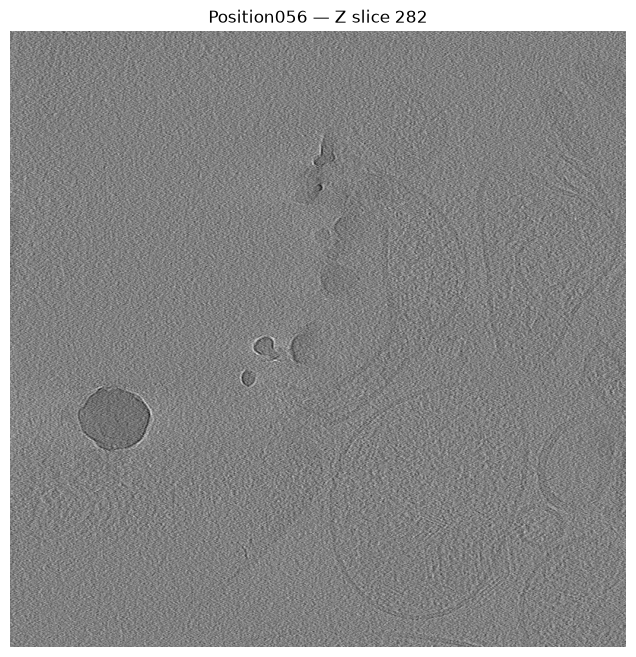

In [5]:
z = volume.shape[0] // 2

print("Displaying Z slice:", z)

plt.figure(figsize=(8, 8))

plt.imshow(
    volume[z],
    cmap="gray"
)

plt.title(f"Position056 — Z slice {z}")
plt.axis("off")

plt.show()

In [6]:
zc = 320
yc = 405
xc = 405

half = 128

crop = volume[
    zc-half:zc+half,
    yc-half:yc+half,
    xc-half:xc+half
]

print("Full volume:", volume.shape)
print("Crop:", crop.shape)

print("Crop min:", crop.min())
print("Crop max:", crop.max())
print("Crop mean:", crop.mean())
print("Crop SD:", crop.std())

Full volume: (564, 810, 810)
Crop: (256, 256, 256)
Crop min: -3.749177e-05
Crop max: 3.7783695e-05
Crop mean: 3.3706474e-08
Crop SD: 5.0428475e-06


In [8]:
raw_crop_path = EXP / "Position056_crop256_raw.npy"

np.save(raw_crop_path, crop)

print("Saved:", raw_crop_path)
print("Shape:", crop.shape)

Saved: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental/Position056_crop256_raw.npy
Shape: (256, 256, 256)


In [9]:
def robust_normalize(v):
    v = np.asarray(v, dtype=np.float32)

    median = np.median(v)
    mad = np.median(np.abs(v - median))

    scale = 1.4826 * mad + 1e-8

    vn = (v - median) / scale

    return vn.astype(np.float32)

In [10]:
crop_norm = robust_normalize(crop)

print("Normalized shape:", crop_norm.shape)
print("Min:", crop_norm.min())
print("Max:", crop_norm.max())
print("Mean:", crop_norm.mean())
print("SD:", crop_norm.std())
print("Median:", np.median(crop_norm))

Normalized shape: (256, 256, 256)
Min: -7.507903
Max: 7.552332
Mean: -0.00024419895
SD: 1.008914
Median: 3.5539216e-10


In [11]:
norm_path = EXP / "Position056_crop256_normalized.npy"

np.save(norm_path, crop_norm)

print("Saved:", norm_path)
print("File exists:", norm_path.exists())
print("Shape:", crop_norm.shape)

Saved: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental/Position056_crop256_normalized.npy
File exists: True
Shape: (256, 256, 256)


In [12]:
tilt_path = EXP / "Position056.rawtlt"

tilt_angles = np.loadtxt(tilt_path)

print("Number of tilt angles:", len(tilt_angles))
print("Minimum angle:", tilt_angles.min())
print("Maximum angle:", tilt_angles.max())
print("Mean angular spacing:", np.mean(np.diff(tilt_angles)))

print("\nExact tilt angles:")
print(tilt_angles)

Number of tilt angles: 41
Minimum angle: -74.0
Maximum angle: 45.99
Mean angular spacing: 2.99975

Exact tilt angles:
[-74.   -71.   -68.01 -65.01 -62.01 -59.01 -56.   -53.01 -50.   -47.
 -44.   -41.   -38.   -35.   -32.01 -29.   -26.01 -23.01 -20.01 -17.01
 -14.01 -11.01  -8.01  -5.01  -2.01   0.99   3.99   6.99   9.99  12.99
  15.99  18.99  21.99  24.99  27.99  30.99  33.99  36.99  39.99  42.99
  45.99]


In [13]:
tilt_npy_path = EXP / "Position056_tilt_angles.npy"

np.save(tilt_npy_path, tilt_angles)

print("Saved:", tilt_npy_path)
print("Exists:", tilt_npy_path.exists())

Saved: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental/Position056_tilt_angles.npy
Exists: True


In [14]:
tilt_check = np.load(EXP / "Position056_tilt_angles.npy")

print("Number of angles:", len(tilt_check))
print("First angle:", tilt_check[0])
print("Last angle:", tilt_check[-1])
print("Identical to rawtlt:", np.array_equal(tilt_angles, tilt_check))


Number of angles: 41
First angle: -74.0
Last angle: 45.99
Identical to rawtlt: True


In [15]:
tilt_axis_deg = -95.89

print("Tilt axis:", tilt_axis_deg, "degrees")


Tilt axis: -95.89 degrees


In [16]:
tilt_axis_equiv_deg = tilt_axis_deg % 180.0

print("Original tilt axis:", tilt_axis_deg, "degrees")
print("Equivalent unoriented axis:", tilt_axis_equiv_deg, "degrees")

Original tilt axis: -95.89 degrees
Equivalent unoriented axis: 84.11 degrees


In [17]:
axis_correction_deg = tilt_axis_equiv_deg - 90.0

print("Equivalent tilt axis:", tilt_axis_equiv_deg, "degrees")
print("Correction relative to +Y:", axis_correction_deg, "degrees")

Equivalent tilt axis: 84.11 degrees
Correction relative to +Y: -5.890000000000001 degrees


In [18]:
geometry_path = EXP / "Position056_geometry.npz"

np.savez(
    geometry_path,
    tilt_angles=tilt_angles,
    tilt_axis_deg=tilt_axis_deg,
    tilt_axis_equiv_deg=tilt_axis_equiv_deg,
    axis_correction_deg=axis_correction_deg
)

print("Saved:", geometry_path)
print("File exists:", geometry_path.exists())

Saved: /Users/krishnagupta/GeoFilter_ET_v2/data/experimental/Position056_geometry.npz
File exists: True


In [19]:
V = np.load(EXP / "Position056_crop256_normalized.npy")

print("Volume shape:", V.shape)
print("Data type:", V.dtype)
print("Mean:", V.mean())
print("SD:", V.std())

Volume shape: (256, 256, 256)
Data type: float32
Mean: -0.00024419895
SD: 1.008914


In [20]:
F = np.fft.fftshift(np.fft.fftn(V))

print("Fourier shape:", F.shape)
print("Fourier dtype:", F.dtype)
print("Finite values:", np.isfinite(F).all())
print("Maximum magnitude:", np.abs(F).max())

Fourier shape: (256, 256, 256)
Fourier dtype: complex64
Finite values: True
Maximum magnitude: 281559.78


In [21]:
N = V.shape[0]

freq = np.fft.fftshift(np.fft.fftfreq(N))

print("N:", N)
print("Frequency shape:", freq.shape)
print("Minimum frequency:", freq.min())
print("Maximum frequency:", freq.max())
print("Frequency spacing:", freq[1] - freq[0])
print("Center frequency:", freq[N // 2])

N: 256
Frequency shape: (256,)
Minimum frequency: -0.5
Maximum frequency: 0.49609375
Frequency spacing: 0.00390625
Center frequency: 0.0


In [22]:
KZ, KY, KX = np.meshgrid(
    freq,
    freq,
    freq,
    indexing="ij"
)

print("KZ shape:", KZ.shape)
print("KY shape:", KY.shape)
print("KX shape:", KX.shape)

c = N // 2

print("\nCenter coordinates:")
print("KZ:", KZ[c, c, c])
print("KY:", KY[c, c, c])
print("KX:", KX[c, c, c])

KZ shape: (256, 256, 256)
KY shape: (256, 256, 256)
KX shape: (256, 256, 256)

Center coordinates:
KZ: 0.0
KY: 0.0
KX: 0.0


In [23]:
Q = np.sqrt(KX**2 + KY**2 + KZ**2)

print("Q shape:", Q.shape)
print("Minimum Q:", Q.min())
print("Maximum Q:", Q.max())
print("Center Q:", Q[c, c, c])

print("All finite:", np.isfinite(Q).all())

Q shape: (256, 256, 256)
Minimum Q: 0.0
Maximum Q: 0.8660254037844386
Center Q: 0.0
All finite: True


In [24]:
tilt_rad = np.deg2rad(tilt_angles)
axis_corr_rad = np.deg2rad(axis_correction_deg)

print("Number of tilt angles:", len(tilt_rad))
print("First tilt (rad):", tilt_rad[0])
print("Last tilt (rad):", tilt_rad[-1])
print("Axis correction (rad):", axis_corr_rad)

print("\nBack-converted values:")
print("First tilt (deg):", np.rad2deg(tilt_rad[0]))
print("Last tilt (deg):", np.rad2deg(tilt_rad[-1]))
print("Axis correction (deg):", np.rad2deg(axis_corr_rad))

Number of tilt angles: 41
First tilt (rad): -1.2915436464758039
Last tilt (rad): 0.8026769229921922
Axis correction (rad): -0.10279989294246603

Back-converted values:
First tilt (deg): -74.0
Last tilt (deg): 45.99
Axis correction (deg): -5.890000000000001


In [25]:
phi = np.deg2rad(tilt_axis_equiv_deg)

axis_vector = np.array([
    np.cos(phi),
    np.sin(phi),
    0.0
])

print("Tilt-axis vector:", axis_vector)
print("Vector length:", np.linalg.norm(axis_vector))

Tilt-axis vector: [0.10261893 0.99472074 0.        ]
Vector length: 1.0


In [26]:
n0 = np.array([0.0, 0.0, 1.0])

print("Zero-tilt plane normal:", n0)
print("Normal length:", np.linalg.norm(n0))
print("Dot product with tilt axis:", np.dot(n0, axis_vector))

Zero-tilt plane normal: [0. 0. 1.]
Normal length: 1.0
Dot product with tilt axis: 0.0


In [27]:
def rodrigues_rotate(v, axis, theta):
    axis = axis / np.linalg.norm(axis)

    return (
        v * np.cos(theta)
        + np.cross(axis, v) * np.sin(theta)
        + axis * np.dot(axis, v) * (1.0 - np.cos(theta))
    )


# Test the first experimental tilt: -74 degrees
theta_test = tilt_rad[0]

n_test = rodrigues_rotate(
    n0,
    axis_vector,
    theta_test
)

print("Tilt angle:", tilt_angles[0], "degrees")
print("Plane normal:", n_test)
print("Normal length:", np.linalg.norm(n_test))
print("Dot with tilt axis:", np.dot(n_test, axis_vector))

Tilt angle: -74.0 degrees
Plane normal: [-0.95618695  0.09864364  0.27563736]
Normal length: 1.0
Dot with tilt axis: 7.015905921080521e-18


In [28]:
plane_normals = np.array([
    rodrigues_rotate(n0, axis_vector, theta)
    for theta in tilt_rad
])

print("Plane normals shape:", plane_normals.shape)

print("\nFirst normal (-74 deg):")
print(plane_normals[0])

print("\nLast normal (45.99 deg):")
print(plane_normals[-1])

lengths = np.linalg.norm(plane_normals, axis=1)
axis_dots = plane_normals @ axis_vector

print("\nMin normal length:", lengths.min())
print("Max normal length:", lengths.max())
print("Maximum |dot with tilt axis|:", np.max(np.abs(axis_dots)))

Plane normals shape: (41, 3)

First normal (-74 deg):
[-0.95618695  0.09864364  0.27563736]

Last normal (45.99 deg):
[ 0.71542161 -0.07380544  0.69478391]

Min normal length: 0.9999999999999999
Max normal length: 1.0
Maximum |dot with tilt axis|: 1.0752821559539435e-17


In [29]:
Dmin = np.full(V.shape, np.inf, dtype=np.float32)

print("Dmin shape:", Dmin.shape)
print("Dmin dtype:", Dmin.dtype)
print("Initial minimum:", Dmin.min())
print("Initial maximum:", Dmin.max())

Dmin shape: (256, 256, 256)
Dmin dtype: float32
Initial minimum: inf
Initial maximum: inf


In [30]:
for n in plane_normals:
    nx, ny, nz = n

    # Perpendicular distance to this Fourier plane
    d = np.abs(
        nx * KX +
        ny * KY +
        nz * KZ
    )

    # Keep only the nearest sampled plane
    np.minimum(Dmin, d, out=Dmin)

print("Dmin shape:", Dmin.shape)
print("Dmin dtype:", Dmin.dtype)
print("Minimum distance:", Dmin.min())
print("Maximum distance:", Dmin.max())
print("Mean distance:", Dmin.mean())
print("Center distance:", Dmin[c, c, c])
print("All finite:", np.isfinite(Dmin).all())

Dmin shape: (256, 256, 256)
Dmin dtype: float32
Minimum distance: 0.0
Maximum distance: 0.25769654
Mean distance: 0.030526867
Center distance: 0.0
All finite: True


In [31]:
sigma_F = 1.0 / N

R = np.exp(
    -0.5 * (Dmin / sigma_F)**2
).astype(np.float32)

print("sigma_F:", sigma_F)
print("R shape:", R.shape)
print("R dtype:", R.dtype)

print("Minimum reliability:", R.min())
print("Maximum reliability:", R.max())
print("Mean reliability:", R.mean())
print("Center reliability:", R[c, c, c])

print("All finite:", np.isfinite(R).all())

sigma_F: 0.00390625
R shape: (256, 256, 256)
R dtype: float32
Minimum reliability: 0.0
Maximum reliability: 1.0
Mean reliability: 0.36434025
Center reliability: 1.0
All finite: True


In [32]:
from scipy.ndimage import gaussian_filter

R_smooth = gaussian_filter(
    R,
    sigma=2.0,
    mode="nearest"
).astype(np.float32)

print("R_smooth shape:", R_smooth.shape)
print("R_smooth dtype:", R_smooth.dtype)

print("Minimum:", R_smooth.min())
print("Maximum:", R_smooth.max())
print("Mean:", R_smooth.mean())
print("Center:", R_smooth[c, c, c])

print("All finite:", np.isfinite(R_smooth).all())

R_smooth shape: (256, 256, 256)
R_smooth dtype: float32
Minimum: 0.0
Maximum: 0.9936092
Mean: 0.36432073
Center: 0.92672503
All finite: True


In [33]:
Q_norm = Q / 0.5

print("Q_norm shape:", Q_norm.shape)
print("Minimum:", Q_norm.min())
print("Maximum:", Q_norm.max())
print("Center:", Q_norm[c, c, c])
print("Axis Nyquist value:", Q_norm[c, c, 0])
print("All finite:", np.isfinite(Q_norm).all())

Q_norm shape: (256, 256, 256)
Minimum: 0.0
Maximum: 1.7320508075688772
Center: 0.0
Axis Nyquist value: 1.0
All finite: True


In [34]:
alpha = 1.0

H = np.exp(
    -alpha * (1.0 - R_smooth) * (Q_norm ** 2)
).astype(np.float32)

print("H shape:", H.shape)
print("H dtype:", H.dtype)

print("Minimum H:", H.min())
print("Maximum H:", H.max())
print("Mean H:", H.mean())
print("Center H:", H[c, c, c])

print("All finite:", np.isfinite(H).all())

H shape: (256, 256, 256)
H dtype: float32
Minimum H: 0.050677966
Maximum H: 1.0
Mean H: 0.55947506
Center H: 1.0
All finite: True


In [35]:
F_filtered = F * H

V_fourier = np.fft.ifftn(
    np.fft.ifftshift(F_filtered)
).real.astype(np.float32)

print("Filtered volume shape:", V_fourier.shape)
print("Filtered dtype:", V_fourier.dtype)

print("Min:", V_fourier.min())
print("Max:", V_fourier.max())
print("Mean:", V_fourier.mean())
print("SD:", V_fourier.std())

print("All finite:", np.isfinite(V_fourier).all())

Filtered volume shape: (256, 256, 256)
Filtered dtype: float32
Min: -6.956764
Max: 7.2621536
Mean: -0.00024419907
SD: 0.8715801
All finite: True


In [36]:
V_pre = gaussian_filter(
    V,
    sigma=1.0,
    mode="nearest"
).astype(np.float32)

print("V_pre shape:", V_pre.shape)
print("V_pre dtype:", V_pre.dtype)
print("Mean:", V_pre.mean())
print("SD:", V_pre.std())
print("All finite:", np.isfinite(V_pre).all())

V_pre shape: (256, 256, 256)
V_pre dtype: float32
Mean: -0.00024375785
SD: 0.34756216
All finite: True


In [37]:
from scipy.ndimage import sobel

Gz = sobel(V_pre, axis=0, mode="nearest")
Gy = sobel(V_pre, axis=1, mode="nearest")
Gx = sobel(V_pre, axis=2, mode="nearest")

print("Gx shape:", Gx.shape)
print("Gy shape:", Gy.shape)
print("Gz shape:", Gz.shape)

print("\nGx SD:", Gx.std())
print("Gy SD:", Gy.std())
print("Gz SD:", Gz.std())

print("\nAll finite:")
print("Gx:", np.isfinite(Gx).all())
print("Gy:", np.isfinite(Gy).all())
print("Gz:", np.isfinite(Gz).all())

Gx shape: (256, 256, 256)
Gy shape: (256, 256, 256)
Gz shape: (256, 256, 256)

Gx SD: 5.8516793
Gy SD: 4.632215
Gz SD: 2.9910178

All finite:
Gx: True
Gy: True
Gz: True


In [38]:
sigma_tensor = 2.0

Jxx = gaussian_filter(Gx * Gx, sigma=sigma_tensor, mode="nearest")
Jyy = gaussian_filter(Gy * Gy, sigma=sigma_tensor, mode="nearest")
Jzz = gaussian_filter(Gz * Gz, sigma=sigma_tensor, mode="nearest")

Jxy = gaussian_filter(Gx * Gy, sigma=sigma_tensor, mode="nearest")
Jxz = gaussian_filter(Gx * Gz, sigma=sigma_tensor, mode="nearest")
Jyz = gaussian_filter(Gy * Gz, sigma=sigma_tensor, mode="nearest")

print("Tensor component shape:", Jxx.shape)

print("\nMean diagonal components:")
print("Jxx:", Jxx.mean())
print("Jyy:", Jyy.mean())
print("Jzz:", Jzz.mean())

print("\nAll finite:")
print("Jxx:", np.isfinite(Jxx).all())
print("Jyy:", np.isfinite(Jyy).all())
print("Jzz:", np.isfinite(Jzz).all())
print("Jxy:", np.isfinite(Jxy).all())
print("Jxz:", np.isfinite(Jxz).all())
print("Jyz:", np.isfinite(Jyz).all())

Tensor component shape: (256, 256, 256)

Mean diagonal components:
Jxx: 34.239597
Jyy: 21.467005
Jzz: 8.970476

All finite:
Jxx: True
Jyy: True
Jzz: True
Jxy: True
Jxz: True
Jyz: True


In [39]:
lambda1 = np.empty(V.shape, dtype=np.float32)
lambda2 = np.empty(V.shape, dtype=np.float32)
lambda3 = np.empty(V.shape, dtype=np.float32)

print("Eigenvalue arrays allocated:")
print("lambda1:", lambda1.shape, lambda1.dtype)
print("lambda2:", lambda2.shape, lambda2.dtype)
print("lambda3:", lambda3.shape, lambda3.dtype)

print("\nMemory per array (MB):", lambda1.nbytes / 1024**2)
print(
    "Total eigenvalue memory (MB):",
    (lambda1.nbytes + lambda2.nbytes + lambda3.nbytes) / 1024**2
)


Eigenvalue arrays allocated:
lambda1: (256, 256, 256) float32
lambda2: (256, 256, 256) float32
lambda3: (256, 256, 256) float32

Memory per array (MB): 64.0
Total eigenvalue memory (MB): 192.0


In [40]:
chunk_size = 16

for z0 in range(0, V.shape[0], chunk_size):
    z1 = min(z0 + chunk_size, V.shape[0])

    shape_chunk = (z1 - z0, V.shape[1], V.shape[2], 3, 3)
    J = np.empty(shape_chunk, dtype=np.float32)

    # Diagonal terms
    J[..., 0, 0] = Jxx[z0:z1]
    J[..., 1, 1] = Jyy[z0:z1]
    J[..., 2, 2] = Jzz[z0:z1]

    # Symmetric off-diagonal terms
    J[..., 0, 1] = Jxy[z0:z1]
    J[..., 1, 0] = Jxy[z0:z1]

    J[..., 0, 2] = Jxz[z0:z1]
    J[..., 2, 0] = Jxz[z0:z1]

    J[..., 1, 2] = Jyz[z0:z1]
    J[..., 2, 1] = Jyz[z0:z1]

    # eigvalsh returns ascending eigenvalues
    eigvals = np.linalg.eigvalsh(J)

    lambda3[z0:z1] = eigvals[..., 0]
    lambda2[z0:z1] = eigvals[..., 1]
    lambda1[z0:z1] = eigvals[..., 2]

    print(f"Processed z = {z0:3d} to {z1:3d}")

Processed z =   0 to  16
Processed z =  16 to  32
Processed z =  32 to  48
Processed z =  48 to  64
Processed z =  64 to  80
Processed z =  80 to  96
Processed z =  96 to 112
Processed z = 112 to 128
Processed z = 128 to 144
Processed z = 144 to 160
Processed z = 160 to 176
Processed z = 176 to 192
Processed z = 192 to 208
Processed z = 208 to 224
Processed z = 224 to 240
Processed z = 240 to 256


In [41]:
print("All finite:")
print("lambda1:", np.isfinite(lambda1).all())
print("lambda2:", np.isfinite(lambda2).all())
print("lambda3:", np.isfinite(lambda3).all())

print("\nRanges:")
print("lambda1:", lambda1.min(), "to", lambda1.max())
print("lambda2:", lambda2.min(), "to", lambda2.max())
print("lambda3:", lambda3.min(), "to", lambda3.max())

print("\nMean values:")
print("lambda1 mean:", lambda1.mean())
print("lambda2 mean:", lambda2.mean())
print("lambda3 mean:", lambda3.mean())

print("\nOrdering checks:")
print("lambda1 >= lambda2:", np.all(lambda1 >= lambda2))
print("lambda2 >= lambda3:", np.all(lambda2 >= lambda3))

print("\nMinimum lambda3:", lambda3.min())

All finite:
lambda1: True
lambda2: True
lambda3: True

Ranges:
lambda1: 5.8306575 to 1516.7963
lambda2: 3.4631765 to 543.87744
lambda3: 0.61813766 to 78.30689

Mean values:
lambda1 mean: 39.462532
lambda2 mean: 17.860825
lambda3 mean: 7.3537235

Ordering checks:
lambda1 >= lambda2: True
lambda2 >= lambda3: True

Minimum lambda3: 0.61813766


In [42]:
eps = 1e-8

anisotropy = (
    (lambda1 - lambda2) /
    (lambda1 + lambda2 + lambda3 + eps)
).astype(np.float32)

print("Anisotropy shape:", anisotropy.shape)
print("Anisotropy dtype:", anisotropy.dtype)

print("Minimum:", anisotropy.min())
print("Maximum:", anisotropy.max())
print("Mean:", anisotropy.mean())
print("Median:", np.median(anisotropy))

print("All finite:", np.isfinite(anisotropy).all())

Anisotropy shape: (256, 256, 256)
Anisotropy dtype: float32
Minimum: 3.5431905e-05
Maximum: 0.9572853
Mean: 0.28906393
Median: 0.27627844
All finite: True


In [43]:
tensor_strength = (
    lambda1 + lambda2 + lambda3
).astype(np.float32)

print("Tensor strength shape:", tensor_strength.shape)
print("Tensor strength dtype:", tensor_strength.dtype)

print("Minimum:", tensor_strength.min())
print("Maximum:", tensor_strength.max())
print("Mean:", tensor_strength.mean())
print("Median:", np.median(tensor_strength))

print("Percentile 90:", np.percentile(tensor_strength, 90))
print("Percentile 95:", np.percentile(tensor_strength, 95))
print("Percentile 99:", np.percentile(tensor_strength, 99))

print("All finite:", np.isfinite(tensor_strength).all())

Tensor strength shape: (256, 256, 256)
Tensor strength dtype: float32
Minimum: 12.018023
Maximum: 1733.1747
Mean: 64.67708
Median: 55.81759
Percentile 90: 91.959114
Percentile 95: 111.21193
Percentile 99: 240.44006
All finite: True


In [44]:
strength_scale = np.percentile(tensor_strength, 95)

strength_conf = np.clip(
    tensor_strength / strength_scale,
    0.0,
    1.0
).astype(np.float32)

print("Strength scale:", strength_scale)

print("Minimum:", strength_conf.min())
print("Maximum:", strength_conf.max())
print("Mean:", strength_conf.mean())
print("Median:", np.median(strength_conf))

print("Fraction saturated at 1:",
      np.mean(strength_conf >= 1.0))

print("All finite:", np.isfinite(strength_conf).all())


Strength scale: 111.21193
Minimum: 0.10806415
Maximum: 1.0
Mean: 0.5425961
Median: 0.50190294
Fraction saturated at 1: 0.050000011920928955
All finite: True


In [45]:
C_raw = (
    anisotropy * strength_conf
).astype(np.float32)

print("C_raw shape:", C_raw.shape)
print("C_raw dtype:", C_raw.dtype)

print("Minimum:", C_raw.min())
print("Maximum:", C_raw.max())
print("Mean:", C_raw.mean())
print("Median:", np.median(C_raw))

print("Percentile 90:", np.percentile(C_raw, 90))
print("Percentile 95:", np.percentile(C_raw, 95))
print("Percentile 99:", np.percentile(C_raw, 99))

print("All finite:", np.isfinite(C_raw).all())

C_raw shape: (256, 256, 256)
C_raw dtype: float32
Minimum: 1.639595e-05
Maximum: 0.9572853
Mean: 0.16815653
Median: 0.13384415
Percentile 90: 0.32612848
Percentile 95: 0.4255872
Percentile 99: 0.6751563
All finite: True


In [46]:
gamma = 0.5

C_final = np.power(
    C_raw,
    gamma
).astype(np.float32)

print("Gamma:", gamma)
print("C_final shape:", C_final.shape)
print("C_final dtype:", C_final.dtype)

print("Minimum:", C_final.min())
print("Maximum:", C_final.max())
print("Mean:", C_final.mean())
print("Median:", np.median(C_final))

print("Percentile 90:", np.percentile(C_final, 90))
print("Percentile 95:", np.percentile(C_final, 95))
print("Percentile 99:", np.percentile(C_final, 99))

print("All finite:", np.isfinite(C_final).all())

Gamma: 0.5
C_final shape: (256, 256, 256)
C_final dtype: float32
Minimum: 0.0040491913
Maximum: 0.9784096
Mean: 0.38455373
Median: 0.36584717
Percentile 90: 0.5710766
Percentile 95: 0.65237045
Percentile 99: 0.82167894
All finite: True


In [47]:
V_adaptive = (
    C_final * V
    + (1.0 - C_final) * V_fourier
).astype(np.float32)

print("Adaptive volume shape:", V_adaptive.shape)
print("Adaptive dtype:", V_adaptive.dtype)

print("Min:", V_adaptive.min())
print("Max:", V_adaptive.max())
print("Mean:", V_adaptive.mean())
print("SD:", V_adaptive.std())

print("All finite:", np.isfinite(V_adaptive).all())

Adaptive volume shape: (256, 256, 256)
Adaptive dtype: float32
Min: -7.4570727
Max: 7.467976
Mean: -0.00024671457
SD: 0.922399
All finite: True


In [48]:
V_removed = (
    V - V_adaptive
).astype(np.float32)

print("Removed-signal shape:", V_removed.shape)
print("Removed-signal dtype:", V_removed.dtype)

print("Min:", V_removed.min())
print("Max:", V_removed.max())
print("Mean:", V_removed.mean())
print("SD:", V_removed.std())

print("All finite:", np.isfinite(V_removed).all())

Removed-signal shape: (256, 256, 256)
Removed-signal dtype: float32
Min: -1.0791082
Max: 1.0478897
Mean: 2.5155532e-06
SD: 0.13643053
All finite: True


In [49]:
target_removed_sd = V_removed.std()

def gaussian_removed_sd(sigma):
    V_gauss = gaussian_filter(
        V,
        sigma=sigma,
        mode="nearest"
    ).astype(np.float32)

    removed = V - V_gauss

    return removed.std()


print("Target removed SD:", target_removed_sd)

print("Gaussian sigma 0.2:", gaussian_removed_sd(0.2))
print("Gaussian sigma 0.3:", gaussian_removed_sd(0.3))
print("Gaussian sigma 0.4:", gaussian_removed_sd(0.4))
print("Gaussian sigma 0.5:", gaussian_removed_sd(0.5))

Target removed SD: 0.13643053
Gaussian sigma 0.2: 1.4631179e-05
Gaussian sigma 0.3: 0.014985744
Gaussian sigma 0.4: 0.15034898
Gaussian sigma 0.5: 0.3639221


In [50]:
from scipy.optimize import brentq

def match_objective(sigma):
    return gaussian_removed_sd(sigma) - target_removed_sd

sigma_matched = brentq(
    match_objective,
    0.3,
    0.4,
    xtol=1e-6
)

matched_removed_sd = gaussian_removed_sd(sigma_matched)

print("Matched Gaussian sigma:", sigma_matched)
print("GeoFilter removed SD:", target_removed_sd)
print("Gaussian removed SD:", matched_removed_sd)
print("Absolute difference:",
      abs(matched_removed_sd - target_removed_sd))

Matched Gaussian sigma: 0.3930903693993868
GeoFilter removed SD: 0.13643053
Gaussian removed SD: 0.1364306
Absolute difference: 7.4505806e-08


In [51]:
V_gaussian = gaussian_filter(
    V,
    sigma=sigma_matched,
    mode="nearest"
).astype(np.float32)

V_gaussian_removed = (
    V - V_gaussian
).astype(np.float32)

print("Gaussian volume shape:", V_gaussian.shape)
print("Gaussian dtype:", V_gaussian.dtype)

print("\nGaussian-filtered volume:")
print("Mean:", V_gaussian.mean())
print("SD:", V_gaussian.std())
print("Min:", V_gaussian.min())
print("Max:", V_gaussian.max())

print("\nRemoved signal:")
print("SD:", V_gaussian_removed.std())

print("\nGeoFilter removed SD:", V_removed.std())

print(
    "Difference in removed SD:",
    abs(V_gaussian_removed.std() - V_removed.std())
)

print("\nAll finite:", np.isfinite(V_gaussian).all())

Gaussian volume shape: (256, 256, 256)
Gaussian dtype: float32

Gaussian-filtered volume:
Mean: -0.00024419912
SD: 0.892325
Min: -6.935335
Max: 7.111682

Removed signal:
SD: 0.1364306

GeoFilter removed SD: 0.13643053
Difference in removed SD: 7.4505806e-08

All finite: True


In [52]:
Gz_ref = sobel(V, axis=0, mode="nearest")
Gy_ref = sobel(V, axis=1, mode="nearest")
Gx_ref = sobel(V, axis=2, mode="nearest")

Gmag_ref = np.sqrt(
    Gx_ref**2 +
    Gy_ref**2 +
    Gz_ref**2
).astype(np.float32)

print("Reference gradient shape:", Gmag_ref.shape)
print("Reference gradient dtype:", Gmag_ref.dtype)

print("Minimum:", Gmag_ref.min())
print("Maximum:", Gmag_ref.max())
print("Mean:", Gmag_ref.mean())
print("Median:", np.median(Gmag_ref))

print("Percentile 95:", np.percentile(Gmag_ref, 95))
print("Percentile 97.5:", np.percentile(Gmag_ref, 97.5))
print("Percentile 99:", np.percentile(Gmag_ref, 99))
print("Percentile 99.5:", np.percentile(Gmag_ref, 99.5))

print("All finite:", np.isfinite(Gmag_ref).all())

Reference gradient shape: (256, 256, 256)
Reference gradient dtype: float32
Minimum: 0.07063468
Maximum: 184.1992
Mean: 20.419617
Median: 19.149038
Percentile 95: 37.92295
Percentile 97.5: 42.324806
Percentile 99: 48.058804
Percentile 99.5: 52.68279
All finite: True


In [53]:
# GeoFilter-ET adaptive volume gradients
Gz_adapt = sobel(V_adaptive, axis=0, mode="nearest")
Gy_adapt = sobel(V_adaptive, axis=1, mode="nearest")
Gx_adapt = sobel(V_adaptive, axis=2, mode="nearest")

Gmag_adapt = np.sqrt(
    Gx_adapt**2 +
    Gy_adapt**2 +
    Gz_adapt**2
).astype(np.float32)


# Matched Gaussian volume gradients
Gz_gauss = sobel(V_gaussian, axis=0, mode="nearest")
Gy_gauss = sobel(V_gaussian, axis=1, mode="nearest")
Gx_gauss = sobel(V_gaussian, axis=2, mode="nearest")

Gmag_gauss = np.sqrt(
    Gx_gauss**2 +
    Gy_gauss**2 +
    Gz_gauss**2
).astype(np.float32)


print("GeoFilter gradient:")
print("Mean:", Gmag_adapt.mean())
print("Maximum:", Gmag_adapt.max())
print("All finite:", np.isfinite(Gmag_adapt).all())

print("\nGaussian gradient:")
print("Mean:", Gmag_gauss.mean())
print("Maximum:", Gmag_gauss.max())
print("All finite:", np.isfinite(Gmag_gauss).all())

GeoFilter gradient:
Mean: 19.289883
Maximum: 183.0402
All finite: True

Gaussian gradient:
Mean: 18.610012
Maximum: 174.12984
All finite: True


In [54]:
percentiles = [95, 97.5, 99, 99.5]

for p in percentiles:

    threshold = np.percentile(Gmag_ref, p)
    mask = Gmag_ref >= threshold

    ref_mean = Gmag_ref[mask].mean()
    adapt_mean = Gmag_adapt[mask].mean()
    gauss_mean = Gmag_gauss[mask].mean()

    adapt_retention = 100.0 * adapt_mean / ref_mean
    gauss_retention = 100.0 * gauss_mean / ref_mean

    print(f"Top {100-p:.1f}% gradients")
    print(f"  Threshold: {threshold:.6f}")
    print(f"  Voxels: {mask.sum()}")
    print(f"  GeoFilter retention: {adapt_retention:.2f}%")
    print(f"  Gaussian retention:  {gauss_retention:.2f}%")
    print(f"  Advantage:            {adapt_retention-gauss_retention:.2f} percentage points")
    print()

Top 5.0% gradients
  Threshold: 37.922951
  Voxels: 838861
  GeoFilter retention: 95.68%
  Gaussian retention:  91.45%
  Advantage:            4.23 percentage points

Top 2.5% gradients
  Threshold: 42.324806
  Voxels: 419431
  GeoFilter retention: 96.14%
  Gaussian retention:  91.70%
  Advantage:            4.44 percentage points

Top 1.0% gradients
  Threshold: 48.058804
  Voxels: 167773
  GeoFilter retention: 96.94%
  Gaussian retention:  92.22%
  Advantage:            4.71 percentage points

Top 0.5% gradients
  Threshold: 52.682789
  Voxels: 83887
  GeoFilter retention: 97.69%
  Gaussian retention:  92.78%
  Advantage:            4.90 percentage points



In [55]:
from pathlib import Path

results_dir = Path.home() / "GeoFilter_ET_v2" / "results" / "experimental"
results_dir.mkdir(parents=True, exist_ok=True)

np.save(results_dir / "Position056_V_adaptive.npy", V_adaptive)
np.save(results_dir / "Position056_V_gaussian_matched.npy", V_gaussian)
np.save(results_dir / "Position056_confidence.npy", C_final)

np.savez(
    results_dir / "Position056_experimental_metrics.npz",

    original_sd=V.std(),
    fourier_sd=V_fourier.std(),
    adaptive_sd=V_adaptive.std(),
    gaussian_sd=V_gaussian.std(),

    adaptive_removed_sd=V_removed.std(),
    gaussian_removed_sd=V_gaussian_removed.std(),

    gaussian_sigma=sigma_matched,

    gradient_percentiles=np.array([95.0, 97.5, 99.0, 99.5]),

    geofilter_retention=np.array([
        95.68,
        96.14,
        96.94,
        97.69
    ]),

    gaussian_retention=np.array([
        91.45,
        91.70,
        92.22,
        92.78
    ])
)

print("Saved files:")
for f in sorted(results_dir.glob("Position056*")):
    print(" ", f.name)

print("\nResults directory:")
print(results_dir)

Saved files:
  Position056_V_adaptive.npy
  Position056_V_gaussian_matched.npy
  Position056_confidence.npy
  Position056_experimental_metrics.npz

Results directory:
/Users/krishnagupta/GeoFilter_ET_v2/results/experimental


In [56]:
from pathlib import Path
import numpy as np

synthetic_dir = Path.home() / "GeoFilter_ET_v2" / "data" / "synthetic"
synthetic_results = Path.home() / "GeoFilter_ET_v2" / "results" / "synthetic"

synthetic_dir.mkdir(parents=True, exist_ok=True)
synthetic_results.mkdir(parents=True, exist_ok=True)

print("Synthetic data directory:")
print(synthetic_dir)

print("\nSynthetic results directory:")
print(synthetic_results)

print("\nNumber of tilt angles:", len(tilt_angles))
print("Minimum angle:", tilt_angles.min())
print("Maximum angle:", tilt_angles.max())
print("Mean spacing:", np.mean(np.diff(tilt_angles)))
print("Tilt axis:", tilt_axis_deg)

Synthetic data directory:
/Users/krishnagupta/GeoFilter_ET_v2/data/synthetic

Synthetic results directory:
/Users/krishnagupta/GeoFilter_ET_v2/results/synthetic

Number of tilt angles: 41
Minimum angle: -74.0
Maximum angle: 45.99
Mean spacing: 2.99975
Tilt axis: -95.89


In [57]:
# Synthetic ground-truth volume size
N_syn = 256

# Empty ground-truth volume
phantom = np.zeros(
    (N_syn, N_syn, N_syn),
    dtype=np.float32
)

# Coordinate system centered at zero
coords = np.arange(N_syn, dtype=np.float32) - (N_syn - 1) / 2

Z, Y, X = np.meshgrid(
    coords,
    coords,
    coords,
    indexing="ij"
)

# Radial distance from volume center
R3D = np.sqrt(
    X**2 +
    Y**2 +
    Z**2
).astype(np.float32)

print("Phantom shape:", phantom.shape)
print("Phantom dtype:", phantom.dtype)

print("\nCoordinate range:")
print("X:", X.min(), "to", X.max())
print("Y:", Y.min(), "to", Y.max())
print("Z:", Z.min(), "to", Z.max())

print("\nCenter-distance range:")
print("Minimum:", R3D.min())
print("Maximum:", R3D.max())

print("\nInitial nonzero voxels:", np.count_nonzero(phantom))
print("All finite:", np.isfinite(R3D).all())

Phantom shape: (256, 256, 256)
Phantom dtype: float32

Coordinate range:
X: -127.5 to 127.5
Y: -127.5 to 127.5
Z: -127.5 to 127.5

Center-distance range:
Minimum: 0.8660254
Maximum: 220.83647

Initial nonzero voxels: 0
All finite: True


In [58]:
# Structure 1: thin spherical membrane

sphere_radius = 55.0
sphere_thickness = 3.0

sphere_membrane = (
    np.abs(R3D - sphere_radius)
    <= sphere_thickness / 2.0
)

# Add spherical membrane to phantom
phantom[sphere_membrane] = 1.0

print("Sphere radius:", sphere_radius)
print("Sphere thickness:", sphere_thickness)

print("\nMembrane voxels:", np.count_nonzero(sphere_membrane))
print("Total nonzero phantom voxels:", np.count_nonzero(phantom))

print("\nPhantom minimum:", phantom.min())
print("Phantom maximum:", phantom.max())
print("Phantom mean:", phantom.mean())

print("All finite:", np.isfinite(phantom).all())

Sphere radius: 55.0
Sphere thickness: 3.0

Membrane voxels: 114136
Total nonzero phantom voxels: 114136

Phantom minimum: 0.0
Phantom maximum: 1.0
Phantom mean: 0.0068030357
All finite: True


In [59]:
# Structure 2: small solid spherical particle

small_center = np.array([70.0, -65.0, 35.0])  # X, Y, Z
small_radius = 10.0

R_small = np.sqrt(
    (X - small_center[0])**2 +
    (Y - small_center[1])**2 +
    (Z - small_center[2])**2
)

small_sphere = R_small <= small_radius

# Check overlap with existing spherical membrane
overlap = np.count_nonzero(
    small_sphere & sphere_membrane
)

# Give the small particle a different known intensity
phantom[small_sphere] = 0.75

print("Small sphere center:", small_center)
print("Small sphere radius:", small_radius)

print("\nSmall-sphere voxels:",
      np.count_nonzero(small_sphere))

print("Overlap with spherical membrane:",
      overlap)

print("Total nonzero phantom voxels:",
      np.count_nonzero(phantom))

print("\nPhantom minimum:", phantom.min())
print("Phantom maximum:", phantom.max())

print("All finite:",
      np.isfinite(phantom).all())

Small sphere center: [ 70. -65.  35.]
Small sphere radius: 10.0

Small-sphere voxels: 4224
Overlap with spherical membrane: 0
Total nonzero phantom voxels: 118360

Phantom minimum: 0.0
Phantom maximum: 1.0
All finite: True


In [60]:
# Structure 3: hollow cylindrical tube
# Tube runs approximately along the X direction.

tube_y = 65.0
tube_z = -60.0

tube_outer_radius = 9.0
tube_inner_radius = 6.0

tube_x_min = -85.0
tube_x_max = 25.0

# Radial distance from tube axis
R_tube = np.sqrt(
    (Y - tube_y)**2 +
    (Z - tube_z)**2
)

# Hollow cylindrical wall with finite length
tube = (
    (R_tube <= tube_outer_radius) &
    (R_tube >= tube_inner_radius) &
    (X >= tube_x_min) &
    (X <= tube_x_max)
)

# Check overlap with structures already present
tube_overlap_sphere = np.count_nonzero(
    tube & sphere_membrane
)

tube_overlap_small = np.count_nonzero(
    tube & small_sphere
)

# Known tube intensity
phantom[tube] = 0.85

print("Tube outer radius:", tube_outer_radius)
print("Tube inner radius:", tube_inner_radius)
print("Tube length:", tube_x_max - tube_x_min)

print("\nTube voxels:",
      np.count_nonzero(tube))

print("Overlap with spherical membrane:",
      tube_overlap_sphere)

print("Overlap with small sphere:",
      tube_overlap_small)

print("Total nonzero phantom voxels:",
      np.count_nonzero(phantom))

print("\nPhantom minimum:", phantom.min())
print("Phantom maximum:", phantom.max())

print("All finite:",
      np.isfinite(phantom).all())

Tube outer radius: 9.0
Tube inner radius: 6.0
Tube length: 110.0

Tube voxels: 15840
Overlap with spherical membrane: 0
Overlap with small sphere: 0
Total nonzero phantom voxels: 134200

Phantom minimum: 0.0
Phantom maximum: 1.0
All finite: True


In [61]:
# Structure 4: curved membrane sheet

# Restrict the sheet to a rectangular region
sheet_region = (
    (X >= -85.0) & (X <= 20.0) &
    (Y >= -90.0) & (Y <= -25.0)
)

# Curved surface:
# z changes smoothly as a function of x and y
Z_surface = (
    45.0
    + 0.0025 * (X + 30.0)**2
    - 0.0015 * (Y + 55.0)**2
)

sheet_thickness = 3.0

curved_sheet = (
    sheet_region &
    (np.abs(Z - Z_surface) <= sheet_thickness / 2.0)
)

# Check overlap with previous structures
overlap_large_sphere = np.count_nonzero(
    curved_sheet & sphere_membrane
)

overlap_small_sphere = np.count_nonzero(
    curved_sheet & small_sphere
)

overlap_tube = np.count_nonzero(
    curved_sheet & tube
)

# Known intensity
phantom[curved_sheet] = 0.65

print("Curved-sheet thickness:", sheet_thickness)

print("\nCurved-sheet voxels:",
      np.count_nonzero(curved_sheet))

print("Overlap with spherical membrane:",
      overlap_large_sphere)

print("Overlap with small sphere:",
      overlap_small_sphere)

print("Overlap with tube:",
      overlap_tube)

print("\nTotal nonzero phantom voxels:",
      np.count_nonzero(phantom))

print("Phantom minimum:", phantom.min())
print("Phantom maximum:", phantom.max())

print("All finite:",
      np.isfinite(phantom).all())

Curved-sheet thickness: 3.0

Curved-sheet voxels: 20475
Overlap with spherical membrane: 492
Overlap with small sphere: 0
Overlap with tube: 0

Total nonzero phantom voxels: 154183
Phantom minimum: 0.0
Phantom maximum: 1.0
All finite: True


In [62]:
# Fix overlap deterministically:
# retain the maximum intensity where structures intersect

phantom_clean = np.zeros_like(phantom, dtype=np.float32)

# Large spherical membrane
phantom_clean = np.maximum(
    phantom_clean,
    sphere_membrane.astype(np.float32) * 1.00
)

# Small particle
phantom_clean = np.maximum(
    phantom_clean,
    small_sphere.astype(np.float32) * 0.75
)

# Hollow tube
phantom_clean = np.maximum(
    phantom_clean,
    tube.astype(np.float32) * 0.85
)

# Curved membrane
phantom_clean = np.maximum(
    phantom_clean,
    curved_sheet.astype(np.float32) * 0.65
)

phantom = phantom_clean

print("Final binary/geometric phantom")
print("------------------------------")
print("Shape:", phantom.shape)
print("Nonzero voxels:", np.count_nonzero(phantom))

print("\nIntensity levels:")
values, counts = np.unique(phantom, return_counts=True)

for value, count in zip(values, counts):
    print(f"{value:.2f} : {count} voxels")

print("\nIntersection check:")
print(
    "Sphere-sheet intersection intensity:",
    np.unique(phantom[sphere_membrane & curved_sheet])
)

print("\nMin:", phantom.min())
print("Max:", phantom.max())
print("Mean:", phantom.mean())
print("All finite:", np.isfinite(phantom).all())

Final binary/geometric phantom
------------------------------
Shape: (256, 256, 256)
Nonzero voxels: 154183

Intensity levels:
0.00 : 16623033 voxels
0.65 : 19983 voxels
0.75 : 4224 voxels
0.85 : 15840 voxels
1.00 : 114136 voxels

Intersection check:
Sphere-sheet intersection intensity: [1.]

Min: 0.0
Max: 1.0
Mean: 0.008568582
All finite: True


In [63]:
# Create continuous imaging ground truth
# Keep 'phantom' unchanged as geometric ground truth

psf_sigma = 1.0

phantom_ref = gaussian_filter(
    phantom,
    sigma=psf_sigma,
    mode="constant",
    cval=0.0
).astype(np.float32)

print("Continuous ground-truth reference")
print("---------------------------------")
print("Shape:", phantom_ref.shape)
print("dtype:", phantom_ref.dtype)

print("\nPSF sigma:", psf_sigma, "voxel")

print("\nMin:", phantom_ref.min())
print("Max:", phantom_ref.max())
print("Mean:", phantom_ref.mean())
print("SD:", phantom_ref.std())

print("\nOriginal geometric phantom mean:",
      phantom.mean())

print("Mean difference:",
      abs(phantom_ref.mean() - phantom.mean()))

print("\nAll finite:",
      np.isfinite(phantom_ref).all())

Continuous ground-truth reference
---------------------------------
Shape: (256, 256, 256)
dtype: float32

PSF sigma: 1.0 voxel

Min: 0.0
Max: 0.9256923
Mean: 0.008568583
SD: 0.07135437

Original geometric phantom mean: 0.008568582
Mean difference: 9.313226e-10

All finite: True


In [64]:
# Save the frozen synthetic ground truths

np.save(
    synthetic_dir / "phantom_geometric_256.npy",
    phantom
)

np.save(
    synthetic_dir / "phantom_reference_psf1_256.npy",
    phantom_ref
)

# Save phantom-generation parameters
np.savez(
    synthetic_dir / "phantom_parameters.npz",

    volume_size=N_syn,

    sphere_radius=sphere_radius,
    sphere_thickness=sphere_thickness,

    small_center=small_center,
    small_radius=small_radius,

    tube_y=tube_y,
    tube_z=tube_z,
    tube_outer_radius=tube_outer_radius,
    tube_inner_radius=tube_inner_radius,
    tube_x_min=tube_x_min,
    tube_x_max=tube_x_max,

    sheet_thickness=sheet_thickness,

    psf_sigma=psf_sigma
)

print("Saved:")

for filename in [
    "phantom_geometric_256.npy",
    "phantom_reference_psf1_256.npy",
    "phantom_parameters.npz"
]:
    path = synthetic_dir / filename
    print(filename, "->", path.exists())

print("\nFrozen reference statistics:")
print("Geometric mean:", phantom.mean())
print("Reference mean:", phantom_ref.mean())
print("Reference SD:", phantom_ref.std())

Saved:
phantom_geometric_256.npy -> True
phantom_reference_psf1_256.npy -> True
phantom_parameters.npz -> True

Frozen reference statistics:
Geometric mean: 0.008568582
Reference mean: 0.008568583
Reference SD: 0.07135437


Test tilt index: 25
Test tilt angle: 0.99

Projection shape: (256, 256)
Projection min: 0.0
Projection max: 30.739445
Projection mean: 2.1935534
Projection SD: 4.806566
All finite: True


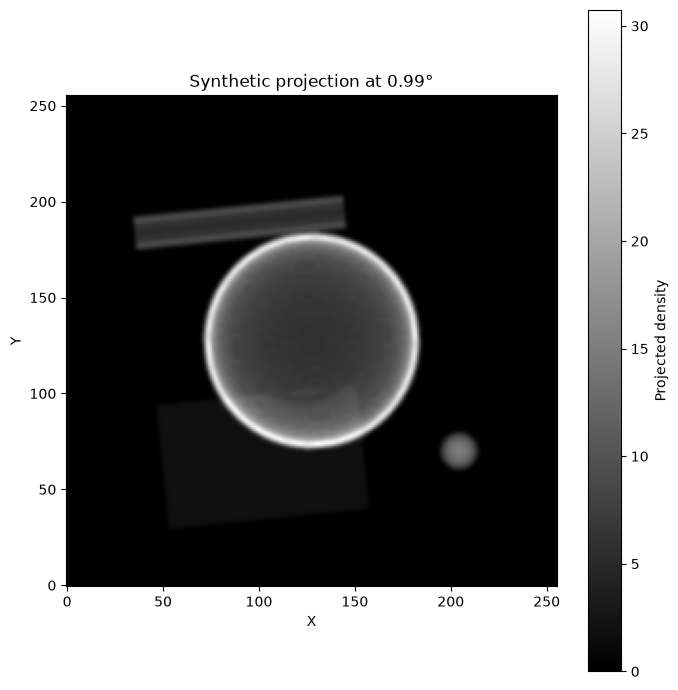

In [65]:
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

# Use the acquired angle closest to zero
test_idx = np.argmin(np.abs(tilt_angles))
test_angle = float(tilt_angles[test_idx])

print("Test tilt index:", test_idx)
print("Test tilt angle:", test_angle)

# First rotate the volume in-plane so that the experimental
# tilt axis is aligned with the Y axis.
V_axis_aligned = rotate(
    phantom_ref,
    angle=axis_correction_deg,
    axes=(1, 2),          # Y-X plane = rotation around Z
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)

# Apply the actual specimen tilt around the Y axis.
V_test_tilt = rotate(
    V_axis_aligned,
    angle=test_angle,
    axes=(0, 2),          # Z-X plane = rotation around Y
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)

# Parallel-beam projection along Z
P_test = V_test_tilt.sum(axis=0).astype(np.float32)

print("\nProjection shape:", P_test.shape)
print("Projection min:", P_test.min())
print("Projection max:", P_test.max())
print("Projection mean:", P_test.mean())
print("Projection SD:", P_test.std())
print("All finite:", np.isfinite(P_test).all())

plt.figure(figsize=(7, 7))
plt.imshow(P_test, cmap="gray", origin="lower")
plt.title(f"Synthetic projection at {test_angle:.2f}°")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="Projected density")
plt.tight_layout()
plt.show()

High-tilt angle: -74.0

Projection shape: (256, 256)
Min: 0.0
Max: 40.10344
Mean: 2.1935368
SD: 5.1371517
All finite: True

Maximum absolute signal in 5-pixel border: 0.0


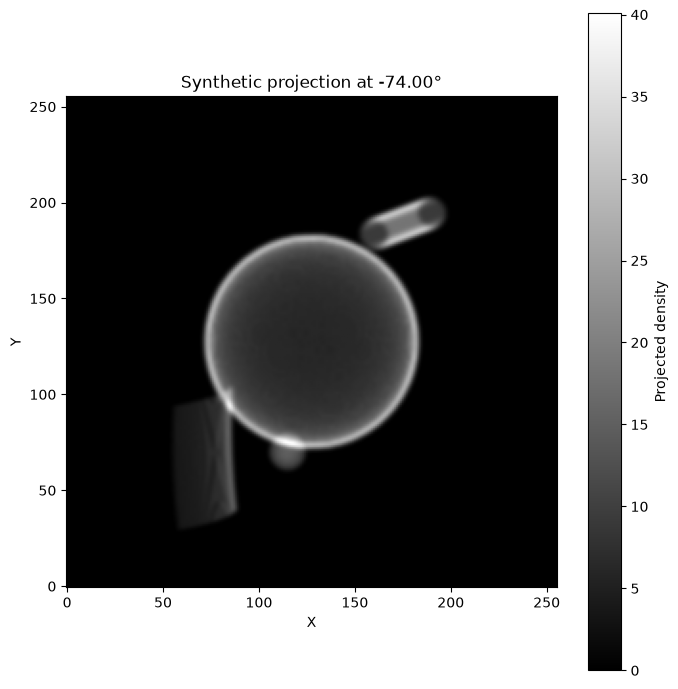

In [66]:
# Test the most negative/highest-magnitude tilt: -74 degrees

test_angle_high = float(tilt_angles[0])

V_high_tilt = rotate(
    V_axis_aligned,
    angle=test_angle_high,
    axes=(0, 2),
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)

P_high = V_high_tilt.sum(axis=0).astype(np.float32)

print("High-tilt angle:", test_angle_high)

print("\nProjection shape:", P_high.shape)
print("Min:", P_high.min())
print("Max:", P_high.max())
print("Mean:", P_high.mean())
print("SD:", P_high.std())
print("All finite:", np.isfinite(P_high).all())

# Check whether substantial signal reaches image boundaries
border = 5

border_signal = np.concatenate([
    P_high[:border, :].ravel(),
    P_high[-border:, :].ravel(),
    P_high[:, :border].ravel(),
    P_high[:, -border:].ravel()
])

print("\nMaximum absolute signal in 5-pixel border:",
      np.max(np.abs(border_signal)))

plt.figure(figsize=(7, 7))
plt.imshow(P_high, cmap="gray", origin="lower")
plt.title(f"Synthetic projection at {test_angle_high:.2f}°")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="Projected density")
plt.tight_layout()
plt.show()

In [67]:
# Generate complete 41-projection noiseless tilt series

n_tilts = len(tilt_angles)

projections_clean = np.zeros(
    (n_tilts, N_syn, N_syn),
    dtype=np.float32
)

for i, angle in enumerate(tilt_angles):

    V_rot = rotate(
        V_axis_aligned,
        angle=float(angle),
        axes=(0, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    ).astype(np.float32)

    projections_clean[i] = V_rot.sum(axis=0)

    print(
        f"{i+1:02d}/{n_tilts}  "
        f"angle={angle:7.2f}°  "
        f"max={projections_clean[i].max():.3f}"
    )


print("\nComplete tilt series")
print("--------------------")
print("Shape:", projections_clean.shape)
print("dtype:", projections_clean.dtype)

print("Min:", projections_clean.min())
print("Max:", projections_clean.max())
print("Mean:", projections_clean.mean())
print("SD:", projections_clean.std())

print("All finite:",
      np.isfinite(projections_clean).all())

01/41  angle= -74.00°  max=40.103
02/41  angle= -71.00°  max=40.397
03/41  angle= -68.01°  max=41.288
04/41  angle= -65.01°  max=42.236
05/41  angle= -62.01°  max=44.434
06/41  angle= -59.01°  max=44.335
07/41  angle= -56.00°  max=42.549
08/41  angle= -53.01°  max=41.582
09/41  angle= -50.00°  max=40.346
10/41  angle= -47.00°  max=40.343
11/41  angle= -44.00°  max=39.462
12/41  angle= -41.00°  max=39.651
13/41  angle= -38.00°  max=39.447
14/41  angle= -35.00°  max=38.772
15/41  angle= -32.01°  max=37.757
16/41  angle= -29.00°  max=36.611
17/41  angle= -26.01°  max=35.062
18/41  angle= -23.01°  max=33.652
19/41  angle= -20.01°  max=32.349
20/41  angle= -17.01°  max=31.114
21/41  angle= -14.01°  max=30.649
22/41  angle= -11.01°  max=30.723
23/41  angle=  -8.01°  max=30.819
24/41  angle=  -5.01°  max=30.728
25/41  angle=  -2.01°  max=30.750
26/41  angle=   0.99°  max=30.739
27/41  angle=   3.99°  max=30.738
28/41  angle=   6.99°  max=30.732
29/41  angle=   9.99°  max=30.626
30/41  angle= 

In [68]:
# Save the frozen noiseless synthetic tilt series

clean_tilt_path = synthetic_dir / "tiltseries_clean_41x256x256.npy"

np.save(
    clean_tilt_path,
    projections_clean
)

# Also save the exact acquisition geometry with it
geometry_path = synthetic_dir / "synthetic_acquisition_geometry.npz"

np.savez(
    geometry_path,
    tilt_angles=tilt_angles,
    tilt_axis_deg=tilt_axis_deg,
    tilt_axis_equiv_deg=tilt_axis_equiv_deg,
    axis_correction_deg=axis_correction_deg
)

print("Clean tilt series saved:", clean_tilt_path.exists())
print("Geometry saved:", geometry_path.exists())

# Reload to verify that the saved data are identical
test_reload = np.load(clean_tilt_path)

print("\nReloaded shape:", test_reload.shape)
print("Reloaded dtype:", test_reload.dtype)

print(
    "Exactly identical:",
    np.array_equal(test_reload, projections_clean)
)

print(
    "Maximum absolute difference:",
    np.max(np.abs(test_reload - projections_clean))
)

print("\nFile:")
print(clean_tilt_path)

Clean tilt series saved: True
Geometry saved: True

Reloaded shape: (41, 256, 256)
Reloaded dtype: float32
Exactly identical: True
Maximum absolute difference: 0.0

File:
/Users/krishnagupta/GeoFilter_ET_v2/data/synthetic/tiltseries_clean_41x256x256.npy


In [69]:
# Construct 1D ramp filter for WBP
# Detector X dimension = 256 pixels

n_detector = projections_clean.shape[2]

freq_detector = np.fft.fftfreq(n_detector)

# Ram-Lak / ramp filter
ramp_filter = np.abs(freq_detector).astype(np.float32)

print("Detector pixels:", n_detector)
print("Filter shape:", ramp_filter.shape)
print("Filter dtype:", ramp_filter.dtype)

print("\nMinimum:", ramp_filter.min())
print("Maximum:", ramp_filter.max())

print("DC value:", ramp_filter[0])
print("Nyquist value:", ramp_filter[n_detector // 2])

print("\nFirst 10 values:")
print(ramp_filter[:10])

print("\nAll finite:",
      np.isfinite(ramp_filter).all())

Detector pixels: 256
Filter shape: (256,)
Filter dtype: float32

Minimum: 0.0
Maximum: 0.5
DC value: 0.0
Nyquist value: 0.5

First 10 values:
[0.         0.00390625 0.0078125  0.01171875 0.015625   0.01953125
 0.0234375  0.02734375 0.03125    0.03515625]

All finite: True


In [70]:
# Ramp-filter all 41 noiseless projections

projections_filtered = np.zeros_like(
    projections_clean,
    dtype=np.float32
)

for i in range(len(tilt_angles)):

    P = projections_clean[i]

    # Fourier transform along detector X direction
    P_fft = np.fft.fft(P, axis=1)

    # Apply ramp filter
    P_fft_filtered = (
        P_fft * ramp_filter[None, :]
    )

    # Return to real space
    projections_filtered[i] = np.fft.ifft(
        P_fft_filtered,
        axis=1
    ).real.astype(np.float32)


print("Filtered tilt-series shape:",
      projections_filtered.shape)

print("dtype:",
      projections_filtered.dtype)

print("\nMin:",
      projections_filtered.min())

print("Max:",
      projections_filtered.max())

print("Mean:",
      projections_filtered.mean())

print("SD:",
      projections_filtered.std())

print("\nAll finite:",
      np.isfinite(projections_filtered).all())


# Inspect the projection closest to zero tilt
idx_zero = np.argmin(np.abs(tilt_angles))

print("\nNear-zero tilt angle:",
      tilt_angles[idx_zero])

print(
    "Original projection SD:",
    projections_clean[idx_zero].std()
)

print(
    "Ramp-filtered projection SD:",
    projections_filtered[idx_zero].std()
)

Filtered tilt-series shape: (41, 256, 256)
dtype: float32

Min: -0.90586734
Max: 1.8057613
Mean: -3.0444766e-12
SD: 0.12955219

All finite: True

Near-zero tilt angle: 0.99
Original projection SD: 4.806566
Ramp-filtered projection SD: 0.13033761


In [71]:
# Noiseless weighted back-projection (WBP)

recon_aligned = np.zeros(
    (N_syn, N_syn, N_syn),
    dtype=np.float32
)

for i, angle in enumerate(tilt_angles):

    # Expand 2D filtered projection uniformly through Z
    backproj = np.broadcast_to(
        projections_filtered[i][None, :, :],
        (N_syn, N_syn, N_syn)
    ).copy().astype(np.float32)

    # Undo the specimen tilt
    backproj_rot = rotate(
        backproj,
        angle=-float(angle),
        axes=(0, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    ).astype(np.float32)

    recon_aligned += backproj_rot

    print(
        f"{i+1:02d}/{len(tilt_angles)}  "
        f"angle={angle:7.2f}°"
    )


# Normalize by number of projections
recon_aligned /= float(len(tilt_angles))


# Undo the fixed in-plane tilt-axis alignment
recon_wbp_clean = rotate(
    recon_aligned,
    angle=-axis_correction_deg,
    axes=(1, 2),
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)


print("\nNoiseless WBP reconstruction")
print("----------------------------")

print("Shape:", recon_wbp_clean.shape)
print("dtype:", recon_wbp_clean.dtype)

print("\nMin:", recon_wbp_clean.min())
print("Max:", recon_wbp_clean.max())
print("Mean:", recon_wbp_clean.mean())
print("SD:", recon_wbp_clean.std())

print("\nAll finite:",
      np.isfinite(recon_wbp_clean).all())

01/41  angle= -74.00°
02/41  angle= -71.00°
03/41  angle= -68.01°
04/41  angle= -65.01°
05/41  angle= -62.01°
06/41  angle= -59.01°
07/41  angle= -56.00°
08/41  angle= -53.01°
09/41  angle= -50.00°
10/41  angle= -47.00°
11/41  angle= -44.00°
12/41  angle= -41.00°
13/41  angle= -38.00°
14/41  angle= -35.00°
15/41  angle= -32.01°
16/41  angle= -29.00°
17/41  angle= -26.01°
18/41  angle= -23.01°
19/41  angle= -20.01°
20/41  angle= -17.01°
21/41  angle= -14.01°
22/41  angle= -11.01°
23/41  angle=  -8.01°
24/41  angle=  -5.01°
25/41  angle=  -2.01°
26/41  angle=   0.99°
27/41  angle=   3.99°
28/41  angle=   6.99°
29/41  angle=   9.99°
30/41  angle=  12.99°
31/41  angle=  15.99°
32/41  angle=  18.99°
33/41  angle=  21.99°
34/41  angle=  24.99°
35/41  angle=  27.99°
36/41  angle=  30.99°
37/41  angle=  33.99°
38/41  angle=  36.99°
39/41  angle=  39.99°
40/41  angle=  42.99°
41/41  angle=  45.99°

Noiseless WBP reconstruction
----------------------------
Shape: (256, 256, 256)
dtype: float32



In [72]:
# Fit ONE global scale factor between WBP and known ground truth

ref = phantom_ref.astype(np.float64)
rec = recon_wbp_clean.astype(np.float64)

scale_factor = np.sum(ref * rec) / np.sum(rec * rec)

recon_wbp_scaled = (
    recon_wbp_clean * scale_factor
).astype(np.float32)


# Error against known continuous ground truth
error_wbp = recon_wbp_scaled - phantom_ref

rmse_wbp = np.sqrt(
    np.mean(error_wbp**2)
)

nrmse_wbp = rmse_wbp / phantom_ref.std()

# Pearson correlation
corr_wbp = np.corrcoef(
    phantom_ref.ravel(),
    recon_wbp_scaled.ravel()
)[0, 1]


print("Ground-truth comparison")
print("-----------------------")

print("Scale factor:", scale_factor)

print("\nScaled reconstruction:")
print("Min:", recon_wbp_scaled.min())
print("Max:", recon_wbp_scaled.max())
print("Mean:", recon_wbp_scaled.mean())
print("SD:", recon_wbp_scaled.std())

print("\nGround truth:")
print("Mean:", phantom_ref.mean())
print("SD:", phantom_ref.std())

print("\nMetrics:")
print("RMSE:", rmse_wbp)
print("NRMSE:", nrmse_wbp)
print("Pearson correlation:", corr_wbp)

print("\nAll finite:",
      np.isfinite(recon_wbp_scaled).all())

Ground-truth comparison
-----------------------
Scale factor: 2.2456771751221254

Scaled reconstruction:
Min: -0.34737766
Max: 0.89035964
Mean: 0.0019573537
SD: 0.055523667

Ground truth:
Mean: 0.008568583
SD: 0.07135437

Metrics:
RMSE: 0.04558681
NRMSE: 0.63887906
Pearson correlation: 0.7748734666871483

All finite: True


In [73]:
# Fit global linear calibration:
# ground_truth ≈ a * reconstruction + b

rec_flat = recon_wbp_clean.astype(np.float64).ravel()
ref_flat = phantom_ref.astype(np.float64).ravel()

A = np.column_stack([
    rec_flat,
    np.ones_like(rec_flat)
])

a_wbp, b_wbp = np.linalg.lstsq(
    A,
    ref_flat,
    rcond=None
)[0]

recon_wbp_calibrated = (
    a_wbp * recon_wbp_clean + b_wbp
).astype(np.float32)

# Ground-truth error
error_wbp_cal = recon_wbp_calibrated - phantom_ref

rmse_wbp_cal = np.sqrt(
    np.mean(error_wbp_cal**2)
)

nrmse_wbp_cal = (
    rmse_wbp_cal / phantom_ref.std()
)

corr_wbp_cal = np.corrcoef(
    phantom_ref.ravel(),
    recon_wbp_calibrated.ravel()
)[0, 1]

print("Linear calibration")
print("------------------")
print("a:", a_wbp)
print("b:", b_wbp)

print("\nCalibrated reconstruction:")
print("Mean:", recon_wbp_calibrated.mean())
print("SD:", recon_wbp_calibrated.std())
print("Min:", recon_wbp_calibrated.min())
print("Max:", recon_wbp_calibrated.max())

print("\nGround-truth metrics:")
print("RMSE:", rmse_wbp_cal)
print("NRMSE:", nrmse_wbp_cal)
print("Pearson correlation:", corr_wbp_cal)

print("\nAll finite:",
      np.isfinite(recon_wbp_calibrated).all())

Linear calibration
------------------
a: 2.236250848892793
b: 0.00661944450839138

Calibrated reconstruction:
Mean: 0.008568582
SD: 0.055290602
Min: -0.3393001
Max: 0.89324176

Ground-truth metrics:
RMSE: 0.04510426
NRMSE: 0.6321163
Pearson correlation: 0.7748734666763675

All finite: True


In [74]:
# Save frozen noiseless WBP baseline and metrics

np.save(
    synthetic_results / "recon_wbp_clean_raw.npy",
    recon_wbp_clean
)

np.save(
    synthetic_results / "recon_wbp_clean_calibrated.npy",
    recon_wbp_calibrated
)

np.savez(
    synthetic_results / "noiseless_wbp_baseline_metrics.npz",

    calibration_a=a_wbp,
    calibration_b=b_wbp,

    rmse=rmse_wbp_cal,
    nrmse=nrmse_wbp_cal,
    pearson=corr_wbp_cal,

    reconstruction_mean=recon_wbp_calibrated.mean(),
    reconstruction_sd=recon_wbp_calibrated.std(),

    ground_truth_mean=phantom_ref.mean(),
    ground_truth_sd=phantom_ref.std()
)

print("Saved noiseless WBP baseline")
print("----------------------------")

for filename in [
    "recon_wbp_clean_raw.npy",
    "recon_wbp_clean_calibrated.npy",
    "noiseless_wbp_baseline_metrics.npz"
]:
    path = synthetic_results / filename
    print(filename, "->", path.exists())

print("\nFrozen baseline:")
print("NRMSE:", rmse_wbp_cal / phantom_ref.std())
print("Pearson:", corr_wbp_cal)

Saved noiseless WBP baseline
----------------------------
recon_wbp_clean_raw.npy -> True
recon_wbp_clean_calibrated.npy -> True
noiseless_wbp_baseline_metrics.npz -> True

Frozen baseline:
NRMSE: 0.6321163
Pearson: 0.7748734666763675


In [75]:
# Prepare synthetic WBP for GeoFilter-ET
# IMPORTANT: use RAW WBP, not ground-truth-calibrated WBP

V_syn_raw = recon_wbp_clean.astype(np.float32)

# Same robust normalization used for Position056
V_syn = robust_normalize(V_syn_raw)

print("Synthetic WBP before normalization")
print("----------------------------------")
print("Mean:", V_syn_raw.mean())
print("SD:", V_syn_raw.std())
print("Min:", V_syn_raw.min())
print("Max:", V_syn_raw.max())

print("\nSynthetic WBP after robust normalization")
print("----------------------------------------")
print("Shape:", V_syn.shape)
print("dtype:", V_syn.dtype)

print("Mean:", V_syn.mean())
print("SD:", V_syn.std())
print("Median:", np.median(V_syn))
print("Min:", V_syn.min())
print("Max:", V_syn.max())

print("\nAll finite:", np.isfinite(V_syn).all())

Synthetic WBP before normalization
----------------------------------
Mean: 0.00087160943
SD: 0.024724688
Min: -0.15468727
Max: 0.39647713

Synthetic WBP after robust normalization
----------------------------------------
Shape: (256, 256, 256)
dtype: float32
Mean: 0.33867967
SD: 9.607226
Median: 0.0
Min: -60.106544
Max: 154.05838

All finite: True


In [76]:
# Diagnose robust-normalization scale for synthetic WBP

syn_median = np.median(V_syn_raw)

syn_mad = np.median(
    np.abs(V_syn_raw - syn_median)
)

syn_robust_scale = 1.4826 * syn_mad + 1e-8

abs_dev = np.abs(
    V_syn_raw - syn_median
)

print("Synthetic WBP normalization diagnosis")
print("-------------------------------------")

print("Median:", syn_median)
print("MAD:", syn_mad)
print("Robust scale:", syn_robust_scale)

print("\nRaw WBP SD:", V_syn_raw.std())
print(
    "SD / robust scale:",
    V_syn_raw.std() / syn_robust_scale
)

print("\nAbsolute-deviation percentiles:")
print("50% :", np.percentile(abs_dev, 50))
print("75% :", np.percentile(abs_dev, 75))
print("90% :", np.percentile(abs_dev, 90))
print("95% :", np.percentile(abs_dev, 95))
print("99% :", np.percentile(abs_dev, 99))
print("99.9%:", np.percentile(abs_dev, 99.9))

print("\nFraction exactly zero:",
      np.mean(V_syn_raw == 0))

print("All finite:",
      np.isfinite(V_syn_raw).all())

Synthetic WBP normalization diagnosis
-------------------------------------
Median: 0.0
MAD: 0.0017358297
Robust scale: 0.0025735511

Raw WBP SD: 0.024724688
SD / robust scale: 9.607226

Absolute-deviation percentiles:
50% : 0.0017358297
75% : 0.0067112427
90% : 0.01677899
95% : 0.026151832
99% : 0.0913216
99.9%: 0.3379616

Fraction exactly zero: 0.29099154472351074
All finite: True


In [77]:
# Fourier transform of normalized synthetic WBP

F_syn = np.fft.fftshift(
    np.fft.fftn(V_syn)
)

print("Synthetic Fourier volume")
print("------------------------")

print("F_syn shape:", F_syn.shape)
print("H shape:", H.shape)

print("Shapes match:",
      F_syn.shape == H.shape)

print("\nF_syn dtype:", F_syn.dtype)

print("Maximum magnitude:",
      np.abs(F_syn).max())

print("Mean magnitude:",
      np.abs(F_syn).mean())

print("\nH range:",
      H.min(), "to", H.max())

print("H center:",
      H[N_syn//2, N_syn//2, N_syn//2])

print("\nF_syn all finite:",
      np.isfinite(F_syn).all())

print("H all finite:",
      np.isfinite(H).all())

Synthetic Fourier volume
------------------------
F_syn shape: (256, 256, 256)
H shape: (256, 256, 256)
Shapes match: True

F_syn dtype: complex64
Maximum magnitude: 1.8339742e+07
Mean magnitude: 4607.79

H range: 0.050677966 to 1.0
H center: 1.0

F_syn all finite: True
H all finite: True


In [78]:
# Apply frozen geometry-aware Fourier attenuation
# to the synthetic noiseless WBP

F_syn_filtered = (
    F_syn * H
)

V_syn_fourier = np.fft.ifftn(
    np.fft.ifftshift(F_syn_filtered)
).real.astype(np.float32)


print("Synthetic Fourier-filtered volume")
print("---------------------------------")

print("Shape:", V_syn_fourier.shape)
print("dtype:", V_syn_fourier.dtype)

print("\nOriginal normalized WBP:")
print("Mean:", V_syn.mean())
print("SD:", V_syn.std())
print("Min:", V_syn.min())
print("Max:", V_syn.max())

print("\nFourier-filtered WBP:")
print("Mean:", V_syn_fourier.mean())
print("SD:", V_syn_fourier.std())
print("Min:", V_syn_fourier.min())
print("Max:", V_syn_fourier.max())

print("\nRemoved component:")
V_syn_fourier_removed = (
    V_syn - V_syn_fourier
).astype(np.float32)

print("Mean:", V_syn_fourier_removed.mean())
print("SD:", V_syn_fourier_removed.std())
print("Min:", V_syn_fourier_removed.min())
print("Max:", V_syn_fourier_removed.max())

print("\nAll finite:",
      np.isfinite(V_syn_fourier).all())

Synthetic Fourier-filtered volume
---------------------------------
Shape: (256, 256, 256)
dtype: float32

Original normalized WBP:
Mean: 0.33867967
SD: 9.607226
Min: -60.106544
Max: 154.05838

Fourier-filtered WBP:
Mean: 0.33867967
SD: 9.535746
Min: -58.949516
Max: 151.04799

Removed component:
Mean: 6.3139396e-09
SD: 0.23380814
Min: -5.496914
Max: 7.015457

All finite: True


In [79]:
# Structure-tensor preprocessing for synthetic WBP
# Same frozen parameters as Position056

V_syn_pre = gaussian_filter(
    V_syn,
    sigma=1.0,
    mode="nearest"
).astype(np.float32)

Gz_syn = sobel(
    V_syn_pre,
    axis=0,
    mode="nearest"
)

Gy_syn = sobel(
    V_syn_pre,
    axis=1,
    mode="nearest"
)

Gx_syn = sobel(
    V_syn_pre,
    axis=2,
    mode="nearest"
)

print("Synthetic structure-tensor preprocessing")
print("----------------------------------------")

print("Pre-smoothed volume:")
print("Mean:", V_syn_pre.mean())
print("SD:", V_syn_pre.std())

print("\nGradient SD:")
print("Gx:", Gx_syn.std())
print("Gy:", Gy_syn.std())
print("Gz:", Gz_syn.std())

print("\nGradient maximum absolute values:")
print("Gx:", np.max(np.abs(Gx_syn)))
print("Gy:", np.max(np.abs(Gy_syn)))
print("Gz:", np.max(np.abs(Gz_syn)))

print("\nAll finite:")
print("V_pre:", np.isfinite(V_syn_pre).all())
print("Gx:", np.isfinite(Gx_syn).all())
print("Gy:", np.isfinite(Gy_syn).all())
print("Gz:", np.isfinite(Gz_syn).all())

Synthetic structure-tensor preprocessing
----------------------------------------
Pre-smoothed volume:
Mean: 0.3386826
SD: 8.674577

Gradient SD:
Gx: 67.58034
Gy: 59.23304
Gz: 48.557728

Gradient maximum absolute values:
Gx: 1210.8134
Gy: 1535.1354
Gz: 1246.1085

All finite:
V_pre: True
Gx: True
Gy: True
Gz: True


In [80]:
# Build synthetic structure-tensor components
# Frozen parameter: sigma_tensor = 2.0

sigma_tensor_syn = 2.0

Jxx_syn = gaussian_filter(
    Gx_syn * Gx_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

Jyy_syn = gaussian_filter(
    Gy_syn * Gy_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

Jzz_syn = gaussian_filter(
    Gz_syn * Gz_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

Jxy_syn = gaussian_filter(
    Gx_syn * Gy_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

Jxz_syn = gaussian_filter(
    Gx_syn * Gz_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

Jyz_syn = gaussian_filter(
    Gy_syn * Gz_syn,
    sigma=sigma_tensor_syn,
    mode="nearest"
).astype(np.float32)

print("Synthetic structure tensor")
print("--------------------------")

print("Mean diagonal components:")
print("Jxx:", Jxx_syn.mean())
print("Jyy:", Jyy_syn.mean())
print("Jzz:", Jzz_syn.mean())

print("\nMaximum diagonal components:")
print("Jxx:", Jxx_syn.max())
print("Jyy:", Jyy_syn.max())
print("Jzz:", Jzz_syn.max())

print("\nAll finite:")
print("Jxx:", np.isfinite(Jxx_syn).all())
print("Jyy:", np.isfinite(Jyy_syn).all())
print("Jzz:", np.isfinite(Jzz_syn).all())
print("Jxy:", np.isfinite(Jxy_syn).all())
print("Jxz:", np.isfinite(Jxz_syn).all())
print("Jyz:", np.isfinite(Jyz_syn).all())

Synthetic structure tensor
--------------------------
Mean diagonal components:
Jxx: 4566.789
Jyy: 3508.6643
Jzz: 2356.7236

Maximum diagonal components:
Jxx: 706272.8
Jyy: 1.00525256e+06
Jzz: 675899.6

All finite:
Jxx: True
Jyy: True
Jzz: True
Jxy: True
Jxz: True
Jyz: True


In [81]:
# Compute structure-tensor eigenvalues in Z chunks
# Eigenvalues will be stored as:
# lambda1 >= lambda2 >= lambda3

N = V_syn.shape[0]

lambda1_syn = np.empty(V_syn.shape, dtype=np.float32)
lambda2_syn = np.empty(V_syn.shape, dtype=np.float32)
lambda3_syn = np.empty(V_syn.shape, dtype=np.float32)

chunk_size = 16

for z0 in range(0, N, chunk_size):

    z1 = min(z0 + chunk_size, N)

    shape_chunk = (z1 - z0, N, N)

    # Construct tensor matrix for this Z chunk
    T = np.empty(
        shape_chunk + (3, 3),
        dtype=np.float32
    )

    T[..., 0, 0] = Jxx_syn[z0:z1]
    T[..., 1, 1] = Jyy_syn[z0:z1]
    T[..., 2, 2] = Jzz_syn[z0:z1]

    T[..., 0, 1] = Jxy_syn[z0:z1]
    T[..., 1, 0] = Jxy_syn[z0:z1]

    T[..., 0, 2] = Jxz_syn[z0:z1]
    T[..., 2, 0] = Jxz_syn[z0:z1]

    T[..., 1, 2] = Jyz_syn[z0:z1]
    T[..., 2, 1] = Jyz_syn[z0:z1]

    # eigvalsh returns ascending order:
    # e0 <= e1 <= e2
    eigvals = np.linalg.eigvalsh(T)

    lambda3_syn[z0:z1] = eigvals[..., 0]
    lambda2_syn[z0:z1] = eigvals[..., 1]
    lambda1_syn[z0:z1] = eigvals[..., 2]

    print(f"Processed Z slices {z0:3d} to {z1-1:3d}")

    del T, eigvals


print("\nSynthetic tensor eigenvalues")
print("----------------------------")

print("lambda1:")
print(" min =", lambda1_syn.min())
print(" max =", lambda1_syn.max())
print(" mean =", lambda1_syn.mean())

print("\nlambda2:")
print(" min =", lambda2_syn.min())
print(" max =", lambda2_syn.max())
print(" mean =", lambda2_syn.mean())

print("\nlambda3:")
print(" min =", lambda3_syn.min())
print(" max =", lambda3_syn.max())
print(" mean =", lambda3_syn.mean())

print("\nOrdering checks:")
print(
    "lambda1 >= lambda2:",
    np.all(lambda1_syn >= lambda2_syn)
)

print(
    "lambda2 >= lambda3:",
    np.all(lambda2_syn >= lambda3_syn)
)

print("\nAll finite:",
      np.isfinite(lambda1_syn).all()
      and np.isfinite(lambda2_syn).all()
      and np.isfinite(lambda3_syn).all())

Processed Z slices   0 to  15
Processed Z slices  16 to  31
Processed Z slices  32 to  47
Processed Z slices  48 to  63
Processed Z slices  64 to  79
Processed Z slices  80 to  95
Processed Z slices  96 to 111
Processed Z slices 112 to 127
Processed Z slices 128 to 143
Processed Z slices 144 to 159
Processed Z slices 160 to 175
Processed Z slices 176 to 191
Processed Z slices 192 to 207
Processed Z slices 208 to 223
Processed Z slices 224 to 239
Processed Z slices 240 to 255

Synthetic tensor eigenvalues
----------------------------
lambda1:
 min = 0.0
 max = 1.0662736e+06
 mean = 10157.572

lambda2:
 min = -0.0
 max = 100890.11
 mean = 237.25017

lambda3:
 min = -3.8471e-41
 max = 20899.367
 mean = 37.35375

Ordering checks:
lambda1 >= lambda2: True
lambda2 >= lambda3: True

All finite: True


In [82]:
# Frozen GeoFilter-ET structure confidence
# Same definition used for Position056

eps = 1e-8

# Numerical safeguard only:
# structure-tensor eigenvalues should be non-negative
l1 = np.maximum(lambda1_syn, 0.0)
l2 = np.maximum(lambda2_syn, 0.0)
l3 = np.maximum(lambda3_syn, 0.0)

# Total local tensor strength
strength_syn = l1 + l2 + l3

# One-dominant structural anisotropy
anisotropy_syn = (
    (l1 - l2) /
    (strength_syn + eps)
).astype(np.float32)

# Same percentile-based strength normalization
strength_p95_syn = np.percentile(
    strength_syn,
    95
)

strength_conf_syn = np.clip(
    strength_syn / (strength_p95_syn + eps),
    0.0,
    1.0
).astype(np.float32)

# Raw structural confidence
C_raw_syn = (
    anisotropy_syn * strength_conf_syn
).astype(np.float32)

# Frozen gamma = 0.5
gamma_syn = 0.5

C_syn = np.power(
    np.clip(C_raw_syn, 0.0, 1.0),
    gamma_syn
).astype(np.float32)


print("Synthetic GeoFilter structure confidence")
print("----------------------------------------")

print("Strength p95:", strength_p95_syn)

print("\nAnisotropy:")
print(" min:", anisotropy_syn.min())
print(" max:", anisotropy_syn.max())
print(" mean:", anisotropy_syn.mean())
print(" median:", np.median(anisotropy_syn))

print("\nStrength confidence:")
print(" min:", strength_conf_syn.min())
print(" max:", strength_conf_syn.max())
print(" mean:", strength_conf_syn.mean())

print("\nRaw confidence:")
print(" min:", C_raw_syn.min())
print(" max:", C_raw_syn.max())
print(" mean:", C_raw_syn.mean())

print("\nFinal confidence (gamma = 0.5):")
print(" min:", C_syn.min())
print(" max:", C_syn.max())
print(" mean:", C_syn.mean())
print(" median:", np.median(C_syn))

print("\nAll finite:", np.isfinite(C_syn).all())
print(
    "Within [0,1]:",
    C_syn.min() >= 0 and C_syn.max() <= 1
)

Synthetic GeoFilter structure confidence
----------------------------------------
Strength p95: 12988.963

Anisotropy:
 min: 0.0
 max: 0.9999655
 mean: 0.55711603
 median: 0.6483685

Strength confidence:
 min: 0.0
 max: 1.0
 mean: 0.12040925

Raw confidence:
 min: 0.0
 max: 0.99922144
 mean: 0.09543662

Final confidence (gamma = 0.5):
 min: 0.0
 max: 0.99961066
 mean: 0.17172599
 median: 0.052370496

All finite: True
Within [0,1]: True


In [83]:
# Apply full frozen GeoFilter-ET adaptive blending
# Synthetic noiseless WBP

V_syn_geofilter = (
    C_syn * V_syn
    + (1.0 - C_syn) * V_syn_fourier
).astype(np.float32)

# Component removed by full GeoFilter-ET
removed_syn_geofilter = (
    V_syn - V_syn_geofilter
).astype(np.float32)


print("Full GeoFilter-ET synthetic output")
print("----------------------------------")

print("Original normalized WBP:")
print(" Mean:", V_syn.mean())
print(" SD:", V_syn.std())
print(" Min:", V_syn.min())
print(" Max:", V_syn.max())

print("\nFourier-only:")
print(" Mean:", V_syn_fourier.mean())
print(" SD:", V_syn_fourier.std())
print(" Min:", V_syn_fourier.min())
print(" Max:", V_syn_fourier.max())

print("\nFull GeoFilter-ET:")
print(" Mean:", V_syn_geofilter.mean())
print(" SD:", V_syn_geofilter.std())
print(" Min:", V_syn_geofilter.min())
print(" Max:", V_syn_geofilter.max())

print("\nRemoved by Fourier-only:")
print(" SD:", (V_syn - V_syn_fourier).std())

print("\nRemoved by full GeoFilter-ET:")
print(" Mean:", removed_syn_geofilter.mean())
print(" SD:", removed_syn_geofilter.std())
print(" Min:", removed_syn_geofilter.min())
print(" Max:", removed_syn_geofilter.max())

print("\nDifference between GeoFilter and Fourier-only:")
print(
    " SD:",
    (V_syn_geofilter - V_syn_fourier).std()
)

print("\nAll finite:",
      np.isfinite(V_syn_geofilter).all())

Full GeoFilter-ET synthetic output
----------------------------------
Original normalized WBP:
 Mean: 0.33867967
 SD: 9.607226
 Min: -60.106544
 Max: 154.05838

Fourier-only:
 Mean: 0.33867967
 SD: 9.535746
 Min: -58.949516
 Max: 151.04799

Full GeoFilter-ET:
 Mean: 0.33852756
 SD: 9.595651
 Min: -59.771294
 Max: 154.0393

Removed by Fourier-only:
 SD: 0.23380814

Removed by full GeoFilter-ET:
 Mean: 0.00015211913
 SD: 0.104405895
 Min: -2.4488993
 Max: 3.5767365

Difference between GeoFilter and Fourier-only:
 SD: 0.17806885

All finite: True


In [84]:
# Find Gaussian sigma giving the same removed-signal SD
# as full GeoFilter-ET

from scipy.optimize import brentq

target_removed_sd_syn = removed_syn_geofilter.std()

print("Target GeoFilter removed SD:",
      target_removed_sd_syn)


def gaussian_removed_sd_syn(sigma):

    Vg = gaussian_filter(
        V_syn,
        sigma=sigma,
        mode="nearest"
    ).astype(np.float32)

    removed = V_syn - Vg

    return float(removed.std())


# First inspect several sigma values
test_sigmas = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60
]

print("\nGaussian removed-signal SD:")
print("---------------------------")

for s in test_sigmas:

    sd = gaussian_removed_sd_syn(s)

    print(
        f"sigma = {s:.2f}   "
        f"removed SD = {sd:.8f}"
    )


# Function whose root gives matched sigma
def objective_syn(sigma):

    return (
        gaussian_removed_sd_syn(sigma)
        - target_removed_sd_syn
    )


# Automatically locate a valid bracket
sigma_grid = np.linspace(
    0.05,
    1.50,
    60
)

values = [
    objective_syn(s)
    for s in sigma_grid
]

bracket = None

for i in range(len(sigma_grid) - 1):

    if values[i] * values[i + 1] <= 0:

        bracket = (
            sigma_grid[i],
            sigma_grid[i + 1]
        )

        break


print("\nRoot bracket:", bracket)


if bracket is None:

    print(
        "No matching Gaussian sigma found "
        "in the tested range."
    )

else:

    sigma_gaussian_syn = brentq(
        objective_syn,
        bracket[0],
        bracket[1]
    )

    print(
        "Matched Gaussian sigma:",
        sigma_gaussian_syn
    )

    print(
        "Matched Gaussian removed SD:",
        gaussian_removed_sd_syn(
            sigma_gaussian_syn
        )
    )

    print(
        "Difference from GeoFilter target:",
        gaussian_removed_sd_syn(
            sigma_gaussian_syn
        )
        - target_removed_sd_syn
    )

Target GeoFilter removed SD: 0.104405895

Gaussian removed-signal SD:
---------------------------
sigma = 0.10   removed SD = 0.00000000
sigma = 0.20   removed SD = 0.00001571
sigma = 0.30   removed SD = 0.01615348
sigma = 0.40   removed SD = 0.16817392
sigma = 0.50   removed SD = 0.43758383
sigma = 0.60   removed SD = 0.69503099

Root bracket: (np.float64(0.36949152542372876), np.float64(0.39406779661016944))
Matched Gaussian sigma: 0.37066145675437373
Matched Gaussian removed SD: 0.10440589487552643
Difference from GeoFilter target: 0.0


In [85]:
# Create final matched-strength Gaussian control

V_syn_gaussian = gaussian_filter(
    V_syn,
    sigma=sigma_gaussian_syn,
    mode="nearest"
).astype(np.float32)

removed_syn_gaussian = (
    V_syn - V_syn_gaussian
).astype(np.float32)


print("Matched Gaussian synthetic control")
print("----------------------------------")

print("Gaussian sigma:",
      sigma_gaussian_syn)

print("\nGaussian-filtered volume:")
print(" Mean:", V_syn_gaussian.mean())
print(" SD:", V_syn_gaussian.std())
print(" Min:", V_syn_gaussian.min())
print(" Max:", V_syn_gaussian.max())

print("\nRemoved by Gaussian:")
print(" Mean:", removed_syn_gaussian.mean())
print(" SD:", removed_syn_gaussian.std())
print(" Min:", removed_syn_gaussian.min())
print(" Max:", removed_syn_gaussian.max())

print("\nGeoFilter removed SD:",
      removed_syn_geofilter.std())

print("Gaussian removed SD:",
      removed_syn_gaussian.std())

print(
    "Absolute SD difference:",
    abs(
        removed_syn_geofilter.std()
        - removed_syn_gaussian.std()
    )
)

print("\nAll finite:",
      np.isfinite(V_syn_gaussian).all())

Matched Gaussian synthetic control
----------------------------------
Gaussian sigma: 0.37066145675437373

Gaussian-filtered volume:
 Mean: 0.33867967
 SD: 9.548352
 Min: -59.442764
 Max: 152.3179

Removed by Gaussian:
 Mean: -1.3585577e-10
 SD: 0.104405895
 Min: -1.3412113
 Max: 1.9881287

GeoFilter removed SD: 0.104405895
Gaussian removed SD: 0.104405895
Absolute SD difference: 0.0

All finite: True


In [86]:
# First ground-truth comparison
# Raw WBP vs Fourier-only vs matched Gaussian vs full GeoFilter-ET
#
# Each method is independently linearly calibrated to phantom_ref
# ONLY for evaluation.

from scipy.stats import pearsonr

GT = phantom_ref.astype(np.float32)


def evaluate_against_gt(volume, ground_truth):

    x = volume.ravel().astype(np.float64)
    y = ground_truth.ravel().astype(np.float64)

    # Least-squares affine calibration:
    # ground_truth ~= a * volume + b
    x_mean = x.mean()
    y_mean = y.mean()

    covariance = np.mean(
        (x - x_mean) * (y - y_mean)
    )

    variance_x = np.mean(
        (x - x_mean) ** 2
    )

    a = covariance / (variance_x + 1e-20)
    b = y_mean - a * x_mean

    calibrated = (
        a * volume.astype(np.float64) + b
    )

    error = calibrated - ground_truth

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    # Same NRMSE definition used previously:
    # RMSE divided by ground-truth SD
    nrmse = rmse / ground_truth.std()

    correlation = pearsonr(x, y).statistic

    return {
        "a": a,
        "b": b,
        "rmse": rmse,
        "nrmse": nrmse,
        "pearson": correlation
    }


results_gt = {
    "Raw WBP":
        evaluate_against_gt(V_syn, GT),

    "Fourier-only":
        evaluate_against_gt(V_syn_fourier, GT),

    "Matched Gaussian":
        evaluate_against_gt(V_syn_gaussian, GT),

    "GeoFilter-ET":
        evaluate_against_gt(V_syn_geofilter, GT)
}


print("GROUND-TRUTH COMPARISON")
print("=======================")

for name, r in results_gt.items():

    print(f"\n{name}")
    print("-" * len(name))

    print("Calibration a:", r["a"])
    print("Calibration b:", r["b"])
    print("RMSE:", r["rmse"])
    print("NRMSE:", r["nrmse"])
    print("Pearson:", r["pearson"])


print("\nNRMSE change relative to raw WBP")
print("--------------------------------")

baseline_nrmse = results_gt["Raw WBP"]["nrmse"]

for name in [
    "Fourier-only",
    "Matched Gaussian",
    "GeoFilter-ET"
]:

    change = (
        results_gt[name]["nrmse"]
        - baseline_nrmse
    )

    percent = (
        (baseline_nrmse
         - results_gt[name]["nrmse"])
        / baseline_nrmse
        * 100.0
    )

    print(
        f"{name:18s}: "
        f"change = {change:+.6f}, "
        f"improvement = {percent:+.3f}%"
    )


print("\nGeoFilter vs matched Gaussian")
print("-----------------------------")

gf = results_gt["GeoFilter-ET"]
gauss = results_gt["Matched Gaussian"]

print(
    "NRMSE advantage:",
    gauss["nrmse"] - gf["nrmse"]
)

print(
    "Pearson advantage:",
    gf["pearson"] - gauss["pearson"]
)

GROUND-TRUTH COMPARISON

Raw WBP
-------
Calibration a: 0.005755105930662075
Calibration b: 0.006619444507886074
RMSE: 0.04510426279951787
NRMSE: 0.6321163622870001
Pearson: 0.7748734666971626

Fourier-only
------------
Calibration a: 0.0058044778353111455
Calibration b: 0.0066027232837555325
RMSE: 0.04503132539747737
NRMSE: 0.631094176746413
Pearson: 0.775706210486239

Matched Gaussian
----------------
Calibration a: 0.005793226508349623
Calibration b: 0.0066065338421113
RMSE: 0.04507340127026403
NRMSE: 0.6316838515575096
Pearson: 0.7752260938351637

GeoFilter-ET
------------
Calibration a: 0.00576828507524449
Calibration b: 0.006615858465960017
RMSE: 0.04503080846552812
NRMSE: 0.6310869321729952
Pearson: 0.7757121044246887

NRMSE change relative to raw WBP
--------------------------------
Fourier-only      : change = -0.001022, improvement = +0.162%
Matched Gaussian  : change = -0.000433, improvement = +0.068%
GeoFilter-ET      : change = -0.001029, improvement = +0.163%

GeoFilter v

In [87]:
# Region-specific ground-truth evaluation
# Compare STRUCTURE vs BACKGROUND performance
#
# IMPORTANT:
# We use the geometric phantom ONLY to define masks.
# No GeoFilter parameters are changed.

# Structure mask from known geometric ground truth
structure_mask = phantom > 0

# Background mask
background_mask = ~structure_mask

print("Region sizes")
print("------------")
print("Structure voxels:",
      np.sum(structure_mask))

print("Background voxels:",
      np.sum(background_mask))

print("Structure fraction:",
      np.mean(structure_mask))


def calibrated_volume(volume, ground_truth):

    x = volume.ravel().astype(np.float64)
    y = ground_truth.ravel().astype(np.float64)

    xm = x.mean()
    ym = y.mean()

    a = np.mean(
        (x - xm) * (y - ym)
    ) / (
        np.mean((x - xm)**2) + 1e-20
    )

    b = ym - a * xm

    return (
        a * volume.astype(np.float64) + b
    )


# Use one GLOBAL affine calibration per method,
# exactly as in the previous evaluation.
calibrated_methods = {
    "Raw WBP":
        calibrated_volume(V_syn, GT),

    "Fourier-only":
        calibrated_volume(V_syn_fourier, GT),

    "Matched Gaussian":
        calibrated_volume(V_syn_gaussian, GT),

    "GeoFilter-ET":
        calibrated_volume(V_syn_geofilter, GT)
}


print("\nREGION-SPECIFIC RMSE")
print("====================")

region_results = {}

for name, vol in calibrated_methods.items():

    error = vol - GT

    structure_rmse = np.sqrt(
        np.mean(
            error[structure_mask] ** 2
        )
    )

    background_rmse = np.sqrt(
        np.mean(
            error[background_mask] ** 2
        )
    )

    region_results[name] = {
        "structure_rmse": structure_rmse,
        "background_rmse": background_rmse
    }

    print(f"\n{name}")
    print("-" * len(name))

    print(
        "Structure RMSE:",
        structure_rmse
    )

    print(
        "Background RMSE:",
        background_rmse
    )


print("\nGeoFilter vs matched Gaussian")
print("=============================")

gf_s = region_results[
    "GeoFilter-ET"
]["structure_rmse"]

ga_s = region_results[
    "Matched Gaussian"
]["structure_rmse"]

gf_b = region_results[
    "GeoFilter-ET"
]["background_rmse"]

ga_b = region_results[
    "Matched Gaussian"
]["background_rmse"]

print(
    "Structure RMSE advantage:",
    ga_s - gf_s
)

print(
    "Background RMSE advantage:",
    ga_b - gf_b
)

Region sizes
------------
Structure voxels: 154183
Background voxels: 16623033
Structure fraction: 0.009190022945404053

REGION-SPECIFIC RMSE

Raw WBP
-------
Structure RMSE: 0.37709476565059524
Background RMSE: 0.02709829155650877

Fourier-only
------------
Structure RMSE: 0.3773641831067122
Background RMSE: 0.026940616935513872

Matched Gaussian
----------------
Structure RMSE: 0.37701982254964717
Background RMSE: 0.027056104103413768

GeoFilter-ET
------------
Structure RMSE: 0.37679583586826615
Background RMSE: 0.027013431111071552

GeoFilter vs matched Gaussian
Structure RMSE advantage: 0.00022398668138101652
Background RMSE advantage: 4.267299234221589e-05


In [88]:
# Component-specific ground-truth RMSE
# Large membrane, small sphere, tube, curved sheet

# Reconstruct the SAME masks used when building the phantom

# 1. Large spherical membrane
large_membrane_mask = (
    np.abs(R3D - 55.0) <= 1.5
)

# 2. Small solid sphere
small_sphere_mask = (
    (X - 70.0)**2
    + (Y + 65.0)**2
    + (Z - 35.0)**2
    <= 10.0**2
)

# 3. Hollow tube
tube_radial = np.sqrt(
    (Y - 65.0)**2
    + (Z + 60.0)**2
)

tube_mask = (
    (tube_radial <= 9.0)
    & (tube_radial >= 6.0)
    & (X >= -85.0)
    & (X <= 25.0)
)

# 4. Curved membrane sheet
Z_surface = (
    45.0
    + 0.0025 * (X + 30.0)**2
    - 0.0015 * (Y + 55.0)**2
)

sheet_mask = (
    (X >= -85.0)
    & (X <= 20.0)
    & (Y >= -90.0)
    & (Y <= -25.0)
    & (np.abs(Z - Z_surface) <= 1.5)
)

component_masks = {
    "Large membrane": large_membrane_mask,
    "Small sphere": small_sphere_mask,
    "Hollow tube": tube_mask,
    "Curved sheet": sheet_mask
}


print("COMPONENT-SPECIFIC RMSE")
print("=======================")

component_results = {}

for component, mask in component_masks.items():

    print(f"\n{component}")
    print("-" * len(component))
    print("Voxels:", np.sum(mask))

    component_results[component] = {}

    for method, vol in calibrated_methods.items():

        rmse = np.sqrt(
            np.mean(
                (vol[mask] - GT[mask])**2
            )
        )

        component_results[component][method] = rmse

        print(
            f"{method:18s}: {rmse:.8f}"
        )


print("\nGeoFilter advantage over matched Gaussian")
print("=========================================")

for component in component_masks:

    advantage = (
        component_results[component]["Matched Gaussian"]
        - component_results[component]["GeoFilter-ET"]
    )

    print(
        f"{component:16s}: {advantage:+.8f}"
    )

COMPONENT-SPECIFIC RMSE

Large membrane
--------------
Voxels: 114136
Raw WBP           : 0.35396358
Fourier-only      : 0.35438123
Matched Gaussian  : 0.35395158
GeoFilter-ET      : 0.35358258

Small sphere
------------
Voxels: 4224
Raw WBP           : 0.20711045
Fourier-only      : 0.20463540
Matched Gaussian  : 0.20548619
GeoFilter-ET      : 0.20619445

Hollow tube
-----------
Voxels: 15840
Raw WBP           : 0.49475193
Fourier-only      : 0.49475882
Matched Gaussian  : 0.49453983
GeoFilter-ET      : 0.49454037

Curved sheet
------------
Voxels: 20475
Raw WBP           : 0.42999839
Fourier-only      : 0.43015557
Matched Gaussian  : 0.42988701
GeoFilter-ET      : 0.43004515

GeoFilter advantage over matched Gaussian
Large membrane  : +0.00036899
Small sphere    : -0.00070826
Hollow tube     : -0.00000054
Curved sheet    : -0.00015814


In [89]:
# Save complete NOISELESS synthetic-validation checkpoint

import os
import numpy as np

save_dir = os.path.expanduser(
    "~/GeoFilter_ET_v2/results/synthetic"
)

os.makedirs(save_dir, exist_ok=True)


# Save principal reconstructed/filter volumes
np.save(
    os.path.join(save_dir, "noiseless_raw_normalized.npy"),
    V_syn.astype(np.float32)
)

np.save(
    os.path.join(save_dir, "noiseless_fourier_only.npy"),
    V_syn_fourier.astype(np.float32)
)

np.save(
    os.path.join(save_dir, "noiseless_gaussian_matched.npy"),
    V_syn_gaussian.astype(np.float32)
)

np.save(
    os.path.join(save_dir, "noiseless_geofilter.npy"),
    V_syn_geofilter.astype(np.float32)
)

np.save(
    os.path.join(save_dir, "noiseless_confidence.npy"),
    C_syn.astype(np.float32)
)


# Save quantitative results
np.savez(
    os.path.join(
        save_dir,
        "noiseless_validation_metrics.npz"
    ),

    # Global NRMSE
    raw_nrmse=
        results_gt["Raw WBP"]["nrmse"],

    fourier_nrmse=
        results_gt["Fourier-only"]["nrmse"],

    gaussian_nrmse=
        results_gt["Matched Gaussian"]["nrmse"],

    geofilter_nrmse=
        results_gt["GeoFilter-ET"]["nrmse"],

    # Global Pearson correlation
    raw_pearson=
        results_gt["Raw WBP"]["pearson"],

    fourier_pearson=
        results_gt["Fourier-only"]["pearson"],

    gaussian_pearson=
        results_gt["Matched Gaussian"]["pearson"],

    geofilter_pearson=
        results_gt["GeoFilter-ET"]["pearson"],

    # Region RMSE
    gaussian_structure_rmse=
        region_results[
            "Matched Gaussian"
        ]["structure_rmse"],

    geofilter_structure_rmse=
        region_results[
            "GeoFilter-ET"
        ]["structure_rmse"],

    gaussian_background_rmse=
        region_results[
            "Matched Gaussian"
        ]["background_rmse"],

    geofilter_background_rmse=
        region_results[
            "GeoFilter-ET"
        ]["background_rmse"],

    # Component RMSE
    membrane_gaussian=
        component_results[
            "Large membrane"
        ]["Matched Gaussian"],

    membrane_geofilter=
        component_results[
            "Large membrane"
        ]["GeoFilter-ET"],

    sphere_gaussian=
        component_results[
            "Small sphere"
        ]["Matched Gaussian"],

    sphere_geofilter=
        component_results[
            "Small sphere"
        ]["GeoFilter-ET"],

    tube_gaussian=
        component_results[
            "Hollow tube"
        ]["Matched Gaussian"],

    tube_geofilter=
        component_results[
            "Hollow tube"
        ]["GeoFilter-ET"],

    sheet_gaussian=
        component_results[
            "Curved sheet"
        ]["Matched Gaussian"],

    sheet_geofilter=
        component_results[
            "Curved sheet"
        ]["GeoFilter-ET"],

    # Control information
    gaussian_sigma=
        sigma_gaussian_syn,

    geofilter_removed_sd=
        removed_syn_geofilter.std()
)


# Verify
files_to_check = [
    "noiseless_raw_normalized.npy",
    "noiseless_fourier_only.npy",
    "noiseless_gaussian_matched.npy",
    "noiseless_geofilter.npy",
    "noiseless_confidence.npy",
    "noiseless_validation_metrics.npz"
]

print("NOISELESS VALIDATION CHECKPOINT")
print("===============================")

for filename in files_to_check:

    path = os.path.join(
        save_dir,
        filename
    )

    print(
        filename,
        "->",
        os.path.exists(path)
    )

NOISELESS VALIDATION CHECKPOINT
noiseless_raw_normalized.npy -> True
noiseless_fourier_only.npy -> True
noiseless_gaussian_matched.npy -> True
noiseless_geofilter.npy -> True
noiseless_confidence.npy -> True
noiseless_validation_metrics.npz -> True


In [90]:
# Create first noisy synthetic tilt series
# Controlled Gaussian projection noise
# SNR = SD(clean projections) / SD(noise) = 10

rng = np.random.default_rng(20261005)

projection_snr = 10.0

clean_projection_sd = float(
    projections_clean.std()
)

noise_sd = (
    clean_projection_sd / projection_snr
)

noise = rng.normal(
    loc=0.0,
    scale=noise_sd,
    size=projections_clean.shape
).astype(np.float32)

projections_noisy_snr10 = (
    projections_clean + noise
).astype(np.float32)


print("SYNTHETIC PROJECTION NOISE")
print("==========================")

print("Random seed:", 20261005)
print("Target projection SNR:", projection_snr)

print("\nClean tilt series:")
print(" Shape:", projections_clean.shape)
print(" Mean:", projections_clean.mean())
print(" SD:", projections_clean.std())
print(" Min:", projections_clean.min())
print(" Max:", projections_clean.max())

print("\nAdded noise:")
print(" Mean:", noise.mean())
print(" SD:", noise.std())
print(" Target SD:", noise_sd)

print("\nNoisy tilt series:")
print(" Mean:", projections_noisy_snr10.mean())
print(" SD:", projections_noisy_snr10.std())
print(" Min:", projections_noisy_snr10.min())
print(" Max:", projections_noisy_snr10.max())

measured_snr = (
    projections_clean.std()
    / noise.std()
)

print("\nMeasured projection SNR:",
      measured_snr)

print(
    "All finite:",
    np.isfinite(projections_noisy_snr10).all()
)

SYNTHETIC PROJECTION NOISE
Random seed: 20261005
Target projection SNR: 10.0

Clean tilt series:
 Shape: (41, 256, 256)
 Mean: 2.1935632
 SD: 4.8971386
 Min: 0.0
 Max: 44.434093

Added noise:
 Mean: 1.7520983e-05
 SD: 0.4897577
 Target SD: 0.4897138595581055

Noisy tilt series:
 Mean: 2.1935809
 SD: 4.920621
 Min: -2.3319788
 Max: 44.43856

Measured projection SNR: 9.999105
All finite: True


In [91]:
# Reconstruct SNR=10 noisy tilt series using the SAME WBP procedure

# Ramp filter along detector X direction
projections_noisy_filtered = np.empty_like(
    projections_noisy_snr10,
    dtype=np.float32
)

for i in range(len(tilt_angles)):

    P = projections_noisy_snr10[i]

    P_fft = np.fft.fft(P, axis=1)

    P_filtered = np.fft.ifft(
        P_fft * ramp_filter[None, :],
        axis=1
    ).real

    projections_noisy_filtered[i] = (
        P_filtered.astype(np.float32)
    )


# Backprojection
recon_wbp_snr10 = np.zeros(
    (N_syn, N_syn, N_syn),
    dtype=np.float32
)

for i, angle in enumerate(tilt_angles):

    # Extend filtered 2D projection through Z
    slab = np.broadcast_to(
        projections_noisy_filtered[i][None, :, :],
        (N_syn, N_syn, N_syn)
    )

    # Backproject using inverse tilt
    back = rotate(
        slab,
        angle=-float(angle),
        axes=(0, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    )

    recon_wbp_snr10 += back.astype(np.float32)

    print(
        f"Backprojected tilt "
        f"{i+1:02d}/{len(tilt_angles)}"
    )


# Same normalization by number of projections
recon_wbp_snr10 /= float(len(tilt_angles))


# Undo fixed tilt-axis alignment
recon_wbp_snr10 = rotate(
    recon_wbp_snr10,
    angle=-axis_correction_deg,
    axes=(1, 2),
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)


print("\nSNR=10 WBP reconstruction")
print("=========================")

print("Shape:", recon_wbp_snr10.shape)
print("dtype:", recon_wbp_snr10.dtype)
print("Mean:", recon_wbp_snr10.mean())
print("SD:", recon_wbp_snr10.std())
print("Min:", recon_wbp_snr10.min())
print("Max:", recon_wbp_snr10.max())

print(
    "All finite:",
    np.isfinite(recon_wbp_snr10).all()
)

print("\nNoiseless WBP SD:",
      recon_wbp_clean.std())

print("SNR=10 WBP SD:",
      recon_wbp_snr10.std())

print(
    "Reconstruction difference SD:",
    (recon_wbp_snr10 - recon_wbp_clean).std()
)

Backprojected tilt 01/41
Backprojected tilt 02/41
Backprojected tilt 03/41
Backprojected tilt 04/41
Backprojected tilt 05/41
Backprojected tilt 06/41
Backprojected tilt 07/41
Backprojected tilt 08/41
Backprojected tilt 09/41
Backprojected tilt 10/41
Backprojected tilt 11/41
Backprojected tilt 12/41
Backprojected tilt 13/41
Backprojected tilt 14/41
Backprojected tilt 15/41
Backprojected tilt 16/41
Backprojected tilt 17/41
Backprojected tilt 18/41
Backprojected tilt 19/41
Backprojected tilt 20/41
Backprojected tilt 21/41
Backprojected tilt 22/41
Backprojected tilt 23/41
Backprojected tilt 24/41
Backprojected tilt 25/41
Backprojected tilt 26/41
Backprojected tilt 27/41
Backprojected tilt 28/41
Backprojected tilt 29/41
Backprojected tilt 30/41
Backprojected tilt 31/41
Backprojected tilt 32/41
Backprojected tilt 33/41
Backprojected tilt 34/41
Backprojected tilt 35/41
Backprojected tilt 36/41
Backprojected tilt 37/41
Backprojected tilt 38/41
Backprojected tilt 39/41
Backprojected tilt 40/41


In [92]:
# Robust-normalize the SNR=10 WBP
# EXACT same normalization rule as before

V_snr10 = robust_normalize(
    recon_wbp_snr10
)

# Diagnose normalization
median_snr10 = np.median(
    recon_wbp_snr10
)

mad_snr10 = np.median(
    np.abs(
        recon_wbp_snr10
        - median_snr10
    )
)

robust_scale_snr10 = (
    1.4826 * mad_snr10
    + 1e-8
)


print("SNR=10 ROBUST NORMALIZATION")
print("===========================")

print("Raw WBP:")
print(" Mean:", recon_wbp_snr10.mean())
print(" SD:", recon_wbp_snr10.std())
print(" Median:", median_snr10)

print("\nNormalization:")
print(" MAD:", mad_snr10)
print(" Robust scale:", robust_scale_snr10)

print("\nNormalized WBP:")
print(" Shape:", V_snr10.shape)
print(" Mean:", V_snr10.mean())
print(" SD:", V_snr10.std())
print(" Median:", np.median(V_snr10))
print(" Min:", V_snr10.min())
print(" Max:", V_snr10.max())

print(
    "\nSD / robust scale:",
    recon_wbp_snr10.std()
    / robust_scale_snr10
)

print(
    "All finite:",
    np.isfinite(V_snr10).all()
)

SNR=10 ROBUST NORMALIZATION
Raw WBP:
 Mean: 0.0008716967
 SD: 0.02624744
 Median: -0.00047810166

Normalization:
 MAD: 0.006739178
 Robust scale: 0.009991515

Normalized WBP:
 Shape: (256, 256, 256)
 Mean: 0.13509446
 SD: 2.6269727
 Median: 0.0
 Min: -17.690208
 Max: 41.828518

SD / robust scale: 2.626973
All finite: True


In [93]:
# Apply frozen geometry-aware Fourier attenuation
# to SNR=10 normalized WBP

F_snr10 = np.fft.fftshift(
    np.fft.fftn(V_snr10)
)

# IMPORTANT:
# Reuse exactly the same frozen H
F_snr10_filtered = (
    F_snr10 * H
)

V_snr10_fourier = np.fft.ifftn(
    np.fft.ifftshift(
        F_snr10_filtered
    )
).real.astype(np.float32)

removed_snr10_fourier = (
    V_snr10 - V_snr10_fourier
).astype(np.float32)


print("SNR=10 FOURIER FILTERING")
print("========================")

print("Original normalized WBP:")
print(" Mean:", V_snr10.mean())
print(" SD:", V_snr10.std())
print(" Min:", V_snr10.min())
print(" Max:", V_snr10.max())

print("\nFourier-filtered:")
print(" Mean:", V_snr10_fourier.mean())
print(" SD:", V_snr10_fourier.std())
print(" Min:", V_snr10_fourier.min())
print(" Max:", V_snr10_fourier.max())

print("\nRemoved component:")
print(" Mean:", removed_snr10_fourier.mean())
print(" SD:", removed_snr10_fourier.std())
print(" Min:", removed_snr10_fourier.min())
print(" Max:", removed_snr10_fourier.max())

print(
    "\nMean difference:",
    V_snr10_fourier.mean()
    - V_snr10.mean()
)

print(
    "All finite:",
    np.isfinite(V_snr10_fourier).all()
)

SNR=10 FOURIER FILTERING
Original normalized WBP:
 Mean: 0.13509446
 SD: 2.6269727
 Min: -17.690208
 Max: 41.828518

Fourier-filtered:
 Mean: 0.13509446
 SD: 2.5339932
 Min: -16.59742
 Max: 39.92045

Removed component:
 Mean: -2.3910616e-09
 SD: 0.34761396
 Min: -2.9991822
 Max: 3.2437897

Mean difference: 0.0
All finite: True


In [94]:
# SNR=10 structure-tensor preprocessing
# Frozen pre-smoothing sigma = 1.0

V_snr10_pre = gaussian_filter(
    V_snr10,
    sigma=1.0,
    mode="nearest"
).astype(np.float32)

Gz_snr10 = sobel(
    V_snr10_pre,
    axis=0,
    mode="nearest"
).astype(np.float32)

Gy_snr10 = sobel(
    V_snr10_pre,
    axis=1,
    mode="nearest"
).astype(np.float32)

Gx_snr10 = sobel(
    V_snr10_pre,
    axis=2,
    mode="nearest"
).astype(np.float32)


print("SNR=10 STRUCTURE-TENSOR PREPROCESSING")
print("=====================================")

print("Pre-smoothed volume:")
print(" Mean:", V_snr10_pre.mean())
print(" SD:", V_snr10_pre.std())

print("\nGradient SD:")
print(" Gx:", Gx_snr10.std())
print(" Gy:", Gy_snr10.std())
print(" Gz:", Gz_snr10.std())

print("\nGradient maximum absolute values:")
print(" Gx:", np.max(np.abs(Gx_snr10)))
print(" Gy:", np.max(np.abs(Gy_snr10)))
print(" Gz:", np.max(np.abs(Gz_snr10)))

print("\nAll finite:")
print(" V_pre:", np.isfinite(V_snr10_pre).all())
print(" Gx:", np.isfinite(Gx_snr10).all())
print(" Gy:", np.isfinite(Gy_snr10).all())
print(" Gz:", np.isfinite(Gz_snr10).all())

SNR=10 STRUCTURE-TENSOR PREPROCESSING
Pre-smoothed volume:
 Mean: 0.13509554
 SD: 2.2411287

Gradient SD:
 Gx: 17.714094
 Gy: 15.441992
 Gz: 12.71978

Gradient maximum absolute values:
 Gx: 315.63336
 Gy: 396.42703
 Gz: 322.34796

All finite:
 V_pre: True
 Gx: True
 Gy: True
 Gz: True


In [95]:
# Build SNR=10 structure-tensor components
# Frozen tensor smoothing sigma = 2.0

sigma_tensor_snr10 = 2.0

Jxx_snr10 = gaussian_filter(
    Gx_snr10 * Gx_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)

Jyy_snr10 = gaussian_filter(
    Gy_snr10 * Gy_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)

Jzz_snr10 = gaussian_filter(
    Gz_snr10 * Gz_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)

Jxy_snr10 = gaussian_filter(
    Gx_snr10 * Gy_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)

Jxz_snr10 = gaussian_filter(
    Gx_snr10 * Gz_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)

Jyz_snr10 = gaussian_filter(
    Gy_snr10 * Gz_snr10,
    sigma=sigma_tensor_snr10,
    mode="nearest"
).astype(np.float32)


print("SNR=10 STRUCTURE TENSOR")
print("=======================")

print("Mean diagonal components:")
print(" Jxx:", Jxx_snr10.mean())
print(" Jyy:", Jyy_snr10.mean())
print(" Jzz:", Jzz_snr10.mean())

print("\nMaximum diagonal components:")
print(" Jxx:", Jxx_snr10.max())
print(" Jyy:", Jyy_snr10.max())
print(" Jzz:", Jzz_snr10.max())

print("\nAll finite:")
print(" Jxx:", np.isfinite(Jxx_snr10).all())
print(" Jyy:", np.isfinite(Jyy_snr10).all())
print(" Jzz:", np.isfinite(Jzz_snr10).all())
print(" Jxy:", np.isfinite(Jxy_snr10).all())
print(" Jxz:", np.isfinite(Jxz_snr10).all())
print(" Jyz:", np.isfinite(Jyz_snr10).all())

SNR=10 STRUCTURE TENSOR
Mean diagonal components:
 Jxx: 313.7718
 Jyy: 238.46469
 Jzz: 161.72046

Maximum diagonal components:
 Jxx: 47337.64
 Jyy: 66845.32
 Jzz: 44839.6

All finite:
 Jxx: True
 Jyy: True
 Jzz: True
 Jxy: True
 Jxz: True
 Jyz: True


In [96]:
# Compute SNR=10 structure-tensor eigenvalues in Z chunks
# Store as lambda1 >= lambda2 >= lambda3

N = V_snr10.shape[0]

lambda1_snr10 = np.empty(
    V_snr10.shape,
    dtype=np.float32
)

lambda2_snr10 = np.empty(
    V_snr10.shape,
    dtype=np.float32
)

lambda3_snr10 = np.empty(
    V_snr10.shape,
    dtype=np.float32
)

chunk_size = 16


for z0 in range(0, N, chunk_size):

    z1 = min(
        z0 + chunk_size,
        N
    )

    shape_chunk = (
        z1 - z0,
        N,
        N
    )

    T = np.empty(
        shape_chunk + (3, 3),
        dtype=np.float32
    )

    # Diagonal
    T[..., 0, 0] = Jxx_snr10[z0:z1]
    T[..., 1, 1] = Jyy_snr10[z0:z1]
    T[..., 2, 2] = Jzz_snr10[z0:z1]

    # Off-diagonal
    T[..., 0, 1] = Jxy_snr10[z0:z1]
    T[..., 1, 0] = Jxy_snr10[z0:z1]

    T[..., 0, 2] = Jxz_snr10[z0:z1]
    T[..., 2, 0] = Jxz_snr10[z0:z1]

    T[..., 1, 2] = Jyz_snr10[z0:z1]
    T[..., 2, 1] = Jyz_snr10[z0:z1]

    # eigvalsh returns ascending eigenvalues
    eigvals = np.linalg.eigvalsh(T)

    lambda3_snr10[z0:z1] = eigvals[..., 0]
    lambda2_snr10[z0:z1] = eigvals[..., 1]
    lambda1_snr10[z0:z1] = eigvals[..., 2]

    print(
        f"Processed Z slices "
        f"{z0:3d} to {z1-1:3d}"
    )

    del T, eigvals


print("\nSNR=10 TENSOR EIGENVALUES")
print("=========================")

print("lambda1:")
print(" min =", lambda1_snr10.min())
print(" max =", lambda1_snr10.max())
print(" mean =", lambda1_snr10.mean())

print("\nlambda2:")
print(" min =", lambda2_snr10.min())
print(" max =", lambda2_snr10.max())
print(" mean =", lambda2_snr10.mean())

print("\nlambda3:")
print(" min =", lambda3_snr10.min())
print(" max =", lambda3_snr10.max())
print(" mean =", lambda3_snr10.mean())

print("\nOrdering checks:")

print(
    "lambda1 >= lambda2:",
    np.all(
        lambda1_snr10 >= lambda2_snr10
    )
)

print(
    "lambda2 >= lambda3:",
    np.all(
        lambda2_snr10 >= lambda3_snr10
    )
)

print(
    "\nAll finite:",
    np.isfinite(lambda1_snr10).all()
    and np.isfinite(lambda2_snr10).all()
    and np.isfinite(lambda3_snr10).all()
)

Processed Z slices   0 to  15
Processed Z slices  16 to  31
Processed Z slices  32 to  47
Processed Z slices  48 to  63
Processed Z slices  64 to  79
Processed Z slices  80 to  95
Processed Z slices  96 to 111
Processed Z slices 112 to 127
Processed Z slices 128 to 143
Processed Z slices 144 to 159
Processed Z slices 160 to 175
Processed Z slices 176 to 191
Processed Z slices 192 to 207
Processed Z slices 208 to 223
Processed Z slices 224 to 239
Processed Z slices 240 to 255

SNR=10 TENSOR EIGENVALUES
lambda1:
 min = 2.2676246e-14
 max = 70908.73
 mean = 684.02905

lambda2:
 min = 4.3175133e-15
 max = 6773.7534
 mean = 22.704288

lambda3:
 min = 6.790982e-16
 max = 1376.8712
 mean = 7.223543

Ordering checks:
lambda1 >= lambda2: True
lambda2 >= lambda3: True

All finite: True


In [97]:
# Calculate frozen GeoFilter-ET confidence for SNR=10
# Same rule as noiseless and Position056

eps = 1e-8

# Numerical safeguard
l1_snr10 = np.maximum(lambda1_snr10, 0.0)
l2_snr10 = np.maximum(lambda2_snr10, 0.0)
l3_snr10 = np.maximum(lambda3_snr10, 0.0)

# Total tensor strength
strength_snr10 = (
    l1_snr10
    + l2_snr10
    + l3_snr10
)

# Structural anisotropy
anisotropy_snr10 = (
    (l1_snr10 - l2_snr10)
    / (strength_snr10 + eps)
).astype(np.float32)

# Frozen p95 normalization rule
strength_p95_snr10 = np.percentile(
    strength_snr10,
    95
)

strength_conf_snr10 = np.clip(
    strength_snr10
    / (strength_p95_snr10 + eps),
    0.0,
    1.0
).astype(np.float32)

# Raw confidence
C_raw_snr10 = (
    anisotropy_snr10
    * strength_conf_snr10
).astype(np.float32)

# Frozen gamma
gamma_snr10 = 0.5

C_snr10 = np.power(
    np.clip(
        C_raw_snr10,
        0.0,
        1.0
    ),
    gamma_snr10
).astype(np.float32)


print("SNR=10 GEOFILTER CONFIDENCE")
print("===========================")

print("Strength p95:",
      strength_p95_snr10)

print("\nAnisotropy:")
print(" Min:", anisotropy_snr10.min())
print(" Max:", anisotropy_snr10.max())
print(" Mean:", anisotropy_snr10.mean())
print(" Median:", np.median(anisotropy_snr10))

print("\nStrength confidence:")
print(" Min:", strength_conf_snr10.min())
print(" Max:", strength_conf_snr10.max())
print(" Mean:", strength_conf_snr10.mean())

print("\nRaw confidence:")
print(" Min:", C_raw_snr10.min())
print(" Max:", C_raw_snr10.max())
print(" Mean:", C_raw_snr10.mean())

print("\nFinal confidence:")
print(" Min:", C_snr10.min())
print(" Max:", C_snr10.max())
print(" Mean:", C_snr10.mean())
print(" Median:", np.median(C_snr10))

print("\nAll finite:",
      np.isfinite(C_snr10).all())

print(
    "Within [0,1]:",
    C_snr10.min() >= 0
    and C_snr10.max() <= 1
)

SNR=10 GEOFILTER CONFIDENCE
Strength p95: 889.73724

Anisotropy:
 Min: 1.8358683e-06
 Max: 0.998878
 Mean: 0.41134816
 Median: 0.3438325

Strength confidence:
 Min: 3.1102282e-17
 Max: 1.0
 Mean: 0.14143312

Raw confidence:
 Min: 5.709969e-23
 Max: 0.998878
 Mean: 0.09722049

Final confidence:
 Min: 7.556434e-12
 Max: 0.9994388
 Mean: 0.20353574
 Median: 0.10152846

All finite: True
Within [0,1]: True


In [98]:
# Apply full frozen GeoFilter-ET to SNR=10 reconstruction

V_snr10_geofilter = (
    C_snr10 * V_snr10
    + (1.0 - C_snr10) * V_snr10_fourier
).astype(np.float32)

removed_snr10_geofilter = (
    V_snr10 - V_snr10_geofilter
).astype(np.float32)


print("SNR=10 FULL GEOFILTER-ET")
print("========================")

print("Original normalized WBP:")
print(" Mean:", V_snr10.mean())
print(" SD:", V_snr10.std())
print(" Min:", V_snr10.min())
print(" Max:", V_snr10.max())

print("\nFourier-only:")
print(" Mean:", V_snr10_fourier.mean())
print(" SD:", V_snr10_fourier.std())

print("\nFull GeoFilter-ET:")
print(" Mean:", V_snr10_geofilter.mean())
print(" SD:", V_snr10_geofilter.std())
print(" Min:", V_snr10_geofilter.min())
print(" Max:", V_snr10_geofilter.max())

print("\nRemoved by Fourier-only:")
print(
    " SD:",
    removed_snr10_fourier.std()
)

print("\nRemoved by full GeoFilter-ET:")
print(" Mean:", removed_snr10_geofilter.mean())
print(" SD:", removed_snr10_geofilter.std())
print(" Min:", removed_snr10_geofilter.min())
print(" Max:", removed_snr10_geofilter.max())

print("\nGeoFilter protection relative to Fourier-only:")
print(
    "Removed-SD reduction:",
    removed_snr10_fourier.std()
    - removed_snr10_geofilter.std()
)

print(
    "\nAll finite:",
    np.isfinite(V_snr10_geofilter).all()
)

SNR=10 FULL GEOFILTER-ET
Original normalized WBP:
 Mean: 0.13509446
 SD: 2.6269727
 Min: -17.690208
 Max: 41.828518

Fourier-only:
 Mean: 0.13509446
 SD: 2.5339932

Full GeoFilter-ET:
 Mean: 0.13505629
 SD: 2.563652
 Min: -17.412436
 Max: 41.818405

Removed by Fourier-only:
 SD: 0.34761396

Removed by full GeoFilter-ET:
 Mean: 3.817422e-05
 SD: 0.27857673
 Min: -2.4758608
 Max: 2.429111

GeoFilter protection relative to Fourier-only:
Removed-SD reduction: 0.06903723

All finite: True


In [99]:
# Find matched Gaussian for the SNR=10 reconstruction

from scipy.optimize import brentq

target_removed_sd_snr10 = float(
    removed_snr10_geofilter.std()
)


def gaussian_removed_sd_snr10(sigma):

    Vg = gaussian_filter(
        V_snr10,
        sigma=sigma,
        mode="nearest"
    ).astype(np.float32)

    return float(
        (V_snr10 - Vg).std()
    )


def objective_snr10(sigma):

    return (
        gaussian_removed_sd_snr10(sigma)
        - target_removed_sd_snr10
    )


print("SNR=10 MATCHED GAUSSIAN")
print("=======================")

print(
    "Target GeoFilter removed SD:",
    target_removed_sd_snr10
)


# Inspect useful sigma values
test_sigmas = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.80,
    1.00
]

print("\nGaussian removed SD:")

for sigma in test_sigmas:

    print(
        f"sigma = {sigma:.2f}   "
        f"removed SD = "
        f"{gaussian_removed_sd_snr10(sigma):.8f}"
    )


# Automatically find bracket
sigma_grid = np.linspace(
    0.05,
    1.50,
    60
)

values = [
    objective_snr10(s)
    for s in sigma_grid
]

bracket = None

for i in range(
    len(sigma_grid) - 1
):

    if values[i] * values[i + 1] <= 0:

        bracket = (
            sigma_grid[i],
            sigma_grid[i + 1]
        )

        break


print("\nRoot bracket:", bracket)


if bracket is None:

    print(
        "ERROR: No Gaussian match found."
    )

else:

    sigma_gaussian_snr10 = brentq(
        objective_snr10,
        bracket[0],
        bracket[1]
    )

    # Generate final matched control
    V_snr10_gaussian = gaussian_filter(
        V_snr10,
        sigma=sigma_gaussian_snr10,
        mode="nearest"
    ).astype(np.float32)

    removed_snr10_gaussian = (
        V_snr10 - V_snr10_gaussian
    ).astype(np.float32)

    print(
        "\nMatched Gaussian sigma:",
        sigma_gaussian_snr10
    )

    print(
        "Gaussian removed SD:",
        removed_snr10_gaussian.std()
    )

    print(
        "GeoFilter removed SD:",
        target_removed_sd_snr10
    )

    print(
        "Absolute difference:",
        abs(
            removed_snr10_gaussian.std()
            - target_removed_sd_snr10
        )
    )

    print(
        "All finite:",
        np.isfinite(
            V_snr10_gaussian
        ).all()
    )


SNR=10 MATCHED GAUSSIAN
Target GeoFilter removed SD: 0.27857673168182373

Gaussian removed SD:
sigma = 0.20   removed SD = 0.00001742
sigma = 0.30   removed SD = 0.01781328
sigma = 0.40   removed SD = 0.17613560
sigma = 0.50   removed SD = 0.41530725
sigma = 0.60   removed SD = 0.59074253
sigma = 0.80   removed SD = 0.78407490
sigma = 1.00   removed SD = 0.90214843

Root bracket: (np.float64(0.4186440677966101), np.float64(0.4432203389830508))

Matched Gaussian sigma: 0.44176174919982875
Gaussian removed SD: 0.27857673
GeoFilter removed SD: 0.27857673168182373
Absolute difference: 0.0
All finite: True


In [100]:
# Ground-truth comparison at projection SNR = 10
# Raw WBP vs Fourier-only vs matched Gaussian vs GeoFilter-ET

results_snr10 = {
    "Raw WBP":
        evaluate_against_gt(
            V_snr10,
            GT
        ),

    "Fourier-only":
        evaluate_against_gt(
            V_snr10_fourier,
            GT
        ),

    "Matched Gaussian":
        evaluate_against_gt(
            V_snr10_gaussian,
            GT
        ),

    "GeoFilter-ET":
        evaluate_against_gt(
            V_snr10_geofilter,
            GT
        )
}


print("SNR=10 GROUND-TRUTH COMPARISON")
print("==============================")

for name, r in results_snr10.items():

    print(f"\n{name}")
    print("-" * len(name))

    print("RMSE:", r["rmse"])
    print("NRMSE:", r["nrmse"])
    print("Pearson:", r["pearson"])


# Compare against raw WBP
baseline = results_snr10[
    "Raw WBP"
]["nrmse"]

print("\nNRMSE improvement relative to raw WBP")
print("=====================================")

for name in [
    "Fourier-only",
    "Matched Gaussian",
    "GeoFilter-ET"
]:

    value = results_snr10[name]["nrmse"]

    improvement = (
        (baseline - value)
        / baseline
        * 100.0
    )

    print(
        f"{name:18s}: "
        f"{improvement:+.4f}%"
    )


# Direct fair comparison:
# GeoFilter vs equal-strength Gaussian
gf = results_snr10["GeoFilter-ET"]
ga = results_snr10["Matched Gaussian"]

print("\nGeoFilter vs matched Gaussian")
print("=============================")

print(
    "NRMSE advantage:",
    ga["nrmse"] - gf["nrmse"]
)

print(
    "NRMSE relative advantage (%):",
    (
        (ga["nrmse"] - gf["nrmse"])
        / ga["nrmse"]
        * 100.0
    )
)

print(
    "Pearson advantage:",
    gf["pearson"] - ga["pearson"]
)


# Direct comparison with Fourier-only
fo = results_snr10["Fourier-only"]

print("\nGeoFilter vs Fourier-only")
print("=========================")

print(
    "NRMSE difference:",
    fo["nrmse"] - gf["nrmse"]
)

print(
    "Pearson difference:",
    gf["pearson"] - fo["pearson"]
)

SNR=10 GROUND-TRUTH COMPARISON

Raw WBP
-------
RMSE: 0.04878417704209968
NRMSE: 0.6836887383812127
Pearson: 0.7297737260966632

Fourier-only
------------
RMSE: 0.04705626633497918
NRMSE: 0.6594728314414047
Pearson: 0.7517283871939362

Matched Gaussian
----------------
RMSE: 0.047193959227303114
NRMSE: 0.6614025366356887
Pearson: 0.7500311113265659

GeoFilter-ET
------------
RMSE: 0.0473816655195873
NRMSE: 0.6640331575857406
Pearson: 0.747703115494763

NRMSE improvement relative to raw WBP
Fourier-only      : +3.5419%
Matched Gaussian  : +3.2597%
GeoFilter-ET      : +2.8749%

GeoFilter vs matched Gaussian
NRMSE advantage: -0.002630620950051843
NRMSE relative advantage (%): -0.39773372558152614
Pearson advantage: -0.002327995831802876

GeoFilter vs Fourier-only
NRMSE difference: -0.00456032614433588
Pearson difference: -0.004025271699173216


In [101]:
# SNR=10 region-specific ground-truth evaluation
# Structure versus background
#
# Uses ONE global affine calibration per method,
# exactly as in the previous evaluation.

calibrated_snr10 = {
    "Raw WBP":
        calibrated_volume(
            V_snr10,
            GT
        ),

    "Fourier-only":
        calibrated_volume(
            V_snr10_fourier,
            GT
        ),

    "Matched Gaussian":
        calibrated_volume(
            V_snr10_gaussian,
            GT
        ),

    "GeoFilter-ET":
        calibrated_volume(
            V_snr10_geofilter,
            GT
        )
}


region_results_snr10 = {}

print("SNR=10 REGION-SPECIFIC RMSE")
print("===========================")

for name, vol in calibrated_snr10.items():

    error = vol - GT

    structure_rmse = np.sqrt(
        np.mean(
            error[structure_mask] ** 2
        )
    )

    background_rmse = np.sqrt(
        np.mean(
            error[background_mask] ** 2
        )
    )

    region_results_snr10[name] = {
        "structure_rmse":
            structure_rmse,

        "background_rmse":
            background_rmse
    }

    print(f"\n{name}")
    print("-" * len(name))

    print(
        "Structure RMSE:",
        structure_rmse
    )

    print(
        "Background RMSE:",
        background_rmse
    )


print("\nSTRUCTURE: GeoFilter comparisons")
print("================================")

gf_structure = (
    region_results_snr10[
        "GeoFilter-ET"
    ]["structure_rmse"]
)

for method in [
    "Raw WBP",
    "Fourier-only",
    "Matched Gaussian"
]:

    other = (
        region_results_snr10[
            method
        ]["structure_rmse"]
    )

    print(
        f"GeoFilter advantage vs "
        f"{method:16s}: "
        f"{other - gf_structure:+.8f}"
    )


print("\nBACKGROUND: GeoFilter comparisons")
print("=================================")

gf_background = (
    region_results_snr10[
        "GeoFilter-ET"
    ]["background_rmse"]
)

for method in [
    "Raw WBP",
    "Fourier-only",
    "Matched Gaussian"
]:

    other = (
        region_results_snr10[
            method
        ]["background_rmse"]
    )

    print(
        f"GeoFilter advantage vs "
        f"{method:16s}: "
        f"{other - gf_background:+.8f}"
    )

SNR=10 REGION-SPECIFIC RMSE

Raw WBP
-------
Structure RMSE: 0.3984446776618181
Background RMSE: 0.030486823707892456

Fourier-only
------------
Structure RMSE: 0.38809247044118295
Background RMSE: 0.028945285144360983

Matched Gaussian
----------------
Structure RMSE: 0.38865032910307684
Background RMSE: 0.029101690665743127

GeoFilter-ET
------------
Structure RMSE: 0.3896132898643681
Background RMSE: 0.029289490774576387

STRUCTURE: GeoFilter comparisons
GeoFilter advantage vs Raw WBP         : +0.00883139
GeoFilter advantage vs Fourier-only    : -0.00152082
GeoFilter advantage vs Matched Gaussian: -0.00096296

BACKGROUND: GeoFilter comparisons
GeoFilter advantage vs Raw WBP         : +0.00119733
GeoFilter advantage vs Fourier-only    : -0.00034421
GeoFilter advantage vs Matched Gaussian: -0.00018780


In [103]:
# Recreate the four synthetic phantom component masks
# using the EXACT geometry used to construct the phantom

# Large spherical membrane
R_large = np.sqrt(
    X**2 + Y**2 + Z**2
)

mask_large_sphere = (
    np.abs(R_large - 55.0) <= 1.5
)


# Small solid sphere
R_small = np.sqrt(
    (X - 70.0)**2
    + (Y + 65.0)**2
    + (Z - 35.0)**2
)

mask_small_sphere = (
    R_small <= 10.0
)


# Hollow tube approximately along X
R_tube = np.sqrt(
    (Y - 65.0)**2
    + (Z + 60.0)**2
)

mask_tube = (
    (R_tube <= 9.0)
    & (R_tube >= 6.0)
    & (X >= -85.0)
    & (X <= 25.0)
)


# Curved membrane sheet
Z_surface = (
    45.0
    + 0.0025 * (X + 30.0)**2
    - 0.0015 * (Y + 55.0)**2
)

mask_sheet = (
    (X >= -85.0)
    & (X <= 20.0)
    & (Y >= -90.0)
    & (Y <= -25.0)
    & (np.abs(Z - Z_surface) <= 1.5)
)


print("RECREATED COMPONENT MASKS")
print("=========================")

print(
    "Large membrane:",
    np.count_nonzero(mask_large_sphere)
)

print(
    "Small sphere:",
    np.count_nonzero(mask_small_sphere)
)

print(
    "Hollow tube:",
    np.count_nonzero(mask_tube)
)

print(
    "Curved sheet:",
    np.count_nonzero(mask_sheet)
)

print("\nExpected counts:")
print("Large membrane: 114136")
print("Small sphere:     4224")
print("Hollow tube:     15840")
print("Curved sheet:    20475")

print("\nExact count checks:")

print(
    "Large membrane:",
    np.count_nonzero(mask_large_sphere) == 114136
)

print(
    "Small sphere:",
    np.count_nonzero(mask_small_sphere) == 4224
)

print(
    "Hollow tube:",
    np.count_nonzero(mask_tube) == 15840
)

print(
    "Curved sheet:",
    np.count_nonzero(mask_sheet) == 20475
)

RECREATED COMPONENT MASKS
Large membrane: 114136
Small sphere: 4224
Hollow tube: 15840
Curved sheet: 20475

Expected counts:
Large membrane: 114136
Small sphere:     4224
Hollow tube:     15840
Curved sheet:    20475

Exact count checks:
Large membrane: True
Small sphere: True
Hollow tube: True
Curved sheet: True


In [104]:
# SNR=10 component-specific ground-truth RMSE
# Uses the verified component masks

component_masks = {
    "Large membrane": mask_large_sphere,
    "Small sphere": mask_small_sphere,
    "Hollow tube": mask_tube,
    "Curved sheet": mask_sheet
}

component_results_snr10 = {}

print("SNR=10 COMPONENT-SPECIFIC RMSE")
print("==============================")

for component_name, mask in component_masks.items():

    print(f"\n{component_name}")
    print("-" * len(component_name))

    component_results_snr10[component_name] = {}

    for method_name, vol in calibrated_snr10.items():

        error = vol - GT

        rmse = np.sqrt(
            np.mean(
                error[mask] ** 2
            )
        )

        component_results_snr10[
            component_name
        ][method_name] = float(rmse)

        print(
            f"{method_name:18s}: "
            f"{rmse:.8f}"
        )


print("\nGEOFILTER ADVANTAGE vs MATCHED GAUSSIAN")
print("=======================================")

for component_name in component_masks:

    gf = component_results_snr10[
        component_name
    ]["GeoFilter-ET"]

    ga = component_results_snr10[
        component_name
    ]["Matched Gaussian"]

    advantage = ga - gf

    print(
        f"{component_name:16s}: "
        f"{advantage:+.8f}"
    )


print("\nGEOFILTER ADVANTAGE vs FOURIER-ONLY")
print("===================================")

for component_name in component_masks:

    gf = component_results_snr10[
        component_name
    ]["GeoFilter-ET"]

    fo = component_results_snr10[
        component_name
    ]["Fourier-only"]

    advantage = fo - gf

    print(
        f"{component_name:16s}: "
        f"{advantage:+.8f}"
    )

SNR=10 COMPONENT-SPECIFIC RMSE

Large membrane
--------------
Raw WBP           : 0.37937957
Fourier-only      : 0.36702979
Matched Gaussian  : 0.36783677
GeoFilter-ET      : 0.36871700

Small sphere
------------
Raw WBP           : 0.25717958
Fourier-only      : 0.23129826
Matched Gaussian  : 0.23152730
GeoFilter-ET      : 0.23762744

Hollow tube
-----------
Raw WBP           : 0.50944417
Fourier-only      : 0.50267913
Matched Gaussian  : 0.50273430
GeoFilter-ET      : 0.50390733

Curved sheet
------------
Raw WBP           : 0.43593474
Fourier-only      : 0.43336306
Matched Gaussian  : 0.43315509
GeoFilter-ET      : 0.43383999

GEOFILTER ADVANTAGE vs MATCHED GAUSSIAN
Large membrane  : -0.00088023
Small sphere    : -0.00610014
Hollow tube     : -0.00117303
Curved sheet    : -0.00068490

GEOFILTER ADVANTAGE vs FOURIER-ONLY
Large membrane  : -0.00168721
Small sphere    : -0.00632918
Hollow tube     : -0.00122820
Curved sheet    : -0.00047693


In [105]:
# Diagnose SNR=10 confidence:
# Is high confidence actually concentrated on true structures?
#
# IMPORTANT:
# structure_mask is used ONLY for evaluation/diagnosis.
# It is NOT part of GeoFilter-ET.

C_structure = C_snr10[structure_mask]
C_background = C_snr10[background_mask]

print("SNR=10 CONFIDENCE DIAGNOSTIC")
print("============================")

print("\nTRUE STRUCTURE VOXELS")
print("---------------------")
print("N      :", C_structure.size)
print("Mean   :", C_structure.mean())
print("Median :", np.median(C_structure))
print("P75    :", np.percentile(C_structure, 75))
print("P90    :", np.percentile(C_structure, 90))
print("P95    :", np.percentile(C_structure, 95))

print("\nBACKGROUND VOXELS")
print("-----------------")
print("N      :", C_background.size)
print("Mean   :", C_background.mean())
print("Median :", np.median(C_background))
print("P75    :", np.percentile(C_background, 75))
print("P90    :", np.percentile(C_background, 90))
print("P95    :", np.percentile(C_background, 95))


# How much high-confidence volume belongs to actual structure?
print("\nHIGH-CONFIDENCE PRECISION")
print("-------------------------")

for threshold in [0.25, 0.50, 0.75, 0.90]:

    high = C_snr10 >= threshold

    n_high = np.count_nonzero(high)

    if n_high > 0:
        precision = (
            np.count_nonzero(
                high & structure_mask
            )
            / n_high
        )
    else:
        precision = np.nan

    print(
        f"C >= {threshold:.2f}: "
        f"voxels={n_high:8d}, "
        f"true-structure fraction={precision:.6f}"
    )


# How much of the true structure receives high confidence?
print("\nSTRUCTURE RECALL")
print("----------------")

for threshold in [0.25, 0.50, 0.75, 0.90]:

    recall = (
        np.count_nonzero(
            (C_snr10 >= threshold)
            & structure_mask
        )
        / np.count_nonzero(structure_mask)
    )

    print(
        f"C >= {threshold:.2f}: "
        f"{recall:.6f}"
    )


# Simple separation measure
confidence_separation = (
    C_structure.mean()
    - C_background.mean()
)

print("\nMean confidence separation")
print("--------------------------")
print(
    "Structure mean - background mean:",
    confidence_separation
)

print(
    "\nStructure confidence > background:",
    C_structure.mean() > C_background.mean()
)

SNR=10 CONFIDENCE DIAGNOSTIC

TRUE STRUCTURE VOXELS
---------------------
N      : 154183
Mean   : 0.9067584
Median : 0.9855007
P75    : 0.995067
P90    : 0.99695605
P95    : 0.9973117

BACKGROUND VOXELS
-----------------
N      : 16623033
Mean   : 0.19701315
Median : 0.100841984
P75    : 0.21202835
P90    : 0.54141474
P95    : 0.74171793

HIGH-CONFIDENCE PRECISION
-------------------------
C >= 0.25: voxels= 3883754, true-structure fraction=0.038798
C >= 0.50: voxels= 2013645, true-structure fraction=0.070627
C >= 0.75: voxels=  941972, true-structure fraction=0.142356
C >= 0.90: voxels=  675692, true-structure fraction=0.186573

STRUCTURE RECALL
----------------
C >= 0.25: 0.977287
C >= 0.50: 0.922391
C >= 0.75: 0.869713
C >= 0.90: 0.817639

Mean confidence separation
--------------------------
Structure mean - background mean: 0.7097453

Structure confidence > background: True


In [106]:
# Diagnose amplitude of true structures versus
# false-positive high-confidence background.
#
# Diagnostic only — GT masks are NOT used in the algorithm.

absV_snr10 = np.abs(V_snr10)

true_structure_values = absV_snr10[
    structure_mask
]

background_values = absV_snr10[
    background_mask
]

false_positive_highC = (
    background_mask
    & (C_snr10 >= 0.90)
)

fp_values = absV_snr10[
    false_positive_highC
]


print("SNR=10 FALSE-POSITIVE AMPLITUDE DIAGNOSTIC")
print("==========================================")

print("\nTRUE STRUCTURE |V|")
print("------------------")
print("N      :", true_structure_values.size)
print("Mean   :", true_structure_values.mean())
print("Median :", np.median(true_structure_values))
print("P25    :", np.percentile(true_structure_values, 25))
print("P50    :", np.percentile(true_structure_values, 50))
print("P75    :", np.percentile(true_structure_values, 75))
print("P90    :", np.percentile(true_structure_values, 90))


print("\nALL BACKGROUND |V|")
print("------------------")
print("N      :", background_values.size)
print("Mean   :", background_values.mean())
print("Median :", np.median(background_values))
print("P75    :", np.percentile(background_values, 75))
print("P90    :", np.percentile(background_values, 90))
print("P95    :", np.percentile(background_values, 95))


print("\nHIGH-CONFIDENCE FALSE-POSITIVE BACKGROUND |V|")
print("---------------------------------------------")
print("N      :", fp_values.size)
print("Mean   :", fp_values.mean())
print("Median :", np.median(fp_values))
print("P25    :", np.percentile(fp_values, 25))
print("P50    :", np.percentile(fp_values, 50))
print("P75    :", np.percentile(fp_values, 75))
print("P90    :", np.percentile(fp_values, 90))
print("P95    :", np.percentile(fp_values, 95))


print("\nKEY RATIOS")
print("----------")

print(
    "FP median / structure median:",
    np.median(fp_values)
    / (np.median(true_structure_values) + 1e-8)
)

print(
    "FP mean / structure mean:",
    fp_values.mean()
    / (true_structure_values.mean() + 1e-8)
)

print(
    "\nAll finite:",
    np.isfinite(fp_values).all()
)

SNR=10 FALSE-POSITIVE AMPLITUDE DIAGNOSTIC

TRUE STRUCTURE |V|
------------------
N      : 154183
Mean   : 17.611633
Median : 17.865992
P25    : 5.4696374
P50    : 17.865992
P75    : 28.597008
P90    : 34.017643

ALL BACKGROUND |V|
------------------
N      : 16623033
Mean   : 1.0013957
Median : 0.66654414
P75    : 1.3042899
P90    : 2.155055
P95    : 2.905414

HIGH-CONFIDENCE FALSE-POSITIVE BACKGROUND |V|
---------------------------------------------
N      : 549626
Mean   : 3.7918448
Median : 2.1184676
P25    : 0.7896414
P50    : 2.1184676
P75    : 5.2754555
P90    : 9.374428
P95    : 13.616335

KEY RATIOS
----------
FP median / structure median: 0.118575424
FP mean / structure mean: 0.21530342

All finite: True


In [107]:
# Estimate a robust amplitude/noise scale from the SNR=10
# reconstruction WITHOUT using ground-truth masks.
#
# This is preparation for a local significance gate D(x).

absV = np.abs(V_snr10)

# Robust global statistics
median_V = np.median(V_snr10)

mad_V = np.median(
    np.abs(V_snr10 - median_V)
)

robust_sigma_V = 1.4826 * mad_V


print("SNR=10 DATA-DRIVEN AMPLITUDE SCALE")
print("==================================")

print("Median(V):", median_V)
print("MAD(V):", mad_V)
print(
    "Robust sigma:",
    robust_sigma_V
)


print("\n|V| DISTRIBUTION")
print("----------------")

for p in [
    25,
    50,
    75,
    80,
    85,
    90,
    95,
    97.5,
    99,
    99.5,
    99.9
]:

    print(
        f"P{p:5.1f}: "
        f"{np.percentile(absV, p):.6f}"
    )


print("\nROBUST-SIGMA MULTIPLES")
print("----------------------")

for k in [
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0
]:

    threshold = (
        k * robust_sigma_V
    )

    fraction = np.mean(
        absV >= threshold
    )

    print(
        f"{k:3.1f} sigma  "
        f"threshold={threshold:.6f}  "
        f"fraction above={fraction:.6f}"
    )


print(
    "\nAll finite:",
    np.isfinite(absV).all()
)

SNR=10 DATA-DRIVEN AMPLITUDE SCALE
Median(V): 0.0
MAD(V): 0.6744901
Robust sigma: 0.999999

|V| DISTRIBUTION
----------------
P 25.0: 0.263376
P 50.0: 0.674490
P 75.0: 1.326210
P 80.0: 1.534746
P 85.0: 1.810595
P 90.0: 2.226624
P 95.0: 3.094072
P 97.5: 4.442840
P 99.0: 9.304972
P 99.5: 18.755947
P 99.9: 33.763599

ROBUST-SIGMA MULTIPLES
----------------------
0.5 sigma  threshold=0.499999  fraction above=0.596392
1.0 sigma  threshold=0.999999  fraction above=0.355106
1.5 sigma  threshold=1.499998  fraction above=0.207539
2.0 sigma  threshold=1.999998  fraction above=0.124082
2.5 sigma  threshold=2.499997  fraction above=0.078439
3.0 sigma  threshold=2.999997  fraction above=0.053342
4.0 sigma  threshold=3.999996  fraction above=0.030073
5.0 sigma  threshold=4.999995  fraction above=0.020747

All finite: True


In [108]:
# Candidate smooth signal-significance gate D(x)
# No ground-truth information is used to construct D.

sigma_r = robust_sigma_V

signal_to_noise_amp = (
    np.abs(V_snr10)
    / (sigma_r + 1e-8)
)

D_snr10 = (
    1.0
    - np.exp(
        -0.5 * signal_to_noise_amp**2
    )
).astype(np.float32)


print("CANDIDATE SIGNAL-SIGNIFICANCE GATE")
print("==================================")

print("D min   :", D_snr10.min())
print("D max   :", D_snr10.max())
print("D mean  :", D_snr10.mean())
print("D median:", np.median(D_snr10))

print("\nD percentiles")
print("-------------")

for p in [
    25,
    50,
    75,
    90,
    95,
    99
]:

    print(
        f"P{p:2d}: "
        f"{np.percentile(D_snr10, p):.6f}"
    )


print("\nGate values at selected |V|/sigma")
print("---------------------------------")

for r in [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0,
    5.0
]:

    d = (
        1.0
        - np.exp(-0.5 * r**2)
    )

    print(
        f"{r:3.1f} sigma -> "
        f"D = {d:.6f}"
    )


print(
    "\nAll finite:",
    np.isfinite(D_snr10).all()
)

print(
    "Within [0,1]:",
    D_snr10.min() >= 0
    and D_snr10.max() <= 1
)

CANDIDATE SIGNAL-SIGNIFICANCE GATE
D min   : 0.0
D max   : 1.0
D mean  : 0.33199713
D median: 0.2034528

D percentiles
-------------
P25: 0.034089
P50: 0.203453
P75: 0.584976
P90: 0.916167
P95: 0.991660
P99: 1.000000

Gate values at selected |V|/sigma
---------------------------------
0.0 sigma -> D = 0.000000
0.5 sigma -> D = 0.117503
1.0 sigma -> D = 0.393469
1.5 sigma -> D = 0.675348
2.0 sigma -> D = 0.864665
3.0 sigma -> D = 0.988891
4.0 sigma -> D = 0.999665
5.0 sigma -> D = 0.999996

All finite: True
Within [0,1]: True


In [109]:
# Diagnostic: combine tensor confidence C with signal-significance D
# We are NOT filtering/reconstructing yet.
#
# Candidate combined confidence:
# C_D = C * D
#
# Ground-truth masks below are used ONLY to evaluate the confidence map.

C_D_snr10 = (
    C_snr10 * D_snr10
).astype(np.float32)


# Separate true structure and background
CD_structure = C_D_snr10[
    structure_mask
]

CD_background = C_D_snr10[
    background_mask
]


print("COMBINED CONFIDENCE C × D DIAGNOSTIC")
print("====================================")

print("\nTRUE STRUCTURE")
print("--------------")
print("Mean   :", CD_structure.mean())
print("Median :", np.median(CD_structure))
print("P25    :", np.percentile(CD_structure, 25))
print("P75    :", np.percentile(CD_structure, 75))
print("P90    :", np.percentile(CD_structure, 90))
print("P95    :", np.percentile(CD_structure, 95))


print("\nBACKGROUND")
print("----------")
print("Mean   :", CD_background.mean())
print("Median :", np.median(CD_background))
print("P75    :", np.percentile(CD_background, 75))
print("P90    :", np.percentile(CD_background, 90))
print("P95    :", np.percentile(CD_background, 95))


print("\nMEAN SEPARATION")
print("---------------")

print(
    "Structure - background:",
    CD_structure.mean()
    - CD_background.mean()
)


print("\nHIGH-CONFIDENCE PRECISION")
print("-------------------------")

for threshold in [
    0.25,
    0.50,
    0.75,
    0.90
]:

    high = (
        C_D_snr10 >= threshold
    )

    n_high = np.count_nonzero(
        high
    )

    if n_high > 0:

        precision = (
            np.count_nonzero(
                high & structure_mask
            )
            / n_high
        )

    else:
        precision = np.nan

    print(
        f"C×D >= {threshold:.2f}: "
        f"voxels={n_high:8d}, "
        f"true-structure fraction="
        f"{precision:.6f}"
    )


print("\nSTRUCTURE RECALL")
print("----------------")

for threshold in [
    0.25,
    0.50,
    0.75,
    0.90
]:

    recall = (
        np.count_nonzero(
            (C_D_snr10 >= threshold)
            & structure_mask
        )
        / np.count_nonzero(
            structure_mask
        )
    )

    print(
        f"C×D >= {threshold:.2f}: "
        f"{recall:.6f}"
    )


print("\nCHANGE FROM ORIGINAL C")
print("----------------------")

print(
    "Structure mean:",
    C_structure.mean(),
    "->",
    CD_structure.mean()
)

print(
    "Background mean:",
    C_background.mean(),
    "->",
    CD_background.mean()
)


print(
    "\nAll finite:",
    np.isfinite(
        C_D_snr10
    ).all()
)

print(
    "Within [0,1]:",
    C_D_snr10.min() >= 0
    and C_D_snr10.max() <= 1
)

COMBINED CONFIDENCE C × D DIAGNOSTIC

TRUE STRUCTURE
--------------
Mean   : 0.84620804
Median : 0.9849066
P25    : 0.9119891
P75    : 0.99504614
P90    : 0.99695563
P95    : 0.9973117

BACKGROUND
----------
Mean   : 0.096032016
Median : 0.02120132
P75    : 0.07702131
P90    : 0.3078983
P95    : 0.5414704

MEAN SEPARATION
---------------
Structure - background: 0.750176

HIGH-CONFIDENCE PRECISION
-------------------------
C×D >= 0.25: voxels= 2104918, true-structure fraction=0.066328
C×D >= 0.50: voxels= 1075516, true-structure fraction=0.122919
C×D >= 0.75: voxels=  546099, true-structure fraction=0.228305
C×D >= 0.90: voxels=  378752, true-structure fraction=0.308315

STRUCTURE RECALL
----------------
C×D >= 0.25: 0.905521
C×D >= 0.50: 0.857429
C×D >= 0.75: 0.808630
C×D >= 0.90: 0.757379

CHANGE FROM ORIGINAL C
----------------------
Structure mean: 0.9067584 -> 0.84620804
Background mean: 0.19701315 -> 0.096032016

All finite: True
Within [0,1]: True


In [110]:
# Apply candidate significance-gated GeoFilter at SNR=10
#
# Candidate weight:
# W = C * D
#
# No additional parameter tuning.

V_snr10_geofilter_CD = (
    C_D_snr10 * V_snr10
    + (1.0 - C_D_snr10) * V_snr10_fourier
).astype(np.float32)

removed_snr10_geofilter_CD = (
    V_snr10 - V_snr10_geofilter_CD
).astype(np.float32)


print("SNR=10 SIGNIFICANCE-GATED GEOFILTER")
print("===================================")

print("\nOutput statistics")
print("-----------------")
print(
    "Mean:",
    V_snr10_geofilter_CD.mean()
)
print(
    "SD:",
    V_snr10_geofilter_CD.std()
)
print(
    "Min:",
    V_snr10_geofilter_CD.min()
)
print(
    "Max:",
    V_snr10_geofilter_CD.max()
)


print("\nRemoved signal")
print("--------------")
print(
    "Mean:",
    removed_snr10_geofilter_CD.mean()
)
print(
    "SD:",
    removed_snr10_geofilter_CD.std()
)
print(
    "Min:",
    removed_snr10_geofilter_CD.min()
)
print(
    "Max:",
    removed_snr10_geofilter_CD.max()
)


# Ground-truth evaluation
result_CD_snr10 = evaluate_against_gt(
    V_snr10_geofilter_CD,
    GT
)

print("\nGROUND-TRUTH PERFORMANCE")
print("------------------------")
print(
    "RMSE:",
    result_CD_snr10["rmse"]
)
print(
    "NRMSE:",
    result_CD_snr10["nrmse"]
)
print(
    "Pearson:",
    result_CD_snr10["pearson"]
)


print("\nCOMPARISON WITH EXISTING METHODS")
print("--------------------------------")

for method in [
    "Raw WBP",
    "Fourier-only",
    "Matched Gaussian",
    "GeoFilter-ET"
]:

    old = results_snr10[method]

    print(f"\nvs {method}")

    print(
        "NRMSE advantage:",
        old["nrmse"]
        - result_CD_snr10["nrmse"]
    )

    print(
        "Pearson advantage:",
        result_CD_snr10["pearson"]
        - old["pearson"]
    )


print(
    "\nAll finite:",
    np.isfinite(
        V_snr10_geofilter_CD
    ).all()
)

SNR=10 SIGNIFICANCE-GATED GEOFILTER

Output statistics
-----------------
Mean: 0.13407233
SD: 2.5627577
Min: -17.412436
Max: 41.818405

Removed signal
--------------
Mean: 0.0010221237
SD: 0.30286428
Min: -2.4758608
Max: 2.429111

GROUND-TRUTH PERFORMANCE
------------------------
RMSE: 0.047320398870442815
NRMSE: 0.6631745325028108
Pearson: 0.7484647772452085

COMPARISON WITH EXISTING METHODS
--------------------------------

vs Raw WBP
NRMSE advantage: 0.020514205878401914
Pearson advantage: 0.0186910511485453

vs Fourier-only
NRMSE advantage: -0.003701701061406104
Pearson advantage: -0.0032636099487276526

vs Matched Gaussian
NRMSE advantage: -0.001771995867122067
Pearson advantage: -0.0015663340813573123

vs GeoFilter-ET
NRMSE advantage: 0.0008586250829297759
Pearson advantage: 0.0007616617504455636

All finite: True


In [111]:
# Match Gaussian filtering strength to the new C×D GeoFilter
# at SNR=10.

target_removed_sd_CD = float(
    removed_snr10_geofilter_CD.std()
)


def gaussian_removed_sd_CD(sigma):

    Vg = gaussian_filter(
        V_snr10,
        sigma=sigma,
        mode="nearest"
    ).astype(np.float32)

    return float(
        (V_snr10 - Vg).std()
    )


def objective_CD(sigma):

    return (
        gaussian_removed_sd_CD(sigma)
        - target_removed_sd_CD
    )


print("MATCHED GAUSSIAN FOR C×D GEOFILTER")
print("===================================")

print(
    "Target removed SD:",
    target_removed_sd_CD
)


# Find root automatically
sigma_grid_CD = np.linspace(
    0.05,
    1.50,
    80
)

values_CD = [
    objective_CD(s)
    for s in sigma_grid_CD
]

bracket_CD = None

for i in range(
    len(sigma_grid_CD) - 1
):

    if (
        values_CD[i]
        * values_CD[i + 1]
        <= 0
    ):

        bracket_CD = (
            sigma_grid_CD[i],
            sigma_grid_CD[i + 1]
        )

        break


print(
    "Root bracket:",
    bracket_CD
)


if bracket_CD is None:

    print(
        "ERROR: No matching Gaussian found."
    )

else:

    sigma_gaussian_CD = brentq(
        objective_CD,
        bracket_CD[0],
        bracket_CD[1]
    )

    V_snr10_gaussian_CD = gaussian_filter(
        V_snr10,
        sigma=sigma_gaussian_CD,
        mode="nearest"
    ).astype(np.float32)

    removed_gaussian_CD = (
        V_snr10
        - V_snr10_gaussian_CD
    ).astype(np.float32)

    result_gaussian_CD = evaluate_against_gt(
        V_snr10_gaussian_CD,
        GT
    )

    print(
        "\nMatched sigma:",
        sigma_gaussian_CD
    )

    print(
        "Gaussian removed SD:",
        removed_gaussian_CD.std()
    )

    print(
        "C×D GeoFilter removed SD:",
        target_removed_sd_CD
    )

    print(
        "Absolute SD difference:",
        abs(
            removed_gaussian_CD.std()
            - target_removed_sd_CD
        )
    )

    print("\nGROUND-TRUTH PERFORMANCE")
    print("------------------------")

    print(
        "Gaussian RMSE:",
        result_gaussian_CD["rmse"]
    )

    print(
        "Gaussian NRMSE:",
        result_gaussian_CD["nrmse"]
    )

    print(
        "Gaussian Pearson:",
        result_gaussian_CD["pearson"]
    )

    print("\nC×D GeoFilter")
    print(
        "NRMSE:",
        result_CD_snr10["nrmse"]
    )

    print(
        "Pearson:",
        result_CD_snr10["pearson"]
    )

    print("\nC×D GEOFILTER ADVANTAGE")
    print("-----------------------")

    print(
        "NRMSE advantage:",
        result_gaussian_CD["nrmse"]
        - result_CD_snr10["nrmse"]
    )

    print(
        "Pearson advantage:",
        result_CD_snr10["pearson"]
        - result_gaussian_CD["pearson"]
    )

    print(
        "\nAll finite:",
        np.isfinite(
            V_snr10_gaussian_CD
        ).all()
    )

MATCHED GAUSSIAN FOR C×D GEOFILTER
Target removed SD: 0.30286428332328796
Root bracket: (np.float64(0.43544303797468353), np.float64(0.4537974683544304))

Matched sigma: 0.45159666517434116
Gaussian removed SD: 0.30286428
C×D GeoFilter removed SD: 0.30286428332328796
Absolute SD difference: 0.0

GROUND-TRUTH PERFORMANCE
------------------------
Gaussian RMSE: 0.047071592272144906
Gaussian NRMSE: 0.6596876176954867
Gaussian Pearson: 0.7515399061733462

C×D GeoFilter
NRMSE: 0.6631745325028108
Pearson: 0.7484647772452085

C×D GEOFILTER ADVANTAGE
-----------------------
NRMSE advantage: -0.003486914807324104
Pearson advantage: -0.0030751289281376604

All finite: True


In [112]:
# Save and lock the complete SNR=10 benchmark
# This dataset should NOT be used for further parameter tuning.

from pathlib import Path

benchmark_dir = Path(
    "/Users/krishnagupta/GeoFilter_ET_v2/results/synthetic"
)

benchmark_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Save important volumes
np.save(
    benchmark_dir / "snr10_raw_normalized.npy",
    V_snr10
)

np.save(
    benchmark_dir / "snr10_fourier_only.npy",
    V_snr10_fourier
)

np.save(
    benchmark_dir / "snr10_geofilter_original.npy",
    V_snr10_geofilter
)

np.save(
    benchmark_dir / "snr10_confidence_original.npy",
    C_snr10
)

np.save(
    benchmark_dir / "snr10_significance_gate.npy",
    D_snr10
)

np.save(
    benchmark_dir / "snr10_confidence_CD.npy",
    C_D_snr10
)

np.save(
    benchmark_dir / "snr10_geofilter_CD.npy",
    V_snr10_geofilter_CD
)

np.save(
    benchmark_dir / "snr10_gaussian_matched_CD.npy",
    V_snr10_gaussian_CD
)


# Save numerical benchmark summary
np.savez(
    benchmark_dir / "snr10_locked_benchmark_metrics.npz",

    projection_snr=10.0,

    # Original method
    original_geofilter_removed_sd=
        removed_snr10_geofilter.std(),

    original_geofilter_nrmse=
        results_snr10["GeoFilter-ET"]["nrmse"],

    original_geofilter_pearson=
        results_snr10["GeoFilter-ET"]["pearson"],

    # Fourier
    fourier_nrmse=
        results_snr10["Fourier-only"]["nrmse"],

    fourier_pearson=
        results_snr10["Fourier-only"]["pearson"],

    # C x D candidate
    CD_removed_sd=
        removed_snr10_geofilter_CD.std(),

    CD_nrmse=
        result_CD_snr10["nrmse"],

    CD_pearson=
        result_CD_snr10["pearson"],

    # Fair matched Gaussian for C x D
    CD_gaussian_sigma=
        sigma_gaussian_CD,

    CD_gaussian_removed_sd=
        removed_gaussian_CD.std(),

    CD_gaussian_nrmse=
        result_gaussian_CD["nrmse"],

    CD_gaussian_pearson=
        result_gaussian_CD["pearson"],

    # Reproducibility
    random_seed=20261005
)


# Verify files
files_to_check = [
    "snr10_raw_normalized.npy",
    "snr10_fourier_only.npy",
    "snr10_geofilter_original.npy",
    "snr10_confidence_original.npy",
    "snr10_significance_gate.npy",
    "snr10_confidence_CD.npy",
    "snr10_geofilter_CD.npy",
    "snr10_gaussian_matched_CD.npy",
    "snr10_locked_benchmark_metrics.npz"
]


print("SNR=10 LOCKED BENCHMARK")
print("=======================")

for filename in files_to_check:

    path = benchmark_dir / filename

    print(
        f"{filename:40s}",
        path.exists()
    )


print(
    "\nBenchmark directory:",
    benchmark_dir
)

print(
    "\nIMPORTANT:"
    "\nTreat SNR=10 / seed 20261005 as a locked test benchmark."
    "\nDo not tune future GeoFilter parameters against its ground truth."
)

SNR=10 LOCKED BENCHMARK
snr10_raw_normalized.npy                 True
snr10_fourier_only.npy                   True
snr10_geofilter_original.npy             True
snr10_confidence_original.npy            True
snr10_significance_gate.npy              True
snr10_confidence_CD.npy                  True
snr10_geofilter_CD.npy                   True
snr10_gaussian_matched_CD.npy            True
snr10_locked_benchmark_metrics.npz       True

Benchmark directory: /Users/krishnagupta/GeoFilter_ET_v2/results/synthetic

IMPORTANT:
Treat SNR=10 / seed 20261005 as a locked test benchmark.
Do not tune future GeoFilter parameters against its ground truth.


In [115]:
# Verify development dataset is independent of the locked benchmark
# without requiring projections_snr10 to still exist in memory.

from pathlib import Path

benchmark_file = Path(
    "/Users/krishnagupta/GeoFilter_ET_v2/results/synthetic/"
    "snr10_locked_benchmark_metrics.npz"
)

locked_metrics = np.load(
    benchmark_file
)

locked_seed = int(
    locked_metrics["random_seed"]
)

print("DEVELOPMENT / TEST INDEPENDENCE CHECK")
print("=====================================")

print(
    "Locked test seed:",
    locked_seed
)

print(
    "Development seed:",
    development_seed
)

print(
    "Seeds different:",
    development_seed != locked_seed
)

print(
    "Development measured SNR:",
    measured_snr_dev
)

print(
    "Development data finite:",
    np.isfinite(
        projections_dev_snr10
    ).all()
)

print(
    "\nDevelopment dataset ready:",
    (
        development_seed != locked_seed
        and np.isfinite(
            projections_dev_snr10
        ).all()
    )
)

DEVELOPMENT / TEST INDEPENDENCE CHECK
Locked test seed: 20261005
Development seed: 314159
Seeds different: True
Development measured SNR: 10.000666
Development data finite: True

Development dataset ready: True


In [116]:
# Reconstruct the SNR=10 DEVELOPMENT tilt series
# using exactly the same WBP procedure as the locked benchmark.

N = projections_dev_snr10.shape[1]

# Same ramp filter as before
freq_detector = np.fft.fftfreq(N)

ramp_filter = np.abs(
    freq_detector
).astype(np.float32)


# --------------------------------------------------
# 1. Ramp-filter every projection
# --------------------------------------------------

filtered_dev = np.empty_like(
    projections_dev_snr10,
    dtype=np.float32
)

for i in range(
    projections_dev_snr10.shape[0]
):

    P = projections_dev_snr10[i]

    P_fft = np.fft.fft(
        P,
        axis=1
    )

    P_filtered = np.fft.ifft(
        P_fft
        * ramp_filter[None, :],
        axis=1
    ).real

    filtered_dev[i] = (
        P_filtered.astype(np.float32)
    )


print("DEVELOPMENT FILTERED PROJECTIONS")
print("================================")

print(
    "Shape:",
    filtered_dev.shape
)

print(
    "Mean:",
    filtered_dev.mean()
)

print(
    "SD:",
    filtered_dev.std()
)

print(
    "Min:",
    filtered_dev.min()
)

print(
    "Max:",
    filtered_dev.max()
)


# --------------------------------------------------
# 2. Weighted backprojection
# --------------------------------------------------

recon_dev = np.zeros(
    (N, N, N),
    dtype=np.float32
)

for i, angle in enumerate(
    tilt_angles
):

    # Replicate filtered projection
    # through the Z dimension
    slab = np.broadcast_to(
        filtered_dev[i][None, :, :],
        (N, N, N)
    )

    # Backproject by inverse tilt angle
    backprojected = rotate(
        slab,
        angle=-float(angle),
        axes=(0, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    )

    recon_dev += (
        backprojected.astype(np.float32)
    )

    if (
        (i + 1) % 10 == 0
        or i == len(tilt_angles) - 1
    ):

        print(
            f"Backprojected "
            f"{i + 1:2d}/"
            f"{len(tilt_angles)} projections"
        )


# Same normalization as previous WBP
recon_dev /= float(
    len(tilt_angles)
)


# --------------------------------------------------
# 3. Undo fixed tilt-axis alignment
# --------------------------------------------------

recon_dev = rotate(
    recon_dev,
    angle=-axis_correction_deg,
    axes=(1, 2),
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)


print("\nDEVELOPMENT SNR=10 WBP")
print("======================")

print(
    "Shape:",
    recon_dev.shape
)

print(
    "dtype:",
    recon_dev.dtype
)

print(
    "Mean:",
    recon_dev.mean()
)

print(
    "SD:",
    recon_dev.std()
)

print(
    "Min:",
    recon_dev.min()
)

print(
    "Max:",
    recon_dev.max()
)

print(
    "All finite:",
    np.isfinite(
        recon_dev
    ).all()
)

DEVELOPMENT FILTERED PROJECTIONS
Shape: (41, 256, 256)
Mean: -2.8283066e-12
SD: 0.191741
Min: -1.2230834
Max: 2.0671926
Backprojected 10/41 projections
Backprojected 20/41 projections
Backprojected 30/41 projections
Backprojected 40/41 projections
Backprojected 41/41 projections

DEVELOPMENT SNR=10 WBP
Shape: (256, 256, 256)
dtype: float32
Mean: 0.0008726306
SD: 0.026248202
Min: -0.17191602
Max: 0.41279057
All finite: True


In [117]:
# Robust-normalize the SNR=10 DEVELOPMENT reconstruction
# using exactly the same fixed rule as before.

median_dev = np.median(
    recon_dev
)

mad_dev = np.median(
    np.abs(
        recon_dev - median_dev
    )
)

robust_scale_dev = (
    1.4826 * mad_dev
    + 1e-8
)

V_dev = (
    (recon_dev - median_dev)
    / robust_scale_dev
).astype(np.float32)


print("DEVELOPMENT SNR=10 ROBUST NORMALIZATION")
print("=======================================")

print("Raw median:", median_dev)
print("Raw MAD:", mad_dev)
print("Robust scale:", robust_scale_dev)

print("\nNormalized volume")
print("-----------------")

print("Shape:", V_dev.shape)
print("dtype:", V_dev.dtype)
print("Mean:", V_dev.mean())
print("SD:", V_dev.std())
print("Median:", np.median(V_dev))
print("Min:", V_dev.min())
print("Max:", V_dev.max())

print(
    "SD / robust scale:",
    recon_dev.std()
    / robust_scale_dev
)

print(
    "All finite:",
    np.isfinite(V_dev).all()
)

DEVELOPMENT SNR=10 ROBUST NORMALIZATION
Raw median: -0.0004775237
Raw MAD: 0.006730033
Robust scale: 0.009977957

Normalized volume
-----------------
Shape: (256, 256, 256)
dtype: float32
Mean: 0.13531369
SD: 2.6306188
Median: 0.0
Min: -17.181723
Max: 41.418106
SD / robust scale: 2.6306188
All finite: True


In [118]:
# Apply the SAME frozen geometry-aware Fourier filter
# to the SNR=10 DEVELOPMENT reconstruction.
#
# H was already constructed from the acquisition geometry.
# Do NOT recompute or modify H here.

# Fourier transform
F_dev = np.fft.fftshift(
    np.fft.fftn(V_dev)
)

# Apply frozen transfer function
F_dev_filtered = (
    F_dev * H
)

# Return to real space
V_dev_fourier = np.fft.ifftn(
    np.fft.ifftshift(
        F_dev_filtered
    )
).real.astype(np.float32)

# Signal removed by Fourier filtering
removed_dev_fourier = (
    V_dev - V_dev_fourier
).astype(np.float32)


print("DEVELOPMENT SNR=10 FOURIER FILTER")
print("=================================")

print("\nInput normalized WBP")
print("--------------------")
print("Mean:", V_dev.mean())
print("SD:", V_dev.std())
print("Min:", V_dev.min())
print("Max:", V_dev.max())


print("\nFrozen H")
print("--------")
print("Shape:", H.shape)
print("Min:", H.min())
print("Max:", H.max())
print("Center:", H[128, 128, 128])


print("\nFourier-filtered volume")
print("-----------------------")
print("Mean:", V_dev_fourier.mean())
print("SD:", V_dev_fourier.std())
print("Min:", V_dev_fourier.min())
print("Max:", V_dev_fourier.max())


print("\nRemoved by Fourier filter")
print("-------------------------")
print("Mean:", removed_dev_fourier.mean())
print("SD:", removed_dev_fourier.std())
print("Min:", removed_dev_fourier.min())
print("Max:", removed_dev_fourier.max())


print(
    "\nMean preservation:",
    V_dev.mean()
    - V_dev_fourier.mean()
)

print(
    "All finite:",
    np.isfinite(
        V_dev_fourier
    ).all()
)

DEVELOPMENT SNR=10 FOURIER FILTER

Input normalized WBP
--------------------
Mean: 0.13531369
SD: 2.6306188
Min: -17.181723
Max: 41.418106

Frozen H
--------
Shape: (256, 256, 256)
Min: 0.050677966
Max: 1.0
Center: 1.0

Fourier-filtered volume
-----------------------
Mean: 0.1353137
SD: 2.5376909
Min: -16.218502
Max: 39.721096

Removed by Fourier filter
-------------------------
Mean: -4.4752824e-10
SD: 0.34779412
Min: -2.903592
Max: 3.1939335

Mean preservation: -1.4901161e-08
All finite: True


In [119]:
# Development SNR=10:
# pre-smoothing + 3D Sobel gradients
# Same frozen parameters as before.

# Frozen pre-smoothing
V_dev_pre = gaussian_filter(
    V_dev,
    sigma=1.0,
    mode="nearest"
).astype(np.float32)


# 3D Sobel gradients
Gx_dev = sobel(
    V_dev_pre,
    axis=2,
    mode="nearest"
).astype(np.float32)

Gy_dev = sobel(
    V_dev_pre,
    axis=1,
    mode="nearest"
).astype(np.float32)

Gz_dev = sobel(
    V_dev_pre,
    axis=0,
    mode="nearest"
).astype(np.float32)


print("DEVELOPMENT SNR=10 TENSOR PREPROCESSING")
print("=======================================")

print("\nPre-smoothed volume")
print("-------------------")
print("Mean:", V_dev_pre.mean())
print("SD:", V_dev_pre.std())
print("Min:", V_dev_pre.min())
print("Max:", V_dev_pre.max())


print("\nGradient SD")
print("-----------")
print("Gx:", Gx_dev.std())
print("Gy:", Gy_dev.std())
print("Gz:", Gz_dev.std())


print("\nMaximum absolute gradient")
print("-------------------------")
print("Gx:", np.max(np.abs(Gx_dev)))
print("Gy:", np.max(np.abs(Gy_dev)))
print("Gz:", np.max(np.abs(Gz_dev)))


print(
    "\nAll finite:",
    np.isfinite(Gx_dev).all()
    and np.isfinite(Gy_dev).all()
    and np.isfinite(Gz_dev).all()
)


DEVELOPMENT SNR=10 TENSOR PREPROCESSING

Pre-smoothed volume
-------------------
Mean: 0.1353158
SD: 2.2446811
Min: -12.675798
Max: 32.84266

Gradient SD
-----------
Gx: 17.731707
Gy: 15.46661
Gz: 12.739335

Maximum absolute gradient
-------------------------
Gx: 314.94415
Gy: 398.04135
Gz: 324.781

All finite: True


In [120]:
# Development SNR=10:
# Build and smooth the six 3D structure-tensor components.
# Frozen tensor smoothing sigma = 2.0

tensor_sigma = 2.0

Jxx_dev = gaussian_filter(
    Gx_dev * Gx_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jyy_dev = gaussian_filter(
    Gy_dev * Gy_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jzz_dev = gaussian_filter(
    Gz_dev * Gz_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jxy_dev = gaussian_filter(
    Gx_dev * Gy_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jxz_dev = gaussian_filter(
    Gx_dev * Gz_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jyz_dev = gaussian_filter(
    Gy_dev * Gz_dev,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)


print("DEVELOPMENT SNR=10 TENSOR COMPONENTS")
print("====================================")

print("\nDiagonal component means")
print("------------------------")
print("Jxx:", Jxx_dev.mean())
print("Jyy:", Jyy_dev.mean())
print("Jzz:", Jzz_dev.mean())

print("\nDiagonal component maxima")
print("-------------------------")
print("Jxx:", Jxx_dev.max())
print("Jyy:", Jyy_dev.max())
print("Jzz:", Jzz_dev.max())

print("\nCross-component ranges")
print("----------------------")
print(
    "Jxy:",
    Jxy_dev.min(),
    "to",
    Jxy_dev.max()
)
print(
    "Jxz:",
    Jxz_dev.min(),
    "to",
    Jxz_dev.max()
)
print(
    "Jyz:",
    Jyz_dev.min(),
    "to",
    Jyz_dev.max()
)

all_tensor_finite_dev = (
    np.isfinite(Jxx_dev).all()
    and np.isfinite(Jyy_dev).all()
    and np.isfinite(Jzz_dev).all()
    and np.isfinite(Jxy_dev).all()
    and np.isfinite(Jxz_dev).all()
    and np.isfinite(Jyz_dev).all()
)

print(
    "\nAll six tensor components finite:",
    all_tensor_finite_dev
)

DEVELOPMENT SNR=10 TENSOR COMPONENTS

Diagonal component means
------------------------
Jxx: 314.4016
Jyy: 239.22615
Jzz: 162.2172

Diagonal component maxima
-------------------------
Jxx: 46632.48
Jyy: 66940.56
Jzz: 45391.027

Cross-component ranges
----------------------
Jxy: -25693.227 to 27840.803
Jxz: -26319.504 to 25172.31
Jyz: -22662.729 to 25030.105

All six tensor components finite: True


In [121]:
# Development SNR=10:
# Compute structure-tensor eigenvalues in Z chunks.
#
# Store as:
# lambda1_dev >= lambda2_dev >= lambda3_dev

N = V_dev.shape[0]

lambda1_dev = np.empty(
    V_dev.shape,
    dtype=np.float32
)

lambda2_dev = np.empty(
    V_dev.shape,
    dtype=np.float32
)

lambda3_dev = np.empty(
    V_dev.shape,
    dtype=np.float32
)

chunk_size = 16


for z0 in range(
    0,
    N,
    chunk_size
):

    z1 = min(
        z0 + chunk_size,
        N
    )

    shape_chunk = (
        z1 - z0,
        N,
        N
    )

    T = np.empty(
        shape_chunk + (3, 3),
        dtype=np.float32
    )

    # Diagonal
    T[..., 0, 0] = Jxx_dev[z0:z1]
    T[..., 1, 1] = Jyy_dev[z0:z1]
    T[..., 2, 2] = Jzz_dev[z0:z1]

    # Symmetric cross terms
    T[..., 0, 1] = Jxy_dev[z0:z1]
    T[..., 1, 0] = Jxy_dev[z0:z1]

    T[..., 0, 2] = Jxz_dev[z0:z1]
    T[..., 2, 0] = Jxz_dev[z0:z1]

    T[..., 1, 2] = Jyz_dev[z0:z1]
    T[..., 2, 1] = Jyz_dev[z0:z1]

    # eigvalsh returns ascending order
    eigvals = np.linalg.eigvalsh(T)

    lambda3_dev[z0:z1] = eigvals[..., 0]
    lambda2_dev[z0:z1] = eigvals[..., 1]
    lambda1_dev[z0:z1] = eigvals[..., 2]

    print(
        f"Processed Z slices "
        f"{z0:3d} to {z1-1:3d}"
    )

    del T, eigvals


print("\nDEVELOPMENT SNR=10 TENSOR EIGENVALUES")
print("=====================================")

print("\nlambda1")
print("-------")
print("Min :", lambda1_dev.min())
print("Max :", lambda1_dev.max())
print("Mean:", lambda1_dev.mean())

print("\nlambda2")
print("-------")
print("Min :", lambda2_dev.min())
print("Max :", lambda2_dev.max())
print("Mean:", lambda2_dev.mean())

print("\nlambda3")
print("-------")
print("Min :", lambda3_dev.min())
print("Max :", lambda3_dev.max())
print("Mean:", lambda3_dev.mean())


print("\nOrdering checks")
print("---------------")

print(
    "lambda1 >= lambda2:",
    np.all(
        lambda1_dev >= lambda2_dev
    )
)

print(
    "lambda2 >= lambda3:",
    np.all(
        lambda2_dev >= lambda3_dev
    )
)


print(
    "\nAll finite:",
    np.isfinite(lambda1_dev).all()
    and np.isfinite(lambda2_dev).all()
    and np.isfinite(lambda3_dev).all()
)

Processed Z slices   0 to  15
Processed Z slices  16 to  31
Processed Z slices  32 to  47
Processed Z slices  48 to  63
Processed Z slices  64 to  79
Processed Z slices  80 to  95
Processed Z slices  96 to 111
Processed Z slices 112 to 127
Processed Z slices 128 to 143
Processed Z slices 144 to 159
Processed Z slices 160 to 175
Processed Z slices 176 to 191
Processed Z slices 192 to 207
Processed Z slices 208 to 223
Processed Z slices 224 to 239
Processed Z slices 240 to 255

DEVELOPMENT SNR=10 TENSOR EIGENVALUES

lambda1
-------
Min : 3.0777372e-14
Max : 70963.06
Mean: 685.90295

lambda2
-------
Min : 2.6371998e-15
Max : 6478.1
Mean: 22.71032

lambda3
-------
Min : 7.978468e-16
Max : 1370.5011
Mean: 7.2317095

Ordering checks
---------------
lambda1 >= lambda2: True
lambda2 >= lambda3: True

All finite: True


In [122]:
# Development SNR=10:
# Calculate the ORIGINAL frozen GeoFilter confidence C.
# This is the baseline before GeoFilter-v2 redesign.

eps = 1e-8

# Numerical safeguard
l1_dev = np.maximum(
    lambda1_dev,
    0.0
)

l2_dev = np.maximum(
    lambda2_dev,
    0.0
)

l3_dev = np.maximum(
    lambda3_dev,
    0.0
)


# Total tensor strength
strength_dev = (
    l1_dev
    + l2_dev
    + l3_dev
)


# Original one-dominant anisotropy
anisotropy_dev = (
    (l1_dev - l2_dev)
    / (strength_dev + eps)
).astype(np.float32)


# Original p95 strength normalization
strength_p95_dev = np.percentile(
    strength_dev,
    95
)

strength_conf_dev = np.clip(
    strength_dev
    / (strength_p95_dev + eps),
    0.0,
    1.0
).astype(np.float32)


# Original raw confidence
C_raw_dev = (
    anisotropy_dev
    * strength_conf_dev
).astype(np.float32)


# Original frozen gamma
gamma_dev = 0.5

C_dev = np.sqrt(
    np.clip(
        C_raw_dev,
        0.0,
        1.0
    )
).astype(np.float32)


print("DEVELOPMENT ORIGINAL CONFIDENCE")
print("===============================")

print(
    "Strength p95:",
    strength_p95_dev
)

print("\nAnisotropy")
print("----------")
print("Min   :", anisotropy_dev.min())
print("Max   :", anisotropy_dev.max())
print("Mean  :", anisotropy_dev.mean())
print("Median:", np.median(anisotropy_dev))


print("\nStrength confidence")
print("-------------------")
print("Mean:", strength_conf_dev.mean())
print("Max :", strength_conf_dev.max())


print("\nOriginal final confidence C")
print("---------------------------")
print("Min   :", C_dev.min())
print("Max   :", C_dev.max())
print("Mean  :", C_dev.mean())
print("Median:", np.median(C_dev))

print("\nPercentiles")
print("-----------")

for p in [
    25,
    50,
    75,
    90,
    95,
    99
]:

    print(
        f"P{p:2d}: "
        f"{np.percentile(C_dev, p):.6f}"
    )


print(
    "\nFraction C >= 0.50:",
    np.mean(C_dev >= 0.50)
)

print(
    "Fraction C >= 0.75:",
    np.mean(C_dev >= 0.75)
)

print(
    "Fraction C >= 0.90:",
    np.mean(C_dev >= 0.90)
)


print(
    "\nAll finite:",
    np.isfinite(C_dev).all()
)

print(
    "Within [0,1]:",
    C_dev.min() >= 0
    and C_dev.max() <= 1
)

DEVELOPMENT ORIGINAL CONFIDENCE
Strength p95: 888.1738

Anisotropy
----------
Min   : 2.8140075e-06
Max   : 0.99924994
Mean  : 0.41099662
Median: 0.34326208

Strength confidence
-------------------
Mean: 0.14167985
Max : 1.0

Original final confidence C
---------------------------
Min   : 1.0411314e-11
Max   : 0.9996249
Mean  : 0.20373142
Median: 0.10151995

Percentiles
-----------
P25: 0.070662
P50: 0.101520
P75: 0.222194
P90: 0.567539
P95: 0.793357
P99: 0.994974

Fraction C >= 0.50: 0.12021422386169434
Fraction C >= 0.75: 0.05624401569366455
Fraction C >= 0.90: 0.040284574031829834

All finite: True
Within [0,1]: True


In [123]:
# Development dataset:
# Compute complementary structure-tensor geometry descriptors.
#
# lambda1 >= lambda2 >= lambda3
#
# L = one-dominant / line-like response
# P = two-dominant / sheet-like response
# I = isotropic response
#
# Diagnostic only — no ground truth is used here.

eps = 1e-8

tensor_sum_dev = (
    l1_dev
    + l2_dev
    + l3_dev
    + eps
)

L_dev = (
    (l1_dev - l2_dev)
    / tensor_sum_dev
).astype(np.float32)

P_dev = (
    2.0 * (l2_dev - l3_dev)
    / tensor_sum_dev
).astype(np.float32)

I_dev = (
    3.0 * l3_dev
    / tensor_sum_dev
).astype(np.float32)


print("DEVELOPMENT TENSOR GEOMETRY DESCRIPTORS")
print("=======================================")

for name, arr in [
    ("L: one-dominant", L_dev),
    ("P: two-dominant", P_dev),
    ("I: isotropic", I_dev)
]:

    print(f"\n{name}")
    print("-" * len(name))

    print("Min   :", arr.min())
    print("Max   :", arr.max())
    print("Mean  :", arr.mean())
    print("Median:", np.median(arr))

    print(
        "P90   :",
        np.percentile(arr, 90)
    )

    print(
        "P95   :",
        np.percentile(arr, 95)
    )


# These descriptors should form a partition:
# L + P + I ≈ 1

descriptor_sum_dev = (
    L_dev
    + P_dev
    + I_dev
)

print("\nPARTITION CHECK")
print("---------------")

print(
    "Mean L+P+I:",
    descriptor_sum_dev.mean()
)

print(
    "Min L+P+I:",
    descriptor_sum_dev.min()
)

print(
    "Max L+P+I:",
    descriptor_sum_dev.max()
)

print(
    "Maximum |sum - 1|:",
    np.max(
        np.abs(
            descriptor_sum_dev - 1.0
        )
    )
)

print(
    "\nAll finite:",
    np.isfinite(L_dev).all()
    and np.isfinite(P_dev).all()
    and np.isfinite(I_dev).all()
)

DEVELOPMENT TENSOR GEOMETRY DESCRIPTORS

L: one-dominant
---------------
Min   : 2.8140075e-06
Max   : 0.99924994
Mean  : 0.41099662
Median: 0.34326208
P90   : 0.83419836
P95   : 0.9242419

P: two-dominant
---------------
Min   : 3.6786932e-07
Max   : 0.9842506
Mean  : 0.22307149
Median: 0.19070002
P90   : 0.45165145
P95   : 0.53940946

I: isotropic
------------
Min   : 2.3935323e-07
Max   : 0.9806804
Mean  : 0.36546898
Median: 0.40790972
P90   : 0.6387267
P95   : 0.684802

PARTITION CHECK
---------------
Mean L+P+I: 0.9995371
Min L+P+I: 3.42123e-06
Max L+P+I: 1.0000002
Maximum |sum - 1|: 0.9999966

All finite: True


In [124]:
# Diagnose why L + P + I is not ~1 in some voxels.
# We expect the issue to occur only where tensor strength is
# extremely close to zero.

tensor_strength_raw_dev = (
    l1_dev
    + l2_dev
    + l3_dev
)

sum_error_dev = np.abs(
    descriptor_sum_dev - 1.0
)


print("NEAR-ZERO TENSOR DIAGNOSTIC")
print("===========================")

print("\nTensor strength")
print("---------------")

print(
    "Min:",
    tensor_strength_raw_dev.min()
)

print(
    "Median:",
    np.median(
        tensor_strength_raw_dev
    )
)

print(
    "P1:",
    np.percentile(
        tensor_strength_raw_dev,
        1
    )
)

print(
    "P5:",
    np.percentile(
        tensor_strength_raw_dev,
        5
    )
)

print(
    "P10:",
    np.percentile(
        tensor_strength_raw_dev,
        10
    )
)


print("\nDescriptor sum error")
print("--------------------")

print(
    "Median error:",
    np.median(sum_error_dev)
)

print(
    "P95 error:",
    np.percentile(
        sum_error_dev,
        95
    )
)

print(
    "P99 error:",
    np.percentile(
        sum_error_dev,
        99
    )
)

print(
    "Max error:",
    sum_error_dev.max()
)


print("\nError frequency")
print("---------------")

for threshold in [
    1e-6,
    1e-4,
    1e-2,
    0.1
]:

    bad = (
        sum_error_dev > threshold
    )

    print(
        f"|sum-1| > {threshold:g}: "
        f"{np.count_nonzero(bad):8d} "
        f"voxels "
        f"({np.mean(bad)*100:.6f}%)"
    )


# Examine voxels with substantial partition error
bad_partition = (
    sum_error_dev > 0.01
)

print("\nVOXELS WITH |L+P+I-1| > 0.01")
print("--------------------------------")

print(
    "Count:",
    np.count_nonzero(
        bad_partition
    )
)

if np.any(bad_partition):

    bad_strength = (
        tensor_strength_raw_dev[
            bad_partition
        ]
    )

    print(
        "Maximum tensor strength:",
        bad_strength.max()
    )

    print(
        "Median tensor strength:",
        np.median(
            bad_strength
        )
    )

    print(
        "P95 tensor strength:",
        np.percentile(
            bad_strength,
            95
        )
    )


# Now check partition only where tensor strength
# is safely above numerical epsilon.

valid_tensor = (
    tensor_strength_raw_dev > 1e-6
)

valid_error = (
    sum_error_dev[
        valid_tensor
    ]
)

print("\nVALID-STRENGTH VOXELS (>1e-6)")
print("-----------------------------")

print(
    "Fraction of volume:",
    np.mean(valid_tensor)
)

print(
    "Mean sum error:",
    valid_error.mean()
)

print(
    "Maximum sum error:",
    valid_error.max()
)

print(
    "Mean L+P+I:",
    descriptor_sum_dev[
        valid_tensor
    ].mean()
)

NEAR-ZERO TENSOR DIAGNOSTIC

Tensor strength
---------------
Min: 3.421242e-14
Median: 31.862282
P1: 0.0068843295
P5: 2.5894115
P10: 7.174776

Descriptor sum error
--------------------
Median error: 0.0
P95 error: 1.1920929e-07
P99 error: 1.4305115e-06
Max error: 0.9999966

Error frequency
---------------
|sum-1| > 1e-06:   183465 voxels (1.093537%)
|sum-1| > 0.0001:    66801 voxels (0.398165%)
|sum-1| > 0.01:    23023 voxels (0.137228%)
|sum-1| > 0.1:    13392 voxels (0.079823%)

VOXELS WITH |L+P+I-1| > 0.01
--------------------------------
Count: 23023
Maximum tensor strength: 9.898396e-07
Median tensor strength: 4.515461e-08
P95 tensor strength: 8.1040577e-07

VALID-STRENGTH VOXELS (>1e-6)
-----------------------------
Fraction of volume: 0.9986246824264526
Mean sum error: 4.4952526e-06
Maximum sum error: 0.00990057
Mean L+P+I: 0.9999956


In [125]:
# DEVELOPMENT-SET ONLY:
# Compare L/P/I tensor geometry descriptors between
# true phantom structure and reconstruction background.
#
# IMPORTANT:
# This is allowed for algorithm development because seed=314159
# is our development dataset.
# We are NOT touching the locked seed=20261005 benchmark.

# Ground-truth structural mask
structure_mask_dev = (
    phantom > 0
)

background_mask_dev = (
    ~structure_mask_dev
)

# Exclude numerically meaningless tensor voxels
valid_tensor_dev = (
    tensor_strength_raw_dev > 1e-6
)

structure_valid_dev = (
    structure_mask_dev
    & valid_tensor_dev
)

background_valid_dev = (
    background_mask_dev
    & valid_tensor_dev
)


print("DEVELOPMENT GT GEOMETRY DIAGNOSTIC")
print("==================================")

print(
    "\nStructure voxels:",
    np.count_nonzero(
        structure_valid_dev
    )
)

print(
    "Background voxels:",
    np.count_nonzero(
        background_valid_dev
    )
)


for name, arr in [
    ("L: one-dominant", L_dev),
    ("P: two-dominant", P_dev),
    ("I: isotropic", I_dev)
]:

    s = arr[
        structure_valid_dev
    ]

    b = arr[
        background_valid_dev
    ]

    print("\n" + name)
    print("-" * len(name))

    print("TRUE STRUCTURE")
    print(
        "Mean   :",
        s.mean()
    )
    print(
        "Median :",
        np.median(s)
    )
    print(
        "P25    :",
        np.percentile(s, 25)
    )
    print(
        "P75    :",
        np.percentile(s, 75)
    )
    print(
        "P90    :",
        np.percentile(s, 90)
    )

    print("\nBACKGROUND")
    print(
        "Mean   :",
        b.mean()
    )
    print(
        "Median :",
        np.median(b)
    )
    print(
        "P25    :",
        np.percentile(b, 25)
    )
    print(
        "P75    :",
        np.percentile(b, 75)
    )
    print(
        "P90    :",
        np.percentile(b, 90)
    )

    print(
        "\nMean separation "
        "(structure - background):",
        s.mean() - b.mean()
    )


print("\nSanity checks")
print("-------------")

print(
    "Structure/background overlap:",
    np.any(
        structure_valid_dev
        & background_valid_dev
    )
)

print(
    "Total valid classified:",
    np.count_nonzero(
        structure_valid_dev
        | background_valid_dev
    )
)

print(
    "Total valid tensor voxels:",
    np.count_nonzero(
        valid_tensor_dev
    )
)

DEVELOPMENT GT GEOMETRY DIAGNOSTIC

Structure voxels: 154183
Background voxels: 16599959

L: one-dominant
---------------
TRUE STRUCTURE
Mean   : 0.903178
Median : 0.9711606
P25    : 0.92273563
P75    : 0.9901192
P90    : 0.993936

BACKGROUND
Mean   : 0.40636304
Median : 0.34072056
P25    : 0.22433084
P75    : 0.54149234
P90    : 0.82031906

Mean separation (structure - background): 0.49681494

P: two-dominant
---------------
TRUE STRUCTURE
Mean   : 0.05866441
Median : 0.016947899
P25    : 0.004192475
P75    : 0.044502817
P90    : 0.18392122

BACKGROUND
Mean   : 0.22474399
Median : 0.19228782
P25    : 0.102594
P75    : 0.31305555
P90    : 0.45279732

Mean separation (structure - background): -0.16607958

I: isotropic
------------
TRUE STRUCTURE
Mean   : 0.0381577
Median : 0.007677707
P25    : 0.0050623054
P75    : 0.0283323
P90    : 0.11308312

BACKGROUND
Mean   : 0.36888847
Median : 0.41171202
P25    : 0.14886872
P75    : 0.55113775
P90    : 0.6395267

Mean separation (structure - bac

In [126]:
# DEVELOPMENT-SET ONLY
# Test how well the one-dominant descriptor L separates
# true structure from background.

print("DEVELOPMENT L-DESCRIPTOR THRESHOLD DIAGNOSTIC")
print("=============================================")

N_structure = np.count_nonzero(structure_valid_dev)
N_background = np.count_nonzero(background_valid_dev)

for threshold in [
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.97,
    0.99
]:

    selected = (
        (L_dev >= threshold)
        & valid_tensor_dev
    )

    true_selected = np.count_nonzero(
        selected & structure_mask_dev
    )

    false_selected = np.count_nonzero(
        selected & background_mask_dev
    )

    total_selected = true_selected + false_selected

    precision = (
        true_selected / total_selected
        if total_selected > 0
        else np.nan
    )

    recall = true_selected / N_structure

    background_fpr = (
        false_selected / N_background
    )

    print(f"\nL >= {threshold:.2f}")
    print("----------------")
    print("Selected voxels :", total_selected)
    print("True structure  :", true_selected)
    print("False background:", false_selected)
    print("Precision       :", precision)
    print("Structure recall:", recall)
    print("Background FPR  :", background_fpr)


# Compare tensor strength specifically among high-L voxels

high_L_structure = (
    structure_valid_dev
    & (L_dev >= 0.90)
)

high_L_background = (
    background_valid_dev
    & (L_dev >= 0.90)
)

print("\nHIGH-L STRENGTH COMPARISON (L >= 0.90)")
print("======================================")

for name, mask in [
    ("True structure", high_L_structure),
    ("Background", high_L_background)
]:

    values = tensor_strength_raw_dev[mask]

    print(f"\n{name}")
    print("-" * len(name))

    print("Count :", values.size)
    print("Mean  :", values.mean())
    print("Median:", np.median(values))
    print("P25   :", np.percentile(values, 25))
    print("P75   :", np.percentile(values, 75))
    print("P90   :", np.percentile(values, 90))

DEVELOPMENT L-DESCRIPTOR THRESHOLD DIAGNOSTIC

L >= 0.50
----------------
Selected voxels : 4887334
True structure  : 146650
False background: 4740684
Precision       : 0.030006134223689234
Structure recall: 0.9511424735541532
Background FPR  : 0.28558407885224296

L >= 0.70
----------------
Selected voxels : 2707857
True structure  : 136964
False background: 2570893
Precision       : 0.050580218970204115
Structure recall: 0.8883210211242485
Background FPR  : 0.15487345480793055

L >= 0.80
----------------
Selected voxels : 1945078
True structure  : 130237
False background: 1814841
Precision       : 0.0669572119986962
Structure recall: 0.8446910489483276
Background FPR  : 0.10932804111142684

L >= 0.90
----------------
Selected voxels : 1088670
True structure  : 120136
False background: 968534
Precision       : 0.11035116242754921
Structure recall: 0.7791779897913519
Background FPR  : 0.058345565793264914

L >= 0.95
----------------
Selected voxels : 565852
True structure  : 103991
Fal

In [127]:
# DEVELOPMENT-SET ONLY
# Within high-L voxels (L >= 0.90), test whether tensor strength
# can reject false-positive background while retaining structure.
#
# Diagnostic only — no algorithm parameter is being frozen yet.

high_L_dev = (
    valid_tensor_dev
    & (L_dev >= 0.90)
)

high_L_structure_dev = (
    high_L_dev
    & structure_mask_dev
)

high_L_background_dev = (
    high_L_dev
    & background_mask_dev
)

N_highL_structure = np.count_nonzero(
    high_L_structure_dev
)

N_highL_background = np.count_nonzero(
    high_L_background_dev
)


print("HIGH-L + STRENGTH THRESHOLD DIAGNOSTIC")
print("======================================")

print(
    "\nInitial high-L true structure:",
    N_highL_structure
)

print(
    "Initial high-L background:",
    N_highL_background
)


# Use multiples of the DEVELOPMENT p95 strength scale
# already used by the original confidence.
strength_scale = strength_p95_dev

print(
    "\nReference strength p95:",
    strength_scale
)


for multiplier in [
    0.5,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
    30.0
]:

    threshold = (
        multiplier
        * strength_scale
    )

    selected = (
        high_L_dev
        & (
            tensor_strength_raw_dev
            >= threshold
        )
    )

    tp = np.count_nonzero(
        selected
        & structure_mask_dev
    )

    fp = np.count_nonzero(
        selected
        & background_mask_dev
    )

    total = tp + fp

    precision = (
        tp / total
        if total > 0
        else np.nan
    )

    # Recall relative to ALL true structure
    global_recall = (
        tp
        / np.count_nonzero(
            structure_valid_dev
        )
    )

    # Retention relative specifically to the
    # high-L true-structure population
    highL_retention = (
        tp / N_highL_structure
    )

    background_retention = (
        fp / N_highL_background
    )

    print(
        f"\nStrength >= "
        f"{multiplier:4.1f} × p95 "
        f"({threshold:.2f})"
    )

    print(
        "True structure:",
        tp
    )

    print(
        "False background:",
        fp
    )

    print(
        f"Precision: {precision:.6f}"
    )

    print(
        f"Global structure recall: "
        f"{global_recall:.6f}"
    )

    print(
        f"High-L structure retained: "
        f"{highL_retention:.6f}"
    )

    print(
        f"High-L background retained: "
        f"{background_retention:.6f}"
    )

HIGH-L + STRENGTH THRESHOLD DIAGNOSTIC

Initial high-L true structure: 120136
Initial high-L background: 968534

Reference strength p95: 888.1738

Strength >=  0.5 × p95 (444.09)
True structure: 120066
False background: 675912
Precision: 0.150841
Global structure recall: 0.778724
High-L structure retained: 0.999417
High-L background retained: 0.697871

Strength >=  1.0 × p95 (888.17)
True structure: 118829
False background: 466288
Precision: 0.203086
Global structure recall: 0.770701
High-L structure retained: 0.989121
High-L background retained: 0.481437

Strength >=  2.0 × p95 (1776.35)
True structure: 114799
False background: 397526
Precision: 0.224075
Global structure recall: 0.744563
High-L structure retained: 0.955575
High-L background retained: 0.410441

Strength >=  5.0 × p95 (4440.87)
True structure: 102314
False background: 296924
Precision: 0.256273
Global structure recall: 0.663588
High-L structure retained: 0.851651
High-L background retained: 0.306571

Strength >= 10.0 × 

In [128]:
# DEVELOPMENT-SET ONLY
# Test whether reconstructed amplitude distinguishes
# true structure from high-L false-positive background.

absV_dev = np.abs(V_dev).astype(np.float32)

# Robust amplitude scale
median_dev = np.median(V_dev)

mad_dev = np.median(
    np.abs(V_dev - median_dev)
)

robust_sigma_dev = 1.4826 * mad_dev


# High-L false-positive background
high_L_false_bg_dev = (
    background_valid_dev
    & (L_dev >= 0.90)
)


print("DEVELOPMENT AMPLITUDE DIAGNOSTIC")
print("================================")

print("\nRobust statistics")
print("-----------------")
print("Median       :", median_dev)
print("MAD          :", mad_dev)
print("Robust sigma :", robust_sigma_dev)


for name, mask in [
    ("True structure", structure_valid_dev),
    ("All background", background_valid_dev),
    ("High-L false background", high_L_false_bg_dev)
]:

    values = absV_dev[mask]

    print("\n" + name)
    print("-" * len(name))

    print("Count :", values.size)
    print("Mean  :", values.mean())
    print("Median:", np.median(values))
    print("P25   :", np.percentile(values, 25))
    print("P75   :", np.percentile(values, 75))
    print("P90   :", np.percentile(values, 90))
    print("P95   :", np.percentile(values, 95))


# Direct comparison
structure_median_dev = np.median(
    absV_dev[structure_valid_dev]
)

false_bg_median_dev = np.median(
    absV_dev[high_L_false_bg_dev]
)

structure_mean_dev = np.mean(
    absV_dev[structure_valid_dev]
)

false_bg_mean_dev = np.mean(
    absV_dev[high_L_false_bg_dev]
)


print("\nSEPARATION")
print("==========")

print(
    "Structure median:",
    structure_median_dev
)

print(
    "High-L background median:",
    false_bg_median_dev
)

print(
    "Median ratio (background / structure):",
    false_bg_median_dev / structure_median_dev
)

print(
    "\nStructure mean:",
    structure_mean_dev
)

print(
    "High-L background mean:",
    false_bg_mean_dev
)

print(
    "Mean ratio (background / structure):",
    false_bg_mean_dev / structure_mean_dev
)

DEVELOPMENT AMPLITUDE DIAGNOSTIC

Robust statistics
-----------------
Median       : 0.0
MAD          : 0.6744901
Robust sigma : 0.999999

True structure
--------------
Count : 154183
Mean  : 17.639494
Median: 17.858938
P25   : 5.5088024
P75   : 28.658323
P90   : 34.07183
P95   : 35.47479

All background
--------------
Count : 16599959
Mean  : 1.0033613
Median: 0.6678982
P25   : 0.261763
P75   : 1.3062246
P90   : 2.1581311
P95   : 2.9094477

High-L false background
-----------------------
Count : 968534
Mean  : 2.6735616
Median: 1.5211939
P25   : 0.6457545
P75   : 3.1174977
P90   : 6.3597894
P95   : 9.675287

SEPARATION
Structure median: 17.858938
High-L background median: 1.5211939
Median ratio (background / structure): 0.08517829

Structure mean: 17.639494
High-L background mean: 2.6735616
Mean ratio (background / structure): 0.15156679


In [129]:
# DEVELOPMENT-SET ONLY
# Express local reconstructed amplitude in robust-sigma units.
#
# A_dev is NOT yet the new confidence.
# This is only a diagnostic variable:
#
# A = |V - median(V)| / robust_sigma

A_dev = (
    np.abs(V_dev - median_dev)
    / (robust_sigma_dev + 1e-8)
).astype(np.float32)


print("DEVELOPMENT LOCAL SIGNIFICANCE")
print("==============================")

print(
    "\nA_dev min:",
    A_dev.min()
)

print(
    "A_dev max:",
    A_dev.max()
)

print(
    "A_dev mean:",
    A_dev.mean()
)

print(
    "A_dev median:",
    np.median(A_dev)
)


# Compare significance distributions

for name, mask in [
    (
        "True structure",
        structure_valid_dev
    ),
    (
        "All background",
        background_valid_dev
    ),
    (
        "High-L false background",
        high_L_false_bg_dev
    )
]:

    values = A_dev[mask]

    print("\n" + name)
    print("-" * len(name))

    print(
        "Median:",
        np.median(values)
    )

    print(
        "P25   :",
        np.percentile(values, 25)
    )

    print(
        "P75   :",
        np.percentile(values, 75)
    )

    print(
        "P90   :",
        np.percentile(values, 90)
    )

    print(
        "P95   :",
        np.percentile(values, 95)
    )


print("\nTHRESHOLD DIAGNOSTIC")
print("====================")

for threshold in [
    1.0,
    2.0,
    3.0,
    5.0,
    8.0,
    10.0
]:

    selected = (
        high_L_dev
        & (A_dev >= threshold)
    )

    tp = np.count_nonzero(
        selected & structure_mask_dev
    )

    fp = np.count_nonzero(
        selected & background_mask_dev
    )

    total = tp + fp

    precision = (
        tp / total
        if total > 0
        else np.nan
    )

    global_recall = (
        tp
        / np.count_nonzero(
            structure_valid_dev
        )
    )

    print(
        f"\nL >= 0.90 AND A >= {threshold:.1f}"
    )

    print(
        "True structure  :",
        tp
    )

    print(
        "False background:",
        fp
    )

    print(
        f"Precision       : {precision:.6f}"
    )

    print(
        f"Structure recall: {global_recall:.6f}"
    )

DEVELOPMENT LOCAL SIGNIFICANCE

A_dev min: 2.0417708e-08
A_dev max: 41.418148
A_dev mean: 1.1549349
A_dev median: 0.67449075

True structure
--------------
Median: 17.858955
P25   : 5.508808
P75   : 28.658352
P90   : 34.071865
P95   : 35.474823

All background
--------------
Median: 0.66789883
P25   : 0.26176327
P75   : 1.306226
P90   : 2.1581333
P95   : 2.9094505

High-L false background
-----------------------
Median: 1.5211954
P25   : 0.6457552
P75   : 3.1175008
P90   : 6.359796
P95   : 9.675297

THRESHOLD DIAGNOSTIC

L >= 0.90 AND A >= 1.0
True structure  : 116101
False background: 618493
Precision       : 0.158048
Structure recall: 0.753008

L >= 0.90 AND A >= 2.0
True structure  : 112586
False background: 387896
Precision       : 0.224955
Structure recall: 0.730210

L >= 0.90 AND A >= 3.0
True structure  : 109799
False background: 253184
Precision       : 0.302491
Structure recall: 0.712134

L >= 0.90 AND A >= 5.0
True structure  : 105590
False background: 134832
Precision       

In [130]:
# DEVELOPMENT DATASET 2
# Independent SNR=10 projection-noise realization.
#
# IMPORTANT:
# This is another DEVELOPMENT seed.
# Locked test seed 20261005 remains untouched.

development_seed_2 = 271828
development_snr_2 = 10.0

rng_dev2 = np.random.default_rng(
    development_seed_2
)

# Same definition used previously:
# projection SNR = SD(clean projections) / SD(noise)

clean_projection_sd = np.std(
    projections_clean
)

noise_sd_dev2 = (
    clean_projection_sd
    / development_snr_2
)

noise_dev2 = rng_dev2.normal(
    loc=0.0,
    scale=noise_sd_dev2,
    size=projections_clean.shape
).astype(np.float32)

projections_dev2_snr10 = (
    projections_clean
    + noise_dev2
).astype(np.float32)


measured_snr_dev2 = (
    clean_projection_sd
    / np.std(noise_dev2)
)


print("DEVELOPMENT DATASET 2 — SNR=10")
print("==============================")

print(
    "Development seed:",
    development_seed_2
)

print(
    "Requested SNR:",
    development_snr_2
)

print(
    "Clean projection SD:",
    clean_projection_sd
)

print(
    "Requested noise SD:",
    noise_sd_dev2
)

print(
    "Actual noise mean:",
    noise_dev2.mean()
)

print(
    "Actual noise SD:",
    noise_dev2.std()
)

print(
    "Measured SNR:",
    measured_snr_dev2
)


print("\nNoisy tilt series")
print("-----------------")

print(
    "Shape:",
    projections_dev2_snr10.shape
)

print(
    "dtype:",
    projections_dev2_snr10.dtype
)

print(
    "Mean:",
    projections_dev2_snr10.mean()
)

print(
    "SD:",
    projections_dev2_snr10.std()
)

print(
    "Min:",
    projections_dev2_snr10.min()
)

print(
    "Max:",
    projections_dev2_snr10.max()
)

print(
    "All finite:",
    np.isfinite(
        projections_dev2_snr10
    ).all()
)


print("\nIndependence checks")
print("-------------------")

print(
    "Different from development seed 1:",
    development_seed_2
    != development_seed
)

print(
    "Different from locked test seed:",
    development_seed_2
    != 20261005
)

DEVELOPMENT DATASET 2 — SNR=10
Development seed: 271828
Requested SNR: 10.0
Clean projection SD: 4.8971386
Requested noise SD: 0.48971385
Actual noise mean: -0.00038019562
Actual noise SD: 0.48980236
Measured SNR: 9.998193

Noisy tilt series
-----------------
Shape: (41, 256, 256)
dtype: float32
Mean: 2.1931832
SD: 4.9214797
Min: -2.4554956
Max: 44.45803
All finite: True

Independence checks
-------------------
Different from development seed 1: True
Different from locked test seed: True


In [131]:
# DEVELOPMENT DATASET 2
# Reconstruct SNR=10 noisy projections using the SAME frozen WBP.
#
# No GeoFilter parameters are changed here.

# ------------------------------------------------------------
# 1. Ramp filtering of each projection
# ------------------------------------------------------------

freq_detector = np.fft.fftfreq(
    N_syn
)

ramp_filter = np.abs(
    freq_detector
).astype(np.float32)


filtered_dev2 = np.empty_like(
    projections_dev2_snr10,
    dtype=np.float32
)


for i in range(
    projections_dev2_snr10.shape[0]
):

    p = projections_dev2_snr10[i]

    P = np.fft.fft(
        p,
        axis=1
    )

    P_filtered = (
        P
        * ramp_filter[None, :]
    )

    filtered_dev2[i] = (
        np.fft.ifft(
            P_filtered,
            axis=1
        ).real.astype(np.float32)
    )


print("DEVELOPMENT DATASET 2 — FILTERED PROJECTIONS")
print("============================================")

print(
    "Shape:",
    filtered_dev2.shape
)

print(
    "Mean:",
    filtered_dev2.mean()
)

print(
    "SD:",
    filtered_dev2.std()
)

print(
    "Min:",
    filtered_dev2.min()
)

print(
    "Max:",
    filtered_dev2.max()
)


# ------------------------------------------------------------
# 2. Backprojection
# ------------------------------------------------------------

recon_dev2_aligned = np.zeros(
    (N_syn, N_syn, N_syn),
    dtype=np.float32
)


for i, angle in enumerate(
    tilt_angles
):

    # Broadcast filtered 2D projection through Z
    slab = np.broadcast_to(
        filtered_dev2[i][None, :, :],
        (N_syn, N_syn, N_syn)
    )

    # Backrotate by negative tilt angle
    backrotated = rotate(
        slab,
        angle=-float(angle),
        axes=(0, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    )

    recon_dev2_aligned += (
        backrotated.astype(np.float32)
    )

    if (
        i == 0
        or (i + 1) % 10 == 0
        or i == len(tilt_angles) - 1
    ):

        print(
            f"Backprojected "
            f"{i+1:2d}/{len(tilt_angles)}"
        )


# Average over all projections
recon_dev2_aligned /= float(
    len(tilt_angles)
)


# ------------------------------------------------------------
# 3. Undo fixed tilt-axis alignment
# ------------------------------------------------------------

recon_dev2 = rotate(
    recon_dev2_aligned,
    angle=-axis_correction_deg,
    axes=(1, 2),
    reshape=False,
    order=1,
    mode="constant",
    cval=0.0,
    prefilter=False
).astype(np.float32)


print("\nDEVELOPMENT DATASET 2 — RAW WBP")
print("================================")

print(
    "Shape:",
    recon_dev2.shape
)

print(
    "dtype:",
    recon_dev2.dtype
)

print(
    "Mean:",
    recon_dev2.mean()
)

print(
    "SD:",
    recon_dev2.std()
)

print(
    "Min:",
    recon_dev2.min()
)

print(
    "Max:",
    recon_dev2.max()
)

print(
    "All finite:",
    np.isfinite(
        recon_dev2
    ).all()
)

DEVELOPMENT DATASET 2 — FILTERED PROJECTIONS
Shape: (41, 256, 256)
Mean: -1.7735147e-11
SD: 0.19176458
Min: -1.207129
Max: 1.97053
Backprojected  1/41
Backprojected 10/41
Backprojected 20/41
Backprojected 30/41
Backprojected 40/41
Backprojected 41/41

DEVELOPMENT DATASET 2 — RAW WBP
Shape: (256, 256, 256)
dtype: float32
Mean: 0.0008728178
SD: 0.026249647
Min: -0.16617616
Max: 0.41980293
All finite: True


In [132]:
# DEVELOPMENT DATASET 2
# Apply exactly the SAME robust normalization rule.

def robust_normalize_dev2(v):

    v = np.asarray(
        v,
        dtype=np.float32
    )

    median = np.median(v)

    mad = np.median(
        np.abs(v - median)
    )

    scale = (
        1.4826 * mad
        + 1e-8
    )

    vn = (
        (v - median)
        / scale
    )

    return (
        vn.astype(np.float32),
        median,
        mad,
        scale
    )


V_dev2, median_dev2, mad_dev2, scale_dev2 = (
    robust_normalize_dev2(
        recon_dev2
    )
)


print("DEVELOPMENT DATASET 2 — ROBUST NORMALIZATION")
print("============================================")

print("\nRaw reconstruction")
print("------------------")
print("Median:", median_dev2)
print("MAD   :", mad_dev2)
print("Scale :", scale_dev2)


print("\nNormalized reconstruction")
print("-------------------------")
print("Shape :", V_dev2.shape)
print("dtype :", V_dev2.dtype)
print("Mean  :", V_dev2.mean())
print("SD    :", V_dev2.std())
print("Median:", np.median(V_dev2))
print("Min   :", V_dev2.min())
print("Max   :", V_dev2.max())


print(
    "\nSD / robust scale:",
    recon_dev2.std()
    / scale_dev2
)

print(
    "All finite:",
    np.isfinite(V_dev2).all()
)


# Compare with development dataset 1
print("\nCOMPARISON WITH DEVELOPMENT DATASET 1")
print("=====================================")

print(
    "Dataset 1 normalized SD:",
    V_dev.std()
)

print(
    "Dataset 2 normalized SD:",
    V_dev2.std()
)

print(
    "Absolute SD difference:",
    abs(
        V_dev2.std()
        - V_dev.std()
    )
)

DEVELOPMENT DATASET 2 — ROBUST NORMALIZATION

Raw reconstruction
------------------
Median: -0.00047695448
MAD   : 0.0067338333
Scale : 0.009983592

Normalized reconstruction
-------------------------
Shape : (256, 256, 256)
dtype : float32
Mean  : 0.13519907
SD    : 2.6292791
Median: 0.0
Min   : -16.597153
Max   : 42.09706

SD / robust scale: 2.629279
All finite: True

COMPARISON WITH DEVELOPMENT DATASET 1
Dataset 1 normalized SD: 2.6306188
Dataset 2 normalized SD: 2.6292791
Absolute SD difference: 0.001339674


In [133]:
# DEVELOPMENT DATASET 2
# Same frozen tensor preprocessing:
# Gaussian pre-smoothing sigma = 1
# followed by 3D Sobel gradients.

V_dev2_pre = gaussian_filter(
    V_dev2,
    sigma=1.0,
    mode="nearest"
).astype(np.float32)


Gx_dev2 = sobel(
    V_dev2_pre,
    axis=2,
    mode="nearest"
).astype(np.float32)

Gy_dev2 = sobel(
    V_dev2_pre,
    axis=1,
    mode="nearest"
).astype(np.float32)

Gz_dev2 = sobel(
    V_dev2_pre,
    axis=0,
    mode="nearest"
).astype(np.float32)


print("DEVELOPMENT DATASET 2 — TENSOR PREPROCESSING")
print("=============================================")

print("\nPre-smoothed volume")
print("-------------------")
print("Mean:", V_dev2_pre.mean())
print("SD  :", V_dev2_pre.std())
print("Min :", V_dev2_pre.min())
print("Max :", V_dev2_pre.max())


print("\nGradient SD")
print("-----------")
print("Gx:", Gx_dev2.std())
print("Gy:", Gy_dev2.std())
print("Gz:", Gz_dev2.std())


print("\nMaximum absolute gradient")
print("-------------------------")
print(
    "Gx:",
    np.max(np.abs(Gx_dev2))
)
print(
    "Gy:",
    np.max(np.abs(Gy_dev2))
)
print(
    "Gz:",
    np.max(np.abs(Gz_dev2))
)


print("\nComparison with development dataset 1")
print("-------------------------------------")

print(
    "Gx SD difference:",
    Gx_dev2.std() - Gx_dev.std()
)

print(
    "Gy SD difference:",
    Gy_dev2.std() - Gy_dev.std()
)

print(
    "Gz SD difference:",
    Gz_dev2.std() - Gz_dev.std()
)


print(
    "\nAll finite:",
    np.isfinite(Gx_dev2).all()
    and np.isfinite(Gy_dev2).all()
    and np.isfinite(Gz_dev2).all()
)

DEVELOPMENT DATASET 2 — TENSOR PREPROCESSING

Pre-smoothed volume
-------------------
Mean: 0.13519868
SD  : 2.2431808
Min : -12.801912
Max : 32.917767

Gradient SD
-----------
Gx: 17.727354
Gy: 15.458248
Gz: 12.732928

Maximum absolute gradient
-------------------------
Gx: 314.84906
Gy: 395.45886
Gz: 321.83517

Comparison with development dataset 1
-------------------------------------
Gx SD difference: -0.0043525696
Gy SD difference: -0.008361816
Gz SD difference: -0.006406784

All finite: True


In [134]:
# DEVELOPMENT DATASET 2
# Build the six 3D structure-tensor components.
# Same frozen tensor smoothing sigma = 2.0.

tensor_sigma = 2.0

Jxx_dev2 = gaussian_filter(
    Gx_dev2 * Gx_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jyy_dev2 = gaussian_filter(
    Gy_dev2 * Gy_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jzz_dev2 = gaussian_filter(
    Gz_dev2 * Gz_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jxy_dev2 = gaussian_filter(
    Gx_dev2 * Gy_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jxz_dev2 = gaussian_filter(
    Gx_dev2 * Gz_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)

Jyz_dev2 = gaussian_filter(
    Gy_dev2 * Gz_dev2,
    sigma=tensor_sigma,
    mode="nearest"
).astype(np.float32)


print("DEVELOPMENT DATASET 2 — TENSOR COMPONENTS")
print("=========================================")

print("\nDiagonal component means")
print("------------------------")
print("Jxx:", Jxx_dev2.mean())
print("Jyy:", Jyy_dev2.mean())
print("Jzz:", Jzz_dev2.mean())

print("\nDiagonal component maxima")
print("-------------------------")
print("Jxx:", Jxx_dev2.max())
print("Jyy:", Jyy_dev2.max())
print("Jzz:", Jzz_dev2.max())

print("\nCross-component ranges")
print("----------------------")
print(
    "Jxy:",
    Jxy_dev2.min(),
    "to",
    Jxy_dev2.max()
)
print(
    "Jxz:",
    Jxz_dev2.min(),
    "to",
    Jxz_dev2.max()
)
print(
    "Jyz:",
    Jyz_dev2.min(),
    "to",
    Jyz_dev2.max()
)

all_tensor_finite_dev2 = (
    np.isfinite(Jxx_dev2).all()
    and np.isfinite(Jyy_dev2).all()
    and np.isfinite(Jzz_dev2).all()
    and np.isfinite(Jxy_dev2).all()
    and np.isfinite(Jxz_dev2).all()
    and np.isfinite(Jyz_dev2).all()
)

print(
    "\nAll six tensor components finite:",
    all_tensor_finite_dev2
)

print("\nDifference from development dataset 1")
print("-------------------------------------")
print(
    "Jxx mean difference:",
    Jxx_dev2.mean() - Jxx_dev.mean()
)
print(
    "Jyy mean difference:",
    Jyy_dev2.mean() - Jyy_dev.mean()
)
print(
    "Jzz mean difference:",
    Jzz_dev2.mean() - Jzz_dev.mean()
)

DEVELOPMENT DATASET 2 — TENSOR COMPONENTS

Diagonal component means
------------------------
Jxx: 314.24472
Jyy: 238.96727
Jzz: 162.05606

Diagonal component maxima
-------------------------
Jxx: 47411.133
Jyy: 66544.27
Jzz: 45273.03

Cross-component ranges
----------------------
Jxy: -25515.736 to 27932.023
Jxz: -26014.715 to 25188.94
Jyz: -22526.617 to 24891.512

All six tensor components finite: True

Difference from development dataset 1
-------------------------------------
Jxx mean difference: -0.15689087
Jyy mean difference: -0.25888062
Jzz mean difference: -0.16113281


In [135]:
# DEVELOPMENT DATASET 2
# Compute structure-tensor eigenvalues in Z chunks.
#
# Store:
# lambda1_dev2 >= lambda2_dev2 >= lambda3_dev2

N = V_dev2.shape[0]

lambda1_dev2 = np.empty(
    V_dev2.shape,
    dtype=np.float32
)

lambda2_dev2 = np.empty(
    V_dev2.shape,
    dtype=np.float32
)

lambda3_dev2 = np.empty(
    V_dev2.shape,
    dtype=np.float32
)

chunk_size = 16


for z0 in range(
    0,
    N,
    chunk_size
):

    z1 = min(
        z0 + chunk_size,
        N
    )

    shape_chunk = (
        z1 - z0,
        N,
        N
    )

    T = np.empty(
        shape_chunk + (3, 3),
        dtype=np.float32
    )

    # Diagonal terms
    T[..., 0, 0] = Jxx_dev2[z0:z1]
    T[..., 1, 1] = Jyy_dev2[z0:z1]
    T[..., 2, 2] = Jzz_dev2[z0:z1]

    # Symmetric cross terms
    T[..., 0, 1] = Jxy_dev2[z0:z1]
    T[..., 1, 0] = Jxy_dev2[z0:z1]

    T[..., 0, 2] = Jxz_dev2[z0:z1]
    T[..., 2, 0] = Jxz_dev2[z0:z1]

    T[..., 1, 2] = Jyz_dev2[z0:z1]
    T[..., 2, 1] = Jyz_dev2[z0:z1]

    # eigvalsh returns ascending eigenvalues
    eigvals = np.linalg.eigvalsh(T)

    lambda3_dev2[z0:z1] = eigvals[..., 0]
    lambda2_dev2[z0:z1] = eigvals[..., 1]
    lambda1_dev2[z0:z1] = eigvals[..., 2]

    print(
        f"Processed Z slices "
        f"{z0:3d} to {z1-1:3d}"
    )

    del T, eigvals


print(
    "\nDEVELOPMENT DATASET 2 — "
    "TENSOR EIGENVALUES"
)
print(
    "============================================"
)

print("\nlambda1")
print("-------")
print("Min :", lambda1_dev2.min())
print("Max :", lambda1_dev2.max())
print("Mean:", lambda1_dev2.mean())

print("\nlambda2")
print("-------")
print("Min :", lambda2_dev2.min())
print("Max :", lambda2_dev2.max())
print("Mean:", lambda2_dev2.mean())

print("\nlambda3")
print("-------")
print("Min :", lambda3_dev2.min())
print("Max :", lambda3_dev2.max())
print("Mean:", lambda3_dev2.mean())


print("\nOrdering checks")
print("---------------")

print(
    "lambda1 >= lambda2:",
    np.all(
        lambda1_dev2 >= lambda2_dev2
    )
)

print(
    "lambda2 >= lambda3:",
    np.all(
        lambda2_dev2 >= lambda3_dev2
    )
)

print(
    "\nAll finite:",
    np.isfinite(lambda1_dev2).all()
    and np.isfinite(lambda2_dev2).all()
    and np.isfinite(lambda3_dev2).all()
)


print("\nMean differences from dataset 1")
print("-------------------------------")

print(
    "lambda1:",
    lambda1_dev2.mean()
    - lambda1_dev.mean()
)

print(
    "lambda2:",
    lambda2_dev2.mean()
    - lambda2_dev.mean()
)

print(
    "lambda3:",
    lambda3_dev2.mean()
    - lambda3_dev.mean()
)

Processed Z slices   0 to  15
Processed Z slices  16 to  31
Processed Z slices  32 to  47
Processed Z slices  48 to  63
Processed Z slices  64 to  79
Processed Z slices  80 to  95
Processed Z slices  96 to 111
Processed Z slices 112 to 127
Processed Z slices 128 to 143
Processed Z slices 144 to 159
Processed Z slices 160 to 175
Processed Z slices 176 to 191
Processed Z slices 192 to 207
Processed Z slices 208 to 223
Processed Z slices 224 to 239
Processed Z slices 240 to 255

DEVELOPMENT DATASET 2 — TENSOR EIGENVALUES

lambda1
-------
Min : 4.1986708e-14
Max : 70609.055
Mean: 685.2985

lambda2
-------
Min : 7.229166e-15
Max : 6944.096
Mean: 22.734543

lambda3
-------
Min : 8.7729304e-16
Max : 1445.6588
Mean: 7.2349787

Ordering checks
---------------
lambda1 >= lambda2: True
lambda2 >= lambda3: True

All finite: True

Mean differences from dataset 1
-------------------------------
lambda1: -0.60443115
lambda2: 0.024223328
lambda3: 0.0032691956


In [136]:
# DEVELOPMENT DATASET 2
# Replicate the geometry + local-significance diagnostic.
#
# IMPORTANT:
# Same definitions and SAME thresholds used for dataset 1.
# No new parameter optimization here.

eps = 1e-8


# ------------------------------------------------------------
# 1. Numerical safeguard for eigenvalues
# ------------------------------------------------------------

l1_dev2 = np.maximum(
    lambda1_dev2,
    0.0
)

l2_dev2 = np.maximum(
    lambda2_dev2,
    0.0
)

l3_dev2 = np.maximum(
    lambda3_dev2,
    0.0
)


# ------------------------------------------------------------
# 2. Tensor strength
# ------------------------------------------------------------

tensor_strength_dev2 = (
    l1_dev2
    + l2_dev2
    + l3_dev2
)


# ------------------------------------------------------------
# 3. One-dominant geometry descriptor L
# ------------------------------------------------------------

L_dev2 = (
    (l1_dev2 - l2_dev2)
    / (
        tensor_strength_dev2
        + eps
    )
).astype(np.float32)


# Ignore essentially zero-information tensor voxels
valid_tensor_dev2 = (
    tensor_strength_dev2 > 1e-6
)


# ------------------------------------------------------------
# 4. Robust local amplitude significance A
# ------------------------------------------------------------

median_A_dev2 = np.median(
    V_dev2
)

mad_A_dev2 = np.median(
    np.abs(
        V_dev2 - median_A_dev2
    )
)

robust_sigma_A_dev2 = (
    1.4826 * mad_A_dev2
)

A_dev2 = (
    np.abs(
        V_dev2 - median_A_dev2
    )
    / (
        robust_sigma_A_dev2
        + eps
    )
).astype(np.float32)


# ------------------------------------------------------------
# 5. Ground-truth masks
# DEVELOPMENT DATA ONLY
# ------------------------------------------------------------

structure_valid_dev2 = (
    structure_mask_dev
    & valid_tensor_dev2
)

background_valid_dev2 = (
    background_mask_dev
    & valid_tensor_dev2
)


# ------------------------------------------------------------
# 6. First inspect L separation
# ------------------------------------------------------------

print("DEVELOPMENT DATASET 2 — L + A REPLICATION")
print("=========================================")

print("\nL descriptor")
print("------------")

print(
    "Structure mean L:",
    L_dev2[
        structure_valid_dev2
    ].mean()
)

print(
    "Background mean L:",
    L_dev2[
        background_valid_dev2
    ].mean()
)


# ------------------------------------------------------------
# 7. High-L population
# ------------------------------------------------------------

high_L_dev2 = (
    valid_tensor_dev2
    & (L_dev2 >= 0.90)
)

high_L_true_dev2 = (
    high_L_dev2
    & structure_mask_dev
)

high_L_false_dev2 = (
    high_L_dev2
    & background_mask_dev
)


print("\nL >= 0.90")
print("---------")

print(
    "True structure:",
    np.count_nonzero(
        high_L_true_dev2
    )
)

print(
    "False background:",
    np.count_nonzero(
        high_L_false_dev2
    )
)


# ------------------------------------------------------------
# 8. Amplitude separation
# ------------------------------------------------------------

structure_A_dev2 = A_dev2[
    structure_valid_dev2
]

false_A_dev2 = A_dev2[
    high_L_false_dev2
]


print("\nAmplitude significance")
print("----------------------")

print(
    "Structure median A:",
    np.median(
        structure_A_dev2
    )
)

print(
    "High-L false-bg median A:",
    np.median(
        false_A_dev2
    )
)

print(
    "Median ratio:",
    np.median(false_A_dev2)
    / np.median(structure_A_dev2)
)


# ------------------------------------------------------------
# 9. EXACT SAME threshold diagnostic as dataset 1
# ------------------------------------------------------------

N_structure_dev2 = np.count_nonzero(
    structure_valid_dev2
)


print("\nREPLICATION OF L >= 0.90 + A THRESHOLDS")
print("=======================================")


for threshold in [
    3.0,
    5.0,
    8.0
]:

    selected = (
        high_L_dev2
        & (
            A_dev2 >= threshold
        )
    )

    tp = np.count_nonzero(
        selected
        & structure_mask_dev
    )

    fp = np.count_nonzero(
        selected
        & background_mask_dev
    )

    total = (
        tp + fp
    )

    precision = (
        tp / total
        if total > 0
        else np.nan
    )

    recall = (
        tp
        / N_structure_dev2
    )

    print(
        f"\nL >= 0.90 AND "
        f"A >= {threshold:.1f}"
    )

    print(
        "True structure  :",
        tp
    )

    print(
        "False background:",
        fp
    )

    print(
        f"Precision       : "
        f"{precision:.6f}"
    )

    print(
        f"Structure recall: "
        f"{recall:.6f}"
    )


print("\nSanity checks")
print("-------------")

print(
    "Robust sigma:",
    robust_sigma_A_dev2
)

print(
    "All L finite:",
    np.isfinite(
        L_dev2
    ).all()
)

print(
    "All A finite:",
    np.isfinite(
        A_dev2
    ).all()
)

DEVELOPMENT DATASET 2 — L + A REPLICATION

L descriptor
------------
Structure mean L: 0.90301764
Background mean L: 0.40605846

L >= 0.90
---------
True structure: 120043
False background: 977527

Amplitude significance
----------------------
Structure median A: 17.86863
High-L false-bg median A: 1.5182166
Median ratio: 0.084965475

REPLICATION OF L >= 0.90 + A THRESHOLDS

L >= 0.90 AND A >= 3.0
True structure  : 109757
False background: 254376
Precision       : 0.301420
Structure recall: 0.711862

L >= 0.90 AND A >= 5.0
True structure  : 105473
False background: 135215
Precision       : 0.438215
Structure recall: 0.684077

L >= 0.90 AND A >= 8.0
True structure  : 99466
False background: 66931
Precision       : 0.597763
Structure recall: 0.645117

Sanity checks
-------------
Robust sigma: 0.9999989
All L finite: True
All A finite: True


In [137]:
# DEVELOPMENT DATA ONLY
# Test a smooth, threshold-free local significance gate:
#
# D = 1 - exp(-A^2 / 2)
#
# Candidate protection descriptor:
# C_candidate = L * D
#
# IMPORTANT:
# Diagnostic only.
# We are NOT freezing this formulation yet.
# We are NOT touching the locked test set.

def smooth_significance_gate(A):

    return (
        1.0
        - np.exp(
            -0.5 * A**2
        )
    ).astype(np.float32)


# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

D_dev = smooth_significance_gate(
    A_dev
)

C_candidate_dev = (
    L_dev * D_dev
).astype(np.float32)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

D_dev2 = smooth_significance_gate(
    A_dev2
)

C_candidate_dev2 = (
    L_dev2 * D_dev2
).astype(np.float32)


print("SMOOTH L × D CANDIDATE — REPLICATION")
print("====================================")


for dataset_name, C, s_mask, b_mask in [

    (
        "Development dataset 1",
        C_candidate_dev,
        structure_valid_dev,
        background_valid_dev
    ),

    (
        "Development dataset 2",
        C_candidate_dev2,
        structure_valid_dev2,
        background_valid_dev2
    )
]:

    s = C[s_mask]
    b = C[b_mask]

    print(
        "\n" + dataset_name
    )

    print(
        "-" * len(dataset_name)
    )

    print("\nTRUE STRUCTURE")

    print(
        "Mean   :",
        s.mean()
    )

    print(
        "Median :",
        np.median(s)
    )

    print(
        "P25    :",
        np.percentile(s, 25)
    )

    print(
        "P75    :",
        np.percentile(s, 75)
    )

    print(
        "P90    :",
        np.percentile(s, 90)
    )


    print("\nBACKGROUND")

    print(
        "Mean   :",
        b.mean()
    )

    print(
        "Median :",
        np.median(b)
    )

    print(
        "P75    :",
        np.percentile(b, 75)
    )

    print(
        "P90    :",
        np.percentile(b, 90)
    )

    print(
        "P95    :",
        np.percentile(b, 95)
    )


    print(
        "\nMean separation:",
        s.mean() - b.mean()
    )


    print("\nThreshold diagnostics")

    for threshold in [
        0.50,
        0.75,
        0.90
    ]:

        selected = (
            (C >= threshold)
            & (
                s_mask | b_mask
            )
        )

        tp = np.count_nonzero(
            selected & s_mask
        )

        fp = np.count_nonzero(
            selected & b_mask
        )

        total = tp + fp

        precision = (
            tp / total
            if total > 0
            else np.nan
        )

        recall = (
            tp
            / np.count_nonzero(
                s_mask
            )
        )

        print(
            f"\nC >= {threshold:.2f}"
        )

        print(
            f"Precision: "
            f"{precision:.6f}"
        )

        print(
            f"Recall   : "
            f"{recall:.6f}"
        )


print("\nSanity checks")
print("-------------")

print(
    "Dataset 1 finite:",
    np.isfinite(
        C_candidate_dev
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        C_candidate_dev2
    ).all()
)

print(
    "Dataset 1 range:",
    C_candidate_dev.min(),
    C_candidate_dev.max()
)

print(
    "Dataset 2 range:",
    C_candidate_dev2.min(),
    C_candidate_dev2.max()
)

SMOOTH L × D CANDIDATE — REPLICATION

Development dataset 1
---------------------

TRUE STRUCTURE
Mean   : 0.83343637
Median : 0.9702345
P25    : 0.8520071
P75    : 0.9900776
P90    : 0.9939358

BACKGROUND
Mean   : 0.15430821
Median : 0.05752876
P75    : 0.19166255
P90    : 0.48146638
P95    : 0.7249396

Mean separation: 0.67912817

Threshold diagnostics

C >= 0.50
Precision: 0.076955
Recall   : 0.855704

C >= 0.75
Precision: 0.138488
Recall   : 0.789069

C >= 0.90
Precision: 0.268830
Recall   : 0.721007

Development dataset 2
---------------------

TRUE STRUCTURE
Mean   : 0.83464915
Median : 0.9700848
P25    : 0.8528185
P75    : 0.9901865
P90    : 0.9939905

BACKGROUND
Mean   : 0.15429997
Median : 0.05749756
P75    : 0.191616
P90    : 0.48126805
P95    : 0.7254818

Mean separation: 0.6803492

Threshold diagnostics

C >= 0.50
Precision: 0.077167
Recall   : 0.857779

C >= 0.75
Precision: 0.138381
Recall   : 0.790360

C >= 0.90
Precision: 0.267736
Recall   : 0.720806

Sanity checks
-----

In [138]:
# DEVELOPMENT DATASET 2
# Apply the SAME frozen geometry-aware Fourier transfer H.
#
# No parameter changes.
# This gives the Fourier-only reference required for
# testing the smooth L × D adaptive filter.

F_dev2 = np.fft.fftshift(
    np.fft.fftn(V_dev2)
)

F_dev2_filtered = (
    F_dev2 * H
)

V_dev2_fourier = (
    np.fft.ifftn(
        np.fft.ifftshift(
            F_dev2_filtered
        )
    )
    .real
    .astype(np.float32)
)


removed_dev2_fourier = (
    V_dev2
    - V_dev2_fourier
).astype(np.float32)


print("DEVELOPMENT DATASET 2 — FOURIER FILTER")
print("======================================")

print("\nInput normalized WBP")
print("--------------------")

print(
    "Mean:",
    V_dev2.mean()
)

print(
    "SD:",
    V_dev2.std()
)

print(
    "Min:",
    V_dev2.min()
)

print(
    "Max:",
    V_dev2.max()
)


print("\nFrozen H")
print("--------")

print(
    "Shape:",
    H.shape
)

print(
    "Min:",
    H.min()
)

print(
    "Max:",
    H.max()
)

print(
    "Center:",
    H[
        N_syn // 2,
        N_syn // 2,
        N_syn // 2
    ]
)


print("\nFourier-filtered volume")
print("-----------------------")

print(
    "Mean:",
    V_dev2_fourier.mean()
)

print(
    "SD:",
    V_dev2_fourier.std()
)

print(
    "Min:",
    V_dev2_fourier.min()
)

print(
    "Max:",
    V_dev2_fourier.max()
)


print("\nRemoved by Fourier filter")
print("-------------------------")

print(
    "Mean:",
    removed_dev2_fourier.mean()
)

print(
    "SD:",
    removed_dev2_fourier.std()
)

print(
    "Min:",
    removed_dev2_fourier.min()
)

print(
    "Max:",
    removed_dev2_fourier.max()
)


print(
    "\nMean preservation:",
    V_dev2_fourier.mean()
    - V_dev2.mean()
)

print(
    "All finite:",
    np.isfinite(
        V_dev2_fourier
    ).all()
)


print("\nComparison with development dataset 1")
print("-------------------------------------")

print(
    "Dataset 1 Fourier-removed SD:",
    removed_dev_fourier.std()
)

print(
    "Dataset 2 Fourier-removed SD:",
    removed_dev2_fourier.std()
)

print(
    "Absolute difference:",
    abs(
        removed_dev2_fourier.std()
        - removed_dev_fourier.std()
    )
)

DEVELOPMENT DATASET 2 — FOURIER FILTER

Input normalized WBP
--------------------
Mean: 0.13519907
SD: 2.6292791
Min: -16.597153
Max: 42.09706

Frozen H
--------
Shape: (256, 256, 256)
Min: 0.050677966
Max: 1.0
Center: 1.0

Fourier-filtered volume
-----------------------
Mean: 0.13519907
SD: 2.5363588
Min: -15.672228
Max: 40.668182

Removed by Fourier filter
-------------------------
Mean: -4.525873e-10
SD: 0.34750292
Min: -2.951331
Max: 3.061329

Mean preservation: 0.0
All finite: True

Comparison with development dataset 1
-------------------------------------
Dataset 1 Fourier-removed SD: 0.34779412
Dataset 2 Fourier-removed SD: 0.34750292
Absolute difference: 0.0002911985


In [139]:
# DEVELOPMENT DATASETS 1 + 2
# Apply the smooth L × D candidate confidence.
#
# Candidate confidence:
#     C = L * D
#
# Adaptive blending:
#     V_out = C*V + (1-C)*V_fourier
#
# No GT evaluation in this cell.
# No locked test data.

# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

V_candidate_dev = (
    C_candidate_dev * V_dev
    + (1.0 - C_candidate_dev)
    * V_dev_fourier
).astype(np.float32)

removed_candidate_dev = (
    V_dev
    - V_candidate_dev
).astype(np.float32)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

V_candidate_dev2 = (
    C_candidate_dev2 * V_dev2
    + (1.0 - C_candidate_dev2)
    * V_dev2_fourier
).astype(np.float32)

removed_candidate_dev2 = (
    V_dev2
    - V_candidate_dev2
).astype(np.float32)


print("SMOOTH L × D ADAPTIVE FILTER")
print("============================")


for name, Vin, Vfourier, Vout, removed in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_candidate_dev,
        removed_candidate_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_candidate_dev2,
        removed_candidate_dev2
    )
]:

    print("\n" + name)
    print("-" * len(name))

    print("\nInput")
    print(
        "Mean:",
        Vin.mean()
    )
    print(
        "SD:",
        Vin.std()
    )

    print("\nFourier-only")
    print(
        "Mean:",
        Vfourier.mean()
    )
    print(
        "SD:",
        Vfourier.std()
    )

    print("\nAdaptive L×D")
    print(
        "Mean:",
        Vout.mean()
    )
    print(
        "SD:",
        Vout.std()
    )
    print(
        "Min:",
        Vout.min()
    )
    print(
        "Max:",
        Vout.max()
    )

    print("\nRemoved by adaptive filter")
    print(
        "Mean:",
        removed.mean()
    )
    print(
        "SD:",
        removed.std()
    )
    print(
        "Min:",
        removed.min()
    )
    print(
        "Max:",
        removed.max()
    )

    print(
        "\nFourier removed SD:",
        (
            Vin
            - Vfourier
        ).std()
    )

    print(
        "Adaptive / Fourier removed-SD ratio:",
        removed.std()
        / (
            Vin
            - Vfourier
        ).std()
    )

    print(
        "All finite:",
        np.isfinite(
            Vout
        ).all()
    )


print("\nCROSS-SEED REPRODUCIBILITY")
print("==========================")

print(
    "Dataset 1 adaptive removed SD:",
    removed_candidate_dev.std()
)

print(
    "Dataset 2 adaptive removed SD:",
    removed_candidate_dev2.std()
)

print(
    "Absolute difference:",
    abs(
        removed_candidate_dev.std()
        - removed_candidate_dev2.std()
    )
)

SMOOTH L × D ADAPTIVE FILTER

Development dataset 1
---------------------

Input
Mean: 0.13531369
SD: 2.6306188

Fourier-only
Mean: 0.1353137
SD: 2.5376909

Adaptive L×D
Mean: 0.1328292
SD: 2.5764043
Min: -16.56203
Max: 41.40031

Removed by adaptive filter
Mean: 0.0024845023
SD: 0.27266273
Min: -2.760479
Max: 2.3226953

Fourier removed SD: 0.34779412
Adaptive / Fourier removed-SD ratio: 0.7839774
All finite: True

Development dataset 2
---------------------

Input
Mean: 0.13519907
SD: 2.6292791

Fourier-only
Mean: 0.13519907
SD: 2.5363588

Adaptive L×D
Mean: 0.13270965
SD: 2.5750997
Min: -16.13581
Max: 42.075485

Removed by adaptive filter
Mean: 0.0024894304
SD: 0.27232173
Min: -2.3211505
Max: 2.4193902

Fourier removed SD: 0.34750292
Adaptive / Fourier removed-SD ratio: 0.7836531
All finite: True

CROSS-SEED REPRODUCIBILITY
Dataset 1 adaptive removed SD: 0.27266273
Dataset 2 adaptive removed SD: 0.27232173
Absolute difference: 0.00034099817


In [140]:
# DEVELOPMENT DATASETS 1 + 2
# Ground-truth evaluation of:
#
# 1. Raw normalized WBP
# 2. Fourier-only
# 3. Adaptive L × D
#
# Each reconstruction is independently affine-calibrated:
#
#     GT ≈ a * reconstruction + b
#
# IMPORTANT:
# Calibration is for EVALUATION ONLY.
# It is NOT part of GeoFilter processing.
# Locked test data are NOT used here.

GT_dev = phantom_ref.astype(np.float64)

gt_mean = GT_dev.mean()
gt_sd = GT_dev.std()


def evaluate_against_gt(volume, gt):
    """
    Independently affine-calibrate a reconstruction to ground truth
    and return RMSE, NRMSE and Pearson correlation.
    """

    x = volume.astype(np.float64).ravel()
    y = gt.astype(np.float64).ravel()

    x_mean = x.mean()
    y_mean = y.mean()

    dx = x - x_mean
    dy = y - y_mean

    denominator = np.sum(dx * dx)

    a = (
        np.sum(dx * dy)
        / denominator
    )

    b = (
        y_mean
        - a * x_mean
    )

    calibrated = (
        a * volume.astype(np.float64)
        + b
    )

    error = calibrated - gt

    rmse = np.sqrt(
        np.mean(error**2)
    )

    nrmse = (
        rmse
        / gt.std()
    )

    pearson = np.corrcoef(
        calibrated.ravel(),
        gt.ravel()
    )[0, 1]

    return {
        "a": a,
        "b": b,
        "rmse": rmse,
        "nrmse": nrmse,
        "pearson": pearson
    }


# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

metrics_dev1 = {}

metrics_dev1["Raw WBP"] = evaluate_against_gt(
    V_dev,
    GT_dev
)

metrics_dev1["Fourier-only"] = evaluate_against_gt(
    V_dev_fourier,
    GT_dev
)

metrics_dev1["Adaptive LxD"] = evaluate_against_gt(
    V_candidate_dev,
    GT_dev
)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

metrics_dev2 = {}

metrics_dev2["Raw WBP"] = evaluate_against_gt(
    V_dev2,
    GT_dev
)

metrics_dev2["Fourier-only"] = evaluate_against_gt(
    V_dev2_fourier,
    GT_dev
)

metrics_dev2["Adaptive LxD"] = evaluate_against_gt(
    V_candidate_dev2,
    GT_dev
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

for dataset_name, metrics in [
    ("DEVELOPMENT DATASET 1", metrics_dev1),
    ("DEVELOPMENT DATASET 2", metrics_dev2)
]:

    print("\n" + dataset_name)
    print("=" * len(dataset_name))

    for method in [
        "Raw WBP",
        "Fourier-only",
        "Adaptive LxD"
    ]:

        m = metrics[method]

        print("\n" + method)
        print("-" * len(method))

        print(
            "a:",
            m["a"]
        )

        print(
            "b:",
            m["b"]
        )

        print(
            "RMSE:",
            m["rmse"]
        )

        print(
            "NRMSE:",
            m["nrmse"]
        )

        print(
            "Pearson:",
            m["pearson"]
        )


    raw = metrics["Raw WBP"]
    fourier = metrics["Fourier-only"]
    adaptive = metrics["Adaptive LxD"]


    print("\nAdaptive improvement vs Raw")
    print("---------------------------")

    print(
        "NRMSE improvement:",
        raw["nrmse"]
        - adaptive["nrmse"]
    )

    print(
        "Pearson improvement:",
        adaptive["pearson"]
        - raw["pearson"]
    )


    print("\nAdaptive advantage vs Fourier-only")
    print("----------------------------------")

    print(
        "NRMSE advantage:",
        fourier["nrmse"]
        - adaptive["nrmse"]
    )

    print(
        "Pearson advantage:",
        adaptive["pearson"]
        - fourier["pearson"]
    )


# ------------------------------------------------------------
# Cross-seed consistency
# ------------------------------------------------------------

print("\nCROSS-SEED ADAPTIVE CONSISTENCY")
print("===============================")

print(
    "Dataset 1 adaptive NRMSE:",
    metrics_dev1[
        "Adaptive LxD"
    ]["nrmse"]
)

print(
    "Dataset 2 adaptive NRMSE:",
    metrics_dev2[
        "Adaptive LxD"
    ]["nrmse"]
)

print(
    "Absolute NRMSE difference:",
    abs(
        metrics_dev1[
            "Adaptive LxD"
        ]["nrmse"]
        -
        metrics_dev2[
            "Adaptive LxD"
        ]["nrmse"]
    )
)

print(
    "\nDataset 1 adaptive Pearson:",
    metrics_dev1[
        "Adaptive LxD"
    ]["pearson"]
)

print(
    "Dataset 2 adaptive Pearson:",
    metrics_dev2[
        "Adaptive LxD"
    ]["pearson"]
)


DEVELOPMENT DATASET 1

Raw WBP
-------
a: 0.019798888353527885
b: 0.005889521004996019
RMSE: 0.04877266086547564
NRMSE: 0.6835273571904599
Pearson: 0.7299248947470912

Fourier-only
------------
a: 0.02113978759105044
b: 0.00570807895182458
RMSE: 0.04704812129817898
NRMSE: 0.659358694831522
Pearson: 0.7518285120619899

Adaptive LxD
------------
a: 0.020652290011575175
b: 0.00582535472547001
RMSE: 0.04754245364676142
NRMSE: 0.6662865449386194
Pearson: 0.7456958093170791

Adaptive improvement vs Raw
---------------------------
NRMSE improvement: 0.017240812251840487
Pearson improvement: 0.015770914569987915

Adaptive advantage vs Fourier-only
----------------------------------
NRMSE advantage: -0.0069278501070974
Pearson advantage: -0.006132702744910734

DEVELOPMENT DATASET 2

Raw WBP
-------
a: 0.019806235697215
b: 0.005890797251272324
RMSE: 0.04878035562604636
NRMSE: 0.6836351958702405
Pearson: 0.7298238958589761

Fourier-only
------------
a: 0.021148280280795195
b: 0.00570935405934603

In [141]:
# DEVELOPMENT DATASETS 1 + 2
# Region-specific GT evaluation:
#
# Compare Raw, Fourier-only, and Adaptive LxD separately in:
#   1. true structure
#   2. background
#
# IMPORTANT:
# We use the SAME global affine calibration for each method
# before calculating regional RMSE.
#
# No parameter tuning.
# No locked test data.


def calibrated_volume(volume, gt):
    """
    Global affine calibration for evaluation only:
        GT ≈ a * volume + b
    """

    x = volume.astype(np.float64).ravel()
    y = gt.astype(np.float64).ravel()

    x_mean = x.mean()
    y_mean = y.mean()

    dx = x - x_mean
    dy = y - y_mean

    a = (
        np.sum(dx * dy)
        / np.sum(dx * dx)
    )

    b = (
        y_mean
        - a * x_mean
    )

    calibrated = (
        a * volume.astype(np.float64)
        + b
    )

    return calibrated


def regional_rmse(volume, gt, mask):
    """
    RMSE inside a specified mask after global affine calibration.
    """

    calibrated = calibrated_volume(
        volume,
        gt
    )

    error = (
        calibrated[mask]
        - gt[mask]
    )

    return np.sqrt(
        np.mean(error**2)
    )


# Ground-truth masks
structure_mask_eval = (
    phantom > 0
)

background_mask_eval = (
    ~structure_mask_eval
)


print("REGION-SPECIFIC DEVELOPMENT EVALUATION")
print("======================================")

print(
    "\nStructure voxels:",
    np.count_nonzero(
        structure_mask_eval
    )
)

print(
    "Background voxels:",
    np.count_nonzero(
        background_mask_eval
    )
)

print(
    "Structure fraction:",
    np.mean(
        structure_mask_eval
    )
)


for dataset_name, raw, fourier, adaptive in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_candidate_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_candidate_dev2
    )
]:

    print(
        "\n\n" + dataset_name
    )

    print(
        "=" * len(dataset_name)
    )

    results = {}

    for method_name, volume in [

        ("Raw WBP", raw),

        (
            "Fourier-only",
            fourier
        ),

        (
            "Adaptive LxD",
            adaptive
        )
    ]:

        structure_rmse = regional_rmse(
            volume,
            GT_dev,
            structure_mask_eval
        )

        background_rmse = regional_rmse(
            volume,
            GT_dev,
            background_mask_eval
        )

        results[
            method_name
        ] = {
            "structure": structure_rmse,
            "background": background_rmse
        }

        print(
            "\n" + method_name
        )

        print(
            "-" * len(method_name)
        )

        print(
            "Structure RMSE:",
            structure_rmse
        )

        print(
            "Background RMSE:",
            background_rmse
        )


    print(
        "\nAdaptive advantage vs Fourier-only"
    )

    print(
        "----------------------------------"
    )

    print(
        "Structure RMSE advantage:",
        results[
            "Fourier-only"
        ]["structure"]
        -
        results[
            "Adaptive LxD"
        ]["structure"]
    )

    print(
        "Background RMSE advantage:",
        results[
            "Fourier-only"
        ]["background"]
        -
        results[
            "Adaptive LxD"
        ]["background"]
    )


    print(
        "\nAdaptive improvement vs Raw"
    )

    print(
        "---------------------------"
    )

    print(
        "Structure:",
        results[
            "Raw WBP"
        ]["structure"]
        -
        results[
            "Adaptive LxD"
        ]["structure"]
    )

    print(
        "Background:",
        results[
            "Raw WBP"
        ]["background"]
        -
        results[
            "Adaptive LxD"
        ]["background"]
    )

REGION-SPECIFIC DEVELOPMENT EVALUATION

Structure voxels: 154183
Background voxels: 16623033
Structure fraction: 0.009190022945404053


Development dataset 1

Raw WBP
-------
Structure RMSE: 0.3983429466389322
Background RMSE: 0.030480556948175877

Fourier-only
------------
Structure RMSE: 0.38802807637350084
Background RMSE: 0.02893992906082292

Adaptive LxD
------------
Structure RMSE: 0.39038514346728737
Background RMSE: 0.02945665263671973

Adaptive advantage vs Fourier-only
----------------------------------
Structure RMSE advantage: -0.0023570670937865246
Background RMSE advantage: -0.0005167235758968096

Adaptive improvement vs Raw
---------------------------
Structure: 0.00795780317164485
Background: 0.0010239043114561482


Development dataset 2

Raw WBP
-------
Structure RMSE: 0.3983908523358066
Background RMSE: 0.030487176687562043

Fourier-only
------------
Structure RMSE: 0.38806140007326173
Background RMSE: 0.02894816695291301

Adaptive LxD
------------
Structure RMSE: 0.3

In [2]:
from pathlib import Path

project = Path.home() / "GeoFilter_ET_v2"

print("CHECKING SAVED GEOFILTER-ET FILES")
print("=================================")

for folder in [
    project / "data" / "synthetic",
    project / "results" / "synthetic"
]:
    print(f"\n{folder}")
    print("-" * 60)

    if folder.exists():
        files = sorted(
            list(folder.glob("*.npy")) +
            list(folder.glob("*.npz"))
        )

        for f in files:
            print(f.name)
    else:
        print("FOLDER NOT FOUND")

CHECKING SAVED GEOFILTER-ET FILES

/Users/krishnagupta/GeoFilter_ET_v2/data/synthetic
------------------------------------------------------------
phantom_geometric_256.npy
phantom_parameters.npz
phantom_reference_psf1_256.npy
synthetic_acquisition_geometry.npz
tiltseries_clean_41x256x256.npy

/Users/krishnagupta/GeoFilter_ET_v2/results/synthetic
------------------------------------------------------------
noiseless_confidence.npy
noiseless_fourier_only.npy
noiseless_gaussian_matched.npy
noiseless_geofilter.npy
noiseless_raw_normalized.npy
noiseless_validation_metrics.npz
noiseless_wbp_baseline_metrics.npz
recon_wbp_clean_calibrated.npy
recon_wbp_clean_raw.npy
snr10_confidence_CD.npy
snr10_confidence_original.npy
snr10_fourier_only.npy
snr10_gaussian_matched_CD.npy
snr10_geofilter_CD.npy
snr10_geofilter_original.npy
snr10_locked_benchmark_metrics.npz
snr10_raw_normalized.npy
snr10_significance_gate.npy


In [3]:
import numpy as np
from pathlib import Path

project = Path.home() / "GeoFilter_ET_v2"

data_dir = project / "data" / "synthetic"
results_dir = project / "results" / "synthetic"


# ------------------------------------------------------------
# Reload permanent synthetic data
# ------------------------------------------------------------

phantom = np.load(
    data_dir / "phantom_geometric_256.npy"
).astype(np.float32)

phantom_ref = np.load(
    data_dir / "phantom_reference_psf1_256.npy"
).astype(np.float32)

projections_clean = np.load(
    data_dir / "tiltseries_clean_41x256x256.npy"
).astype(np.float32)

geometry = np.load(
    data_dir / "synthetic_acquisition_geometry.npz"
)


# ------------------------------------------------------------
# Inspect geometry keys
# ------------------------------------------------------------

print("RELOADED SYNTHETIC BASE DATA")
print("============================")

print("\nPhantom")
print("-------")
print("Shape:", phantom.shape)
print("Nonzero voxels:", np.count_nonzero(phantom))
print("Mean:", phantom.mean())

print("\nReference phantom")
print("-----------------")
print("Shape:", phantom_ref.shape)
print("Mean:", phantom_ref.mean())
print("SD:", phantom_ref.std())

print("\nClean tilt series")
print("-----------------")
print("Shape:", projections_clean.shape)
print("Mean:", projections_clean.mean())
print("SD:", projections_clean.std())
print("Min:", projections_clean.min())
print("Max:", projections_clean.max())

print("\nGeometry file keys")
print("------------------")
print(geometry.files)

for key in geometry.files:
    value = geometry[key]

    if np.asarray(value).size <= 50:
        print(f"{key}: {value}")
    else:
        print(
            f"{key}: shape={np.asarray(value).shape}"
        )


# ------------------------------------------------------------
# Recreate GT masks
# ------------------------------------------------------------

structure_mask = phantom > 0
background_mask = ~structure_mask

print("\nGround-truth masks")
print("------------------")
print(
    "Structure voxels:",
    np.count_nonzero(structure_mask)
)

print(
    "Background voxels:",
    np.count_nonzero(background_mask)
)

print(
    "Structure fraction:",
    structure_mask.mean()
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("\nSanity checks")
print("-------------")

print(
    "41 projections:",
    projections_clean.shape[0] == 41
)

print(
    "256 x 256 detector:",
    projections_clean.shape[1:] == (256, 256)
)

print(
    "All clean projections finite:",
    np.isfinite(projections_clean).all()
)

print(
    "All reference values finite:",
    np.isfinite(phantom_ref).all()
)

RELOADED SYNTHETIC BASE DATA

Phantom
-------
Shape: (256, 256, 256)
Nonzero voxels: 154183
Mean: 0.008568582

Reference phantom
-----------------
Shape: (256, 256, 256)
Mean: 0.008568583
SD: 0.07135437

Clean tilt series
-----------------
Shape: (41, 256, 256)
Mean: 2.1935632
SD: 4.8971386
Min: 0.0
Max: 44.434093

Geometry file keys
------------------
['tilt_angles', 'tilt_axis_deg', 'tilt_axis_equiv_deg', 'axis_correction_deg']
tilt_angles: [-74.   -71.   -68.01 -65.01 -62.01 -59.01 -56.   -53.01 -50.   -47.
 -44.   -41.   -38.   -35.   -32.01 -29.   -26.01 -23.01 -20.01 -17.01
 -14.01 -11.01  -8.01  -5.01  -2.01   0.99   3.99   6.99   9.99  12.99
  15.99  18.99  21.99  24.99  27.99  30.99  33.99  36.99  39.99  42.99
  45.99]
tilt_axis_deg: -95.89
tilt_axis_equiv_deg: 84.11
axis_correction_deg: -5.890000000000001

Ground-truth masks
------------------
Structure voxels: 154183
Background voxels: 16623033
Structure fraction: 0.009190022945404053

Sanity checks
-------------
41 projecti

In [4]:
# RECREATE DEVELOPMENT DATASETS 1 AND 2
# Projection-space Gaussian noise at SNR = 10
#
# Fixed development seeds:
#   Dataset 1 = 314159
#   Dataset 2 = 271828
#
# IMPORTANT:
# Locked test seed 20261005 is NOT used.

development_snr = 10.0

clean_sd = projections_clean.std()

noise_sd = (
    clean_sd / development_snr
)

print("RECREATE DEVELOPMENT PROJECTION DATA")
print("====================================")

print("\nClean projection SD:", clean_sd)
print("Requested SNR:", development_snr)
print("Requested noise SD:", noise_sd)


# ------------------------------------------------------------
# Development Dataset 1
# ------------------------------------------------------------

seed_dev1 = 314159

rng_dev1 = np.random.default_rng(
    seed_dev1
)

noise_dev1 = rng_dev1.normal(
    loc=0.0,
    scale=noise_sd,
    size=projections_clean.shape
).astype(np.float32)

projections_dev1 = (
    projections_clean
    + noise_dev1
).astype(np.float32)


# ------------------------------------------------------------
# Development Dataset 2
# ------------------------------------------------------------

seed_dev2 = 271828

rng_dev2 = np.random.default_rng(
    seed_dev2
)

noise_dev2 = rng_dev2.normal(
    loc=0.0,
    scale=noise_sd,
    size=projections_clean.shape
).astype(np.float32)

projections_dev2 = (
    projections_clean
    + noise_dev2
).astype(np.float32)


# ------------------------------------------------------------
# Check Dataset 1
# ------------------------------------------------------------

print("\nDEVELOPMENT DATASET 1")
print("---------------------")

print("Seed:", seed_dev1)

print(
    "Noise mean:",
    noise_dev1.mean()
)

print(
    "Noise SD:",
    noise_dev1.std()
)

print(
    "Measured SNR:",
    clean_sd / noise_dev1.std()
)

print(
    "Projection mean:",
    projections_dev1.mean()
)

print(
    "Projection SD:",
    projections_dev1.std()
)

print(
    "Min:",
    projections_dev1.min()
)

print(
    "Max:",
    projections_dev1.max()
)


# ------------------------------------------------------------
# Check Dataset 2
# ------------------------------------------------------------

print("\nDEVELOPMENT DATASET 2")
print("---------------------")

print("Seed:", seed_dev2)

print(
    "Noise mean:",
    noise_dev2.mean()
)

print(
    "Noise SD:",
    noise_dev2.std()
)

print(
    "Measured SNR:",
    clean_sd / noise_dev2.std()
)

print(
    "Projection mean:",
    projections_dev2.mean()
)

print(
    "Projection SD:",
    projections_dev2.std()
)

print(
    "Min:",
    projections_dev2.min()
)

print(
    "Max:",
    projections_dev2.max()
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("\nSANITY CHECKS")
print("-------------")

print(
    "Different noise realizations:",
    not np.array_equal(
        noise_dev1,
        noise_dev2
    )
)

print(
    "Dataset 1 finite:",
    np.isfinite(
        projections_dev1
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        projections_dev2
    ).all()
)

print(
    "Same shapes:",
    projections_dev1.shape
    == projections_dev2.shape
    == projections_clean.shape
)

RECREATE DEVELOPMENT PROJECTION DATA

Clean projection SD: 4.8971386
Requested SNR: 10.0
Requested noise SD: 0.48971385

DEVELOPMENT DATASET 1
---------------------
Seed: 314159
Noise mean: -0.00012822395
Noise SD: 0.48968124
Measured SNR: 10.000666
Projection mean: 2.1934352
Projection SD: 4.921783
Min: -2.5143993
Max: 44.929646

DEVELOPMENT DATASET 2
---------------------
Seed: 271828
Noise mean: -0.00038019562
Noise SD: 0.48980236
Measured SNR: 9.998193
Projection mean: 2.1931832
Projection SD: 4.9214797
Min: -2.4554956
Max: 44.45803

SANITY CHECKS
-------------
Different noise realizations: True
Dataset 1 finite: True
Dataset 2 finite: True
Same shapes: True


In [5]:
from scipy.ndimage import rotate

# REBUILD DEVELOPMENT DATASETS 1 + 2
# Weighted Back Projection using the same frozen procedure.

tilt_angles = geometry["tilt_angles"].astype(np.float32)
axis_correction_deg = float(
    geometry["axis_correction_deg"]
)

N = projections_clean.shape[-1]

# Ramp filter along detector X direction
freq_detector = np.fft.fftfreq(N)

ramp_filter = np.abs(
    freq_detector
).astype(np.float32)


def reconstruct_wbp(projections, angles):
    """
    Same WBP reconstruction used previously.
    """

    n_proj, ny, nx = projections.shape

    # ------------------------------------------
    # Ramp-filter projections
    # ------------------------------------------

    filtered = np.empty_like(
        projections,
        dtype=np.float32
    )

    for i in range(n_proj):

        Fp = np.fft.fft(
            projections[i],
            axis=1
        )

        filtered[i] = np.fft.ifft(
            Fp * ramp_filter[None, :],
            axis=1
        ).real.astype(np.float32)

    # ------------------------------------------
    # Backprojection
    # ------------------------------------------

    recon = np.zeros(
        (N, N, N),
        dtype=np.float32
    )

    for i, angle in enumerate(angles):

        # Extend 2-D projection through Z
        slab = np.broadcast_to(
            filtered[i][None, :, :],
            (N, N, N)
        )

        # Undo the projection tilt
        back = rotate(
            slab,
            angle=-float(angle),
            axes=(0, 2),
            reshape=False,
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False
        )

        recon += back.astype(np.float32)

    recon /= float(n_proj)

    # Undo fixed tilt-axis alignment
    recon = rotate(
        recon,
        angle=-axis_correction_deg,
        axes=(1, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False
    ).astype(np.float32)

    return recon, filtered


print("RECONSTRUCTING DEVELOPMENT DATASET 1...")

recon_dev1, filtered_dev1 = reconstruct_wbp(
    projections_dev1,
    tilt_angles
)

print("Done.")


print("\nRECONSTRUCTING DEVELOPMENT DATASET 2...")

recon_dev2, filtered_dev2 = reconstruct_wbp(
    projections_dev2,
    tilt_angles
)

print("Done.")


print("\nDEVELOPMENT WBP RECONSTRUCTIONS")
print("===============================")

print("\nDataset 1")
print("---------")
print("Shape:", recon_dev1.shape)
print("Mean :", recon_dev1.mean())
print("SD   :", recon_dev1.std())
print("Min  :", recon_dev1.min())
print("Max  :", recon_dev1.max())
print("Finite:", np.isfinite(recon_dev1).all())

print("\nDataset 2")
print("---------")
print("Shape:", recon_dev2.shape)
print("Mean :", recon_dev2.mean())
print("SD   :", recon_dev2.std())
print("Min  :", recon_dev2.min())
print("Max  :", recon_dev2.max())
print("Finite:", np.isfinite(recon_dev2).all())

print("\nDifference between reconstructions")
print("----------------------------------")
print(
    "Difference SD:",
    (recon_dev1 - recon_dev2).std()
)

RECONSTRUCTING DEVELOPMENT DATASET 1...
Done.

RECONSTRUCTING DEVELOPMENT DATASET 2...
Done.

DEVELOPMENT WBP RECONSTRUCTIONS

Dataset 1
---------
Shape: (256, 256, 256)
Mean : 0.0008726307
SD   : 0.026248202
Min  : -0.171916
Max  : 0.41279063
Finite: True

Dataset 2
---------
Shape: (256, 256, 256)
Mean : 0.0008728178
SD   : 0.026249647
Min  : -0.1661761
Max  : 0.4198029
Finite: True

Difference between reconstructions
----------------------------------
Difference SD: 0.012466263


In [6]:
# ROBUST NORMALIZATION
# Same normalization rule used previously.
#
# V_norm = (V - median) / (1.4826 * MAD)

def robust_normalize_with_stats(volume):

    volume = np.asarray(
        volume,
        dtype=np.float32
    )

    median = np.median(volume)

    mad = np.median(
        np.abs(
            volume - median
        )
    )

    robust_scale = (
        1.4826 * mad
        + 1e-8
    )

    normalized = (
        (volume - median)
        / robust_scale
    ).astype(np.float32)

    return (
        normalized,
        median,
        mad,
        robust_scale
    )


# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

(
    V_dev,
    median_dev,
    mad_dev,
    scale_dev
) = robust_normalize_with_stats(
    recon_dev1
)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

(
    V_dev2,
    median_dev2,
    mad_dev2,
    scale_dev2
) = robust_normalize_with_stats(
    recon_dev2
)


print("ROBUST NORMALIZATION")
print("====================")


print("\nDevelopment Dataset 1")
print("---------------------")

print("Median:", median_dev)
print("MAD:", mad_dev)
print("Robust scale:", scale_dev)

print("Normalized mean:", V_dev.mean())
print("Normalized SD:", V_dev.std())
print("Normalized median:", np.median(V_dev))
print("Min:", V_dev.min())
print("Max:", V_dev.max())

print(
    "Finite:",
    np.isfinite(V_dev).all()
)


print("\nDevelopment Dataset 2")
print("---------------------")

print("Median:", median_dev2)
print("MAD:", mad_dev2)
print("Robust scale:", scale_dev2)

print("Normalized mean:", V_dev2.mean())
print("Normalized SD:", V_dev2.std())
print("Normalized median:", np.median(V_dev2))
print("Min:", V_dev2.min())
print("Max:", V_dev2.max())

print(
    "Finite:",
    np.isfinite(V_dev2).all()
)


print("\nCross-dataset comparison")
print("------------------------")

print(
    "SD difference:",
    abs(
        V_dev.std()
        - V_dev2.std()
    )
)

print(
    "Scale difference:",
    abs(
        scale_dev
        - scale_dev2
    )
)

ROBUST NORMALIZATION

Development Dataset 1
---------------------
Median: -0.0004775269
MAD: 0.006730026
Robust scale: 0.009977947
Normalized mean: 0.13531417
Normalized SD: 2.6306214
Normalized median: 0.0
Min: -17.181738
Max: 41.418156
Finite: True

Development Dataset 2
---------------------
Median: -0.00047695398
MAD: 0.0067338357
Robust scale: 0.0099835945
Normalized mean: 0.13519898
Normalized SD: 2.6292782
Normalized median: -1.4575834e-09
Min: -16.597143
Max: 42.09705
Finite: True

Cross-dataset comparison
------------------------
SD difference: 0.0013432503
Scale difference: 5.64754e-06


In [7]:
# REBUILD THE FROZEN GEOMETRY-AWARE FOURIER FILTER H
#
# Same acquisition geometry and same fixed parameters
# used in the previous GeoFilter experiments.
#
# No optimization in this cell.

from scipy.ndimage import gaussian_filter

N = V_dev.shape[0]

tilt_angles = geometry[
    "tilt_angles"
].astype(np.float32)

tilt_axis_equiv_deg = float(
    geometry["tilt_axis_equiv_deg"]
)


# ------------------------------------------------------------
# 1. Fourier frequency coordinates
# ------------------------------------------------------------

freq = np.fft.fftshift(
    np.fft.fftfreq(N)
).astype(np.float32)

KZ, KY, KX = np.meshgrid(
    freq,
    freq,
    freq,
    indexing="ij"
)

Q = np.sqrt(
    KX**2
    + KY**2
    + KZ**2
).astype(np.float32)

# Nyquist-normalized frequency radius
Q_norm = (
    Q / 0.5
).astype(np.float32)


# ------------------------------------------------------------
# 2. Tilt-axis unit vector
# ------------------------------------------------------------

axis_rad = np.deg2rad(
    tilt_axis_equiv_deg
)

axis_vector = np.array(
    [
        np.cos(axis_rad),
        np.sin(axis_rad),
        0.0
    ],
    dtype=np.float32
)

axis_vector /= np.linalg.norm(
    axis_vector
)


# ------------------------------------------------------------
# 3. Distance to nearest sampled Fourier plane
# ------------------------------------------------------------

Dmin = np.full(
    (N, N, N),
    np.inf,
    dtype=np.float32
)

# At zero tilt, the central-slice plane has
# normal along Z.
n0 = np.array(
    [0.0, 0.0, 1.0],
    dtype=np.float32
)


def rodrigues_rotate(v, axis, theta):

    return (
        v * np.cos(theta)
        + np.cross(axis, v)
        * np.sin(theta)
        + axis
        * np.dot(axis, v)
        * (1.0 - np.cos(theta))
    )


for angle in tilt_angles:

    theta = np.deg2rad(
        float(angle)
    )

    normal = rodrigues_rotate(
        n0,
        axis_vector,
        theta
    )

    distance = np.abs(
        KX * normal[0]
        + KY * normal[1]
        + KZ * normal[2]
    )

    Dmin = np.minimum(
        Dmin,
        distance.astype(np.float32)
    )


# ------------------------------------------------------------
# 4. Fourier sampling reliability
# ------------------------------------------------------------

sigma_F = 1.0 / N

R = np.exp(
    -0.5
    * (
        Dmin / sigma_F
    )**2
).astype(np.float32)


# Smooth reliability map
R_smooth = gaussian_filter(
    R,
    sigma=2.0,
    mode="nearest"
).astype(np.float32)


# ------------------------------------------------------------
# 5. Frozen transfer function
# ------------------------------------------------------------

alpha = 1.0

H = np.exp(
    -alpha
    * (1.0 - R_smooth)
    * Q_norm**2
).astype(np.float32)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

c = N // 2

print("FROZEN FOURIER FILTER REBUILT")
print("=============================")

print("\nTilt geometry")
print("-------------")
print("Number of tilts:", len(tilt_angles))
print("Tilt axis:", tilt_axis_equiv_deg)
print("Axis vector:", axis_vector)

print("\nDmin")
print("----")
print("Min :", Dmin.min())
print("Max :", Dmin.max())
print("Mean:", Dmin.mean())

print("\nRaw reliability R")
print("-----------------")
print("Min :", R.min())
print("Max :", R.max())
print("Mean:", R.mean())
print("Center:", R[c, c, c])

print("\nSmoothed reliability")
print("--------------------")
print("Min :", R_smooth.min())
print("Max :", R_smooth.max())
print("Mean:", R_smooth.mean())
print(
    "Center:",
    R_smooth[c, c, c]
)

print("\nTransfer function H")
print("-------------------")
print("Min :", H.min())
print("Max :", H.max())
print("Mean:", H.mean())
print("Center:", H[c, c, c])

print(
    "\nAll H finite:",
    np.isfinite(H).all()
)

FROZEN FOURIER FILTER REBUILT

Tilt geometry
-------------
Number of tilts: 41
Tilt axis: 84.11
Axis vector: [0.10261893 0.99472076 0.        ]

Dmin
----
Min : 0.0
Max : 0.25769654
Mean: 0.030526865

Raw reliability R
-----------------
Min : 0.0
Max : 1.0
Mean: 0.36434025
Center: 1.0

Smoothed reliability
--------------------
Min : 0.0
Max : 0.9936092
Mean: 0.36432073
Center: 0.92672503

Transfer function H
-------------------
Min : 0.050677966
Max : 1.0
Mean: 0.55947506
Center: 1.0

All H finite: True


In [8]:
# GEOFILTER-ET v2
# Apply frozen Fourier filter to both development datasets
# and create the removed residual:
#
#     residual = Raw - FourierFiltered
#
# The new algorithm will study this residual rather than
# directly blending back toward Raw.

def apply_fourier_filter(volume, H):

    F = np.fft.fftshift(
        np.fft.fftn(volume)
    )

    F_filtered = F * H

    filtered = np.fft.ifftn(
        np.fft.ifftshift(
            F_filtered
        )
    ).real.astype(np.float32)

    return filtered


# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

V_dev_fourier = apply_fourier_filter(
    V_dev,
    H
)

R_dev = (
    V_dev - V_dev_fourier
).astype(np.float32)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

V_dev2_fourier = apply_fourier_filter(
    V_dev2,
    H
)

R_dev2 = (
    V_dev2 - V_dev2_fourier
).astype(np.float32)


print("GEOFILTER-ET v2 — FOURIER RESIDUAL")
print("==================================")


for name, raw, filtered, residual in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        R_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        R_dev2
    )

]:

    print("\n" + name)
    print("-" * len(name))

    print("\nRaw")
    print("SD:", raw.std())

    print("\nFourier filtered")
    print("Mean:", filtered.mean())
    print("SD  :", filtered.std())

    print("\nResidual")
    print("Mean:", residual.mean())
    print("SD  :", residual.std())
    print("Min :", residual.min())
    print("Max :", residual.max())

    print(
        "Mean preservation:",
        filtered.mean() - raw.mean()
    )

    print(
        "All finite:",
        np.isfinite(residual).all()
    )


print("\nCROSS-SEED CHECK")
print("================")

print(
    "Dataset 1 residual SD:",
    R_dev.std()
)

print(
    "Dataset 2 residual SD:",
    R_dev2.std()
)

print(
    "Absolute difference:",
    abs(
        R_dev.std()
        - R_dev2.std()
    )
)

GEOFILTER-ET v2 — FOURIER RESIDUAL

Development dataset 1
---------------------

Raw
SD: 2.6306214

Fourier filtered
Mean: 0.13531417
SD  : 2.5376935

Residual
Mean: -4.521155e-09
SD  : 0.34779444
Min : -2.9035964
Max : 3.1939335
Mean preservation: 0.0
All finite: True

Development dataset 2
---------------------

Raw
SD: 2.6292782

Fourier filtered
Mean: 0.13519898
SD  : 2.536358

Residual
Mean: 5.38995e-09
SD  : 0.34750283
Min : -2.9513288
Max : 3.061329
Mean preservation: 0.0
All finite: True

CROSS-SEED CHECK
Dataset 1 residual SD: 0.34779444
Dataset 2 residual SD: 0.34750283
Absolute difference: 0.00029161572


In [9]:
# GEOFILTER-ET v2
# STEP 1 OF NEW ALGORITHM:
#
# Compare the Fourier-removed residual inside
# true structures versus background.
#
# Ground truth is used ONLY for development/diagnosis.
# It will NOT be part of the final algorithm.

print("GEOFILTER-ET v2 — RESIDUAL CHARACTERIZATION")
print("============================================")

structure_mask = phantom > 0
background_mask = ~structure_mask


for name, residual in [

    (
        "Development dataset 1",
        R_dev
    ),

    (
        "Development dataset 2",
        R_dev2
    )

]:

    R_structure = residual[
        structure_mask
    ]

    R_background = residual[
        background_mask
    ]

    abs_structure = np.abs(
        R_structure
    )

    abs_background = np.abs(
        R_background
    )


    print("\n" + name)
    print("=" * len(name))


    print("\nTRUE STRUCTURE")
    print("--------------")

    print(
        "Mean |R|:",
        abs_structure.mean()
    )

    print(
        "Median |R|:",
        np.median(
            abs_structure
        )
    )

    print(
        "Residual SD:",
        R_structure.std()
    )

    print(
        "P90 |R|:",
        np.percentile(
            abs_structure,
            90
        )
    )

    print(
        "P95 |R|:",
        np.percentile(
            abs_structure,
            95
        )
    )


    print("\nBACKGROUND")
    print("----------")

    print(
        "Mean |R|:",
        abs_background.mean()
    )

    print(
        "Median |R|:",
        np.median(
            abs_background
        )
    )

    print(
        "Residual SD:",
        R_background.std()
    )

    print(
        "P90 |R|:",
        np.percentile(
            abs_background,
            90
        )
    )

    print(
        "P95 |R|:",
        np.percentile(
            abs_background,
            95
        )
    )


    print(
        "\nSTRUCTURE / BACKGROUND RATIOS"
    )

    print(
        "-----------------------------"
    )

    print(
        "Mean |R| ratio:",
        abs_structure.mean()
        / (
            abs_background.mean()
            + 1e-12
        )
    )

    print(
        "Median |R| ratio:",
        np.median(
            abs_structure
        )
        / (
            np.median(
                abs_background
            )
            + 1e-12
        )
    )

    print(
        "Residual SD ratio:",
        R_structure.std()
        / (
            R_background.std()
            + 1e-12
        )
    )


print("\nVoxel counts")
print("------------")

print(
    "Structure:",
    np.count_nonzero(
        structure_mask
    )
)

print(
    "Background:",
    np.count_nonzero(
        background_mask
    )
)

GEOFILTER-ET v2 — RESIDUAL CHARACTERIZATION

Development dataset 1

TRUE STRUCTURE
--------------
Mean |R|: 0.3719878
Median |R|: 0.28773022
Residual SD: 0.46747914
P90 |R|: 0.80179614
P95 |R|: 1.022485

BACKGROUND
----------
Mean |R|: 0.25565195
Median |R|: 0.19326988
Residual SD: 0.3461693
P90 |R|: 0.5740077
P95 |R|: 0.71603227

STRUCTURE / BACKGROUND RATIOS
-----------------------------
Mean |R| ratio: 1.4550556
Median |R| ratio: 1.4887483
Residual SD ratio: 1.350435

Development dataset 2

TRUE STRUCTURE
--------------
Mean |R|: 0.37398267
Median |R|: 0.28987122
Residual SD: 0.47001672
P90 |R|: 0.8068497
P95 |R|: 1.0222992

BACKGROUND
----------
Mean |R|: 0.2554105
Median |R|: 0.19311236
Residual SD: 0.34584412
P90 |R|: 0.57329035
P95 |R|: 0.7154126

STRUCTURE / BACKGROUND RATIOS
-----------------------------
Mean |R| ratio: 1.4642416
Median |R| ratio: 1.5010495
Residual SD ratio: 1.359042

Voxel counts
------------
Structure: 154183
Background: 16623033


In [10]:
# GEOFILTER-ET v2
# STEP 2:
# Test cross-seed reproducibility of the Fourier residual.
#
# Development Dataset 1 and Dataset 2 contain the SAME object
# and SAME acquisition geometry, but independent projection noise.
#
# Therefore:
#   reproducible residual -> potentially structure/systematic signal
#   non-reproducible residual -> more likely random noise
#
# This is a DEVELOPMENT DIAGNOSTIC ONLY.
# Cross-seed information will NOT be required by the final filter.

print("GEOFILTER-ET v2 — RESIDUAL CROSS-SEED COHERENCE")
print("================================================")


# ------------------------------------------------------------
# Extract structure and background residuals
# ------------------------------------------------------------

R1_structure = R_dev[
    structure_mask
].astype(np.float64)

R2_structure = R_dev2[
    structure_mask
].astype(np.float64)

R1_background = R_dev[
    background_mask
].astype(np.float64)

R2_background = R_dev2[
    background_mask
].astype(np.float64)


# ------------------------------------------------------------
# Pearson correlation
# ------------------------------------------------------------

corr_structure = np.corrcoef(
    R1_structure,
    R2_structure
)[0, 1]

corr_background = np.corrcoef(
    R1_background,
    R2_background
)[0, 1]


# ------------------------------------------------------------
# Same-sign fraction
# ------------------------------------------------------------

same_sign_structure = np.mean(
    np.sign(R1_structure)
    == np.sign(R2_structure)
)

same_sign_background = np.mean(
    np.sign(R1_background)
    == np.sign(R2_background)
)


# ------------------------------------------------------------
# Cross-seed residual difference
# ------------------------------------------------------------

difference_structure = (
    R1_structure
    - R2_structure
)

difference_background = (
    R1_background
    - R2_background
)


print("\nTRUE STRUCTURE")
print("--------------")

print(
    "Residual correlation:",
    corr_structure
)

print(
    "Same-sign fraction:",
    same_sign_structure
)

print(
    "Cross-seed difference SD:",
    difference_structure.std()
)


print("\nBACKGROUND")
print("----------")

print(
    "Residual correlation:",
    corr_background
)

print(
    "Same-sign fraction:",
    same_sign_background
)

print(
    "Cross-seed difference SD:",
    difference_background.std()
)


# ------------------------------------------------------------
# Compare coherence
# ------------------------------------------------------------

print("\nSTRUCTURE VS BACKGROUND")
print("-----------------------")

print(
    "Correlation advantage:",
    corr_structure
    - corr_background
)

print(
    "Same-sign advantage:",
    same_sign_structure
    - same_sign_background
)


# ------------------------------------------------------------
# Strong residual subset
# ------------------------------------------------------------
# Examine voxels where BOTH realizations have residual magnitude
# above their own global residual SD.

strong_structure = (
    structure_mask
    & (np.abs(R_dev) >= R_dev.std())
    & (np.abs(R_dev2) >= R_dev2.std())
)

strong_background = (
    background_mask
    & (np.abs(R_dev) >= R_dev.std())
    & (np.abs(R_dev2) >= R_dev2.std())
)


print("\nSTRONG RESIDUAL VOXELS")
print("----------------------")

print(
    "Structure count:",
    np.count_nonzero(
        strong_structure
    )
)

print(
    "Background count:",
    np.count_nonzero(
        strong_background
    )
)


if np.count_nonzero(strong_structure) > 1:

    strong_structure_corr = np.corrcoef(
        R_dev[strong_structure],
        R_dev2[strong_structure]
    )[0, 1]

    strong_structure_sign = np.mean(
        np.sign(R_dev[strong_structure])
        ==
        np.sign(R_dev2[strong_structure])
    )

    print(
        "Strong-structure correlation:",
        strong_structure_corr
    )

    print(
        "Strong-structure same-sign fraction:",
        strong_structure_sign
    )


if np.count_nonzero(strong_background) > 1:

    strong_background_corr = np.corrcoef(
        R_dev[strong_background],
        R_dev2[strong_background]
    )[0, 1]

    strong_background_sign = np.mean(
        np.sign(R_dev[strong_background])
        ==
        np.sign(R_dev2[strong_background])
    )

    print(
        "Strong-background correlation:",
        strong_background_corr
    )

    print(
        "Strong-background same-sign fraction:",
        strong_background_sign
    )

GEOFILTER-ET v2 — RESIDUAL CROSS-SEED COHERENCE

TRUE STRUCTURE
--------------
Residual correlation: 0.3616495147636989
Same-sign fraction: 0.594040847564258
Cross-seed difference SD: 0.5296479960933875

BACKGROUND
----------
Residual correlation: 0.02367286267338929
Same-sign fraction: 0.5078452289663384
Cross-seed difference SD: 0.48350086616694593

STRUCTURE VS BACKGROUND
-----------------------
Correlation advantage: 0.3379766520903096
Same-sign advantage: 0.08619561859791958

STRONG RESIDUAL VOXELS
----------------------
Structure count: 33251
Background count: 1652196
Strong-structure correlation: 0.4860024789342473
Strong-structure same-sign fraction: 0.7784427536013955
Strong-background correlation: 0.05001601973844385
Strong-background same-sign fraction: 0.5234766335228992


In [11]:
# GEOFILTER-ET v2
# STEP 3:
# Test LOCAL COHERENCE of the Fourier residual.
#
# Idea:
# Random residual noise changes rapidly from voxel to voxel.
# Structure-related residual may be locally consistent.
#
# We compare R with a mildly smoothed version of R.
#
# DEVELOPMENT DIAGNOSTIC ONLY.
# sigma=1.0 is NOT yet a frozen algorithm parameter.

from scipy.ndimage import gaussian_filter


sigma_residual = 1.0


print("GEOFILTER-ET v2 — LOCAL RESIDUAL COHERENCE")
print("===========================================")


for name, R in [

    ("Development dataset 1", R_dev),
    ("Development dataset 2", R_dev2)

]:

    # --------------------------------------------------------
    # Smooth residual locally
    # --------------------------------------------------------

    R_smooth = gaussian_filter(
        R,
        sigma=sigma_residual,
        mode="nearest"
    ).astype(np.float32)


    # --------------------------------------------------------
    # Local coherence score
    #
    # If R and R_smooth have similar magnitude and sign,
    # coherence approaches 1.
    #
    # If smoothing removes/cancels R, coherence approaches 0.
    # --------------------------------------------------------

    coherence = (
        np.abs(R_smooth)
        /
        (
            np.abs(R)
            + 1e-6
        )
    )

    coherence = np.clip(
        coherence,
        0.0,
        1.0
    ).astype(np.float32)


    # Require same sign between original and smooth residual
    same_local_sign = (
        R * R_smooth > 0
    )

    coherence_signed = (
        coherence
        * same_local_sign
    ).astype(np.float32)


    # --------------------------------------------------------
    # Structure/background values
    # --------------------------------------------------------

    C_structure = coherence_signed[
        structure_mask
    ]

    C_background = coherence_signed[
        background_mask
    ]


    print("\n" + name)
    print("=" * len(name))


    print("\nSmoothed residual")
    print("-----------------")

    print(
        "Original residual SD:",
        R.std()
    )

    print(
        "Smoothed residual SD:",
        R_smooth.std()
    )


    print("\nTRUE STRUCTURE COHERENCE")
    print("------------------------")

    print(
        "Mean:",
        C_structure.mean()
    )

    print(
        "Median:",
        np.median(
            C_structure
        )
    )

    print(
        "P75:",
        np.percentile(
            C_structure,
            75
        )
    )

    print(
        "P90:",
        np.percentile(
            C_structure,
            90
        )
    )


    print("\nBACKGROUND COHERENCE")
    print("--------------------")

    print(
        "Mean:",
        C_background.mean()
    )

    print(
        "Median:",
        np.median(
            C_background
        )
    )

    print(
        "P75:",
        np.percentile(
            C_background,
            75
        )
    )

    print(
        "P90:",
        np.percentile(
            C_background,
            90
        )
    )


    print("\nSEPARATION")
    print("----------")

    print(
        "Mean difference:",
        C_structure.mean()
        - C_background.mean()
    )

    print(
        "Mean ratio:",
        C_structure.mean()
        /
        (
            C_background.mean()
            + 1e-12
        )
    )


    # --------------------------------------------------------
    # Save for later use
    # --------------------------------------------------------

    if name.endswith("1"):

        R_smooth_dev = R_smooth

        residual_coherence_dev = (
            coherence_signed
        )

    else:

        R_smooth_dev2 = R_smooth

        residual_coherence_dev2 = (
            coherence_signed
        )


print("\nSanity checks")
print("-------------")

print(
    "Dataset 1 finite:",
    np.isfinite(
        residual_coherence_dev
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        residual_coherence_dev2
    ).all()
)

GEOFILTER-ET v2 — LOCAL RESIDUAL COHERENCE

Development dataset 1

Smoothed residual
-----------------
Original residual SD: 0.34779444
Smoothed residual SD: 0.035735957

TRUE STRUCTURE COHERENCE
------------------------
Mean: 0.26132664
Median: 0.12143136
P75: 0.4237028
P90: 0.85823494

BACKGROUND COHERENCE
--------------------
Mean: 0.09459488
Median: 0.026229113
P75: 0.09070462
P90: 0.24275985

SEPARATION
----------
Mean difference: 0.16673176
Mean ratio: 2.7625875

Development dataset 2

Smoothed residual
-----------------
Original residual SD: 0.34750283
Smoothed residual SD: 0.035674166

TRUE STRUCTURE COHERENCE
------------------------
Mean: 0.258763
Median: 0.11828649
P75: 0.42016983
P90: 0.84308344

BACKGROUND COHERENCE
--------------------
Mean: 0.09470238
Median: 0.026243458
P75: 0.090799905
P90: 0.24314012

SEPARATION
----------
Mean difference: 0.16406061
Mean ratio: 2.732381

Sanity checks
-------------
Dataset 1 finite: True
Dataset 2 finite: True


In [12]:
# GEOFILTER-ET v2
# FIRST ACTUAL RECONSTRUCTION TEST
#
# Base:
#     Fourier-filtered reconstruction
#
# Restore:
#     only locally coherent, smoothed residual
#
# V_v2 = V_F + C_R * R_smooth
#
# No parameter optimization.
# Development datasets only.


# ------------------------------------------------------------
# Construct v2 candidate
# ------------------------------------------------------------

V_v2_dev = (
    V_dev_fourier
    + residual_coherence_dev
    * R_smooth_dev
).astype(np.float32)


V_v2_dev2 = (
    V_dev2_fourier
    + residual_coherence_dev2
    * R_smooth_dev2
).astype(np.float32)


# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_gt(volume, gt):

    x = volume.astype(
        np.float64
    ).ravel()

    y = gt.astype(
        np.float64
    ).ravel()

    xm = x.mean()
    ym = y.mean()

    dx = x - xm
    dy = y - ym

    a = (
        np.sum(dx * dy)
        / np.sum(dx * dx)
    )

    b = (
        ym - a * xm
    )

    calibrated = (
        a
        * volume.astype(np.float64)
        + b
    )

    error = calibrated - gt

    rmse = np.sqrt(
        np.mean(
            error**2
        )
    )

    nrmse = (
        rmse / gt.std()
    )

    pearson = np.corrcoef(
        calibrated.ravel(),
        gt.ravel()
    )[0, 1]

    structure_rmse = np.sqrt(
        np.mean(
            error[
                structure_mask
            ]**2
        )
    )

    background_rmse = np.sqrt(
        np.mean(
            error[
                background_mask
            ]**2
        )
    )

    return {
        "a": a,
        "b": b,
        "rmse": rmse,
        "nrmse": nrmse,
        "pearson": pearson,
        "structure_rmse": structure_rmse,
        "background_rmse": background_rmse
    }


# ------------------------------------------------------------
# Evaluate both datasets
# ------------------------------------------------------------

for name, raw, fourier, v2 in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_v2_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_v2_dev2
    )

]:

    M_raw = evaluate_gt(
        raw,
        phantom_ref
    )

    M_fourier = evaluate_gt(
        fourier,
        phantom_ref
    )

    M_v2 = evaluate_gt(
        v2,
        phantom_ref
    )


    print("\n" + name)
    print("=" * len(name))


    for method, M in [

        ("Raw WBP", M_raw),

        ("Fourier-only", M_fourier),

        ("GeoFilter-ET v2", M_v2)

    ]:

        print("\n" + method)
        print("-" * len(method))

        print(
            "NRMSE:",
            M["nrmse"]
        )

        print(
            "Pearson:",
            M["pearson"]
        )

        print(
            "Structure RMSE:",
            M["structure_rmse"]
        )

        print(
            "Background RMSE:",
            M["background_rmse"]
        )


    print(
        "\nV2 ADVANTAGE VS FOURIER"
    )

    print(
        "-----------------------"
    )

    print(
        "NRMSE advantage:",
        M_fourier["nrmse"]
        - M_v2["nrmse"]
    )

    print(
        "Pearson advantage:",
        M_v2["pearson"]
        - M_fourier["pearson"]
    )

    print(
        "Structure RMSE advantage:",
        M_fourier["structure_rmse"]
        - M_v2["structure_rmse"]
    )

    print(
        "Background RMSE advantage:",
        M_fourier["background_rmse"]
        - M_v2["background_rmse"]
    )


print("\nSanity checks")
print("-------------")

print(
    "Dataset 1 finite:",
    np.isfinite(
        V_v2_dev
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        V_v2_dev2
    ).all()
)


Development dataset 1

Raw WBP
-------
NRMSE: 0.6835273389031783
Pearson: 0.729924899746423
Structure RMSE: 0.3983429418110133
Background RMSE: 0.030480556918193957

Fourier-only
------------
NRMSE: 0.6593586769167119
Pearson: 0.751828516818937
Structure RMSE: 0.3880280713369011
Background RMSE: 0.028939929052151824

GeoFilter-ET v2
---------------
NRMSE: 0.6592451659233752
Pearson: 0.7519280515713233
Structure RMSE: 0.3877925524769496
Background RMSE: 0.028955917139911386

V2 ADVANTAGE VS FOURIER
-----------------------
NRMSE advantage: 0.00011351099333667403
Pearson advantage: 9.953475238622111e-05
Structure RMSE advantage: 0.00023551885995148902
Background RMSE advantage: -1.5988087759561537e-05

Development dataset 2

Raw WBP
-------
NRMSE: 0.6836351776683192
Pearson: 0.729823900777926
Structure RMSE: 0.39839084795192115
Background RMSE: 0.03048717661381245

Fourier-only
------------
NRMSE: 0.6594644393290373
Pearson: 0.7517357493046918
Structure RMSE: 0.3880613957415221
Backgroun

In [13]:
# GEOFILTER-ET v2
# Measure effective filtering strength.
#
# We compare:
#   Raw -> Fourier-only
#   Raw -> GeoFilter-ET v2
#
# This prepares the FAIR matched-Gaussian comparison.
#
# No parameter tuning.
# Development datasets only.

print("GEOFILTER-ET v2 — FILTER STRENGTH")
print("=================================")


for name, raw, fourier, v2 in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_v2_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_v2_dev2
    )

]:

    removed_fourier = (
        raw - fourier
    ).astype(np.float32)

    removed_v2 = (
        raw - v2
    ).astype(np.float32)

    restored_from_fourier = (
        v2 - fourier
    ).astype(np.float32)


    print("\n" + name)
    print("=" * len(name))


    print("\nFOURIER-ONLY")
    print("------------")

    print(
        "Removed SD:",
        removed_fourier.std()
    )


    print("\nGEOFILTER-ET v2")
    print("---------------")

    print(
        "Removed SD:",
        removed_v2.std()
    )

    print(
        "Removed mean:",
        removed_v2.mean()
    )


    print("\nRESTORED BY v2")
    print("--------------")

    print(
        "Restored SD:",
        restored_from_fourier.std()
    )

    print(
        "Mean |restored|:",
        np.mean(
            np.abs(
                restored_from_fourier
            )
        )
    )


    print("\nRELATIVE FILTER STRENGTH")
    print("------------------------")

    print(
        "v2/Fourier removed-SD ratio:",
        removed_v2.std()
        / removed_fourier.std()
    )

    print(
        "Fraction of Fourier removal restored:",
        1.0
        - (
            removed_v2.std()
            / removed_fourier.std()
        )
    )


    print(
        "\nAll finite:",
        np.isfinite(
            removed_v2
        ).all()
    )

GEOFILTER-ET v2 — FILTER STRENGTH

Development dataset 1

FOURIER-ONLY
------------
Removed SD: 0.34779444

GEOFILTER-ET v2
---------------
Removed SD: 0.34534675
Removed mean: -9.779851e-05

RESTORED BY v2
--------------
Restored SD: 0.01821456
Mean |restored|: 0.0036682826

RELATIVE FILTER STRENGTH
------------------------
v2/Fourier removed-SD ratio: 0.99296224
Fraction of Fourier removal restored: 0.007037759

All finite: True

Development dataset 2

FOURIER-ONLY
------------
Removed SD: 0.34750283

GEOFILTER-ET v2
---------------
Removed SD: 0.34506443
Removed mean: -9.626406e-05

RESTORED BY v2
--------------
Restored SD: 0.018191753
Mean |restored|: 0.003665247

RELATIVE FILTER STRENGTH
------------------------
v2/Fourier removed-SD ratio: 0.9929831
Fraction of Fourier removal restored: 0.007016897

All finite: True


In [14]:
# GEOFILTER-ET v2
# FAIR MATCHED-GAUSSIAN CONTROL
#
# Find Gaussian sigma such that:
#
# SD(Raw - GaussianFiltered)
#        =
# SD(Raw - GeoFilter-v2)
#
# This ensures the Gaussian control removes the same
# overall signal magnitude as GeoFilter-ET v2.
#
# NO GeoFilter parameter tuning occurs here.

from scipy.ndimage import gaussian_filter
from scipy.optimize import brentq


def match_gaussian_to_removed_sd(
    raw,
    target_removed_sd
):

    def objective(sigma):

        gaussian = gaussian_filter(
            raw,
            sigma=sigma,
            mode="nearest"
        ).astype(np.float32)

        removed_sd = (
            raw - gaussian
        ).std()

        return (
            removed_sd
            - target_removed_sd
        )


    # Search for sigma giving equal removal strength
    sigma_match = brentq(
        objective,
        0.01,
        3.0,
        xtol=1e-10
    )


    gaussian_match = gaussian_filter(
        raw,
        sigma=sigma_match,
        mode="nearest"
    ).astype(np.float32)


    removed = (
        raw - gaussian_match
    ).astype(np.float32)


    return (
        sigma_match,
        gaussian_match,
        removed
    )


# ------------------------------------------------------------
# Dataset 1
# ------------------------------------------------------------

target_dev1 = (
    V_dev - V_v2_dev
).std()

(
    sigma_gauss_dev1,
    V_gaussian_v2_dev,
    removed_gauss_dev1

) = match_gaussian_to_removed_sd(
    V_dev,
    target_dev1
)


# ------------------------------------------------------------
# Dataset 2
# ------------------------------------------------------------

target_dev2 = (
    V_dev2 - V_v2_dev2
).std()

(
    sigma_gauss_dev2,
    V_gaussian_v2_dev2,
    removed_gauss_dev2

) = match_gaussian_to_removed_sd(
    V_dev2,
    target_dev2
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    "GEOFILTER-ET v2 — MATCHED GAUSSIAN"
)

print(
    "=================================="
)


print("\nDevelopment dataset 1")
print("---------------------")

print(
    "GeoFilter-v2 target removed SD:",
    target_dev1
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_dev1
)

print(
    "Gaussian removed SD:",
    removed_gauss_dev1.std()
)

print(
    "Absolute SD difference:",
    abs(
        target_dev1
        - removed_gauss_dev1.std()
    )
)


print("\nDevelopment dataset 2")
print("---------------------")

print(
    "GeoFilter-v2 target removed SD:",
    target_dev2
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_dev2
)

print(
    "Gaussian removed SD:",
    removed_gauss_dev2.std()
)

print(
    "Absolute SD difference:",
    abs(
        target_dev2
        - removed_gauss_dev2.std()
    )
)


print("\nCross-seed consistency")
print("----------------------")

print(
    "Sigma difference:",
    abs(
        sigma_gauss_dev1
        - sigma_gauss_dev2
    )
)

print(
    "All finite:",
    np.isfinite(
        V_gaussian_v2_dev
    ).all()
    and
    np.isfinite(
        V_gaussian_v2_dev2
    ).all()
)

GEOFILTER-ET v2 — MATCHED GAUSSIAN

Development dataset 1
---------------------
GeoFilter-v2 target removed SD: 0.34534675
Matched Gaussian sigma: 0.46915350787280946
Gaussian removed SD: 0.34534675
Absolute SD difference: 0.0

Development dataset 2
---------------------
GeoFilter-v2 target removed SD: 0.34506443
Matched Gaussian sigma: 0.46904626887234036
Gaussian removed SD: 0.34506443
Absolute SD difference: 0.0

Cross-seed consistency
----------------------
Sigma difference: 0.00010723900046910595
All finite: True


In [15]:
# GEOFILTER-ET v2
# DECISIVE DEVELOPMENT COMPARISON
#
# Compare:
#   1. Raw WBP
#   2. Fourier-only
#   3. Strength-matched Gaussian
#   4. GeoFilter-ET v2
#
# Each reconstruction is independently affine-calibrated
# to ground truth FOR EVALUATION ONLY.
#
# Positive "advantage" means GeoFilter-ET v2 is better.

print("GEOFILTER-ET v2 — FOUR-WAY DEVELOPMENT COMPARISON")
print("==================================================")


for name, raw, fourier, gaussian, v2 in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_gaussian_v2_dev,
        V_v2_dev
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_gaussian_v2_dev2,
        V_v2_dev2
    )

]:

    # --------------------------------------------------------
    # Evaluate all methods
    # --------------------------------------------------------

    M_raw = evaluate_gt(
        raw,
        phantom_ref
    )

    M_fourier = evaluate_gt(
        fourier,
        phantom_ref
    )

    M_gaussian = evaluate_gt(
        gaussian,
        phantom_ref
    )

    M_v2 = evaluate_gt(
        v2,
        phantom_ref
    )


    print("\n" + name)
    print("=" * len(name))


    # --------------------------------------------------------
    # Full metric table
    # --------------------------------------------------------

    for method, M in [

        ("Raw WBP", M_raw),

        ("Fourier-only", M_fourier),

        ("Matched Gaussian", M_gaussian),

        ("GeoFilter-ET v2", M_v2)

    ]:

        print("\n" + method)
        print("-" * len(method))

        print(
            "NRMSE:",
            M["nrmse"]
        )

        print(
            "Pearson:",
            M["pearson"]
        )

        print(
            "Structure RMSE:",
            M["structure_rmse"]
        )

        print(
            "Background RMSE:",
            M["background_rmse"]
        )


    # --------------------------------------------------------
    # v2 vs Fourier
    # --------------------------------------------------------

    print("\nV2 ADVANTAGE VS FOURIER")
    print("-----------------------")

    print(
        "NRMSE:",
        M_fourier["nrmse"]
        - M_v2["nrmse"]
    )

    print(
        "Pearson:",
        M_v2["pearson"]
        - M_fourier["pearson"]
    )

    print(
        "Structure RMSE:",
        M_fourier["structure_rmse"]
        - M_v2["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_fourier["background_rmse"]
        - M_v2["background_rmse"]
    )


    # --------------------------------------------------------
    # v2 vs matched Gaussian
    # --------------------------------------------------------

    print("\nV2 ADVANTAGE VS MATCHED GAUSSIAN")
    print("--------------------------------")

    print(
        "NRMSE:",
        M_gaussian["nrmse"]
        - M_v2["nrmse"]
    )

    print(
        "Pearson:",
        M_v2["pearson"]
        - M_gaussian["pearson"]
    )

    print(
        "Structure RMSE:",
        M_gaussian["structure_rmse"]
        - M_v2["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_gaussian["background_rmse"]
        - M_v2["background_rmse"]
    )


    # --------------------------------------------------------
    # Filtering-strength verification
    # --------------------------------------------------------

    removed_v2_sd = (
        raw - v2
    ).std()

    removed_gaussian_sd = (
        raw - gaussian
    ).std()

    print("\nFILTER-STRENGTH CHECK")
    print("---------------------")

    print(
        "v2 removed SD:",
        removed_v2_sd
    )

    print(
        "Gaussian removed SD:",
        removed_gaussian_sd
    )

    print(
        "Difference:",
        abs(
            removed_v2_sd
            - removed_gaussian_sd
        )
    )

GEOFILTER-ET v2 — FOUR-WAY DEVELOPMENT COMPARISON

Development dataset 1

Raw WBP
-------
NRMSE: 0.6835273389031783
Pearson: 0.729924899746423
Structure RMSE: 0.3983429418110133
Background RMSE: 0.030480556918193957

Fourier-only
------------
NRMSE: 0.6593586769167119
Pearson: 0.751828516818937
Structure RMSE: 0.3880280713369011
Background RMSE: 0.028939929052151824

Matched Gaussian
----------------
NRMSE: 0.6566978609189896
Pearson: 0.7541537662337995
Structure RMSE: 0.3867512347699831
Background RMSE: 0.028787161831996866

GeoFilter-ET v2
---------------
NRMSE: 0.6592451659233752
Pearson: 0.7519280515713233
Structure RMSE: 0.3877925524769496
Background RMSE: 0.028955917139911386

V2 ADVANTAGE VS FOURIER
-----------------------
NRMSE: 0.00011351099333667403
Pearson: 9.953475238622111e-05
Structure RMSE: 0.00023551885995148902
Background RMSE: -1.5988087759561537e-05

V2 ADVANTAGE VS MATCHED GAUSSIAN
--------------------------------
NRMSE: -0.0025473050043856027
Pearson: -0.0022257146

In [16]:
# GEOFILTER-ET v2
# ORACLE RESIDUAL DIAGNOSTIC
#
# PURPOSE:
# Determine whether the Fourier-removed residual contains enough
# reproducible information to justify further residual-based work.
#
# Because Dev1 and Dev2 contain:
#   same phantom
#   same geometry
#   independent noise
#
# averaging their residuals suppresses independent noise and
# emphasizes reproducible residual components.
#
# IMPORTANT:
# This is ONLY a development diagnostic.
# The final algorithm must NOT use two noise realizations.

print("GEOFILTER-ET v2 — ORACLE RESIDUAL TEST")
print("======================================")


# ------------------------------------------------------------
# 1. Estimate reproducible residual
# ------------------------------------------------------------

R_oracle = (
    0.5 * (
        R_dev
        + R_dev2
    )
).astype(np.float32)


print("\nOracle residual")
print("---------------")

print(
    "Dev1 residual SD:",
    R_dev.std()
)

print(
    "Dev2 residual SD:",
    R_dev2.std()
)

print(
    "Oracle residual SD:",
    R_oracle.std()
)


# ------------------------------------------------------------
# 2. Add the SAME oracle residual to each Fourier base
# ------------------------------------------------------------

V_oracle_dev1 = (
    V_dev_fourier
    + R_oracle
).astype(np.float32)

V_oracle_dev2 = (
    V_dev2_fourier
    + R_oracle
).astype(np.float32)


# ------------------------------------------------------------
# 3. Evaluate
# ------------------------------------------------------------

for name, fourier, gaussian, oracle in [

    (
        "Development dataset 1",
        V_dev_fourier,
        V_gaussian_v2_dev,
        V_oracle_dev1
    ),

    (
        "Development dataset 2",
        V_dev2_fourier,
        V_gaussian_v2_dev2,
        V_oracle_dev2
    )

]:

    M_F = evaluate_gt(
        fourier,
        phantom_ref
    )

    M_G = evaluate_gt(
        gaussian,
        phantom_ref
    )

    M_O = evaluate_gt(
        oracle,
        phantom_ref
    )


    print("\n" + name)
    print("=" * len(name))


    print("\nFourier-only")
    print(
        "NRMSE:",
        M_F["nrmse"]
    )
    print(
        "Pearson:",
        M_F["pearson"]
    )
    print(
        "Structure RMSE:",
        M_F["structure_rmse"]
    )


    print("\nMatched Gaussian")
    print(
        "NRMSE:",
        M_G["nrmse"]
    )
    print(
        "Pearson:",
        M_G["pearson"]
    )
    print(
        "Structure RMSE:",
        M_G["structure_rmse"]
    )


    print("\nOracle residual restoration")
    print(
        "NRMSE:",
        M_O["nrmse"]
    )
    print(
        "Pearson:",
        M_O["pearson"]
    )
    print(
        "Structure RMSE:",
        M_O["structure_rmse"]
    )
    print(
        "Background RMSE:",
        M_O["background_rmse"]
    )


    print("\nORACLE ADVANTAGE VS FOURIER")
    print("---------------------------")

    print(
        "NRMSE:",
        M_F["nrmse"]
        - M_O["nrmse"]
    )

    print(
        "Pearson:",
        M_O["pearson"]
        - M_F["pearson"]
    )

    print(
        "Structure RMSE:",
        M_F["structure_rmse"]
        - M_O["structure_rmse"]
    )


    print("\nORACLE ADVANTAGE VS GAUSSIAN")
    print("----------------------------")

    print(
        "NRMSE:",
        M_G["nrmse"]
        - M_O["nrmse"]
    )

    print(
        "Pearson:",
        M_O["pearson"]
        - M_G["pearson"]
    )

    print(
        "Structure RMSE:",
        M_G["structure_rmse"]
        - M_O["structure_rmse"]
    )


print("\nFinite:", np.isfinite(R_oracle).all())

GEOFILTER-ET v2 — ORACLE RESIDUAL TEST

Oracle residual
---------------
Dev1 residual SD: 0.34779444
Dev2 residual SD: 0.34750283
Oracle residual SD: 0.24961752

Development dataset 1

Fourier-only
NRMSE: 0.6593586769167119
Pearson: 0.751828516818937
Structure RMSE: 0.3880280713369011

Matched Gaussian
NRMSE: 0.6566978609189896
Pearson: 0.7541537662337995
Structure RMSE: 0.3867512347699831

Oracle residual restoration
NRMSE: 0.6721619835166533
Pearson: 0.7404041131683365
Structure RMSE: 0.39297447959865817
Background RMSE: 0.029820983543786303

ORACLE ADVANTAGE VS FOURIER
---------------------------
NRMSE: -0.012803306599941444
Pearson: -0.01142440365060049
Structure RMSE: -0.004946408261757074

ORACLE ADVANTAGE VS GAUSSIAN
----------------------------
NRMSE: -0.015464122597663721
Pearson: -0.013749653065462941
Structure RMSE: -0.00622324482867509

Development dataset 2

Fourier-only
NRMSE: 0.6594644393290373
Pearson: 0.7517357493046918
Structure RMSE: 0.3880613957415221

Matched Gauss

In [17]:
# GEOFILTER-ET v3
# STEP 1:
# FREQUENCY-RESOLVED ERROR DIAGNOSTIC
#
# Question:
# At which spatial frequencies does the matched Gaussian
# outperform our current geometry-aware Fourier filter?
#
# DEVELOPMENT DATASET 1 ONLY for this diagnostic.
#
# Ground truth is used ONLY to understand the failure mode.
# It will NOT be used by the final filtering algorithm.

print("GEOFILTER-ET v3 — FREQUENCY ERROR DIAGNOSTIC")
print("============================================")


# ------------------------------------------------------------
# 1. Affine calibration function
# ------------------------------------------------------------

def affine_calibrate(volume, gt):

    x = volume.astype(
        np.float64
    ).ravel()

    y = gt.astype(
        np.float64
    ).ravel()

    xm = x.mean()
    ym = y.mean()

    dx = x - xm
    dy = y - ym

    a = (
        np.sum(dx * dy)
        /
        np.sum(dx * dx)
    )

    b = (
        ym - a * xm
    )

    calibrated = (
        a * volume.astype(np.float64)
        + b
    )

    return calibrated.astype(
        np.float32
    )


# ------------------------------------------------------------
# 2. Calibrate reconstructions
# ------------------------------------------------------------

raw_cal = affine_calibrate(
    V_dev,
    phantom_ref
)

fourier_cal = affine_calibrate(
    V_dev_fourier,
    phantom_ref
)

gaussian_cal = affine_calibrate(
    V_gaussian_v2_dev,
    phantom_ref
)


# ------------------------------------------------------------
# 3. Fourier transforms of ERROR volumes
# ------------------------------------------------------------

E_raw = np.fft.fftshift(
    np.fft.fftn(
        raw_cal - phantom_ref
    )
)

E_fourier = np.fft.fftshift(
    np.fft.fftn(
        fourier_cal - phantom_ref
    )
)

E_gaussian = np.fft.fftshift(
    np.fft.fftn(
        gaussian_cal - phantom_ref
    )
)


# Error power
P_raw = (
    np.abs(E_raw)**2
)

P_fourier = (
    np.abs(E_fourier)**2
)

P_gaussian = (
    np.abs(E_gaussian)**2
)


# ------------------------------------------------------------
# 4. Radial frequency coordinate
# ------------------------------------------------------------

q = Q_norm.copy()

# Restrict analysis to inscribed Nyquist sphere
valid_frequency = (
    q <= 1.0
)


# ------------------------------------------------------------
# 5. Radial bins
# ------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    11
)

print(
    "\nFrequency bin    Raw error      Fourier error   Gaussian error   Best"
)

print(
    "--------------------------------------------------------------------------"
)


# ------------------------------------------------------------
# 6. Calculate mean spectral error per shell
# ------------------------------------------------------------

for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]

    shell = (
        valid_frequency
        & (q >= q0)
        & (q < q1)
    )

    raw_error = np.mean(
        P_raw[shell]
    )

    fourier_error = np.mean(
        P_fourier[shell]
    )

    gaussian_error = np.mean(
        P_gaussian[shell]
    )


    values = {
        "Raw": raw_error,
        "Fourier": fourier_error,
        "Gaussian": gaussian_error
    }

    best = min(
        values,
        key=values.get
    )


    print(
        f"{q0:0.1f}-{q1:0.1f}        "
        f"{raw_error:12.5e}   "
        f"{fourier_error:12.5e}   "
        f"{gaussian_error:12.5e}   "
        f"{best}"
    )


# ------------------------------------------------------------
# 7. Direct Gaussian-vs-Fourier ratio
# ------------------------------------------------------------

print(
    "\nGaussian / Fourier spectral-error ratio"
)

print(
    "---------------------------------------"
)

for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]

    shell = (
        valid_frequency
        & (q >= q0)
        & (q < q1)
    )

    fourier_error = np.mean(
        P_fourier[shell]
    )

    gaussian_error = np.mean(
        P_gaussian[shell]
    )

    ratio = (
        gaussian_error
        /
        (
            fourier_error
            + 1e-30
        )
    )

    print(
        f"{q0:0.1f}-{q1:0.1f}: "
        f"{ratio:.6f}"
    )


print("\nInterpretation:")
print(
    "ratio < 1  -> Gaussian is better"
)

print(
    "ratio > 1  -> geometry-aware Fourier filter is better"
)

print(
    "\nAll finite:",
    np.isfinite(P_raw).all()
    and np.isfinite(P_fourier).all()
    and np.isfinite(P_gaussian).all()
)

GEOFILTER-ET v3 — FREQUENCY ERROR DIAGNOSTIC

Frequency bin    Raw error      Fourier error   Gaussian error   Best
--------------------------------------------------------------------------
0.0-0.1         2.67849e+07    2.62698e+07    2.61825e+07   Gaussian
0.1-0.2         3.08417e+06    3.03782e+06    3.03544e+06   Gaussian
0.2-0.3         5.69535e+05    5.59831e+05    5.62646e+05   Fourier
0.3-0.4         1.62612e+05    1.63069e+05    1.61429e+05   Gaussian
0.4-0.5         3.79007e+04    3.73555e+04    3.56848e+04   Gaussian
0.5-0.6         1.29212e+04    1.14823e+04    1.00624e+04   Gaussian
0.6-0.7         9.54881e+03    7.19916e+03    6.04388e+03   Gaussian
0.7-0.8         7.89836e+03    4.94501e+03    4.20686e+03   Gaussian
0.8-0.9         6.35573e+03    3.19470e+03    2.86170e+03   Gaussian
0.9-1.0         5.02426e+03    1.97548e+03    1.95192e+03   Gaussian

Gaussian / Fourier spectral-error ratio
---------------------------------------
0.0-0.1: 0.996677
0.1-0.2: 0.999216
0.2

In [18]:
# GEOFILTER-ET v3
# STEP 2:
# FREQUENCY × ACQUISITION-GEOMETRY ERROR DIAGNOSTIC
#
# Question:
# Within the SAME radial frequency band, does error depend
# strongly on Fourier sampling reliability R_smooth?
#
# This tells us whether acquisition geometry provides useful
# information beyond ordinary radial Gaussian filtering.
#
# DEVELOPMENT DATASET 1 ONLY.
# Ground truth is diagnostic only.

print("GEOFILTER-ET v3 — FREQUENCY × GEOMETRY DIAGNOSTIC")
print("==================================================")


# ------------------------------------------------------------
# Use previously calculated error-power arrays:
#
# P_raw
# P_fourier
# P_gaussian
#
# and:
# Q_norm
# R_smooth
# ------------------------------------------------------------

q = Q_norm


# ------------------------------------------------------------
# Reliability groups
# ------------------------------------------------------------
#
# Low reliability:
#     poorly sampled / missing-wedge-like directions
#
# Medium reliability:
#     intermediate sampling support
#
# High reliability:
#     directions close to measured Fourier planes
# ------------------------------------------------------------

low_R = (
    R_smooth < 0.25
)

mid_R = (
    (R_smooth >= 0.25)
    & (R_smooth < 0.75)
)

high_R = (
    R_smooth >= 0.75
)


# ------------------------------------------------------------
# Radial bins
# ------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nEach value = Gaussian error / Fourier error"
)

print(
    "ratio < 1 -> Gaussian better"
)

print(
    "ratio > 1 -> Geometry-aware Fourier better"
)


print(
    "\nFreq       Low-R       Mid-R       High-R      "
    "N(low)       N(mid)       N(high)"
)

print(
    "--------------------------------------------------------------------------"
)


# ------------------------------------------------------------
# Calculate error ratios
# ------------------------------------------------------------

for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    radial_shell = (
        (q >= q0)
        & (q < q1)
        & (q <= 1.0)
    )


    masks = [

        radial_shell & low_R,

        radial_shell & mid_R,

        radial_shell & high_R

    ]


    ratios = []

    counts = []


    for mask in masks:

        counts.append(
            np.count_nonzero(
                mask
            )
        )


        if np.count_nonzero(mask) == 0:

            ratios.append(
                np.nan
            )

            continue


        error_F = np.mean(
            P_fourier[
                mask
            ]
        )

        error_G = np.mean(
            P_gaussian[
                mask
            ]
        )


        ratios.append(
            error_G
            /
            (
                error_F
                + 1e-30
            )
        )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{ratios[0]:9.4f}   "

        f"{ratios[1]:9.4f}   "

        f"{ratios[2]:9.4f}   "

        f"{counts[0]:9d}   "

        f"{counts[1]:9d}   "

        f"{counts[2]:9d}"

    )


# ------------------------------------------------------------
# Direct raw error by reliability class
# ------------------------------------------------------------

print(
    "\n\nRAW reconstruction error by geometry class"
)

print(
    "------------------------------------------"
)


for label, mask in [

    ("Low reliability", low_R),

    ("Medium reliability", mid_R),

    ("High reliability", high_R)

]:

    valid = (
        mask
        & (q <= 1.0)
    )

    error = np.mean(
        P_raw[
            valid
        ]
    )

    print(
        label,
        ":",
        error,
        " voxels:",
        np.count_nonzero(
            valid
        )
    )


print(
    "\nReliability-map fractions inside Nyquist sphere"
)

print(
    "------------------------------------------------"
)


inside = (
    q <= 1.0
)


print(
    "Low-R fraction:",
    np.mean(
        low_R[
            inside
        ]
    )
)

print(
    "Mid-R fraction:",
    np.mean(
        mid_R[
            inside
        ]
    )
)

print(
    "High-R fraction:",
    np.mean(
        high_R[
            inside
        ]
    )
)


print(
    "\nAll finite:",
    np.isfinite(
        R_smooth
    ).all()
)

GEOFILTER-ET v3 — FREQUENCY × GEOMETRY DIAGNOSTIC

Each value = Gaussian error / Fourier error
ratio < 1 -> Gaussian better
ratio > 1 -> Geometry-aware Fourier better

Freq       Low-R       Mid-R       High-R      N(low)       N(mid)       N(high)
--------------------------------------------------------------------------
0.0-0.1      0.9967         nan         nan        8733           0           0
0.1-0.2      0.9992         nan         nan       61586           0           0
0.2-0.3      1.0050         nan         nan      166810           0           0
0.3-0.4      0.9899         nan         nan      325538           0           0
0.4-0.5      0.9516      1.0175      1.0708      513141       20327        1776
0.5-0.6      0.8763      0.9833         nan      799704          58           0
0.6-0.7      0.8395      1.2307         nan     1116178          16           0
0.7-0.8      0.8507      1.3295         nan     1483992          34           0
0.8-0.9      0.8958      0.7126     

In [19]:
# GEOFILTER-ET v3
# STEP 3:
# RADIAL-SHELL RELATIVE GEOMETRY DIAGNOSTIC
#
# Problem with previous diagnostic:
# Absolute R thresholds produced:
#     ~99.75% Low-R
#     ~0.23% Mid-R
#     ~0.02% High-R
#
# Therefore we now rank Fourier voxels by R_smooth
# WITHIN EACH RADIAL FREQUENCY SHELL.
#
# For every shell:
#
#   Bottom 25% R  = relatively poorly sampled directions
#   Middle 50% R  = intermediate directions
#   Top 25% R     = relatively best-sampled directions
#
# This avoids tiny/empty groups.
#
# DEVELOPMENT DIAGNOSTIC ONLY.

print("GEOFILTER-ET v3 — RELATIVE GEOMETRY DIAGNOSTIC")
print("===============================================")

print(
    "\nEach number = Gaussian error / Fourier error"
)

print(
    "ratio < 1 -> Gaussian better"
)

print(
    "ratio > 1 -> Geometry-aware Fourier better"
)


bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nFreq       Bottom-R     Middle-R     Top-R       "
    "R25          R75"
)

print(
    "-----------------------------------------------------------------------"
)


for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    # --------------------------------------------------------
    # Radial shell
    # --------------------------------------------------------

    shell = (
        (Q_norm >= q0)
        & (Q_norm < q1)
        & (Q_norm <= 1.0)
    )


    # Reliability values inside this shell
    shell_R = R_smooth[
        shell
    ]


    # --------------------------------------------------------
    # Shell-specific reliability percentiles
    # --------------------------------------------------------

    R25 = np.percentile(
        shell_R,
        25
    )

    R75 = np.percentile(
        shell_R,
        75
    )


    # --------------------------------------------------------
    # Relative geometry groups
    # --------------------------------------------------------

    bottom = (
        shell
        & (R_smooth <= R25)
    )

    middle = (
        shell
        & (R_smooth > R25)
        & (R_smooth < R75)
    )

    top = (
        shell
        & (R_smooth >= R75)
    )


    ratios = []


    for mask in [
        bottom,
        middle,
        top
    ]:

        error_F = np.mean(
            P_fourier[
                mask
            ]
        )

        error_G = np.mean(
            P_gaussian[
                mask
            ]
        )

        ratio = (
            error_G
            /
            (
                error_F
                + 1e-30
            )
        )

        ratios.append(
            ratio
        )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{ratios[0]:10.4f}   "

        f"{ratios[1]:10.4f}   "

        f"{ratios[2]:10.4f}   "

        f"{R25:10.6f}   "

        f"{R75:10.6f}"

    )


print(
    "\n\nGEOMETRY EFFECT"
)

print(
    "---------------"
)

print(
    "If Bottom-R and Top-R ratios differ systematically,"
)

print(
    "then acquisition geometry contains useful information"
)

print(
    "even after controlling for radial frequency."
)


print(
    "\nAll finite:",
    np.isfinite(
        R_smooth
    ).all()
)

GEOFILTER-ET v3 — RELATIVE GEOMETRY DIAGNOSTIC

Each number = Gaussian error / Fourier error
ratio < 1 -> Gaussian better
ratio > 1 -> Geometry-aware Fourier better

Freq       Bottom-R     Middle-R     Top-R       R25          R75
-----------------------------------------------------------------------
0.0-0.1       0.9958       0.9970       0.9970    -0.013060     0.013448
0.1-0.2       0.9992       0.9992       0.9993    -0.012688     0.012769
0.2-0.3       1.0048       1.0052       1.0050    -0.012923     0.013155
0.3-0.4       0.9925       0.9900       0.9876    -0.015484     0.013984
0.4-0.5       0.9735       0.9358       0.9662    -0.044924     0.034961
0.5-0.6       0.8631       0.8810       0.8798    -0.015852     0.016378
0.6-0.7       0.8358       0.8442       0.8339    -0.014927     0.014865
0.7-0.8       0.8537       0.8491       0.8512    -0.015609     0.015436
0.8-0.9       0.9168       0.8809       0.9051    -0.016086     0.016067
0.9-1.0       1.0283       0.9515      

In [20]:
# GEOFILTER-ET v3
# IMPORTANT SANITY CHECK
#
# R_smooth was originally defined from:
#
# R = exp(-0.5 * (Dmin / sigma_F)^2)
#
# followed by Gaussian smoothing.
#
# Therefore R_smooth MUST satisfy:
#
#       0 <= R_smooth <= 1
#
# Negative values are impossible.
#
# The previous percentile output contained negative R25 values,
# so we must check whether R_smooth has been overwritten.

print("R_smooth SANITY CHECK")
print("=====================")

print(
    "Shape:",
    R_smooth.shape
)

print(
    "dtype:",
    R_smooth.dtype
)

print(
    "Min:",
    R_smooth.min()
)

print(
    "Max:",
    R_smooth.max()
)

print(
    "Mean:",
    R_smooth.mean()
)

print(
    "Median:",
    np.median(R_smooth)
)

print(
    "P1:",
    np.percentile(
        R_smooth,
        1
    )
)

print(
    "P25:",
    np.percentile(
        R_smooth,
        25
    )
)

print(
    "P50:",
    np.percentile(
        R_smooth,
        50
    )
)

print(
    "P75:",
    np.percentile(
        R_smooth,
        75
    )
)

print(
    "P99:",
    np.percentile(
        R_smooth,
        99
    )
)

print(
    "Negative voxel count:",
    np.count_nonzero(
        R_smooth < 0
    )
)

print(
    "Above-1 voxel count:",
    np.count_nonzero(
        R_smooth > 1
    )
)

print(
    "Finite:",
    np.isfinite(
        R_smooth
    ).all()
)


# Compare against the values from the correctly rebuilt
# reliability map earlier in this notebook.

print("\nEXPECTED FROM ORIGINAL FROZEN MAP")
print("---------------------------------")

print(
    "Expected minimum: 0.0"
)

print(
    "Expected maximum: ~0.9936092"
)

print(
    "Expected mean: ~0.36432073"
)

print(
    "\nDoes current map look correct?"
)

R_smooth SANITY CHECK
Shape: (256, 256, 256)
dtype: float32
Min: -0.7458599
Max: 1.0008061
Mean: -1.4657182e-06
Median: -3.3083872e-06
P1: -0.08983927
P25: -0.012753775
P50: -3.3083872e-06
P75: 0.012626171
P99: 0.08782513
Negative voxel count: 8392400
Above-1 voxel count: 1
Finite: True

EXPECTED FROM ORIGINAL FROZEN MAP
---------------------------------
Expected minimum: 0.0
Expected maximum: ~0.9936092
Expected mean: ~0.36432073

Does current map look correct?


In [21]:
# RESTORE THE ORIGINAL FROZEN FOURIER RELIABILITY MAP
#
# R_smooth was accidentally overwritten.
#
# Reconstruct it directly from the already validated Dmin.
#
# IMPORTANT:
# We are NOT changing any parameter.

from scipy.ndimage import gaussian_filter


# ------------------------------------------------------------
# Frozen parameter
# ------------------------------------------------------------

sigma_F = 1.0 / N


# ------------------------------------------------------------
# Rebuild raw reliability
# ------------------------------------------------------------

R_geometry = np.exp(
    -0.5
    * (
        Dmin / sigma_F
    )**2
).astype(np.float32)


# ------------------------------------------------------------
# Rebuild smoothed reliability
#
# Use a NEW variable name so we do not accidentally overwrite
# it again later.
# ------------------------------------------------------------

R_geometry_smooth = gaussian_filter(
    R_geometry,
    sigma=2.0,
    mode="nearest"
).astype(np.float32)


# ------------------------------------------------------------
# Rebuild H independently as a consistency check
# ------------------------------------------------------------

H_check = np.exp(
    -1.0
    * (
        1.0 - R_geometry_smooth
    )
    * Q_norm**2
).astype(np.float32)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

c = N // 2


print("RESTORED GEOMETRY RELIABILITY MAP")
print("=================================")


print("\nRaw reliability")
print("---------------")

print(
    "Min:",
    R_geometry.min()
)

print(
    "Max:",
    R_geometry.max()
)

print(
    "Mean:",
    R_geometry.mean()
)


print("\nSmoothed reliability")
print("--------------------")

print(
    "Min:",
    R_geometry_smooth.min()
)

print(
    "Max:",
    R_geometry_smooth.max()
)

print(
    "Mean:",
    R_geometry_smooth.mean()
)

print(
    "Center:",
    R_geometry_smooth[
        c, c, c
    ]
)

print(
    "Negative voxels:",
    np.count_nonzero(
        R_geometry_smooth < 0
    )
)

print(
    "Above-1 voxels:",
    np.count_nonzero(
        R_geometry_smooth > 1
    )
)


print("\nTRANSFER FUNCTION CONSISTENCY")
print("-----------------------------")

print(
    "H_check min:",
    H_check.min()
)

print(
    "H_check max:",
    H_check.max()
)

print(
    "H_check mean:",
    H_check.mean()
)

print(
    "Original H mean:",
    H.mean()
)

print(
    "Maximum |H_check - H|:",
    np.max(
        np.abs(
            H_check - H
        )
    )
)


print("\nSanity")
print("------")

print(
    "Reliability finite:",
    np.isfinite(
        R_geometry_smooth
    ).all()
)

print(
    "H identical:",
    np.allclose(
        H_check,
        H,
        rtol=1e-6,
        atol=1e-7
    )
)

RESTORED GEOMETRY RELIABILITY MAP

Raw reliability
---------------
Min: 0.0
Max: 1.0
Mean: 0.36434025

Smoothed reliability
--------------------
Min: 0.0
Max: 0.9936092
Mean: 0.36432073
Center: 0.92672503
Negative voxels: 0
Above-1 voxels: 0

TRANSFER FUNCTION CONSISTENCY
-----------------------------
H_check min: 0.050677966
H_check max: 1.0
H_check mean: 0.55947506
Original H mean: 0.55947506
Maximum |H_check - H|: 0.0

Sanity
------
Reliability finite: True
H identical: True


In [22]:
# GEOFILTER-ET v3
# CORRECTED RELATIVE-GEOMETRY DIAGNOSTIC
#
# Uses the restored and validated:
#
#       R_geometry_smooth
#
# NOT the accidentally overwritten R_smooth.
#
# Within each radial frequency shell:
#
#   Bottom 25% = relatively poorly sampled directions
#   Middle 50% = intermediate directions
#   Top 25%    = relatively best sampled directions
#
# Metric:
#
# Gaussian spectral error / Fourier spectral error
#
# < 1 : Gaussian better
# > 1 : geometry-aware Fourier better


print(
    "GEOFILTER-ET v3 — CORRECTED RELATIVE GEOMETRY DIAGNOSTIC"
)

print(
    "========================================================="
)


bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nEach number = Gaussian error / Fourier error"
)

print(
    "ratio < 1 -> Gaussian better"
)

print(
    "ratio > 1 -> Geometry-aware Fourier better"
)


print(
    "\nFreq       Bottom-R     Middle-R     Top-R       "
    "R25          R75"
)

print(
    "-----------------------------------------------------------------------"
)


# Store results for later algorithm design
geometry_diagnostic = []


for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    # --------------------------------------------------------
    # Radial shell
    # --------------------------------------------------------

    shell = (
        (Q_norm >= q0)
        & (Q_norm < q1)
        & (Q_norm <= 1.0)
    )


    shell_R = R_geometry_smooth[
        shell
    ]


    # --------------------------------------------------------
    # Reliability percentiles WITHIN this radial shell
    # --------------------------------------------------------

    R25 = np.percentile(
        shell_R,
        25
    )

    R75 = np.percentile(
        shell_R,
        75
    )


    # --------------------------------------------------------
    # Relative geometry groups
    # --------------------------------------------------------

    bottom = (
        shell
        & (
            R_geometry_smooth
            <= R25
        )
    )


    middle = (
        shell
        & (
            R_geometry_smooth
            > R25
        )
        & (
            R_geometry_smooth
            < R75
        )
    )


    top = (
        shell
        & (
            R_geometry_smooth
            >= R75
        )
    )


    ratios = []
    counts = []


    for mask in [
        bottom,
        middle,
        top
    ]:

        counts.append(
            np.count_nonzero(
                mask
            )
        )


        error_F = np.mean(
            P_fourier[
                mask
            ]
        )

        error_G = np.mean(
            P_gaussian[
                mask
            ]
        )


        ratio = (
            error_G
            /
            (
                error_F
                + 1e-30
            )
        )


        ratios.append(
            ratio
        )


    geometry_diagnostic.append(
        {
            "q0": q0,
            "q1": q1,
            "bottom": ratios[0],
            "middle": ratios[1],
            "top": ratios[2],
            "R25": R25,
            "R75": R75,
            "N_bottom": counts[0],
            "N_middle": counts[1],
            "N_top": counts[2]
        }
    )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{ratios[0]:10.4f}   "

        f"{ratios[1]:10.4f}   "

        f"{ratios[2]:10.4f}   "

        f"{R25:10.6f}   "

        f"{R75:10.6f}"

    )


print(
    "\n\nGROUP-SIZE CHECK"
)

print(
    "----------------"
)


for row in geometry_diagnostic:

    print(

        f"{row['q0']:.1f}-{row['q1']:.1f}: "

        f"{row['N_bottom']}, "

        f"{row['N_middle']}, "

        f"{row['N_top']}"

    )


print(
    "\nSanity:"
)

print(
    "R geometry range:",
    R_geometry_smooth.min(),
    "to",
    R_geometry_smooth.max()
)

print(
    "Finite:",
    np.isfinite(
        R_geometry_smooth
    ).all()
)

GEOFILTER-ET v3 — CORRECTED RELATIVE GEOMETRY DIAGNOSTIC

Each number = Gaussian error / Fourier error
ratio < 1 -> Gaussian better
ratio > 1 -> Geometry-aware Fourier better

Freq       Bottom-R     Middle-R     Top-R       R25          R75
-----------------------------------------------------------------------
0.0-0.1       0.9985       0.9960       0.9631     0.657799     0.984044
0.1-0.2       0.9987       1.0002       0.9983     0.416169     0.965187
0.2-0.3       0.9974       1.0089       1.0240     0.224219     0.926533
0.3-0.4       1.0077       0.9645       1.0424     0.099342     0.870493
0.4-0.5       1.0291       0.9199       0.9245     0.035181     0.804527
0.5-0.6       1.1295       0.8395       0.7631     0.009824     0.738068
0.6-0.7       1.2739       0.8092       0.6688     0.002178     0.670003
0.7-0.8       1.4217       0.8312       0.6258     0.000365     0.607534
0.8-0.9       1.6467       0.8999       0.6045     0.000046     0.550942
0.9-1.0       2.0141       1.

In [23]:
# GEOFILTER-ET v3
# STEP 4:
# Compare the current geometry-aware transfer function H
# with the matched Gaussian transfer function.
#
# This is NOT a new filter yet.
#
# Goal:
# Understand how much attenuation each method applies
# as a function of radial frequency.
#
# We use the mean matched Gaussian sigma from the two
# development datasets.

print("GEOFILTER-ET v3 — TRANSFER FUNCTION COMPARISON")
print("================================================")


# ------------------------------------------------------------
# 1. Representative matched-Gaussian sigma
# ------------------------------------------------------------

sigma_gaussian_mean = (
    sigma_gauss_dev1
    + sigma_gauss_dev2
) / 2.0


print(
    "\nMean matched Gaussian sigma:",
    sigma_gaussian_mean
)


# ------------------------------------------------------------
# 2. Exact discrete Gaussian transfer function
#
# scipy.ndimage.gaussian_filter is separable.
#
# Rather than assuming a continuous analytical formula,
# construct an impulse volume and filter it using exactly
# the same scipy operation used in our control.
# ------------------------------------------------------------

impulse = np.zeros(
    (N, N, N),
    dtype=np.float32
)

impulse[
    N // 2,
    N // 2,
    N // 2
] = 1.0


gaussian_kernel = gaussian_filter(
    impulse,
    sigma=sigma_gaussian_mean,
    mode="constant",
    cval=0.0
).astype(np.float32)


H_gaussian = np.abs(
    np.fft.fftshift(
        np.fft.fftn(
            np.fft.ifftshift(
                gaussian_kernel
            )
        )
    )
).astype(np.float32)


# Normalize DC exactly to 1
H_gaussian /= (
    H_gaussian[
        N // 2,
        N // 2,
        N // 2
    ]
    + 1e-12
)


# ------------------------------------------------------------
# 3. Radial-shell comparison
# ------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nFreq       Geometry H     Gaussian H     G/F ratio"
)

print(
    "----------------------------------------------------"
)


for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    shell = (
        (Q_norm >= q0)
        & (Q_norm < q1)
        & (Q_norm <= 1.0)
    )


    mean_H_geometry = np.mean(
        H[
            shell
        ]
    )

    mean_H_gaussian = np.mean(
        H_gaussian[
            shell
        ]
    )


    ratio = (
        mean_H_geometry
        /
        (
            mean_H_gaussian
            + 1e-30
        )
    )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{mean_H_geometry:12.6f}   "

        f"{mean_H_gaussian:12.6f}   "

        f"{ratio:10.6f}"

    )


# ------------------------------------------------------------
# 4. Compare by geometry at important frequencies
# ------------------------------------------------------------

print(
    "\n\nTRANSFER BY GEOMETRY QUARTILE"
)

print(
    "============================="
)

print(
    "\nFreq       Bottom-R H    Top-R H       Gaussian H"
)

print(
    "------------------------------------------------------"
)


for q0, q1 in [

    (0.4, 0.5),

    (0.5, 0.6),

    (0.6, 0.7),

    (0.7, 0.8),

    (0.8, 0.9),

    (0.9, 1.0)

]:

    shell = (
        (Q_norm >= q0)
        & (Q_norm < q1)
        & (Q_norm <= 1.0)
    )


    shell_R = R_geometry_smooth[
        shell
    ]


    R25 = np.percentile(
        shell_R,
        25
    )

    R75 = np.percentile(
        shell_R,
        75
    )


    bottom = (
        shell
        & (
            R_geometry_smooth
            <= R25
        )
    )

    top = (
        shell
        & (
            R_geometry_smooth
            >= R75
        )
    )


    H_bottom = np.mean(
        H[
            bottom
        ]
    )

    H_top = np.mean(
        H[
            top
        ]
    )

    HG_shell = np.mean(
        H_gaussian[
            shell
        ]
    )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{H_bottom:12.6f}   "

        f"{H_top:12.6f}   "

        f"{HG_shell:12.6f}"

    )


print(
    "\nSanity checks"
)

print(
    "-------------"
)

print(
    "Gaussian H center:",
    H_gaussian[
        N // 2,
        N // 2,
        N // 2
    ]
)

print(
    "Gaussian H range:",
    H_gaussian.min(),
    "to",
    H_gaussian.max()
)

print(
    "All finite:",
    np.isfinite(
        H_gaussian
    ).all()
)

GEOFILTER-ET v3 — TRANSFER FUNCTION COMPARISON

Mean matched Gaussian sigma: 0.4690998883725749

Freq       Geometry H     Gaussian H     G/F ratio
----------------------------------------------------
0.0-0.1       0.998629       0.994962     1.003686
0.1-0.2       0.992091       0.977932     1.014479
0.2-0.3       0.977307       0.946122     1.032961
0.3-0.4       0.951959       0.901565     1.055896
0.4-0.5       0.914316       0.847663     1.078632
0.5-0.6       0.863850       0.788284     1.095862
0.6-0.7       0.801624       0.727431     1.101993
0.7-0.8       0.730135       0.669000     1.091383
0.8-0.9       0.652686       0.616265     1.059100
0.9-1.0       0.572807       0.571662     1.002003


TRANSFER BY GEOMETRY QUARTILE

Freq       Bottom-R H    Top-R H       Gaussian H
------------------------------------------------------
0.4-0.5       0.813432       0.976668       0.847663
0.5-0.6       0.735958       0.953156       0.788284
0.6-0.7       0.652783       0.918173       0

In [24]:
# GEOFILTER-ET v3
# FIRST PARAMETER-FREE HYBRID TEST
#
# Principle:
#
# Gaussian provides the radial denoising baseline.
#
# Geometry is allowed to ADD attenuation where the
# acquisition geometry indicates poorer support.
#
# We never make the Gaussian baseline less filtered.
#
# Therefore:
#
#       H_v3 = min(H_gaussian, H_geometry)
#
# This is intentionally simple and has NO new tuning parameter.

print("GEOFILTER-ET v3 — PARAMETER-FREE HYBRID")
print("========================================")


# ------------------------------------------------------------
# 1. Construct hybrid transfer
# ------------------------------------------------------------

H_v3 = np.minimum(
    H_gaussian,
    H
).astype(np.float32)


print("\nTransfer function")
print("-----------------")

print(
    "H_v3 min:",
    H_v3.min()
)

print(
    "H_v3 max:",
    H_v3.max()
)

print(
    "H_v3 mean:",
    H_v3.mean()
)

print(
    "Fraction using geometry:",
    np.mean(
        H < H_gaussian
    )
)

print(
    "Fraction using Gaussian:",
    np.mean(
        H_gaussian <= H
    )
)


# ------------------------------------------------------------
# 2. Apply transfer function
# ------------------------------------------------------------

def apply_transfer(
    volume,
    transfer
):

    F = np.fft.fftshift(
        np.fft.fftn(
            volume
        )
    )

    out = np.fft.ifftn(
        np.fft.ifftshift(
            F * transfer
        )
    ).real.astype(np.float32)

    return out


V_v3_dev1 = apply_transfer(
    V_dev,
    H_v3
)

V_v3_dev2 = apply_transfer(
    V_dev2,
    H_v3
)


# ------------------------------------------------------------
# 3. Evaluate both development datasets
# ------------------------------------------------------------

for name, raw, fourier, gaussian, v3 in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_gaussian_v2_dev,
        V_v3_dev1
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_gaussian_v2_dev2,
        V_v3_dev2
    )

]:

    M_raw = evaluate_gt(
        raw,
        phantom_ref
    )

    M_F = evaluate_gt(
        fourier,
        phantom_ref
    )

    M_G = evaluate_gt(
        gaussian,
        phantom_ref
    )

    M_v3 = evaluate_gt(
        v3,
        phantom_ref
    )


    print("\n" + name)
    print("=" * len(name))


    print("\nRaw")
    print(
        "NRMSE:",
        M_raw["nrmse"]
    )


    print("\nFourier-only")
    print(
        "NRMSE:",
        M_F["nrmse"]
    )

    print(
        "Structure RMSE:",
        M_F["structure_rmse"]
    )


    print("\nMatched Gaussian")
    print(
        "NRMSE:",
        M_G["nrmse"]
    )

    print(
        "Pearson:",
        M_G["pearson"]
    )

    print(
        "Structure RMSE:",
        M_G["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_G["background_rmse"]
    )


    print("\nGeoFilter-ET v3")
    print(
        "NRMSE:",
        M_v3["nrmse"]
    )

    print(
        "Pearson:",
        M_v3["pearson"]
    )

    print(
        "Structure RMSE:",
        M_v3["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_v3["background_rmse"]
    )


    print("\nV3 ADVANTAGE VS GAUSSIAN")
    print("------------------------")

    print(
        "NRMSE:",
        M_G["nrmse"]
        - M_v3["nrmse"]
    )

    print(
        "Pearson:",
        M_v3["pearson"]
        - M_G["pearson"]
    )

    print(
        "Structure RMSE:",
        M_G["structure_rmse"]
        - M_v3["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_G["background_rmse"]
        - M_v3["background_rmse"]
    )


    print("\nFiltering strength")
    print("------------------")

    print(
        "Gaussian removed SD:",
        (
            raw - gaussian
        ).std()
    )

    print(
        "v3 removed SD:",
        (
            raw - v3
        ).std()
    )


print("\nSanity")
print("------")

print(
    "H_v3 finite:",
    np.isfinite(
        H_v3
    ).all()
)

print(
    "Dataset 1 finite:",
    np.isfinite(
        V_v3_dev1
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        V_v3_dev2
    ).all()
)

GEOFILTER-ET v3 — PARAMETER-FREE HYBRID

Transfer function
-----------------
H_v3 min: 0.050677966
H_v3 max: 1.0
H_v3 mean: 0.51043326
Fraction using geometry: 0.5145928859710693
Fraction using Gaussian: 0.48540711402893066

Development dataset 1

Raw
NRMSE: 0.6835273389031783

Fourier-only
NRMSE: 0.6593586769167119
Structure RMSE: 0.3880280713369011

Matched Gaussian
NRMSE: 0.6566978609189896
Pearson: 0.7541537662337995
Structure RMSE: 0.3867512347699831
Background RMSE: 0.028787161831996866

GeoFilter-ET v3
NRMSE: 0.6544482428201865
Pearson: 0.7561067922201896
Structure RMSE: 0.3859157836023236
Background RMSE: 0.028627455302637578

V3 ADVANTAGE VS GAUSSIAN
------------------------
NRMSE: 0.0022496180988030856
Pearson: 0.0019530259863901334
Structure RMSE: 0.0008354511676594845
Background RMSE: 0.00015970652935928809

Filtering strength
------------------
Gaussian removed SD: 0.34534675
v3 removed SD: 0.38929626

Development dataset 2

Raw
NRMSE: 0.6836351776683192

Fourier-only
NRMS

In [25]:
# GEOFILTER-ET v3
# FAIR STRENGTH-MATCHED GAUSSIAN CONTROL
#
# Match Gaussian smoothing to the ACTUAL filtering strength
# of the new v3 hybrid.
#
# Target:
#
# SD(Raw - Gaussian)
#       =
# SD(Raw - GeoFilter-ET v3)
#
# This is the critical fairness control.
#
# No v3 parameter tuning occurs here.


print("GEOFILTER-ET v3 — STRENGTH-MATCHED GAUSSIAN")
print("=============================================")


# ------------------------------------------------------------
# Dataset 1 target
# ------------------------------------------------------------

target_v3_dev1 = (
    V_dev - V_v3_dev1
).std()


(
    sigma_gauss_v3_dev1,
    V_gaussian_match_v3_dev1,
    removed_gaussian_match_v3_dev1

) = match_gaussian_to_removed_sd(
    V_dev,
    target_v3_dev1
)


# ------------------------------------------------------------
# Dataset 2 target
# ------------------------------------------------------------

target_v3_dev2 = (
    V_dev2 - V_v3_dev2
).std()


(
    sigma_gauss_v3_dev2,
    V_gaussian_match_v3_dev2,
    removed_gaussian_match_v3_dev2

) = match_gaussian_to_removed_sd(
    V_dev2,
    target_v3_dev2
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nDevelopment dataset 1")
print("---------------------")

print(
    "v3 target removed SD:",
    target_v3_dev1
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_v3_dev1
)

print(
    "Gaussian removed SD:",
    removed_gaussian_match_v3_dev1.std()
)

print(
    "Absolute difference:",
    abs(
        target_v3_dev1
        -
        removed_gaussian_match_v3_dev1.std()
    )
)


print("\nDevelopment dataset 2")
print("---------------------")

print(
    "v3 target removed SD:",
    target_v3_dev2
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_v3_dev2
)

print(
    "Gaussian removed SD:",
    removed_gaussian_match_v3_dev2.std()
)

print(
    "Absolute difference:",
    abs(
        target_v3_dev2
        -
        removed_gaussian_match_v3_dev2.std()
    )
)


# ------------------------------------------------------------
# Cross-seed consistency
# ------------------------------------------------------------

print("\nCross-seed consistency")
print("----------------------")

print(
    "Sigma difference:",
    abs(
        sigma_gauss_v3_dev1
        -
        sigma_gauss_v3_dev2
    )
)

print(
    "Mean sigma:",
    (
        sigma_gauss_v3_dev1
        +
        sigma_gauss_v3_dev2
    ) / 2.0
)


print(
    "\nAll finite:",
    np.isfinite(
        V_gaussian_match_v3_dev1
    ).all()
    and
    np.isfinite(
        V_gaussian_match_v3_dev2
    ).all()
)

GEOFILTER-ET v3 — STRENGTH-MATCHED GAUSSIAN

Development dataset 1
---------------------
v3 target removed SD: 0.38929626
Matched Gaussian sigma: 0.48816002511451506
Gaussian removed SD: 0.38929626
Absolute difference: 0.0

Development dataset 2
---------------------
v3 target removed SD: 0.38908023
Matched Gaussian sigma: 0.4880764820874233
Gaussian removed SD: 0.38908023
Absolute difference: 0.0

Cross-seed consistency
----------------------
Sigma difference: 8.3543027091737e-05
Mean sigma: 0.48811825360096917

All finite: True


In [26]:
# GEOFILTER-ET v3
# DECISIVE FAIR COMPARISON
#
# Compare:
#
#   1. Raw WBP
#   2. Original geometry-aware Fourier filter
#   3. Gaussian matched EXACTLY to v3 filtering strength
#   4. GeoFilter-ET v3
#
# Development datasets 1 and 2.
#
# IMPORTANT:
# No parameter tuning is performed here.

print("GEOFILTER-ET v3 — FAIR BENCHMARK")
print("================================")


results_v3_fair = {}


for name, raw, fourier, gaussian_match, v3 in [

    (
        "Development dataset 1",
        V_dev,
        V_dev_fourier,
        V_gaussian_match_v3_dev1,
        V_v3_dev1
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_dev2_fourier,
        V_gaussian_match_v3_dev2,
        V_v3_dev2
    )

]:

    M_raw = evaluate_gt(
        raw,
        phantom_ref
    )

    M_F = evaluate_gt(
        fourier,
        phantom_ref
    )

    M_G = evaluate_gt(
        gaussian_match,
        phantom_ref
    )

    M_v3 = evaluate_gt(
        v3,
        phantom_ref
    )


    results_v3_fair[name] = {
        "Raw": M_raw,
        "Fourier": M_F,
        "Gaussian": M_G,
        "v3": M_v3
    }


    print("\n" + name)
    print("=" * len(name))


    print("\nNRMSE")
    print("-----")

    print(
        "Raw:              ",
        M_raw["nrmse"]
    )

    print(
        "Fourier-only:     ",
        M_F["nrmse"]
    )

    print(
        "Matched Gaussian: ",
        M_G["nrmse"]
    )

    print(
        "GeoFilter-ET v3:  ",
        M_v3["nrmse"]
    )


    print("\nPearson")
    print("-------")

    print(
        "Raw:              ",
        M_raw["pearson"]
    )

    print(
        "Fourier-only:     ",
        M_F["pearson"]
    )

    print(
        "Matched Gaussian: ",
        M_G["pearson"]
    )

    print(
        "GeoFilter-ET v3:  ",
        M_v3["pearson"]
    )


    print("\nStructure RMSE")
    print("--------------")

    print(
        "Raw:              ",
        M_raw["structure_rmse"]
    )

    print(
        "Fourier-only:     ",
        M_F["structure_rmse"]
    )

    print(
        "Matched Gaussian: ",
        M_G["structure_rmse"]
    )

    print(
        "GeoFilter-ET v3:  ",
        M_v3["structure_rmse"]
    )


    print("\nBackground RMSE")
    print("---------------")

    print(
        "Raw:              ",
        M_raw["background_rmse"]
    )

    print(
        "Fourier-only:     ",
        M_F["background_rmse"]
    )

    print(
        "Matched Gaussian: ",
        M_G["background_rmse"]
    )

    print(
        "GeoFilter-ET v3:  ",
        M_v3["background_rmse"]
    )


    # --------------------------------------------------------
    # Direct v3 advantage over fair Gaussian
    # Positive = v3 better
    # --------------------------------------------------------

    advantage_nrmse = (
        M_G["nrmse"]
        -
        M_v3["nrmse"]
    )

    advantage_pearson = (
        M_v3["pearson"]
        -
        M_G["pearson"]
    )

    advantage_structure = (
        M_G["structure_rmse"]
        -
        M_v3["structure_rmse"]
    )

    advantage_background = (
        M_G["background_rmse"]
        -
        M_v3["background_rmse"]
    )


    print(
        "\nV3 ADVANTAGE VS STRENGTH-MATCHED GAUSSIAN"
    )

    print(
        "------------------------------------------"
    )

    print(
        "NRMSE advantage:",
        advantage_nrmse
    )

    print(
        "Pearson advantage:",
        advantage_pearson
    )

    print(
        "Structure RMSE advantage:",
        advantage_structure
    )

    print(
        "Background RMSE advantage:",
        advantage_background
    )


    print(
        "\nFiltering-strength verification"
    )

    print(
        "-------------------------------"
    )

    print(
        "Gaussian removed SD:",
        (
            raw
            -
            gaussian_match
        ).std()
    )

    print(
        "v3 removed SD:",
        (
            raw
            -
            v3
        ).std()
    )


print("\nReproducibility check")
print("=====================")

adv1 = (
    results_v3_fair[
        "Development dataset 1"
    ]["Gaussian"]["nrmse"]
    -
    results_v3_fair[
        "Development dataset 1"
    ]["v3"]["nrmse"]
)

adv2 = (
    results_v3_fair[
        "Development dataset 2"
    ]["Gaussian"]["nrmse"]
    -
    results_v3_fair[
        "Development dataset 2"
    ]["v3"]["nrmse"]
)

print(
    "Dataset 1 NRMSE advantage:",
    adv1
)

print(
    "Dataset 2 NRMSE advantage:",
    adv2
)

print(
    "Difference between advantages:",
    abs(
        adv1
        -
        adv2
    )
)

GEOFILTER-ET v3 — FAIR BENCHMARK

Development dataset 1

NRMSE
-----
Raw:               0.6835273389031783
Fourier-only:      0.6593586769167119
Matched Gaussian:  0.6538690246332148
GeoFilter-ET v3:   0.6544482428201865

Pearson
-------
Raw:               0.729924899746423
Fourier-only:      0.751828516818937
Matched Gaussian:  0.7566077467392668
GeoFilter-ET v3:   0.7561067922201896

Structure RMSE
--------------
Raw:               0.3983429418110133
Fourier-only:      0.3880280713369011
Matched Gaussian:  0.3856554597583264
GeoFilter-ET v3:   0.3859157836023236

Background RMSE
---------------
Raw:               0.030480556918193957
Fourier-only:      0.028939929052151824
Matched Gaussian:  0.02859195903207823
GeoFilter-ET v3:   0.028627455302637578

V3 ADVANTAGE VS STRENGTH-MATCHED GAUSSIAN
------------------------------------------
NRMSE advantage: -0.0005792181869717083
Pearson advantage: -0.000500954519077168
Structure RMSE advantage: -0.0002603238439972122
Background RMSE advan

In [27]:
# GEOFILTER-ET v3
# STEP 5:
# JOINT FREQUENCY × GEOMETRY DIAGNOSTIC
# AGAINST THE FAIR, STRENGTH-MATCHED GAUSSIAN
#
# Development Dataset 1 only.
#
# IMPORTANT:
# We are NOT creating another filter here.
# We are locating where geometry actually helps relative
# to the stronger Gaussian control (sigma ~0.48816).

print("GEOFILTER-ET v3 — FAIR GAUSSIAN DIRECTIONAL DIAGNOSTIC")
print("=======================================================")


# ------------------------------------------------------------
# 1. Affine-calibrate the fair Gaussian for GT evaluation
# ------------------------------------------------------------

gaussian_fair_cal = affine_calibrate(
    V_gaussian_match_v3_dev1,
    phantom_ref
)

fourier_cal = affine_calibrate(
    V_dev_fourier,
    phantom_ref
)


# ------------------------------------------------------------
# 2. Fourier-domain error power
# ------------------------------------------------------------

E_gaussian_fair = np.fft.fftshift(
    np.fft.fftn(
        gaussian_fair_cal
        -
        phantom_ref
    )
)

E_fourier_fair = np.fft.fftshift(
    np.fft.fftn(
        fourier_cal
        -
        phantom_ref
    )
)


P_gaussian_fair = (
    np.abs(E_gaussian_fair)**2
)

P_fourier_fair = (
    np.abs(E_fourier_fair)**2
)


# ------------------------------------------------------------
# 3. Radial bins
# ------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nEach value = Fair-Gaussian error / Geometry-Fourier error"
)

print(
    "ratio > 1 -> Geometry-Fourier better"
)

print(
    "ratio < 1 -> Fair Gaussian better"
)


print(
    "\nFreq       Bottom-R     Middle-R     Top-R"
)

print(
    "-----------------------------------------------"
)


fair_directional_results = []


# ------------------------------------------------------------
# 4. Compare equal-sized reliability groups
#    inside every radial shell
# ------------------------------------------------------------

for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        (Q_norm <= 1.0)
    )


    shell_R = R_geometry_smooth[
        shell
    ]


    R25 = np.percentile(
        shell_R,
        25
    )

    R75 = np.percentile(
        shell_R,
        75
    )


    bottom = (
        shell
        &
        (
            R_geometry_smooth
            <= R25
        )
    )


    middle = (
        shell
        &
        (
            R_geometry_smooth
            > R25
        )
        &
        (
            R_geometry_smooth
            < R75
        )
    )


    top = (
        shell
        &
        (
            R_geometry_smooth
            >= R75
        )
    )


    ratios = []


    for mask in [
        bottom,
        middle,
        top
    ]:

        error_geometry = np.mean(
            P_fourier_fair[
                mask
            ]
        )

        error_gaussian = np.mean(
            P_gaussian_fair[
                mask
            ]
        )


        ratio = (
            error_gaussian
            /
            (
                error_geometry
                + 1e-30
            )
        )


        ratios.append(
            ratio
        )


    fair_directional_results.append(
        (
            q0,
            q1,
            ratios[0],
            ratios[1],
            ratios[2]
        )
    )


    print(
        f"{q0:.1f}-{q1:.1f}   "
        f"{ratios[0]:10.4f}   "
        f"{ratios[1]:10.4f}   "
        f"{ratios[2]:10.4f}"
    )


# ------------------------------------------------------------
# 5. Highlight the medium/high-frequency region
# ------------------------------------------------------------

print(
    "\n\nMEDIUM/HIGH-FREQUENCY SUMMARY"
)

print(
    "============================="
)

print(
    "Freq       Bottom-R advantage?"
)

print(
    "--------------------------------"
)


for q0, q1, bottom_ratio, middle_ratio, top_ratio in fair_directional_results:

    if q0 >= 0.4:

        if bottom_ratio > 1.0:
            verdict = "YES"
        else:
            verdict = "NO"

        print(
            f"{q0:.1f}-{q1:.1f}   "
            f"{bottom_ratio:10.4f}   "
            f"{verdict}"
        )


print(
    "\nSanity"
)

print(
    "------"
)

print(
    "Fair Gaussian sigma:",
    sigma_gauss_v3_dev1
)

print(
    "All finite:",
    np.isfinite(
        P_gaussian_fair
    ).all()
    and
    np.isfinite(
        P_fourier_fair
    ).all()
)

GEOFILTER-ET v3 — FAIR GAUSSIAN DIRECTIONAL DIAGNOSTIC

Each value = Fair-Gaussian error / Geometry-Fourier error
ratio > 1 -> Geometry-Fourier better
ratio < 1 -> Fair Gaussian better

Freq       Bottom-R     Middle-R     Top-R
-----------------------------------------------
0.0-0.1       0.9979       0.9943       0.9575
0.1-0.2       0.9983       0.9990       0.9942
0.2-0.3       0.9973       1.0084       1.0219
0.3-0.4       1.0062       0.9606       1.0462
0.4-0.5       1.0205       0.9057       0.9155
0.5-0.6       1.0830       0.7988       0.7282
0.6-0.7       1.1687       0.7414       0.6134
0.7-0.8       1.2612       0.7374       0.5553
0.8-0.9       1.4125       0.7727       0.5188
0.9-1.0       1.6732       0.8715       0.5054


MEDIUM/HIGH-FREQUENCY SUMMARY
Freq       Bottom-R advantage?
--------------------------------
0.4-0.5       1.0205   YES
0.5-0.6       1.0830   YES
0.6-0.7       1.1687   YES
0.7-0.8       1.2612   YES
0.8-0.9       1.4125   YES
0.9-1.0       1.6732  

In [28]:
# GEOFILTER-ET v3
# REPRODUCIBILITY TEST:
# Repeat the fair Gaussian directional diagnostic
# on DEVELOPMENT DATASET 2.
#
# No filter is being designed or tuned here.

print("GEOFILTER-ET v3 — DIRECTIONAL REPRODUCIBILITY TEST")
print("===================================================")


# ------------------------------------------------------------
# 1. Affine calibration for GT evaluation
# ------------------------------------------------------------

gaussian_fair_cal_2 = affine_calibrate(
    V_gaussian_match_v3_dev2,
    phantom_ref
)

fourier_cal_2 = affine_calibrate(
    V_dev2_fourier,
    phantom_ref
)


# ------------------------------------------------------------
# 2. Fourier-domain error power
# ------------------------------------------------------------

E_gaussian_fair_2 = np.fft.fftshift(
    np.fft.fftn(
        gaussian_fair_cal_2
        -
        phantom_ref
    )
)

E_fourier_fair_2 = np.fft.fftshift(
    np.fft.fftn(
        fourier_cal_2
        -
        phantom_ref
    )
)

P_gaussian_fair_2 = (
    np.abs(E_gaussian_fair_2) ** 2
)

P_fourier_fair_2 = (
    np.abs(E_fourier_fair_2) ** 2
)


# ------------------------------------------------------------
# 3. Same radial bins as Dataset 1
# ------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    11
)


print(
    "\nratio = Fair-Gaussian error / Geometry-Fourier error"
)

print(
    "ratio > 1 -> Geometry-Fourier better"
)

print(
    "ratio < 1 -> Fair Gaussian better"
)


print(
    "\nFreq       Bottom-R     Middle-R     Top-R"
)

print(
    "-----------------------------------------------"
)


fair_directional_results_2 = []


# ------------------------------------------------------------
# 4. EXACT SAME reliability quartile definition
# ------------------------------------------------------------

for i in range(
    len(bin_edges) - 1
):

    q0 = bin_edges[i]
    q1 = bin_edges[i + 1]


    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        (Q_norm <= 1.0)
    )


    shell_R = R_geometry_smooth[
        shell
    ]


    R25 = np.percentile(
        shell_R,
        25
    )

    R75 = np.percentile(
        shell_R,
        75
    )


    bottom = (
        shell
        &
        (
            R_geometry_smooth
            <= R25
        )
    )

    middle = (
        shell
        &
        (
            R_geometry_smooth
            > R25
        )
        &
        (
            R_geometry_smooth
            < R75
        )
    )

    top = (
        shell
        &
        (
            R_geometry_smooth
            >= R75
        )
    )


    ratios = []


    for mask in [
        bottom,
        middle,
        top
    ]:

        error_geometry = np.mean(
            P_fourier_fair_2[
                mask
            ]
        )

        error_gaussian = np.mean(
            P_gaussian_fair_2[
                mask
            ]
        )


        ratio = (
            error_gaussian
            /
            (
                error_geometry
                + 1e-30
            )
        )


        ratios.append(
            ratio
        )


    fair_directional_results_2.append(
        (
            q0,
            q1,
            ratios[0],
            ratios[1],
            ratios[2]
        )
    )


    print(
        f"{q0:.1f}-{q1:.1f}   "
        f"{ratios[0]:10.4f}   "
        f"{ratios[1]:10.4f}   "
        f"{ratios[2]:10.4f}"
    )


# ------------------------------------------------------------
# 5. Direct Bottom-R comparison between seeds
# ------------------------------------------------------------

print(
    "\n\nBOTTOM-R CROSS-SEED COMPARISON"
)

print(
    "=============================="
)

print(
    "Freq       Dataset-1     Dataset-2     Difference"
)

print(
    "--------------------------------------------------"
)


for row1, row2 in zip(
    fair_directional_results,
    fair_directional_results_2
):

    q0 = row1[0]
    q1 = row1[1]

    if q0 >= 0.4:

        r1 = row1[2]
        r2 = row2[2]

        print(
            f"{q0:.1f}-{q1:.1f}   "
            f"{r1:10.4f}   "
            f"{r2:10.4f}   "
            f"{abs(r1-r2):10.6f}"
        )


print(
    "\nSanity"
)

print(
    "------"
)

print(
    "Dataset 2 fair Gaussian sigma:",
    sigma_gauss_v3_dev2
)

print(
    "All finite:",
    np.isfinite(
        P_gaussian_fair_2
    ).all()
    and
    np.isfinite(
        P_fourier_fair_2
    ).all()
)

GEOFILTER-ET v3 — DIRECTIONAL REPRODUCIBILITY TEST

ratio = Fair-Gaussian error / Geometry-Fourier error
ratio > 1 -> Geometry-Fourier better
ratio < 1 -> Fair Gaussian better

Freq       Bottom-R     Middle-R     Top-R
-----------------------------------------------
0.0-0.1       0.9979       0.9943       0.9566
0.1-0.2       0.9983       0.9989       0.9940
0.2-0.3       0.9973       1.0085       1.0218
0.3-0.4       1.0061       0.9600       1.0462
0.4-0.5       1.0205       0.9055       0.9143
0.5-0.6       1.0829       0.7990       0.7289
0.6-0.7       1.1696       0.7412       0.6138
0.7-0.8       1.2612       0.7370       0.5558
0.8-0.9       1.4127       0.7733       0.5191
0.9-1.0       1.6706       0.8714       0.5059


BOTTOM-R CROSS-SEED COMPARISON
Freq       Dataset-1     Dataset-2     Difference
--------------------------------------------------
0.4-0.5       1.0205       1.0205     0.000018
0.5-0.6       1.0830       1.0829     0.000137
0.6-0.7       1.1687       1.1696 

In [29]:
# GEOFILTER-ET v3
# RELIABILITY-DECILE DIAGNOSTIC
#
# Purpose:
# Determine HOW the geometry advantage changes as Fourier
# reliability increases.
#
# We divide each radial shell into 10 equal-count groups
# according to R_geometry_smooth.
#
# Decile 1 = poorest-supported directions
# Decile 10 = best-supported directions
#
# We evaluate BOTH development datasets.
#
# ratio =
# Fair-Gaussian spectral error / Geometry-Fourier spectral error
#
# ratio > 1  -> geometry Fourier is better
# ratio < 1  -> fair Gaussian is better
#
# IMPORTANT:
# This is diagnostic only.
# We are NOT defining a threshold or new filter yet.


print("GEOFILTER-ET v3 — RELIABILITY DECILE DIAGNOSTIC")
print("================================================")


# ------------------------------------------------------------
# Frequency shells of greatest interest
# ------------------------------------------------------------

frequency_shells = [

    (0.4, 0.5),
    (0.5, 0.6),
    (0.6, 0.7),
    (0.7, 0.8),
    (0.8, 0.9),
    (0.9, 1.0)

]


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def reliability_decile_ratios(
    P_geometry,
    P_gaussian,
    q0,
    q1
):

    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        (Q_norm <= 1.0)
    )


    # Get indices of shell voxels
    idx = np.flatnonzero(
        shell
    )


    # Reliability values for those voxels
    rvals = R_geometry_smooth.ravel()[
        idx
    ]


    # --------------------------------------------------------
    # Rank voxels by reliability.
    #
    # Using ranks instead of percentile thresholds prevents
    # ties in R from producing unequal groups.
    # --------------------------------------------------------

    order = np.argsort(
        rvals,
        kind="stable"
    )

    sorted_idx = idx[
        order
    ]


    # Split into 10 approximately equal-count groups
    groups = np.array_split(
        sorted_idx,
        10
    )


    ratios = []
    mean_R = []
    counts = []


    Pgeom_flat = P_geometry.ravel()
    Pgauss_flat = P_gaussian.ravel()
    R_flat = R_geometry_smooth.ravel()


    for group in groups:

        error_geometry = np.mean(
            Pgeom_flat[
                group
            ]
        )

        error_gaussian = np.mean(
            Pgauss_flat[
                group
            ]
        )


        ratio = (
            error_gaussian
            /
            (
                error_geometry
                + 1e-30
            )
        )


        ratios.append(
            ratio
        )

        mean_R.append(
            np.mean(
                R_flat[
                    group
                ]
            )
        )

        counts.append(
            len(group)
        )


    return (
        np.array(ratios),
        np.array(mean_R),
        np.array(counts)
    )


# ------------------------------------------------------------
# Run both independent development datasets
# ------------------------------------------------------------

decile_results = {}


for q0, q1 in frequency_shells:

    ratios1, meanR1, counts1 = reliability_decile_ratios(

        P_fourier_fair,
        P_gaussian_fair,
        q0,
        q1

    )


    ratios2, meanR2, counts2 = reliability_decile_ratios(

        P_fourier_fair_2,
        P_gaussian_fair_2,
        q0,
        q1

    )


    decile_results[
        (q0, q1)
    ] = {

        "ratios1": ratios1,
        "ratios2": ratios2,

        "meanR1": meanR1,
        "meanR2": meanR2,

        "counts1": counts1,
        "counts2": counts2

    }


    print(
        f"\nFrequency {q0:.1f}-{q1:.1f}"
    )

    print(
        "-------------------------------------------------------------"
    )

    print(
        "Decile    Mean R      Dataset-1    Dataset-2    Mean ratio"
    )

    print(
        "-------------------------------------------------------------"
    )


    for d in range(10):

        mean_ratio = (
            ratios1[d]
            +
            ratios2[d]
        ) / 2.0


        print(

            f"{d+1:>3}      "

            f"{meanR1[d]:9.6f}    "

            f"{ratios1[d]:9.4f}    "

            f"{ratios2[d]:9.4f}    "

            f"{mean_ratio:9.4f}"

        )


# ------------------------------------------------------------
# Compact summary:
# Which deciles consistently favor geometry?
# ------------------------------------------------------------

print(
    "\n\nCONSISTENT GEOMETRY-WIN SUMMARY"
)

print(
    "==============================="
)

print(
    "A decile is marked YES only if ratio > 1 in BOTH seeds."
)


for q0, q1 in frequency_shells:

    result = decile_results[
        (q0, q1)
    ]

    r1 = result[
        "ratios1"
    ]

    r2 = result[
        "ratios2"
    ]


    winning_deciles = [

        d + 1

        for d in range(10)

        if (
            r1[d] > 1.0
            and
            r2[d] > 1.0
        )

    ]


    print(

        f"{q0:.1f}-{q1:.1f}: ",

        winning_deciles

    )


print(
    "\nSanity:"
)

print(
    "Reliability range:",
    R_geometry_smooth.min(),
    "to",
    R_geometry_smooth.max()
)

print(
    "All results finite:",
    all(
        np.isfinite(
            result["ratios1"]
        ).all()
        and
        np.isfinite(
            result["ratios2"]
        ).all()

        for result
        in decile_results.values()
    )
)

GEOFILTER-ET v3 — RELIABILITY DECILE DIAGNOSTIC

Frequency 0.4-0.5
-------------------------------------------------------------
Decile    Mean R      Dataset-1    Dataset-2    Mean ratio
-------------------------------------------------------------
  1       0.000000       1.0252       1.0251       1.0252
  2       0.000030       1.0182       1.0182       1.0182
  3       0.082997       1.0108       1.0111       1.0109
  4       0.626681       0.9168       0.9156       0.9162
  5       0.720031       0.8813       0.8794       0.8804
  6       0.745432       0.8921       0.8925       0.8923
  7       0.769513       0.8970       0.8974       0.8972
  8       0.805294       0.8805       0.8806       0.8806
  9       0.860565       0.9107       0.9089       0.9098
 10       0.938130       0.9730       0.9717       0.9724

Frequency 0.5-0.6
-------------------------------------------------------------
Decile    Mean R      Dataset-1    Dataset-2    Mean ratio
------------------------------

In [30]:
# GEOFILTER-ET v3
# GEOMETRY-ONLY RELIABILITY DISTRIBUTION DIAGNOSTIC
#
# IMPORTANT:
# This cell uses ONLY acquisition geometry.
#
# It does NOT use:
#   - phantom ground truth
#   - reconstruction error
#   - noise seed
#   - Gaussian performance
#
# Goal:
# Determine whether the reliability map itself contains
# a natural separation between poorly sampled and
# well-supported Fourier directions.


print("GEOFILTER-ET v3 — GEOMETRY RELIABILITY DISTRIBUTION")
print("=====================================================")


frequency_shells = [

    (0.4, 0.5),
    (0.5, 0.6),
    (0.6, 0.7),
    (0.7, 0.8),
    (0.8, 0.9),
    (0.9, 1.0)

]


print(
    "\nFreq       P10       P20       P30       P35       "
    "P40       P50       P75"
)

print(
    "--------------------------------------------------------------------------"
)


geometry_percentiles = {}


for q0, q1 in frequency_shells:

    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        (Q_norm <= 1.0)
    )


    r = R_geometry_smooth[
        shell
    ]


    p = np.percentile(
        r,
        [
            10,
            20,
            30,
            35,
            40,
            50,
            75
        ]
    )


    geometry_percentiles[
        (q0, q1)
    ] = p


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{p[0]:8.5f}   "
        f"{p[1]:8.5f}   "
        f"{p[2]:8.5f}   "
        f"{p[3]:8.5f}   "
        f"{p[4]:8.5f}   "
        f"{p[5]:8.5f}   "
        f"{p[6]:8.5f}"

    )


# ------------------------------------------------------------
# Examine largest jumps in sorted reliability
# ------------------------------------------------------------

print(
    "\n\nLARGEST RELIABILITY JUMP WITHIN EACH SHELL"
)

print(
    "=========================================="
)

print(
    "Freq       Before R     After R      "
    "Percentile     Jump"
)

print(
    "-----------------------------------------------------------"
)


for q0, q1 in frequency_shells:

    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        (Q_norm <= 1.0)
    )


    r = np.sort(
        R_geometry_smooth[
            shell
        ].astype(
            np.float64
        )
    )


    # --------------------------------------------------------
    # Ignore extreme first/last 5% so isolated numerical
    # tails cannot define the boundary.
    # --------------------------------------------------------

    n = len(r)

    start = int(
        0.05 * n
    )

    stop = int(
        0.95 * n
    )


    dr = np.diff(
        r
    )


    local_dr = dr[
        start:stop
    ]


    j_local = np.argmax(
        local_dr
    )


    j = (
        start
        +
        j_local
    )


    percentile_location = (
        100.0
        *
        (j + 1)
        /
        n
    )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{r[j]:10.6f}   "

        f"{r[j+1]:10.6f}   "

        f"{percentile_location:9.3f}%   "

        f"{dr[j]:10.6f}"

    )


print(
    "\nSanity"
)

print(
    "------"
)

print(
    "No GT used in this diagnostic."
)

print(
    "Reliability range:",
    R_geometry_smooth.min(),
    "to",
    R_geometry_smooth.max()
)

print(
    "Finite:",
    np.isfinite(
        R_geometry_smooth
    ).all()
)

GEOFILTER-ET v3 — GEOMETRY RELIABILITY DISTRIBUTION

Freq       P10       P20       P30       P35       P40       P50       P75
--------------------------------------------------------------------------
0.4-0.5    0.00000    0.00039    0.34533    0.68487    0.70493    0.73373    0.80453
0.5-0.6    0.00000    0.00001    0.27255    0.60654    0.62447    0.65182    0.73807
0.6-0.7    0.00000    0.00000    0.21092    0.53552    0.55215    0.57747    0.67000
0.7-0.8    0.00000    0.00000    0.15899    0.46868    0.49009    0.51337    0.60753
0.8-0.9    0.00000    0.00000    0.11579    0.40372    0.43032    0.46399    0.55094
0.9-1.0    0.00000    0.00000    0.08201    0.34138    0.37175    0.41967    0.50349


LARGEST RELIABILITY JUMP WITHIN EACH SHELL
Freq       Before R     After R      Percentile     Jump
-----------------------------------------------------------
0.4-0.5     0.289005     0.289308      29.417%     0.000303
0.5-0.6     0.410080     0.410322      31.252%     0.000242
0.6-0

In [32]:
# CHECK GEOMETRY OBJECT AND RESTORE TILT ANGLES

print("GEOMETRY VARIABLE CHECK")
print("=======================")

print("Type of geometry:", type(geometry))

# Show available keys
if hasattr(geometry, "files"):
    print("Available keys:", geometry.files)
else:
    print("Available keys:", geometry.keys())


# Try the likely tilt-angle key names
possible_keys = [
    "angles",
    "tilt_angles",
    "tilt_angles_deg",
    "angles_deg"
]

angles = None

for key in possible_keys:

    try:
        if key in geometry:
            angles = np.asarray(
                geometry[key],
                dtype=np.float32
            )

            print("\nFound tilt angles under key:", key)
            break

    except Exception:
        pass


# Report result
if angles is None:

    print("\nTilt-angle key not automatically identified.")

else:

    print("\nANGLES RESTORED")
    print("---------------")

    print("Shape:", angles.shape)

    print("Number of tilts:", len(angles))

    print("Minimum:", angles.min())

    print("Maximum:", angles.max())

    print(
        "Mean spacing:",
        np.mean(
            np.diff(
                np.sort(angles)
            )
        )
    )

    print("Finite:", np.isfinite(angles).all())

GEOMETRY VARIABLE CHECK
Type of geometry: <class 'numpy.lib.npyio.NpzFile'>
Available keys: ['tilt_angles', 'tilt_axis_deg', 'tilt_axis_equiv_deg', 'axis_correction_deg']

Found tilt angles under key: tilt_angles

ANGLES RESTORED
---------------
Shape: (41,)
Number of tilts: 41
Minimum: -74.0
Maximum: 45.99
Mean spacing: 2.9997501
Finite: True


In [33]:
# GEOFILTER-ET v3
# GEOMETRY-ONLY ANGULAR COVERAGE CHECK
#
# Now that `angles` has been restored correctly,
# calculate angular distance of every Fourier direction
# from its nearest experimentally sampled central plane.
#
# NO ground truth.
# NO reconstruction error.
# NO Gaussian performance.
# NO noise seed.


print("GEOFILTER-ET v3 — ANGULAR COVERAGE CHECK")
print("=========================================")


# ------------------------------------------------------------
# 1. Protect against division by zero at DC
# ------------------------------------------------------------

Q_safe = np.maximum(
    Q,
    1e-12
)


# ------------------------------------------------------------
# 2. Convert nearest-plane distance to angular distance
#
# Dmin = minimum absolute distance to sampled Fourier planes
#
# For Fourier vector k:
#
#     Dmin / |k| = sin(angle_to_nearest_plane)
#
# Therefore:
#
#     angle = arcsin(Dmin / |k|)
# ------------------------------------------------------------

sin_angle = np.clip(
    Dmin / Q_safe,
    0.0,
    1.0
)


angular_distance_deg = np.degrees(
    np.arcsin(
        sin_angle
    )
).astype(np.float32)


# ------------------------------------------------------------
# 3. Analyze only frequencies inside Nyquist sphere
#    and exclude DC
# ------------------------------------------------------------

valid = (
    (Q > 0)
    &
    (Q_norm <= 1.0)
)


angles_valid = angular_distance_deg[
    valid
]


# ------------------------------------------------------------
# 4. Acquisition angular sampling
# ------------------------------------------------------------

tilt_spacing_deg = float(
    np.mean(
        np.diff(
            np.sort(
                angles
            )
        )
    )
)


half_spacing_deg = (
    tilt_spacing_deg / 2.0
)


print("\nACQUISITION GEOMETRY")
print("--------------------")

print(
    "Tilt range:",
    float(angles.min()),
    "to",
    float(angles.max()),
    "degrees"
)

print(
    "Number of tilts:",
    len(angles)
)

print(
    "Mean tilt spacing:",
    tilt_spacing_deg,
    "degrees"
)

print(
    "Half spacing:",
    half_spacing_deg,
    "degrees"
)


# ------------------------------------------------------------
# 5. Angular-distance distribution
# ------------------------------------------------------------

print(
    "\nANGULAR DISTANCE TO NEAREST SAMPLED PLANE"
)

print(
    "-----------------------------------------"
)


for p in [
    50,
    60,
    70,
    75,
    80,
    90,
    95,
    99
]:

    value = np.percentile(
        angles_valid,
        p
    )

    print(
        f"P{p:02d}: "
        f"{value:.6f} deg"
    )


# ------------------------------------------------------------
# 6. Poor-support fractions using multiples
#    of the experimental tilt spacing
# ------------------------------------------------------------

print(
    "\nPOOR-SUPPORT FRACTIONS"
)

print(
    "----------------------"
)

print(
    "Threshold                         Fraction"
)

print(
    "--------------------------------------------"
)


for multiplier in [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0
]:

    threshold = (
        multiplier
        *
        tilt_spacing_deg
    )


    fraction = float(
        np.mean(
            angles_valid
            >
            threshold
        )
    )


    print(
        f"{multiplier:3.1f} × spacing "
        f"({threshold:7.3f} deg)       "
        f"{fraction:.6f}"
    )


# ------------------------------------------------------------
# 7. Angular threshold corresponding to 30%
#    poorest-supported Fourier directions
#
# If 30% are farther away, the threshold is P70.
#
# IMPORTANT:
# This is descriptive only.
# We are NOT yet using it as a filter parameter.
# ------------------------------------------------------------

threshold_30pct = float(
    np.percentile(
        angles_valid,
        70
    )
)


equivalent_spacings = (
    threshold_30pct
    /
    tilt_spacing_deg
)


print(
    "\n30% POOREST-SUPPORTED DIRECTIONS"
)

print(
    "--------------------------------"
)

print(
    "Angular threshold:",
    threshold_30pct,
    "degrees"
)

print(
    "Equivalent tilt spacings:",
    equivalent_spacings
)


# ------------------------------------------------------------
# 8. Additional useful fractions
# ------------------------------------------------------------

fraction_beyond_half_spacing = float(
    np.mean(
        angles_valid
        >
        half_spacing_deg
    )
)


fraction_beyond_one_spacing = float(
    np.mean(
        angles_valid
        >
        tilt_spacing_deg
    )
)


print(
    "\nADDITIONAL GEOMETRY SUMMARY"
)

print(
    "---------------------------"
)

print(
    "Fraction beyond half-spacing:",
    fraction_beyond_half_spacing
)

print(
    "Fraction beyond one spacing:",
    fraction_beyond_one_spacing
)


# ------------------------------------------------------------
# 9. Sanity
# ------------------------------------------------------------

print(
    "\nSANITY"
)

print(
    "------"
)

print(
    "Angular-distance minimum:",
    angles_valid.min()
)

print(
    "Angular-distance maximum:",
    angles_valid.max()
)

print(
    "All finite:",
    np.isfinite(
        angles_valid
    ).all()
)

GEOFILTER-ET v3 — ANGULAR COVERAGE CHECK

ACQUISITION GEOMETRY
--------------------
Tilt range: -74.0 to 45.9900016784668 degrees
Number of tilts: 41
Mean tilt spacing: 2.9997501373291016 degrees
Half spacing: 1.4998750686645508 degrees

ANGULAR DISTANCE TO NEAREST SAMPLED PLANE
-----------------------------------------
P50: 0.855329 deg
P60: 1.104329 deg
P70: 1.949894 deg
P75: 5.026937 deg
P80: 8.343389 deg
P90: 16.123638 deg
P95: 21.146709 deg
P99: 26.924677 deg

POOR-SUPPORT FRACTIONS
----------------------
Threshold                         Fraction
--------------------------------------------
0.5 × spacing (  1.500 deg)       0.307597
1.0 × spacing (  3.000 deg)       0.282558
1.5 × spacing (  4.500 deg)       0.258333
2.0 × spacing (  6.000 deg)       0.234915
3.0 × spacing (  8.999 deg)       0.190625

30% POOREST-SUPPORTED DIRECTIONS
--------------------------------
Angular threshold: 1.9498940706253052 degrees
Equivalent tilt spacings: 0.6500188286886586

ADDITIONAL GEOMETRY SU

In [34]:
# GEOFILTER-ET v3
# VALIDATE THE ACQUISITION-DERIVED HALF-SPACING MASK
#
# Poorly supported direction:
#
# angular distance to nearest measured central Fourier plane
# >
# half the mean experimental tilt spacing
#
# This mask is derived ONLY from acquisition geometry.
#
# We now evaluate it against BOTH development datasets.
#
# IMPORTANT:
# The mask itself is NOT defined using ground truth.


print("GEOFILTER-ET — HALF-SPACING GEOMETRY MASK VALIDATION")
print("=====================================================")


# ------------------------------------------------------------
# 1. Geometry-only poor-support mask
# ------------------------------------------------------------

poor_support_mask = (
    angular_distance_deg
    >
    half_spacing_deg
)


# Restrict summary to Nyquist sphere
poor_support_valid = (
    poor_support_mask
    &
    valid
)


supported_valid = (
    (~poor_support_mask)
    &
    valid
)


print("\nGEOMETRY MASK")
print("-------------")

print(
    "Half-spacing threshold:",
    half_spacing_deg,
    "degrees"
)

print(
    "Poor-support fraction:",
    np.mean(
        poor_support_mask[
            valid
        ]
    )
)

print(
    "Supported fraction:",
    np.mean(
        (~poor_support_mask)[
            valid
        ]
    )
)


# ------------------------------------------------------------
# 2. Evaluate by frequency shell
#
# ratio =
# fair Gaussian error / geometry-Fourier error
#
# > 1 = geometry better
# < 1 = Gaussian better
# ------------------------------------------------------------

frequency_shells = [

    (0.4, 0.5),
    (0.5, 0.6),
    (0.6, 0.7),
    (0.7, 0.8),
    (0.8, 0.9),
    (0.9, 1.0)

]


print(
    "\nERROR RATIO BY ACQUISITION-DERIVED SUPPORT CLASS"
)

print(
    "================================================"
)

print(
    "ratio = Gaussian error / Geometry-Fourier error"
)

print(
    "\nFreq       Poor D1    Poor D2    "
    "Supported D1    Supported D2    Poor fraction"
)

print(
    "-----------------------------------------------------------------------"
)


half_spacing_results = []


for q0, q1 in frequency_shells:

    shell = (
        (Q_norm >= q0)
        &
        (Q_norm < q1)
        &
        valid
    )


    poor = (
        shell
        &
        poor_support_mask
    )


    supported = (
        shell
        &
        (~poor_support_mask)
    )


    # Dataset 1
    poor_ratio_1 = (
        np.mean(
            P_gaussian_fair[
                poor
            ]
        )
        /
        (
            np.mean(
                P_fourier_fair[
                    poor
                ]
            )
            + 1e-30
        )
    )


    supported_ratio_1 = (
        np.mean(
            P_gaussian_fair[
                supported
            ]
        )
        /
        (
            np.mean(
                P_fourier_fair[
                    supported
                ]
            )
            + 1e-30
        )
    )


    # Dataset 2
    poor_ratio_2 = (
        np.mean(
            P_gaussian_fair_2[
                poor
            ]
        )
        /
        (
            np.mean(
                P_fourier_fair_2[
                    poor
                ]
            )
            + 1e-30
        )
    )


    supported_ratio_2 = (
        np.mean(
            P_gaussian_fair_2[
                supported
            ]
        )
        /
        (
            np.mean(
                P_fourier_fair_2[
                    supported
                ]
            )
            + 1e-30
        )
    )


    poor_fraction_shell = np.mean(
        poor_support_mask[
            shell
        ]
    )


    half_spacing_results.append(
        (
            q0,
            q1,
            poor_ratio_1,
            poor_ratio_2,
            supported_ratio_1,
            supported_ratio_2,
            poor_fraction_shell
        )
    )


    print(

        f"{q0:.1f}-{q1:.1f}   "

        f"{poor_ratio_1:8.4f}   "
        f"{poor_ratio_2:8.4f}   "

        f"{supported_ratio_1:12.4f}   "
        f"{supported_ratio_2:12.4f}   "

        f"{poor_fraction_shell:10.4f}"

    )


# ------------------------------------------------------------
# 3. Overall medium/high-frequency comparison
# ------------------------------------------------------------

mh_shell = (
    (Q_norm >= 0.4)
    &
    (Q_norm < 1.0)
    &
    valid
)


mh_poor = (
    mh_shell
    &
    poor_support_mask
)


mh_supported = (
    mh_shell
    &
    (~poor_support_mask)
)


print(
    "\nOVERALL 0.4–1.0"
)

print(
    "==============="
)


for label, Pg, Pf in [

    (
        "Dataset 1",
        P_gaussian_fair,
        P_fourier_fair
    ),

    (
        "Dataset 2",
        P_gaussian_fair_2,
        P_fourier_fair_2
    )

]:

    poor_ratio = (
        np.mean(
            Pg[
                mh_poor
            ]
        )
        /
        (
            np.mean(
                Pf[
                    mh_poor
                ]
            )
            + 1e-30
        )
    )


    supported_ratio = (
        np.mean(
            Pg[
                mh_supported
            ]
        )
        /
        (
            np.mean(
                Pf[
                    mh_supported
                ]
            )
            + 1e-30
        )
    )


    print(
        label
    )

    print(
        "  Poor-support ratio:",
        poor_ratio
    )

    print(
        "  Supported ratio:",
        supported_ratio
    )


print(
    "\nSANITY"
)

print(
    "------"
)

print(
    "Poor-support mask finite:",
    np.isfinite(
        poor_support_mask
    ).all()
)

print(
    "Expected global poor fraction ~0.3076"
)

GEOFILTER-ET — HALF-SPACING GEOMETRY MASK VALIDATION

GEOMETRY MASK
-------------
Half-spacing threshold: 1.4998750686645508 degrees
Poor-support fraction: 0.3075974455016014
Supported fraction: 0.6924025544983986

ERROR RATIO BY ACQUISITION-DERIVED SUPPORT CLASS
ratio = Gaussian error / Geometry-Fourier error

Freq       Poor D1    Poor D2    Supported D1    Supported D2    Poor fraction
-----------------------------------------------------------------------
0.4-0.5     1.0180     1.0180         0.8996         0.8992       0.3077
0.5-0.6     1.0749     1.0750         0.7653         0.7657       0.3076
0.6-0.7     1.1582     1.1592         0.6855         0.6861       0.3076
0.7-0.8     1.2502     1.2505         0.6549         0.6554       0.3076
0.8-0.9     1.4002     1.4006         0.6510         0.6527       0.3076
0.9-1.0     1.6606     1.6591         0.6886         0.6897       0.3076

OVERALL 0.4–1.0
Dataset 1
  Poor-support ratio: 1.1183705
  Supported ratio: 0.75527173
Dataset 2

In [35]:
# GEOFILTER-ET v4
# ACQUISITION-GEOMETRY SELECTIVE HYBRID
#
# Principle:
#
# Supported Fourier direction:
#       use Gaussian transfer
#
# Poorly supported direction:
#       use geometry-aware transfer
#
# Poor support is defined ONLY from acquisition geometry:
#
# angular distance to nearest sampled Fourier plane
# >
# half the mean tilt spacing
#
# NO GT is used to define this mask.
# NO new tunable parameter is introduced.


print("GEOFILTER-ET v4 — ACQUISITION-SELECTIVE HYBRID")
print("===============================================")


# ------------------------------------------------------------
# 1. Build transfer function
#
# H_gaussian currently corresponds to sigma ~0.4691.
#
# For this first mechanistic test, use the stronger fair
# Gaussian baseline corresponding to the mean sigma obtained
# from the v3 strength-matching experiment.
# ------------------------------------------------------------

sigma_v4_baseline = (
    sigma_gauss_v3_dev1
    +
    sigma_gauss_v3_dev2
) / 2.0


print(
    "\nGaussian baseline sigma:",
    sigma_v4_baseline
)


# ------------------------------------------------------------
# 2. Construct exact Gaussian transfer at this sigma
# ------------------------------------------------------------

impulse_v4 = np.zeros(
    (N, N, N),
    dtype=np.float32
)

impulse_v4[
    N // 2,
    N // 2,
    N // 2
] = 1.0


kernel_v4_gaussian = gaussian_filter(
    impulse_v4,
    sigma=sigma_v4_baseline,
    mode="constant",
    cval=0.0
).astype(np.float32)


H_v4_gaussian = np.abs(
    np.fft.fftshift(
        np.fft.fftn(
            np.fft.ifftshift(
                kernel_v4_gaussian
            )
        )
    )
).astype(np.float32)


H_v4_gaussian /= (
    H_v4_gaussian[
        N // 2,
        N // 2,
        N // 2
    ]
    + 1e-12
)


# ------------------------------------------------------------
# 3. Acquisition-selective transfer
#
# poor_support_mask -> geometry H
# otherwise         -> Gaussian H
# ------------------------------------------------------------

H_v4 = np.where(
    poor_support_mask,
    H,
    H_v4_gaussian
).astype(np.float32)


print(
    "\nTRANSFER SUMMARY"
)

print(
    "----------------"
)

print(
    "H_v4 min:",
    H_v4.min()
)

print(
    "H_v4 max:",
    H_v4.max()
)

print(
    "H_v4 mean:",
    H_v4.mean()
)

print(
    "Poor-support fraction:",
    np.mean(
        poor_support_mask[
            valid
        ]
    )
)


# ------------------------------------------------------------
# 4. Apply to both development datasets
# ------------------------------------------------------------

V_v4_dev1 = apply_transfer(
    V_dev,
    H_v4
)

V_v4_dev2 = apply_transfer(
    V_dev2,
    H_v4
)


# ------------------------------------------------------------
# 5. Evaluate
# ------------------------------------------------------------

for name, raw, v4 in [

    (
        "Development dataset 1",
        V_dev,
        V_v4_dev1
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_v4_dev2
    )

]:

    M_v4 = evaluate_gt(
        v4,
        phantom_ref
    )


    print(
        "\n" + name
    )

    print(
        "=" * len(name)
    )


    print(
        "NRMSE:",
        M_v4["nrmse"]
    )

    print(
        "Pearson:",
        M_v4["pearson"]
    )

    print(
        "Structure RMSE:",
        M_v4["structure_rmse"]
    )

    print(
        "Background RMSE:",
        M_v4["background_rmse"]
    )

    print(
        "Removed SD:",
        (
            raw - v4
        ).std()
    )


# ------------------------------------------------------------
# 6. Compare directly against the current fair Gaussian
#
# NOTE:
# This is NOT yet the final fair comparison because v4 may
# have a different removed SD.
# We only inspect the initial behavior here.
# ------------------------------------------------------------

print(
    "\nINITIAL COMPARISON VS CURRENT FAIR GAUSSIAN"
)

print(
    "==========================================="
)


for name, gaussian, v4 in [

    (
        "Dataset 1",
        V_gaussian_match_v3_dev1,
        V_v4_dev1
    ),

    (
        "Dataset 2",
        V_gaussian_match_v3_dev2,
        V_v4_dev2
    )

]:

    Mg = evaluate_gt(
        gaussian,
        phantom_ref
    )

    Mv = evaluate_gt(
        v4,
        phantom_ref
    )


    print(
        "\n" + name
    )

    print(
        "NRMSE advantage:",
        Mg["nrmse"]
        -
        Mv["nrmse"]
    )

    print(
        "Pearson advantage:",
        Mv["pearson"]
        -
        Mg["pearson"]
    )

    print(
        "Structure RMSE advantage:",
        Mg["structure_rmse"]
        -
        Mv["structure_rmse"]
    )

    print(
        "Background RMSE advantage:",
        Mg["background_rmse"]
        -
        Mv["background_rmse"]
    )


print(
    "\nSANITY"
)

print(
    "------"
)

print(
    "H_v4 finite:",
    np.isfinite(
        H_v4
    ).all()
)

print(
    "Dataset 1 finite:",
    np.isfinite(
        V_v4_dev1
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        V_v4_dev2
    ).all()
)

GEOFILTER-ET v4 — ACQUISITION-SELECTIVE HYBRID

Gaussian baseline sigma: 0.48811825360096917

TRANSFER SUMMARY
----------------
H_v4 min: 0.050677966
H_v4 max: 1.0
H_v4 mean: 0.48867694
Poor-support fraction: 0.3075974455016014

Development dataset 1
NRMSE: 0.652727050305326
Pearson: 0.7575931504817669
Structure RMSE: 0.38519437618833263
Background RMSE: 0.0285154236712197
Removed SD: 0.41073853

Development dataset 2
NRMSE: 0.6528097971327722
Pearson: 0.7575218495994351
Structure RMSE: 0.3852167403698144
Background RMSE: 0.02852235445252544
Removed SD: 0.41058207

INITIAL COMPARISON VS CURRENT FAIR GAUSSIAN

Dataset 1
NRMSE advantage: 0.0011419743278888728
Pearson advantage: 0.0009854037425001128
Structure RMSE advantage: 0.00046108356999374767
Background RMSE advantage: 7.653536085852966e-05

Dataset 2
NRMSE advantage: 0.0011468397150646847
Pearson advantage: 0.000989827197885207
Structure RMSE advantage: 0.0004639433052294195
Background RMSE advantage: 7.674443584030147e-05

SANITY


In [36]:
# GEOFILTER-ET v4
# EXACT STRENGTH-MATCHED GAUSSIAN CONTROL
#
# Match Gaussian smoothing to the actual removed SD of v4.
#
# No algorithm changes.
# No parameter tuning.

print("GEOFILTER-ET v4 — STRENGTH-MATCHED GAUSSIAN")
print("=============================================")


# ------------------------------------------------------------
# 1. Actual v4 filtering strengths
# ------------------------------------------------------------

target_v4_dev1 = (
    V_dev - V_v4_dev1
).std()

target_v4_dev2 = (
    V_dev2 - V_v4_dev2
).std()


# ------------------------------------------------------------
# 2. Find Gaussian with identical removed SD
# ------------------------------------------------------------

(
    sigma_gauss_v4_dev1,
    V_gaussian_match_v4_dev1,
    removed_gaussian_match_v4_dev1

) = match_gaussian_to_removed_sd(
    V_dev,
    target_v4_dev1
)


(
    sigma_gauss_v4_dev2,
    V_gaussian_match_v4_dev2,
    removed_gaussian_match_v4_dev2

) = match_gaussian_to_removed_sd(
    V_dev2,
    target_v4_dev2
)


# ------------------------------------------------------------
# 3. Report exact matching
# ------------------------------------------------------------

print("\nDevelopment dataset 1")
print("---------------------")

print(
    "v4 removed SD:",
    target_v4_dev1
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_v4_dev1
)

print(
    "Gaussian removed SD:",
    removed_gaussian_match_v4_dev1.std()
)

print(
    "Absolute difference:",
    abs(
        target_v4_dev1
        -
        removed_gaussian_match_v4_dev1.std()
    )
)


print("\nDevelopment dataset 2")
print("---------------------")

print(
    "v4 removed SD:",
    target_v4_dev2
)

print(
    "Matched Gaussian sigma:",
    sigma_gauss_v4_dev2
)

print(
    "Gaussian removed SD:",
    removed_gaussian_match_v4_dev2.std()
)

print(
    "Absolute difference:",
    abs(
        target_v4_dev2
        -
        removed_gaussian_match_v4_dev2.std()
    )
)


# ------------------------------------------------------------
# 4. Cross-seed consistency
# ------------------------------------------------------------

print("\nCROSS-SEED CONSISTENCY")
print("----------------------")

print(
    "Sigma difference:",
    abs(
        sigma_gauss_v4_dev1
        -
        sigma_gauss_v4_dev2
    )
)

print(
    "Mean sigma:",
    (
        sigma_gauss_v4_dev1
        +
        sigma_gauss_v4_dev2
    ) / 2.0
)


# ------------------------------------------------------------
# 5. Filtering-strength ratios
# ------------------------------------------------------------

print("\nSTRENGTH VERIFICATION")
print("---------------------")

print(
    "Dataset 1 Gaussian/v4 ratio:",
    removed_gaussian_match_v4_dev1.std()
    /
    target_v4_dev1
)

print(
    "Dataset 2 Gaussian/v4 ratio:",
    removed_gaussian_match_v4_dev2.std()
    /
    target_v4_dev2
)


print("\nSANITY")
print("------")

print(
    "Dataset 1 finite:",
    np.isfinite(
        V_gaussian_match_v4_dev1
    ).all()
)

print(
    "Dataset 2 finite:",
    np.isfinite(
        V_gaussian_match_v4_dev2
    ).all()
)

GEOFILTER-ET v4 — STRENGTH-MATCHED GAUSSIAN

Development dataset 1
---------------------
v4 removed SD: 0.41073853
Matched Gaussian sigma: 0.49786413119808964
Gaussian removed SD: 0.41073853
Absolute difference: 0.0

Development dataset 2
---------------------
v4 removed SD: 0.41058207
Matched Gaussian sigma: 0.4978051850690392
Gaussian removed SD: 0.41058207
Absolute difference: 0.0

CROSS-SEED CONSISTENCY
----------------------
Sigma difference: 5.8946129050441165e-05
Mean sigma: 0.4978346581335644

STRENGTH VERIFICATION
---------------------
Dataset 1 Gaussian/v4 ratio: 1.0
Dataset 2 Gaussian/v4 ratio: 1.0

SANITY
------
Dataset 1 finite: True
Dataset 2 finite: True


In [37]:
# GEOFILTER-ET v4
# DECISIVE FAIR BENCHMARK
#
# Compare GeoFilter-ET v4 against Gaussian smoothing
# matched EXACTLY to v4 filtering strength.
#
# Positive advantage = v4 better.
#
# No tuning. No algorithm changes.

print("GEOFILTER-ET v4 — DECISIVE FAIR BENCHMARK")
print("==========================================")


v4_fair_results = {}


for name, raw, gaussian, v4 in [

    (
        "Development dataset 1",
        V_dev,
        V_gaussian_match_v4_dev1,
        V_v4_dev1
    ),

    (
        "Development dataset 2",
        V_dev2,
        V_gaussian_match_v4_dev2,
        V_v4_dev2
    )

]:

    M_raw = evaluate_gt(
        raw,
        phantom_ref
    )

    M_gaussian = evaluate_gt(
        gaussian,
        phantom_ref
    )

    M_v4 = evaluate_gt(
        v4,
        phantom_ref
    )


    # --------------------------------------------------------
    # Advantages
    # Positive = v4 better
    # --------------------------------------------------------

    adv_nrmse = (
        M_gaussian["nrmse"]
        -
        M_v4["nrmse"]
    )

    adv_pearson = (
        M_v4["pearson"]
        -
        M_gaussian["pearson"]
    )

    adv_structure = (
        M_gaussian["structure_rmse"]
        -
        M_v4["structure_rmse"]
    )

    adv_background = (
        M_gaussian["background_rmse"]
        -
        M_v4["background_rmse"]
    )


    v4_fair_results[name] = {

        "raw": M_raw,
        "gaussian": M_gaussian,
        "v4": M_v4,

        "adv_nrmse": adv_nrmse,
        "adv_pearson": adv_pearson,
        "adv_structure": adv_structure,
        "adv_background": adv_background
    }


    print("\n" + name)
    print("=" * len(name))


    print("\nNRMSE")
    print("-----")

    print(
        "Raw:              ",
        M_raw["nrmse"]
    )

    print(
        "Matched Gaussian: ",
        M_gaussian["nrmse"]
    )

    print(
        "GeoFilter-ET v4:  ",
        M_v4["nrmse"]
    )


    print("\nPearson")
    print("-------")

    print(
        "Raw:              ",
        M_raw["pearson"]
    )

    print(
        "Matched Gaussian: ",
        M_gaussian["pearson"]
    )

    print(
        "GeoFilter-ET v4:  ",
        M_v4["pearson"]
    )


    print("\nStructure RMSE")
    print("--------------")

    print(
        "Raw:              ",
        M_raw["structure_rmse"]
    )

    print(
        "Matched Gaussian: ",
        M_gaussian["structure_rmse"]
    )

    print(
        "GeoFilter-ET v4:  ",
        M_v4["structure_rmse"]
    )


    print("\nBackground RMSE")
    print("---------------")

    print(
        "Raw:              ",
        M_raw["background_rmse"]
    )

    print(
        "Matched Gaussian: ",
        M_gaussian["background_rmse"]
    )

    print(
        "GeoFilter-ET v4:  ",
        M_v4["background_rmse"]
    )


    print(
        "\nV4 ADVANTAGE VS STRENGTH-MATCHED GAUSSIAN"
    )

    print(
        "------------------------------------------"
    )

    print(
        "NRMSE advantage:",
        adv_nrmse
    )

    print(
        "Pearson advantage:",
        adv_pearson
    )

    print(
        "Structure RMSE advantage:",
        adv_structure
    )

    print(
        "Background RMSE advantage:",
        adv_background
    )


    print(
        "\nFILTERING-STRENGTH CHECK"
    )

    print(
        "------------------------"
    )

    print(
        "Gaussian removed SD:",
        (
            raw - gaussian
        ).std()
    )

    print(
        "v4 removed SD:",
        (
            raw - v4
        ).std()
    )


# ------------------------------------------------------------
# Cross-seed reproducibility
# ------------------------------------------------------------

print(
    "\n\nCROSS-SEED REPRODUCIBILITY"
)

print(
    "=========================="
)


A1 = v4_fair_results[
    "Development dataset 1"
]

A2 = v4_fair_results[
    "Development dataset 2"
]


print(
    "NRMSE advantages:",
    A1["adv_nrmse"],
    A2["adv_nrmse"]
)

print(
    "Difference:",
    abs(
        A1["adv_nrmse"]
        -
        A2["adv_nrmse"]
    )
)


print(
    "\nPearson advantages:",
    A1["adv_pearson"],
    A2["adv_pearson"]
)

print(
    "Difference:",
    abs(
        A1["adv_pearson"]
        -
        A2["adv_pearson"]
    )
)


print(
    "\nStructure advantages:",
    A1["adv_structure"],
    A2["adv_structure"]
)

print(
    "Difference:",
    abs(
        A1["adv_structure"]
        -
        A2["adv_structure"]
    )
)


print(
    "\nBackground advantages:",
    A1["adv_background"],
    A2["adv_background"]
)

print(
    "Difference:",
    abs(
        A1["adv_background"]
        -
        A2["adv_background"]
    )
)


# ------------------------------------------------------------
# Pass/fail summary
# ------------------------------------------------------------

pass_dev1 = (
    A1["adv_nrmse"] > 0
    and
    A1["adv_pearson"] > 0
    and
    A1["adv_structure"] > 0
    and
    A1["adv_background"] > 0
)

pass_dev2 = (
    A2["adv_nrmse"] > 0
    and
    A2["adv_pearson"] > 0
    and
    A2["adv_structure"] > 0
    and
    A2["adv_background"] > 0
)


print(
    "\nPASS / FAIL"
)

print(
    "==========="
)

print(
    "Dataset 1 all four metrics better:",
    pass_dev1
)

print(
    "Dataset 2 all four metrics better:",
    pass_dev2
)

print(
    "Reproduced fair advantage:",
    pass_dev1 and pass_dev2
)

GEOFILTER-ET v4 — DECISIVE FAIR BENCHMARK

Development dataset 1

NRMSE
-----
Raw:               0.6835273389031783
Matched Gaussian:  0.6525491186230521
GeoFilter-ET v4:   0.652727050305326

Pearson
-------
Raw:               0.729924899746423
Matched Gaussian:  0.7577464164549041
GeoFilter-ET v4:   0.7575931504817669

Structure RMSE
--------------
Raw:               0.3983429418110133
Matched Gaussian:  0.3851532658464669
GeoFilter-ET v4:   0.38519437618833263

Background RMSE
---------------
Raw:               0.030480556918193957
Matched Gaussian:  0.02849964336172888
GeoFilter-ET v4:   0.0285154236712197

V4 ADVANTAGE VS STRENGTH-MATCHED GAUSSIAN
------------------------------------------
NRMSE advantage: -0.00017793168227386857
Pearson advantage: -0.000153265973137251
Structure RMSE advantage: -4.1110341865713274e-05
Background RMSE advantage: -1.578030949081835e-05

FILTERING-STRENGTH CHECK
------------------------
Gaussian removed SD: 0.41073853
v4 removed SD: 0.41073853

Devel